<a href="https://colab.research.google.com/github/mindioanni/LandLevelTools/blob/main/Adjust_Tide_Gauge_Datum_Network_V8_20260511.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tide Gauge Datum Network Adjustment & Visualization (Colab)

## A) Credits

### 1. Conceptualization / Author / Developer (User)
**Ioannis Mintourakis**

Postdoctoral Researcher in Sea Level / Geodesy  
Hellenic National Tsunami Warning Centre (HL-NTWC)  
Institute of Geodynamics, National Observatory of Athens, Greece

### 2. Author / Developer (Assistant)
**R**

OpenAI assistant used as technical co-developer for notebook design, code drafting, debugging, and documentation support.

## B) Purpose

This notebook performs the preparation, quality control, adjustment, and visualization of a local tide-gauge datum network. It is designed to support:

- ingestion of leveling observations from Excel field files,
- normalization and checking of raw observations,
- computation of height differences from slope distance, zenith angle, instrument height, and target height,
- internal quality control of directed edges and reciprocal height loops,
- weighted least-squares adjustment of the vertical network,
- optional introduction of external absolute-height and extra ΔH constraints,
- optional construction of an RLR-style diagram referenced to MSL,
- optional 2D horizontal network adjustment,
- optional georeferencing of the adjusted 2D network,
- optional plotting of selected georeferenced points on high-resolution satellite imagery.

## C) Quick start

Run the cells sequentially from top to bottom.

### Main vertical workflow
1. Install the required packages.
2. Search and load the input Excel workbook from Google Drive.
3. Normalize the raw observation table.
4. Compute vertical component and height differences.
5. Review network coverage.
6. Perform internal QC on directed edges and reciprocal pairs.
7. Run the weighted height adjustment.
8. Enter any external anchors and extra ΔH constraints, if available.
9. Produce the RLR-style diagram, if needed.

### Optional 2D workflow
After the vertical solution is complete, continue with the optional 2D cells to:
- derive horizontal observables,
- define the stochastic model,
- compute approximate coordinates,
- adjust the 2D network,
- estimate point precision and error ellipses,
- georeference the local network,
- plot selected points on satellite imagery.

## D) Main inputs

Typical inputs used by this notebook are:
- one Excel workbook with leveling / total-station observations,
- user-defined instrument accuracy parameters for the 2D stochastic model,
- optional absolute-height anchors and additional ΔH constraints,
- optional MSL-related information for the RLR-style diagram,
- optional Google Map Tiles API key for the final satellite-background map.

## E) Main outputs

The notebook produces, depending on the executed cells:
- standardized observation tables,
- QC tables and flagged-observation summaries,
- adjusted benchmark heights,
- optional externally constrained solutions,
- optional RLR-style diagram,
- optional adjusted 2D coordinates,
- optional point-precision and error-ellipse products,
- optional georeferenced point tables and satellite-background maps.


## Notebook setup — package installation (Basemap)

This cell contains the package installation command for **Basemap** and its high-resolution data package.

**Main role**
- installs `basemap`,
- installs `basemap-data-hires`.

**Use**
Run this cell only if Basemap-based plotting is required in the notebook environment.

In [1]:
%pip install basemap basemap-data-hires

## Notebook setup — Basemap import check

This cell is a placeholder for the Basemap import statement.

**Main role**
- documents the intended Basemap import,
- can be activated if Basemap functionality is needed later.

In [2]:
from mpl_toolkits.basemap import Basemap

## Notebook setup — package installation (contextily)

This cell installs the `contextily` package used for web-tile background maps.

**Main role**
- enables use of XYZ tile providers,
- supports the final georeferenced point plotting on satellite imagery.

In [3]:
!pip install contextily

## CELL 1 — Search Drive tree, choose RAW or PROCESSED workflow, and configure workbook input

This cell is the unified data-entry gateway of the notebook.

It supports two alternative workflows:

### A. RAW TPS workflow
Use this mode when the input file is the raw XLSX export received directly from the field surveyor.

In this mode the cell will:
- search the Google Drive tree for the raw XLSX file
- load and inspect the raw workbook
- detect and remove occupation-header rows
- extract instrument height per occupation block
- normalize `From Station`
- create the final `To` field from `Code` or raw `To`
- attempt tolerance-based matching for unresolved observations
- compute `CORRECTED HEIGHT` from user-defined instrument body width
- interactively handle irregular rows
- export:
  - one processed XLSX workbook for the main notebook workflow
  - one rejected-rows XLSX workbook, if needed

After processing, the cell continues automatically with the processed workbook.

---

### B. PROCESSED workbook workflow
Use this mode when a processed workbook already exists and no raw-file preprocessing is needed.

In this mode the cell will:
- search the Google Drive tree for the processed XLSX file
- load the selected workbook directly
- continue with worksheet selection and configuration

---

### Common final stage for both workflows
After the workbook to be used has been determined, the cell will:
- list the available worksheets
- load the selected worksheet into `df_raw`
- ask the user to choose the instrument-height column (`HI`)
- optionally record observation-date knowledge
- create the `config` dictionary required by the rest of the notebook

---

### Outputs of this cell
At the end of execution the notebook will contain:

- `df_raw` : the worksheet loaded as a pandas DataFrame
- `config` : the configuration dictionary used by the following cells

If RAW mode is used, the cell may also create on Google Drive:
- a processed XLSX workbook
- a rejected-rows XLSX workbook

In [4]:
# === CELL 1 — Search Drive tree, choose RAW or PROCESSED workflow, and configure workbook input ===
# Name: search_process_and_configure_workbook
# Description:
# - Mount Google Drive
# - Recursively search for .xlsx under a root folder
# - Ask whether to work from RAW TPS export or directly from an existing PROCESSED workbook
# - If RAW is selected:
#     * convert the raw TPS workbook to a processed workbook
#     * optionally export dropped/unresolved rows to a separate workbook
#     * continue automatically with the processed workbook
# - If PROCESSED is selected:
#     * continue directly with the selected workbook
# - Load the chosen worksheet
# - Let the user choose the HI column
# - Record optional observation date knowledge
# - Save:
#     * config
#     * df_raw

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import math
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Generic helpers
# ------------------------------------------------------------
def _normalize_colname(c: str) -> str:
    return " ".join(str(c).strip().split())

def _to_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def _to_float_safe(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    s = s.replace(" gon", "")
    if s in {"", "-", "nan", "NaN", "None"}:
        return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

def _input_float(prompt_text, default=None, min_value=None):
    while True:
        raw = input(prompt_text).strip()
        if raw == "":
            if default is None:
                print("A numeric value is required.")
                continue
            value = float(default)
        else:
            try:
                value = float(raw.replace(",", "."))
            except Exception:
                print("Invalid numeric value. Try again.")
                continue
        if min_value is not None and value < min_value:
            print(f"Value must be >= {min_value}.")
            continue
        return value

def _input_choice(prompt_text, valid_choices):
    valid = [v.lower() for v in valid_choices]
    while True:
        raw = input(prompt_text).strip().lower()
        if raw in valid:
            return raw
        print(f"Valid choices: {', '.join(valid_choices)}")

def _excel_row_number_from_raw_index(raw_idx):
    if pd.isna(raw_idx):
        return ""
    return int(raw_idx) + 2  # header row is Excel row 1

def find_xlsx_files(root_dir: str):
    out = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fn in filenames:
            if fn.lower().endswith(".xlsx"):
                out.append(os.path.join(dirpath, fn))
    out.sort(key=lambda p: p.lower())
    return out

def select_xlsx_from_tree(root_dir: str, file_role_label: str):
    all_xlsx = find_xlsx_files(root_dir)
    print(f"\nFound {len(all_xlsx)} .xlsx files under: {root_dir}")

    kw = input(
        f"\nOptional filter keyword for {file_role_label} selection, folder or station name "
        f"(press Enter to skip): "
    ).strip()

    if kw:
        kw_low = kw.lower()
        filtered = [p for p in all_xlsx if kw_low in os.path.relpath(p, root_dir).lower()]
        print(f"Filtered to {len(filtered)} files containing '{kw}'.")
    else:
        filtered = all_xlsx

    if len(filtered) == 0:
        raise RuntimeError("No .xlsx files found after filtering.")

    max_show = 300
    shown = filtered[:max_show]

    print(f"\nAvailable XLSX files for {file_role_label} (showing up to first {max_show}):")
    for i, p in enumerate(shown, start=1):
        rel = os.path.relpath(p, root_dir)
        print(f"  [{i:03d}] {rel}")

    if len(filtered) > max_show:
        print(f"\nNote: {len(filtered)} files total. Refine the keyword to reduce the list.")

    sel = input("\nSelect file number from the displayed list: ").strip()
    idx = int(sel) - 1
    if idx < 0 or idx >= len(shown):
        raise ValueError("Selection out of range for the displayed list.")

    selected_path = shown[idx]
    return selected_path, kw if kw else None

# ------------------------------------------------------------
# RAW TPS processing helpers
# ------------------------------------------------------------
def _normalize_from_station(x):
    s = _to_str(x)
    s = re.sub(r"\s+Set orientation\s*$", "", s)
    return s.strip()

def _is_numeric_like(x):
    s = _to_str(x)
    return re.fullmatch(r"[+-]?\d+(?:\.\d+)?", s) is not None

def _is_textual_identifier(x):
    s = _to_str(x)
    if s == "":
        return False
    return not _is_numeric_like(s)

def _is_header_row(row):
    fs = _to_str(row.get("From Station"))
    to = _to_str(row.get("To"))
    dt = row.get("Date/Time")
    return pd.isna(dt) and (("_Yor" in fs) or ("Yor_" in fs) or ("Yor" in to))

def _parse_header_station_and_hi(row):
    fs = _to_str(row.get("From Station"))
    to = _to_str(row.get("To"))

    station = fs.split("_")[0].strip() if "_" in fs else fs.strip()

    hi = np.nan
    m = re.search(r"(-?\d+(?:\.\d+)?)\s*$", to)
    if m:
        hi = float(m.group(1))
    else:
        nums = re.findall(r"(-?\d+(?:\.\d+)?)", to)
        if nums:
            hi = float(nums[-1])

    return station, hi

def _angular_diff_gon(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    d = (float(a) - float(b) + 200.0) % 400.0 - 200.0
    return abs(d)

def _choose_horizontal_angle(row, cand):
    a1 = row.get("_AR_num")
    b1 = cand.get("_AR_num")
    if pd.notna(a1) and pd.notna(b1):
        return _angular_diff_gon(a1, b1), "Angle Right [gon]"

    a2 = row.get("_HzRaw_num")
    b2 = cand.get("_HzRaw_num")
    if pd.notna(a2) and pd.notna(b2):
        return _angular_diff_gon(a2, b2), "Hz Raw [gon]"

    a3 = row.get("_Azimuth_num")
    b3 = cand.get("_Azimuth_num")
    if pd.notna(a3) and pd.notna(b3):
        return _angular_diff_gon(a3, b3), "Azimuth [gon]"

    return np.nan, ""

def _corrected_height(hi, instrument_width_m):
    hi = _to_float_safe(hi)
    if pd.isna(hi):
        return np.nan
    if hi < instrument_width_m:
        return np.nan
    val = hi**2 - instrument_width_m**2
    if val < 0:
        return np.nan
    return math.sqrt(val)

def _autofill_flag_fields(df, idx, flag_text):
    fields = [
        "To",
        "Code",
        "Code Group",
        "Code Description",
        "Code Attributes",
        "Code Information",
        "Annotations",
    ]
    for col in fields:
        if col in df.columns and _to_str(df.at[idx, col]) == "":
            df.at[idx, col] = flag_text

def _manual_edit_row(df, idx):
    editable_cols = [
        "From Station",
        "To",
        "Code",
        "INSTRUMENT HEIGHT",
        "Code Group",
        "Code Description",
        "Code Attributes",
        "Code Information",
        "Annotations",
    ]
    print("\nManual edit mode. Press ENTER to keep the current value.\n")
    for col in editable_cols:
        if col not in df.columns:
            continue
        current = df.at[idx, col]
        current_txt = "" if pd.isna(current) else str(current)
        new_val = input(f"{col} [{current_txt}]: ").strip()
        if new_val == "":
            continue
        if col == "INSTRUMENT HEIGHT":
            try:
                df.at[idx, col] = float(new_val.replace(",", "."))
            except Exception:
                print(f"Invalid numeric value for {col}. Current value kept.")
        else:
            df.at[idx, col] = new_val

def _build_visible_columns(df):
    desired = [
        "From Station",
        "To",
        "Source",
        "Face",
        "Target Type",
        "Hz Raw [gon]",
        "Angle Right [gon]",
        "Azimuth [gon]",
        "V [gon]",
        "Slope Dist. [m]",
        "Hz Dist. [m]",
        "V Dist. [m]",
        "ΔHeight [m]",
        "Target Height [m]",
        "INSTRUMENT HEIGHT",
        "CORRECTED HEIGHT",
        "Easting [m]",
        "Northing [m]",
        "Ortho. Height [m]",
        "Measure Mode",
        "Target Aiming",
        "Geom. PPM",
        "Atmos. PPM",
        "Cross [m]",
        "Height [m]",
        "Length [m]",
        "Date/Time",
        "Code",
        "Code Group",
        "Code Description",
        "Code Attributes",
        "Code Information",
        "Annotations",
        "Tilt [gon]",
    ]
    return [c for c in desired if c in df.columns]

def _find_match_candidates(row, resolved_df, angle_tol_cc, dist_tol_mm):
    tol_gon = angle_tol_cc / 10000.0
    tol_m = dist_tol_mm / 1000.0
    out = []

    for cand_idx, cand in resolved_df.iterrows():
        if cand_idx == row.name:
            continue

        hz_diff, hz_field = _choose_horizontal_angle(row, cand)
        v_diff = _angular_diff_gon(row.get("_V_num"), cand.get("_V_num"))

        s1 = row.get("_Slope_num")
        s2 = cand.get("_Slope_num")
        s_diff = np.nan if (pd.isna(s1) or pd.isna(s2)) else abs(float(s1) - float(s2))

        if pd.isna(hz_diff) or pd.isna(v_diff) or pd.isna(s_diff):
            continue

        if hz_diff <= tol_gon and v_diff <= tol_gon and s_diff <= tol_m:
            same_from_station = (_to_str(row.get("From Station")) == _to_str(cand.get("From Station")))
            out.append({
                "cand_index": cand_idx,
                "cand_excel_row": _excel_row_number_from_raw_index(cand.get("_raw_index")),
                "point_id": _to_str(cand.get("To")),
                "cand_from_station": _to_str(cand.get("From Station")),
                "same_from_station": same_from_station,
                "hz_field": hz_field,
                "hz_diff_cc": hz_diff * 10000.0,
                "v_diff_cc": v_diff * 10000.0,
                "s_diff_mm": s_diff * 1000.0,
            })

    out = sorted(
        out,
        key=lambda d: (
            0 if d["same_from_station"] else 1,
            d["hz_diff_cc"],
            d["v_diff_cc"],
            d["s_diff_mm"],
            d["point_id"],
        )
    )
    return out

def process_raw_tps_workbook(raw_xlsx_path):
    print("\nRAW TPS processing mode selected.")
    instrument_width_m = _input_float(
        "Instrument body width at the tape-measured slant-height location in meters [default 0.1]: ",
        default=0.1,
        min_value=0.0,
    )
    angle_tol_cc = _input_float(
        "Angular tolerance for unresolved-point matching in cc [default 5]: ",
        default=5.0,
        min_value=0.0,
    )
    dist_tol_mm = _input_float(
        "Distance tolerance for unresolved-point matching in mm [default 3]: ",
        default=3.0,
        min_value=0.0,
    )

    flag_text_default = "BAD RAW NO - ENTRY"
    flag_text = input(f'Flag text for kept irregular rows [ENTER = "{flag_text_default}"]: ').strip()
    if flag_text == "":
        flag_text = flag_text_default

    out_dir = input(
        "\nOutput folder for processed workbook "
        "[ENTER = same folder as raw workbook]: "
    ).strip()
    if out_dir == "":
        out_dir = os.path.dirname(raw_xlsx_path)
    os.makedirs(out_dir, exist_ok=True)

    df_raw_in = pd.read_excel(raw_xlsx_path)
    df_raw_in.columns = [_normalize_colname(c) for c in df_raw_in.columns]

    required_cols = [
        "From Station",
        "To",
        "Source",
        "Face",
        "Target Type",
        "Hz Raw [gon]",
        "Angle Right [gon]",
        "Azimuth [gon]",
        "V [gon]",
        "Slope Dist. [m]",
        "Hz Dist. [m]",
        "V Dist. [m]",
        "Target Height [m]",
        "Date/Time",
    ]
    missing_required = [c for c in required_cols if c not in df_raw_in.columns]
    if missing_required:
        raise RuntimeError(f"Missing required columns in raw file: {missing_required}")

    if "Code.1" in df_raw_in.columns and "Code" in df_raw_in.columns:
        canonical_code = df_raw_in["Code.1"].combine_first(df_raw_in["Code"])
    elif "Code.1" in df_raw_in.columns:
        canonical_code = df_raw_in["Code.1"]
    elif "Code" in df_raw_in.columns:
        canonical_code = df_raw_in["Code"]
    else:
        canonical_code = pd.Series([np.nan] * len(df_raw_in), index=df_raw_in.index)

    df_raw_in = df_raw_in.copy()
    df_raw_in["__canonical_code__"] = canonical_code

    processed_rows = []
    header_rows_info = []

    current_block_station = None
    current_block_hi = np.nan

    for idx, row in df_raw_in.iterrows():
        if _is_header_row(row):
            station, hi = _parse_header_station_and_hi(row)
            header_rows_info.append({
                "raw_index": idx,
                "excel_row": _excel_row_number_from_raw_index(idx),
                "station": station,
                "instrument_height": hi,
            })
            current_block_station = station if station != "" else None
            current_block_hi = hi
            continue

        rec = row.copy()
        rec["_raw_index"] = idx
        rec["_raw_to_original"] = rec.get("To")
        rec["_from_original"] = rec.get("From Station")
        rec["_occupation_station"] = current_block_station
        rec["_occupation_hi"] = current_block_hi

        rec["From Station"] = _normalize_from_station(rec.get("From Station"))
        rec["Code"] = rec.get("__canonical_code__")

        if current_block_station is not None and _to_str(rec["From Station"]) == _to_str(current_block_station):
            rec["_block_status"] = "OK"
            rec["INSTRUMENT HEIGHT"] = current_block_hi
        else:
            rec["_block_status"] = "OUTSIDE_BLOCK"
            rec["INSTRUMENT HEIGHT"] = np.nan

        processed_rows.append(rec)

    dfp = pd.DataFrame(processed_rows)
    if dfp.empty:
        raise RuntimeError("No measurement rows remained after header-row parsing.")

    if '”_x0003_Height [m]' in dfp.columns:
        dfp = dfp.rename(columns={'”_x0003_Height [m]': 'ΔHeight [m]'})
    elif "_x0003_Height [m]" in dfp.columns:
        dfp = dfp.rename(columns={"_x0003_Height [m]": "ΔHeight [m]"})

    dfp["_Azimuth_num"] = dfp["Azimuth [gon]"].apply(_to_float_safe) if "Azimuth [gon]" in dfp.columns else np.nan
    dfp["_HzRaw_num"] = dfp["Hz Raw [gon]"].apply(_to_float_safe) if "Hz Raw [gon]" in dfp.columns else np.nan
    dfp["_AR_num"] = dfp["Angle Right [gon]"].apply(_to_float_safe) if "Angle Right [gon]" in dfp.columns else np.nan
    dfp["_V_num"] = dfp["V [gon]"].apply(_to_float_safe) if "V [gon]" in dfp.columns else np.nan
    dfp["_Slope_num"] = dfp["Slope Dist. [m]"].apply(_to_float_safe) if "Slope Dist. [m]" in dfp.columns else np.nan

    to_values = []
    to_status = []
    for _, row in dfp.iterrows():
        code = row.get("Code")
        raw_to = row.get("_raw_to_original")

        if _to_str(code) != "":
            to_values.append(_to_str(code))
            to_status.append("From Code")
        elif _is_textual_identifier(raw_to):
            to_values.append(_to_str(raw_to))
            to_status.append("From raw To text")
        else:
            to_values.append(np.nan)
            to_status.append("Unresolved")

    dfp["To"] = to_values
    dfp["_to_status"] = to_status

    resolved_reference = dfp[dfp["To"].notna()].copy()
    unresolved_indices = dfp.index[dfp["_to_status"] == "Unresolved"].tolist()

    for idx in unresolved_indices:
        row = dfp.loc[idx]
        print("\n" + "=" * 80)
        print("Unresolved row detected")
        print("- Excel row:", _excel_row_number_from_raw_index(row["_raw_index"]))
        print("- From Station:", _to_str(row["From Station"]))
        print("- Raw To:", _to_str(row["_raw_to_original"]))
        print("- Hz Raw [gon]:", row.get("Hz Raw [gon]"))
        print("- Angle Right [gon]:", row.get("Angle Right [gon]"))
        print("- Azimuth [gon]:", row.get("Azimuth [gon]"))
        print("- V [gon]:", row.get("V [gon]"))
        print("- Slope Dist. [m]:", row.get("Slope Dist. [m]"))

        candidates = _find_match_candidates(row, resolved_reference, angle_tol_cc, dist_tol_mm)

        if len(candidates) == 0:
            print("No candidate match found within the specified tolerances.")
            continue

        print("\nCandidate matches within tolerance:")
        for i, c in enumerate(candidates, start=1):
            station_note = "same From Station" if c["same_from_station"] else "DIFFERENT From Station"
            print(
                f"[{i}] Point={c['point_id']} | Candidate Excel row={c['cand_excel_row']} | "
                f"From Station={c['cand_from_station']} | {station_note} | "
                f"ΔHz={c['hz_diff_cc']:.3f} cc via {c['hz_field']} | "
                f"ΔV={c['v_diff_cc']:.3f} cc | ΔSlope={c['s_diff_mm']:.3f} mm"
            )

        choice = input("Accept candidate number? [ENTER = no, 1..N = accept]: ").strip()
        if choice == "":
            continue

        try:
            choice_num = int(choice)
        except Exception:
            print("Invalid choice. No candidate accepted.")
            continue

        if not (1 <= choice_num <= len(candidates)):
            print("Choice outside valid range. No candidate accepted.")
            continue

        selected = candidates[choice_num - 1]
        dfp.at[idx, "To"] = selected["point_id"]
        dfp.at[idx, "_to_status"] = "Matched by tolerances"
        print(f"Accepted match: To = {selected['point_id']}")

    dfp["CORRECTED HEIGHT"] = dfp["INSTRUMENT HEIGHT"].apply(
        lambda x: _corrected_height(x, instrument_width_m)
    )

    irregular_mask = (
        (dfp["_block_status"] != "OK") |
        (dfp["To"].isna()) |
        (dfp["INSTRUMENT HEIGHT"].isna())
    )
    irregular_indices = dfp.index[irregular_mask].tolist()

    print("\n" + "=" * 80)
    print("Summary before irregular-row handling")
    print(f"Raw rows total: {len(df_raw_in)}")
    print(f"Header rows removed: {len(header_rows_info)}")
    print(f"Measurement rows remaining: {len(dfp)}")
    print(f"Irregular rows to review: {len(irregular_indices)}")

    drop_indices = []

    for idx in irregular_indices:
        row = dfp.loc[idx]
        print("\n" + "-" * 80)
        print("Irregular row review")
        print("Excel row:", _excel_row_number_from_raw_index(row["_raw_index"]))
        print("From Station:", _to_str(row["From Station"]))
        print("Raw To:", _to_str(row["_raw_to_original"]))
        print("Current To:", _to_str(row["To"]))
        print("Code:", _to_str(row["Code"]))
        print("Block status:", _to_str(row["_block_status"]))
        print("To status:", _to_str(row["_to_status"]))
        print("Instrument height:", row.get("INSTRUMENT HEIGHT"))
        print("Corrected height:", row.get("CORRECTED HEIGHT"))

        action = _input_choice("Action for this row? [d=drop / k=keep]: ", ["d", "k"])
        if action == "d":
            drop_indices.append(idx)
            continue

        keep_mode = _input_choice(
            "For kept irregular row: [m=manual fill / f=autofill with flag]: ",
            ["m", "f"]
        )

        if keep_mode == "m":
            _manual_edit_row(dfp, idx)
        else:
            _autofill_flag_fields(dfp, idx, flag_text)

        dfp.at[idx, "CORRECTED HEIGHT"] = _corrected_height(
            dfp.at[idx, "INSTRUMENT HEIGHT"], instrument_width_m
        )

    visible_cols = _build_visible_columns(dfp)

    main_df = dfp.drop(index=drop_indices).copy()
    rejected_df = dfp.loc[drop_indices].copy()

    if not rejected_df.empty:
        rejected_df["RAW TO (ORIGINAL)"] = rejected_df["_raw_to_original"]
        rejected_visible_cols = ["RAW TO (ORIGINAL)"] + visible_cols
        rejected_visible_cols = [c for c in rejected_visible_cols if c in rejected_df.columns]
        rejected_df = rejected_df[rejected_visible_cols]

    main_df = main_df[visible_cols]

    base_name = os.path.splitext(os.path.basename(raw_xlsx_path))[0]
    processed_out_path = os.path.join(out_dir, f"{base_name}_processed.xlsx")
    rejected_out_path = os.path.join(out_dir, f"{base_name}_rejected_rows.xlsx")

    with pd.ExcelWriter(processed_out_path, engine="openpyxl") as writer:
        main_df.to_excel(writer, index=False, sheet_name="processed")

    if len(rejected_df) > 0:
        with pd.ExcelWriter(rejected_out_path, engine="openpyxl") as writer:
            rejected_df.to_excel(writer, index=False, sheet_name="rejected_rows")
    else:
        rejected_out_path = None

    processing_meta = {
        "raw_xlsx_path": raw_xlsx_path,
        "processed_xlsx_path": processed_out_path,
        "rejected_rows_xlsx_path": rejected_out_path,
        "instrument_width_m": instrument_width_m,
        "angle_tol_cc": angle_tol_cc,
        "dist_tol_mm": dist_tol_mm,
        "flag_text": flag_text,
        "n_raw_rows": int(len(df_raw_in)),
        "n_header_rows_removed": int(len(header_rows_info)),
        "n_measurement_rows": int(len(dfp)),
        "n_dropped_rows": int(len(drop_indices)),
    }

    print("\nRAW TPS processing completed.")
    print("Processed workbook:", processed_out_path)
    if rejected_out_path is not None:
        print("Rejected rows workbook:", rejected_out_path)
    else:
        print("No rejected rows workbook created.")

    return processed_out_path, processing_meta

# ------------------------------------------------------------
# 1) Root folder and mode selection
# ------------------------------------------------------------
root_dir = input(
    "\nEnter root folder to search recursively\n"
    "If uncertain provide: /content/drive/MyDrive\n> "
).strip()

if not os.path.isdir(root_dir):
    raise FileNotFoundError(f"Folder not found: {root_dir}")

mode = _input_choice(
    "\nChoose workflow mode [r=RAW TPS input / p=existing PROCESSED workbook]: ",
    ["r", "p"]
)

processing_meta = {}

# ------------------------------------------------------------
# 2) Select or create workbook that will feed the notebook
# ------------------------------------------------------------
if mode == "r":
    selected_input_path, raw_filter_keyword = select_xlsx_from_tree(root_dir, "RAW TPS workbook")
    print("\nSelected RAW workbook:", selected_input_path)
    xlsx_path, processing_meta = process_raw_tps_workbook(selected_input_path)
    search_filter_keyword = raw_filter_keyword
else:
    xlsx_path, processed_filter_keyword = select_xlsx_from_tree(root_dir, "PROCESSED workbook")
    print("\nSelected PROCESSED workbook:", xlsx_path)
    search_filter_keyword = processed_filter_keyword

# ------------------------------------------------------------
# 3) Load workbook, select sheet, load df_raw
# ------------------------------------------------------------
xls = pd.ExcelFile(xlsx_path)
sheets = xls.sheet_names

print("\nWorksheets found:")
for i, s in enumerate(sheets, start=1):
    print(f"  [{i}] {s}")

sheet_idx = input("\nSelect worksheet number (press Enter for 1): ").strip()
sheet_name = sheets[0] if sheet_idx == "" else sheets[int(sheet_idx) - 1]
print(f"\nSelected worksheet: {sheet_name}")

df_raw = pd.read_excel(xlsx_path, sheet_name=sheet_name)
df_raw.columns = [_normalize_colname(c) for c in df_raw.columns]

print(f"\nLoaded rows: {len(df_raw)}")
print(f"Loaded columns: {len(df_raw.columns)}")

# ------------------------------------------------------------
# 4) Choose HI column
# ------------------------------------------------------------
candidates_hi = []
for c in df_raw.columns:
    cu = c.upper()
    if ("INSTRUMENT HEIGHT" in cu) or ("CORRECTED" in cu and "HEIGHT" in cu) or (cu in ["HI", "H.I.", "H_I"]):
        candidates_hi.append(c)

print("\nInstrument height column candidates:")
if len(candidates_hi) == 0:
    print("  (none detected)")
    hi_col = input("Type the exact column name to use for instrument height (HI): ").strip()
    if hi_col not in df_raw.columns:
        raise ValueError(f"Column not found: {hi_col}")
elif len(candidates_hi) == 1:
    hi_col = candidates_hi[0]
    print(f"  Using: {hi_col}")
else:
    for i, c in enumerate(candidates_hi, start=1):
        print(f"  [{i}] {c}")
    sel_hi = input("Select which column to use for instrument height (HI): ").strip()
    hi_col = candidates_hi[int(sel_hi) - 1]

# ------------------------------------------------------------
# 5) Observation date knowledge
# ------------------------------------------------------------
knows_date = input("\nDo you know the observation date for this file? (y/n): ").strip().lower()
if knows_date not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

obs_date_str = None
if knows_date == "y":
    obs_date_str = input("Enter date as YYYY-MM-DD (e.g., 2025-10-27): ").strip()

# ------------------------------------------------------------
# 6) Save configuration
# ------------------------------------------------------------
config = {
    "xlsx_path": xlsx_path,
    "sheet_name": sheet_name,
    "hi_col": hi_col,
    "knows_date": (knows_date == "y"),
    "obs_date_str": obs_date_str,
    "search_root": root_dir,
    "filter_keyword": search_filter_keyword if search_filter_keyword else None,
    "mode": "RAW" if mode == "r" else "PROCESSED",
    "raw_xlsx_path": processing_meta.get("raw_xlsx_path"),
    "processed_xlsx_path": processing_meta.get("processed_xlsx_path", xlsx_path if mode == "p" else None),
    "rejected_rows_xlsx_path": processing_meta.get("rejected_rows_xlsx_path"),
    "instrument_width_m": processing_meta.get("instrument_width_m"),
    "angle_tol_cc": processing_meta.get("angle_tol_cc"),
    "dist_tol_mm": processing_meta.get("dist_tol_mm"),
    "flag_text": processing_meta.get("flag_text"),
}

print("\nConfiguration saved in variable: config")
print(config)
print("\nDataFrame saved in variable: df_raw")

if config["mode"] == "RAW":
    print("\nRAW workflow summary:")
    print("  Processed workbook used by notebook:", config["processed_xlsx_path"])
    if config["rejected_rows_xlsx_path"] is not None:
        print("  Rejected rows workbook:", config["rejected_rows_xlsx_path"])

Mounted at /content/drive

Enter root folder to search recursively
If uncertain provide: /content/drive/MyDrive
> /content/drive/MyDrive

Choose workflow mode [r=RAW TPS input / p=existing PROCESSED workbook]: p

Found 38 .xlsx files under: /content/drive/MyDrive

Optional filter keyword for PROCESSED workbook selection, folder or station name (press Enter to skip): ASTY
Filtered to 7 files containing 'ASTY'.

Available XLSX files for PROCESSED workbook (showing up to first 300):
  [001] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/ASTYPALAIA DATA.xlsx
  [002] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/ASTYPALAIA DATA_EDITED.xlsx
  [003] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/EpilisimeTaximetria/Project1891.xlsx
  [004] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/PYTHON PROGRAM/Reciprocal.xlsx
  [005] ΕΡΕΥΝΑ/Γεωδυναμικό Ινστιτούτο/EPOS TCS TSU/ΔΕΔΟΜΕΝΑ ΠΕΔΙΟΥ/ASTY/PYTHON PROGRAM/Reciprocal_pl

## CELL 2 — Normalize observations table

This cell converts the raw observation worksheet into a standardized internal observation table.

**Main role**
- parse benchmark names and observation attributes,
- standardize column naming and field content,
- parse numeric values and face information,
- construct observation datetimes when possible,
- create the normalized dataframe `obs` for subsequent computations.

In [5]:
# === Normalize Observations Table ===
# Name: normalize_observations_table
# Description:
# - Build a standardized observation DataFrame `obs` from `df_raw` using `config`
# - Parse numeric fields and Face (I/II)
# - Build datetime (from Date/Time columns if present, otherwise from user-provided obs_date_str)
# - Flag invalid rows (missing critical fields) and report counts

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def parse_float(x):
    """Parse floats from numbers or strings like '223.4311 gon' or '-'."""
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    # keep first numeric token
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        # fallback: extract numeric pattern
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

def parse_face(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s in ["I", "1", "F1", "FACE I", "FACEI", "FI"]:
        return "I"
    if s in ["II", "2", "F2", "FACE II", "FACEII", "FII"]:
        return "II"
    return None

def find_col(df, candidates):
    """Return first matching column in df for a list of candidate names."""
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

# ---------- Required column mapping (best-effort) ----------
col_from = find_col(df_raw, ["From Station", "From", "Station", "Station Name", "Setup Station"])
col_to   = find_col(df_raw, ["To", "Target", "To Station", "Point", "Sight To"])
col_face = find_col(df_raw, ["Face", "FACE"])
col_v    = find_col(df_raw, ["V [gon]", "V(gon)", "V", "Zenith [gon]", "Zenith", "Z [gon]"])
col_sd   = find_col(df_raw, ["Slope Dist. [m]", "Slope Dist [m]", "Slope Distance [m]", "Slope [m]", "SD [m]"])
col_ht   = find_col(df_raw, ["Target Height [m]", "Target Height", "HT [m]", "Prism Height [m]", "Reflector Height [m]"])

# Date/time (optional)
col_date = find_col(df_raw, ["Date", "DATE"])
col_time = find_col(df_raw, ["Time", "TIME", "Start Time"])

missing = []
for name, col in [("From Station", col_from), ("To", col_to), ("Face", col_face),
                  ("V [gon]", col_v), ("Slope Dist. [m]", col_sd), ("Target Height [m]", col_ht)]:
    if col is None:
        missing.append(name)

if missing:
    raise ValueError(f"Missing required columns (not found by auto-detection): {missing}\n"
                     f"Available columns: {list(df_raw.columns)}")

hi_col = config["hi_col"]
if hi_col not in df_raw.columns:
    raise ValueError(f"HI column from config not found in df_raw: {hi_col}")

# ---------- Build obs ----------
obs = pd.DataFrame()
obs["from"] = df_raw[col_from].astype(str).str.strip()
obs["to"]   = df_raw[col_to].astype(str).str.strip()
obs["face"] = df_raw[col_face].apply(parse_face)

obs["V_gon"] = df_raw[col_v].apply(parse_float)
obs["slope_m"] = df_raw[col_sd].apply(parse_float)
obs["HI_m"] = df_raw[hi_col].apply(parse_float)
obs["HT_m"] = df_raw[col_ht].apply(parse_float)

# ---------- Datetime handling ----------
# If Date & Time exist -> combine; else use user-provided obs_date_str; else NaT.
if col_date is not None and col_time is not None:
    # robust combine; keep as string then to_datetime
    dt_str = df_raw[col_date].astype(str).str.strip() + " " + df_raw[col_time].astype(str).str.strip()
    obs["datetime"] = pd.to_datetime(dt_str, errors="coerce", dayfirst=False)
elif config.get("knows_date", False) and config.get("obs_date_str"):
    # store date only; time unknown
    obs["datetime"] = pd.to_datetime(config["obs_date_str"], errors="coerce")
else:
    obs["datetime"] = pd.NaT

# ---------- Validity flags ----------
# Critical fields for next steps
crit = ["from", "to", "face", "V_gon", "slope_m", "HI_m", "HT_m"]
valid = np.ones(len(obs), dtype=bool)

# Missing from/to
valid &= obs["from"].notna() & (obs["from"].str.len() > 0)
valid &= obs["to"].notna() & (obs["to"].str.len() > 0)

# Face must be I or II
valid &= obs["face"].isin(["I", "II"])

# Numeric fields not NaN
for c in ["V_gon", "slope_m", "HI_m", "HT_m"]:
    valid &= np.isfinite(obs[c].values)

obs["is_valid"] = valid

# ---------- Report ----------
n_total = len(obs)
n_valid = int(obs["is_valid"].sum())
n_invalid = n_total - n_valid

print(f"Total rows:   {n_total}")
print(f"Valid rows:   {n_valid}")
print(f"Invalid rows: {n_invalid}")

if n_invalid > 0:
    # simple diagnostics
    reasons = {
        "missing/empty from": ~(obs["from"].notna() & (obs["from"].str.len() > 0)),
        "missing/empty to":   ~(obs["to"].notna() & (obs["to"].str.len() > 0)),
        "invalid face":       ~obs["face"].isin(["I", "II"]),
        "V_gon NaN":          ~np.isfinite(obs["V_gon"].values),
        "slope_m NaN":        ~np.isfinite(obs["slope_m"].values),
        "HI_m NaN":           ~np.isfinite(obs["HI_m"].values),
        "HT_m NaN":           ~np.isfinite(obs["HT_m"].values),
    }
    print("\nInvalid-row reasons (counts):")
    for k, m in reasons.items():
        print(f" - {k}: {int(m.sum())}")

# Keep only valid observations for downstream processing
obs = obs.loc[obs["is_valid"]].copy()

# Standard sorting for reproducibility
if obs["datetime"].notna().any():
    obs = obs.sort_values(["datetime", "from", "to", "face"]).reset_index(drop=True)
else:
    obs = obs.sort_values(["from", "to", "face"]).reset_index(drop=True)

print("\nSaved standardized observations in DataFrame: obs")
print("Columns:", list(obs.columns))
obs.head(10)


Total rows:   278
Valid rows:   278
Invalid rows: 0

Saved standardized observations in DataFrame: obs
Columns: ['from', 'to', 'face', 'V_gon', 'slope_m', 'HI_m', 'HT_m', 'datetime', 'is_valid']


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid
0,R1,R2,I,108.0436,21.6415,1.51896,0.1,2026-01-19,True
1,R1,R2,I,108.0442,21.6415,1.51896,0.1,2026-01-19,True
2,R1,R2,I,108.0444,21.6408,1.51896,0.1,2026-01-19,True
3,R1,R2,I,108.0454,21.6420,1.51896,0.1,2026-01-19,True
4,R1,R2,I,108.0438,21.6422,1.51896,0.1,2026-01-19,True
5,R1,R2,I,108.0437,21.6422,1.51896,0.1,2026-01-19,True
6,R1,R2,I,108.0440,21.6420,1.51896,0.1,2026-01-19,True
7,R1,R2,I,108.0447,21.6421,1.51896,0.1,2026-01-19,True
8,R1,R2,I,108.0442,21.6421,1.51896,0.1,2026-01-19,True
9,R1,R2,I,108.0440,21.6422,1.51896,0.1,2026-01-19,True


## CELL 3 — Compute vertical component and height difference

This cell computes the vertical projection of slope distance and derives the observed height difference for each record.

**Main role**
- convert zenith angle from gon to radians,
- compute vertical component from slope distance,
- compute `dH_C_m`,
- compare computed values with any corresponding values already present in the workbook, when available.

In [6]:
# === Compute Vertical Component & Height Difference ===
# Name: compute_vdist_and_dh
# Description:
# - Compute V_distC_m = d * cos(Z) where Z is zenith angle in radians (V_gon assumed zenith)
# - Compute dH_C_m = HI - HT + V_distC_m
# - If df_raw contains "V Dist. [m]" and/or "ΔHeight [m]" (or similar), compare and report stats

import numpy as np
import pandas as pd

# --- Assumption check (explicit): V_gon is zenith angle Z in gon ---
# Z [gon] -> radians: Z_rad = Z_gon * (pi/200)
GON_TO_RAD = np.pi / 200.0

# Compute vertical component (+ up if Z < 100 gon, - down if Z > 100 gon)
obs["Z_rad"] = obs["V_gon"].values * GON_TO_RAD
obs["V_distC_m"] = obs["slope_m"].values * np.cos(obs["Z_rad"].values)

# Height difference from S1 (from) to S2 (to): H_to - H_from
obs["dH_C_m"] = obs["HI_m"].values - obs["HT_m"].values + obs["V_distC_m"].values

# --- Optional comparison to raw-file columns (if exist) ---
def find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def parse_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

col_vdist_raw = find_col(df_raw, ["V Dist. [m]", "V Dist [m]", "V Dist", "V Distance [m]", "Vertical Dist. [m]"])
col_dh_raw    = find_col(df_raw, ["ΔHeight [m]", "dHeight [m]", "Delta Height [m]", "DeltaHeight [m]", "Dh [m]"])

# Build raw vectors aligned by row index (obs was built from df_raw row order and then sorted;
# so we compare only if obs is not re-ordered by datetime with identical date only. We will compare via a safe merge key.)
# Since your datetime is constant (date-only), sorting may have changed order. We'll compare by (from,to,face,V_gon,slope,HI,HT) key.

compare_report = {}

if col_vdist_raw is not None or col_dh_raw is not None:
    # create a key in both frames
    tmp_raw = df_raw.copy()
    tmp_raw["_from"] = tmp_raw[find_col(df_raw, ["From Station"])].astype(str).str.strip()
    tmp_raw["_to"]   = tmp_raw[find_col(df_raw, ["To"])].astype(str).str.strip()
    tmp_raw["_face"] = tmp_raw[find_col(df_raw, ["Face"])].astype(str).str.strip().str.upper()
    tmp_raw["_V_gon"] = tmp_raw[find_col(df_raw, ["V [gon]"])].apply(parse_float)
    tmp_raw["_slope_m"] = tmp_raw[find_col(df_raw, ["Slope Dist. [m]"])].apply(parse_float)
    tmp_raw["_HI_m"] = tmp_raw[config["hi_col"]].apply(parse_float)
    tmp_raw["_HT_m"] = tmp_raw[find_col(df_raw, ["Target Height [m]"])].apply(parse_float)

    # keep only fields needed
    raw_key_cols = ["_from","_to","_face","_V_gon","_slope_m","_HI_m","_HT_m"]
    raw_cmp = tmp_raw[raw_key_cols].copy()
    if col_vdist_raw is not None:
        raw_cmp["V_dist_raw_m"] = tmp_raw[col_vdist_raw].apply(parse_float)
    if col_dh_raw is not None:
        raw_cmp["dH_raw_m"] = tmp_raw[col_dh_raw].apply(parse_float)

    obs_key = obs.copy()
    obs_key["_from"] = obs_key["from"]
    obs_key["_to"] = obs_key["to"]
    obs_key["_face"] = obs_key["face"]
    obs_key["_V_gon"] = obs_key["V_gon"]
    obs_key["_slope_m"] = obs_key["slope_m"]
    obs_key["_HI_m"] = obs_key["HI_m"]
    obs_key["_HT_m"] = obs_key["HT_m"]

    merged = obs_key.merge(raw_cmp, on=raw_key_cols, how="left")

    if col_vdist_raw is not None:
        dv = merged["V_distC_m"] - merged["V_dist_raw_m"]
        dv = dv[np.isfinite(dv)]
        if len(dv) > 0:
            compare_report["V_distC_minus_raw"] = {
                "n": int(len(dv)),
                "mean_m": float(np.mean(dv)),
                "std_m": float(np.std(dv, ddof=1)) if len(dv) > 1 else 0.0,
                "min_m": float(np.min(dv)),
                "max_m": float(np.max(dv)),
            }

    if col_dh_raw is not None:
        ddh = merged["dH_C_m"] - merged["dH_raw_m"]
        ddh = ddh[np.isfinite(ddh)]
        if len(ddh) > 0:
            compare_report["dH_C_minus_raw"] = {
                "n": int(len(ddh)),
                "mean_m": float(np.mean(ddh)),
                "std_m": float(np.std(ddh, ddof=1)) if len(ddh) > 1 else 0.0,
                "min_m": float(np.min(ddh)),
                "max_m": float(np.max(ddh)),
            }

# --- Print summary ---
print("Computed columns added to `obs`: Z_rad, V_distC_m, dH_C_m")
print("\nBasic stats:")
print(obs[["V_gon","slope_m","V_distC_m","dH_C_m"]].describe())

if compare_report:
    print("\nComparison against raw-file columns (computed - raw):")
    for k, v in compare_report.items():
        print(f"\n{k}")
        for kk, vv in v.items():
            print(f"  {kk}: {vv}")
else:
    print("\nNo raw vertical-distance / ΔHeight columns found (or no comparable matches).")

obs.head(10)


Computed columns added to `obs`: Z_rad, V_distC_m, dH_C_m

Basic stats:
            V_gon     slope_m   V_distC_m      dH_C_m
count  278.000000  278.000000  278.000000  278.000000
mean   198.620060   38.080038    0.352594    1.840347
std    100.008670   29.704203    4.437117    4.443047
min     94.011500   16.243400  -10.009752   -8.590792
25%     98.878425   17.268900   -1.885826   -0.392966
50%    108.336800   21.365350    0.304277    1.897137
75%    301.118900   76.329900    1.099783    2.518743
max    305.986700   93.232300    7.169570    8.588530

Comparison against raw-file columns (computed - raw):

V_distC_minus_raw
  n: 296
  mean_m: -0.00015775431358508733
  std_m: 0.00021298152688878502
  min_m: -0.0006914541955991282
  max_m: 3.70273867177362e-05

dH_C_minus_raw
  n: 296
  mean_m: -0.0051730921514229625
  std_m: 0.002805947537004267
  min_m: -0.009663820116535327
  max_m: -0.0030109140998895167


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,V_distC_m,dH_C_m
0,R1,R2,I,108.0436,21.6415,1.51896,0.1,2026-01-19,True,1.697145,-2.727103,-1.308143
1,R1,R2,I,108.0442,21.6415,1.51896,0.1,2026-01-19,True,1.697154,-2.727306,-1.308346
2,R1,R2,I,108.0444,21.6408,1.51896,0.1,2026-01-19,True,1.697157,-2.727285,-1.308325
3,R1,R2,I,108.0454,21.6420,1.51896,0.1,2026-01-19,True,1.697173,-2.727773,-1.308813
4,R1,R2,I,108.0438,21.6422,1.51896,0.1,2026-01-19,True,1.697148,-2.727259,-1.308299
5,R1,R2,I,108.0437,21.6422,1.51896,0.1,2026-01-19,True,1.697146,-2.727225,-1.308265
6,R1,R2,I,108.0440,21.6420,1.51896,0.1,2026-01-19,True,1.697151,-2.727301,-1.308341
7,R1,R2,I,108.0447,21.6421,1.51896,0.1,2026-01-19,True,1.697162,-2.727550,-1.308590
8,R1,R2,I,108.0442,21.6421,1.51896,0.1,2026-01-19,True,1.697154,-2.727381,-1.308421
9,R1,R2,I,108.0440,21.6422,1.51896,0.1,2026-01-19,True,1.697151,-2.727326,-1.308366


## CELL 4 — Network coverage report

This cell summarizes the observation geometry of the vertical network.

**Main role**
- identify all unique benchmarks,
- build directed and undirected edge tables,
- count observations by direction and face,
- detect reciprocal pairs,
- provide a compact overview of network connectivity.

In [7]:
# === Network Coverage Report (Nodes & Edges) ===
# Name: network_coverage_report
# Description:
# - List unique benchmarks (nodes)
# - Build directed edge table: i->j with counts (total, Face I, Face II)
# - Build undirected edge table: {i,j} with counts
# - Identify reciprocal pairs (both directions present)
# - Provide compact coverage report tables

import pandas as pd
import numpy as np

# --- Nodes ---
nodes = sorted(set(obs["from"]).union(set(obs["to"])))
df_nodes = pd.DataFrame({"benchmark": nodes})
print(f"Benchmarks found (N={len(nodes)}): {nodes}")

# --- Directed edges with counts by face ---
edge_counts = (
    obs.groupby(["from", "to"])
       .agg(
           n_total=("dH_C_m", "size"),
           n_face_I=("face", lambda s: int((s == "I").sum())),
           n_face_II=("face", lambda s: int((s == "II").sum())),
           dH_mean=("dH_C_m", "mean"),
           dH_std=("dH_C_m", lambda s: float(np.std(s, ddof=1)) if len(s) > 1 else 0.0),
       )
       .reset_index()
       .sort_values(["from", "to"])
       .reset_index(drop=True)
)

print("\nDirected edges (from -> to):")
display(edge_counts)

# --- Undirected edges (pair key independent of direction) ---
tmp = obs.copy()
tmp["u"] = tmp[["from", "to"]].min(axis=1)
tmp["v"] = tmp[["from", "to"]].max(axis=1)

undir_counts = (
    tmp.groupby(["u", "v"])
       .agg(
           n_total=("dH_C_m", "size"),
           n_face_I=("face", lambda s: int((s == "I").sum())),
           n_face_II=("face", lambda s: int((s == "II").sum())),
       )
       .reset_index()
       .sort_values(["u", "v"])
       .reset_index(drop=True)
)

print("\nUndirected edges ({u, v}):")
display(undir_counts)

# --- Reciprocal pairs: both directions exist ---
directed_set = set(zip(edge_counts["from"], edge_counts["to"]))
recip_rows = []
for a, b in sorted({tuple(sorted([f, t])) for f, t in directed_set if f != t}):
    has_ab = (a, b) in directed_set
    has_ba = (b, a) in directed_set
    if has_ab and has_ba:
        # pull counts
        ab = edge_counts[(edge_counts["from"] == a) & (edge_counts["to"] == b)].iloc[0]
        ba = edge_counts[(edge_counts["from"] == b) & (edge_counts["to"] == a)].iloc[0]
        recip_rows.append({
            "pair": f"{a}<->{b}",
            "n_ab": int(ab["n_total"]),
            "n_ba": int(ba["n_total"]),
            "n_ab_I": int(ab["n_face_I"]),
            "n_ab_II": int(ab["n_face_II"]),
            "n_ba_I": int(ba["n_face_I"]),
            "n_ba_II": int(ba["n_face_II"]),
        })

df_recip = pd.DataFrame(recip_rows).sort_values("pair").reset_index(drop=True)

print("\nReciprocal pairs (i <-> j):")
if len(df_recip) == 0:
    print("None found.")
else:
    display(df_recip)

# Save for next cells
network = {
    "nodes": nodes,
    "edge_counts_directed": edge_counts,
    "edge_counts_undirected": undir_counts,
    "reciprocal_pairs": df_recip
}
print("\nSaved network summary in dict: network")


Benchmarks found (N=10): ['F1', 'F2', 'R1', 'R2', 'R3', 'R4', 'R5', 'T1', 'T2', 'T3']

Directed edges (from -> to):


,from,to,n_total,n_face_I,n_face_II,dH_mean,dH_std
0,R1,R2,27,13,14,-1.308544,0.000301
1,R1,R5,23,13,10,-8.589881,0.000601
2,R4,F1,12,6,6,2.155086,0.000375
3,R4,F2,12,6,6,2.130700,0.000399
4,R4,R1,22,11,11,8.198792,0.001094
5,R4,R5,25,13,12,-0.393171,0.000282
6,R4,T1,22,11,11,1.897853,0.000359
7,R4,T2,22,11,11,1.896561,0.000418
8,R4,T3,22,11,11,1.896692,0.000343
9,R5,R1,29,15,14,8.585798,0.001110



Undirected edges ({u, v}):


,u,v,n_total,n_face_I,n_face_II
0,F1,R4,12,6,6
1,F2,R4,12,6,6
2,R1,R2,27,13,14
3,R1,R4,22,11,11
4,R1,R5,52,28,24
5,R2,R5,10,5,5
6,R3,R5,26,13,13
7,R4,R5,51,26,25
8,R4,T1,22,11,11
9,R4,T2,22,11,11



Reciprocal pairs (i <-> j):


,pair,n_ab,n_ba,n_ab_I,n_ab_II,n_ba_I,n_ba_II
0,R1<->R5,23,29,13,10,15,14
1,R4<->R5,25,26,13,12,13,13



Saved network summary in dict: network


## CELL 5 — Directed-edge internal precision and QC

This cell evaluates repeatability on each directed edge and performs optional outlier flagging based on internal scatter.

**Main role**
- compute mean, standard deviation, and standard error of `dH_C_m`,
- summarize results overall and by face,
- optionally flag outliers using a `k·σ` rule,
- optionally remove flagged observations,
- generate cleaned products for later adjustment steps.

In [8]:
# === Cell 6A — Directed-edge precision + Directed-edge QC (k·σ) ===
# Title (EN): Directed-Edge Internal Precision + QC
# Name: cell6A_directed_edge_precision_and_qc
# Description:
# - Computes Table I: directed-edge mean/std/SE for dH_C_m (overall + per face)
# - Optional QC per directed edge:
#     * mode="combined": per (from->to) using both faces together
#     * mode="per_face": per (from->to->face) using each face separately
# - Flags |dH - mean(sample)| > k*std(sample)
# - Optionally drops flagged observations -> creates obs_qc
# - Recomputes Table I on obs_qc -> edge_precision_clean
# - Saves: edge_precision, edge_precision_clean, flagged_edge_outliers, flagged_edge_summary,
#          k_used_edge_qc, qc_mode_edge_qc, obs_qc

import numpy as np
import pandas as pd

# ----------------------------
# Helpers (same behavior as original)
# ----------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def _se_from_std(std, n):
    return float(std / np.sqrt(n)) if n > 0 else np.nan

def _compute_table_I(obs_df):
    rows = []
    for (f, t), g in obs_df.groupby(["from", "to"]):
        vals_all = g["dH_C_m"].values
        n_all = len(vals_all)
        mean_all = float(np.mean(vals_all))
        std_all = _std_ddof1(vals_all)
        se_all = _se_from_std(std_all, n_all)

        gI = g[g["face"] == "I"]["dH_C_m"].values
        gII = g[g["face"] == "II"]["dH_C_m"].values

        nI, nII = len(gI), len(gII)
        meanI = float(np.mean(gI)) if nI > 0 else np.nan
        meanII = float(np.mean(gII)) if nII > 0 else np.nan
        stdI = _std_ddof1(gI) if nI > 0 else np.nan
        stdII = _std_ddof1(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "from": f, "to": t,
            "n_all": n_all, "mean_all_m": mean_all, "std_all_m": std_all, "se_all_m": se_all,
            "n_I": nI, "mean_I_m": meanI, "std_I_m": stdI, "se_I_m": seI,
            "n_II": nII, "mean_II_m": meanII, "std_II_m": stdII, "se_II_m": seII,
            "mean_I_minus_II_m": (meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["from", "to"]).reset_index(drop=True)

# ----------------------------
# 1) Table I on original obs (same as original cell up to this point)
# ----------------------------
edge_precision = _compute_table_I(obs)

print("Directed-edge internal precision (overall + per face):", flush=True)
display(edge_precision)

# ----------------------------
# 2) Directed-edge QC (k·σ) and optional dropping -> obs_qc
# ----------------------------
print("\n--- Directed-edge QC (optional) ---", flush=True)
print("Apply directed-edge QC (k·σ) on dH_C_m? (y/n): ", flush=True)
apply_qc = input().strip().lower()
if apply_qc not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

k_used_edge_qc = None
qc_mode_edge_qc = None
flagged_edge_outliers = pd.DataFrame()
flagged_edge_summary = pd.DataFrame()

# Default: no change
obs_qc = obs.copy()
edge_precision_clean = edge_precision.copy()

if apply_qc == "y":
    # NEW: choose sample definition
    print(
        "QC sample for each direction: 'combined' (faces I+II together) or 'per_face' (each face separately)? ",
        flush=True
    )
    qc_mode_edge_qc = input().strip().lower()

    if qc_mode_edge_qc not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    print("Enter k for |dH - mean(sample)| > k*std(sample) (e.g., 3): ", flush=True)
    k_used_edge_qc = float(input().strip().replace(",", "."))

    # Create stable row id to drop exactly those rows
    obs_work = obs.copy().reset_index().rename(columns={"index": "obs_id"})

    flag_rows = []

    # Grouping for QC
    if qc_mode_edge_qc == "combined":
        group_cols = ["from", "to"]
    else:  # per_face
        group_cols = ["from", "to", "face"]

    for gkey, g in obs_work.groupby(group_cols):
        vals = g["dH_C_m"].values.astype(float)
        mu = float(np.mean(vals))
        sig = _std_ddof1(vals)

        if sig == 0.0:
            is_out = np.zeros(len(g), dtype=bool)
        else:
            is_out = np.abs(vals - mu) > k_used_edge_qc * sig

        if np.any(is_out):
            tmp = g.loc[is_out, ["obs_id","from","to","face","datetime","V_gon","slope_m","HI_m","HT_m","dH_C_m","V_distC_m"]].copy()
            tmp["sample_mean_m"] = mu
            tmp["sample_std_m"] = sig
            tmp["residual_m"] = tmp["dH_C_m"] - mu
            tmp["k_used"] = k_used_edge_qc
            tmp["qc_mode"] = qc_mode_edge_qc
            flag_rows.append(tmp)

    flagged_edge_outliers = pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

    # Summary
    if len(flagged_edge_outliers) > 0:
        if qc_mode_edge_qc == "combined":
            flagged_edge_summary = (
                flagged_edge_outliers.groupby(["from","to"])
                .size()
                .reset_index(name="n_flagged")
                .sort_values(["from","to"])
                .reset_index(drop=True)
            )
        else:
            flagged_edge_summary = (
                flagged_edge_outliers.groupby(["from","to","face"])
                .size()
                .reset_index(name="n_flagged")
                .sort_values(["from","to","face"])
                .reset_index(drop=True)
            )
    else:
        # define empty summary with expected columns
        flagged_edge_summary = pd.DataFrame(
            columns=(["from","to","n_flagged"] if qc_mode_edge_qc == "combined" else ["from","to","face","n_flagged"])
        )

    print("\nFlagged outliers per sample:", flush=True)
    display(flagged_edge_summary)

    if len(flagged_edge_outliers) > 0:
        print("\nFlagged observations (first 50 rows):", flush=True)
        display(flagged_edge_outliers.head(50))
    else:
        print("\nNo observations flagged with the chosen k.", flush=True)

    print("Drop flagged observations and recompute Table I? (y/n): ", flush=True)
    drop_flagged = input().strip().lower()
    if drop_flagged not in ["y", "n"]:
        raise ValueError("Please answer with 'y' or 'n'.")

    if drop_flagged == "y" and len(flagged_edge_outliers) > 0:
        drop_ids = set(flagged_edge_outliers["obs_id"].tolist())
        before = len(obs_work)
        obs_qc = obs_work[~obs_work["obs_id"].isin(drop_ids)].drop(columns=["obs_id"]).copy()
        after = len(obs_qc)
        print(f"\nDropped {before-after} rows. Remaining: {after}", flush=True)
    else:
        obs_qc = obs.copy()
        print("\nNo rows dropped. Using original obs as obs_qc.", flush=True)

    # Recompute Table I on obs_qc
    edge_precision_clean = _compute_table_I(obs_qc)
    print("\nDirected-edge internal precision (overall + per face) AFTER directed-edge QC:", flush=True)
    display(edge_precision_clean)

# Save for next cell
qc_edge = {
    "edge_precision": edge_precision,                    # Table I (original)
    "edge_precision_clean": edge_precision_clean,        # Table I after QC (may equal original)
    "flagged_edge_outliers": flagged_edge_outliers,      # detailed flagged rows (if QC enabled)
    "flagged_edge_summary": flagged_edge_summary,        # counts per sample (if QC enabled)
    "k_used_edge_qc": k_used_edge_qc,                    # k used (if enabled)
    "qc_mode_edge_qc": qc_mode_edge_qc,                  # combined / per_face (if enabled)
    "obs_qc": obs_qc                                     # observations after QC (or original)
}
print("\nSaved directed-edge QC results in dict: qc_edge", flush=True)
print("Key output for next cell: obs_qc", flush=True)

Directed-edge internal precision (overall + per face):


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,27,-1.308544,0.000301,0.000058,13,-1.308388,0.000178,0.000049,14,-1.308689,0.000324,0.000087,0.000301
1,R1,R5,23,-8.589881,0.000601,0.000125,13,-8.589586,0.000438,0.000122,10,-8.590266,0.000580,0.000184,0.000680
2,R4,F1,12,2.155086,0.000375,0.000108,6,2.155363,0.000263,0.000108,6,2.154808,0.000234,0.000095,0.000555
3,R4,F2,12,2.130700,0.000399,0.000115,6,2.131029,0.000207,0.000085,6,2.130371,0.000217,0.000088,0.000659
4,R4,R1,22,8.198792,0.001094,0.000233,11,8.199306,0.000563,0.000170,11,8.198278,0.001271,0.000383,0.001028
5,R4,R5,25,-0.393171,0.000282,0.000056,13,-0.392964,0.000177,0.000049,12,-0.393395,0.000184,0.000053,0.000431
6,R4,T1,22,1.897853,0.000359,0.000077,11,1.898143,0.000196,0.000059,11,1.897562,0.000216,0.000065,0.000581
7,R4,T2,22,1.896561,0.000418,0.000089,11,1.896914,0.000244,0.000074,11,1.896208,0.000183,0.000055,0.000707
8,R4,T3,22,1.896692,0.000343,0.000073,11,1.896973,0.000244,0.000074,11,1.896411,0.000119,0.000036,0.000562
9,R5,R1,29,8.585798,0.001110,0.000206,15,8.586460,0.001075,0.000278,14,8.585088,0.000599,0.000160,0.001371



--- Directed-edge QC (optional) ---
Apply directed-edge QC (k·σ) on dH_C_m? (y/n): 
y
QC sample for each direction: 'combined' (faces I+II together) or 'per_face' (each face separately)? 
per_face
Enter k for |dH - mean(sample)| > k*std(sample) (e.g., 3): 
2

Flagged outliers per sample:


,from,to,face,n_flagged
0,R1,R2,I,1
1,R1,R2,II,1
2,R4,R1,I,1
3,R4,R1,II,1
4,R4,R5,I,1
5,R5,R1,II,1
6,R5,R3,II,1



Flagged observations (first 50 rows):


,obs_id,from,to,face,datetime,V_gon,slope_m,HI_m,HT_m,dH_C_m,V_distC_m,sample_mean_m,sample_std_m,residual_m,k_used,qc_mode
0,3,R1,R2,I,2026-01-19,108.0454,21.6420,1.51896,0.1,-1.308813,-2.727773,-1.308388,0.000178,-0.000425,2.0,per_face
1,15,R1,R2,II,2026-01-19,291.9526,21.6438,1.51896,0.1,-1.309715,-2.728675,-1.308689,0.000324,-0.001025,2.0,per_face
2,74,R4,R1,I,2026-01-19,95.4157,93.2321,1.59286,0.1,8.200704,6.707844,8.199306,0.000563,0.001398,2.0,per_face
3,86,R4,R1,II,2026-01-19,304.5852,93.2320,1.59286,0.1,8.202012,6.709152,8.198278,0.001271,0.003734,2.0,per_face
4,105,R4,R5,I,2026-01-19,105.6104,21.4219,1.59286,0.1,-0.392566,-1.885426,-0.392964,0.000177,0.000398,2.0,per_face
5,205,R5,R1,II,2026-01-19,305.9867,76.3298,1.51896,0.1,8.586353,7.167393,8.585088,0.000599,0.001264,2.0,per_face
6,249,R5,R3,II,2026-01-19,304.3100,16.2435,1.51896,0.1,2.517827,1.098867,2.518082,0.000097,-0.000256,2.0,per_face


Drop flagged observations and recompute Table I? (y/n): 
y

Dropped 7 rows. Remaining: 271

Directed-edge internal precision (overall + per face) AFTER directed-edge QC:


,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1,R2,25,-1.308486,0.000186,0.000037,12,-1.308352,0.000130,0.000038,13,-1.308610,0.000139,0.000039,0.000258
1,R1,R5,23,-8.589881,0.000601,0.000125,13,-8.589586,0.000438,0.000122,10,-8.590266,0.000580,0.000184,0.000680
2,R4,F1,12,2.155086,0.000375,0.000108,6,2.155363,0.000263,0.000108,6,2.154808,0.000234,0.000095,0.000555
3,R4,F2,12,2.130700,0.000399,0.000115,6,2.131029,0.000207,0.000085,6,2.130371,0.000217,0.000088,0.000659
4,R4,R1,20,8.198535,0.000718,0.000161,10,8.199166,0.000337,0.000107,10,8.197904,0.000300,0.000095,0.001262
5,R4,R5,24,-0.393196,0.000258,0.000053,12,-0.392997,0.000136,0.000039,12,-0.393395,0.000184,0.000053,0.000398
6,R4,T1,22,1.897853,0.000359,0.000077,11,1.898143,0.000196,0.000059,11,1.897562,0.000216,0.000065,0.000581
7,R4,T2,22,1.896561,0.000418,0.000089,11,1.896914,0.000244,0.000074,11,1.896208,0.000183,0.000055,0.000707
8,R4,T3,22,1.896692,0.000343,0.000073,11,1.896973,0.000244,0.000074,11,1.896411,0.000119,0.000036,0.000562
9,R5,R1,28,8.585778,0.001125,0.000213,15,8.586460,0.001075,0.000278,13,8.584991,0.000496,0.000137,0.001468



Saved directed-edge QC results in dict: qc_edge
Key output for next cell: obs_qc


## CELL 6 — Reciprocal misclosure summary

This cell computes the reciprocal misclosure for pairs of opposite observation directions.

**Main role**
- form reciprocal combinations,
- compute misclosures `m = dH(i→j) + dH(j→i)`,
- summarize the reciprocal consistency of the network,
- provide a quick internal diagnostic without user prompts.

In [9]:
# === Cell 6Bi Reciprocal Misclosure Summary (No Inputs) ===
# Name: reciprocal_misclosure_summary_only
# Description:
# - Compute and display: Reciprocal misclosure summary (m = dH(i->j) + dH(j->i))
# - No user prompts in this cell (always terminates)

import numpy as np
import pandas as pd

# ---------- Helpers (same as original style) ----------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def reciprocal_misclosures(obs_df, a, b):
    """
    Return DataFrame of misclosures for pair a<->b:
    m = dH(a->b) + dH(b->a)
    With date-only (single value), use all-by-all combinations.
    """
    ab = obs_df[(obs_df["from"] == a) & (obs_df["to"] == b)].copy()
    ba = obs_df[(obs_df["from"] == b) & (obs_df["to"] == a)].copy()

    if len(ab) == 0 or len(ba) == 0:
        return pd.DataFrame(columns=["a","b","m_m","dH_ab_m","dH_ba_m","face_ab","face_ba"])

    ab_small = ab[["dH_C_m","face"]].rename(columns={"dH_C_m":"dH_ab_m","face":"face_ab"})
    ba_small = ba[["dH_C_m","face"]].rename(columns={"dH_C_m":"dH_ba_m","face":"face_ba"})

    ab_small["_k"] = 1
    ba_small["_k"] = 1
    mdf = ab_small.merge(ba_small, on="_k", how="outer").drop(columns="_k")
    mdf["m_m"] = mdf["dH_ab_m"] + mdf["dH_ba_m"]
    mdf.insert(0, "a", a)
    mdf.insert(1, "b", b)
    return mdf

# ---------- Choose observations (prefer QC output from Cell 6A) ----------
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"]
elif "obs_qc" in globals() and isinstance(obs_qc, pd.DataFrame) and len(obs_qc) > 0:
    obs_used = obs_qc
else:
    obs_used = obs

# Reciprocal pairs from network
recip_pairs = network["reciprocal_pairs"]["pair"].tolist() if len(network["reciprocal_pairs"]) else []

recip_summary_rows = []
recip_m_all = []

for p in recip_pairs:
    a, b = p.split("<->")
    mdf = reciprocal_misclosures(obs_used, a, b)
    if len(mdf) == 0:
        continue

    mvals = mdf["m_m"].values
    mvals = mvals[np.isfinite(mvals)]

    recip_m_all.append(mdf)

    recip_summary_rows.append({
        "pair": p,
        "n_misclosures": int(len(mvals)),
        "mean_m_m": float(np.mean(mvals)),
        "std_m_m": _std_ddof1(mvals),
        "min_m_m": float(np.min(mvals)),
        "max_m_m": float(np.max(mvals)),
    })

recip_summary = pd.DataFrame(recip_summary_rows).sort_values("pair").reset_index(drop=True)

print("\nReciprocal misclosure summary (m = dH(i->j) + dH(j->i)):")
display(recip_summary)

# Save for next cell
qc_rec = {
    "obs_used": obs_used,
    "recip_pairs": recip_pairs,
    "recip_m_all": recip_m_all,
    "reciprocal_summary": recip_summary
}
print("\nSaved reciprocal results in dict: qc_rec")



Reciprocal misclosure summary (m = dH(i->j) + dH(j->i)):


,pair,n_misclosures,mean_m_m,std_m_m,min_m_m,max_m_m
0,R1<->R5,644,-0.004104,0.001252,-0.006569,-0.000232
1,R4<->R5,624,-0.004288,0.000376,-0.005310,-0.003393



Saved reciprocal results in dict: qc_rec


## CELL 6B — Reciprocal outlier flagging with observation tracing

This cell performs optional flagging of problematic reciprocal combinations and preserves traceability back to the original observations.

**Main role**
- apply reciprocal misclosure tests,
- support multiple flagging modes,
- identify suspect combinations,
- print the corresponding observation IDs for direct tracing in the original dataset.

In [10]:
# === Cell 6Bii (v2) Reciprocal Outlier Flagging + obs_id tracing ===
# Name: reciprocal_outlier_flagging_with_ids
# Description:
# - Prompts: none / abs / ksig
# - Flags outliers on reciprocal misclosures
# - Prints flagged combinations INCLUDING obs_id_ab, obs_id_ba so you can trace back to obs_used
# - Saves results in dict: qc_rec_flags

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def reciprocal_misclosures_with_ids(obs_df, a, b):
    """
    Return DataFrame of misclosures for pair a<->b:
    m = dH(a->b) + dH(b->a)
    Uses all-by-all combinations (cartesian product).
    Includes obs_id_ab / obs_id_ba for tracing.
    """
    # Create stable obs_id within current obs_df
    obs_id_df = obs_df.reset_index(drop=True).copy()
    obs_id_df["obs_id"] = np.arange(len(obs_id_df), dtype=int)

    ab = obs_id_df[(obs_id_df["from"] == a) & (obs_id_df["to"] == b)].copy()
    ba = obs_id_df[(obs_id_df["from"] == b) & (obs_id_df["to"] == a)].copy()

    if len(ab) == 0 or len(ba) == 0:
        return pd.DataFrame(columns=[
            "a","b","m_m",
            "obs_id_ab","dH_ab_m","face_ab","V_gon_ab","slope_m_ab",
            "obs_id_ba","dH_ba_m","face_ba","V_gon_ba","slope_m_ba"
        ])

    ab_small = ab[["obs_id","dH_C_m","face","V_gon","slope_m"]].rename(columns={
        "obs_id":"obs_id_ab", "dH_C_m":"dH_ab_m", "face":"face_ab",
        "V_gon":"V_gon_ab", "slope_m":"slope_m_ab"
    })
    ba_small = ba[["obs_id","dH_C_m","face","V_gon","slope_m"]].rename(columns={
        "obs_id":"obs_id_ba", "dH_C_m":"dH_ba_m", "face":"face_ba",
        "V_gon":"V_gon_ba", "slope_m":"slope_m_ba"
    })

    ab_small["_k"] = 1
    ba_small["_k"] = 1
    mdf = ab_small.merge(ba_small, on="_k", how="outer").drop(columns="_k")

    mdf["m_m"] = mdf["dH_ab_m"] + mdf["dH_ba_m"]
    mdf.insert(0, "a", a)
    mdf.insert(1, "b", b)
    return mdf

# ---------- Load what 6Bi computed ----------
if "qc_rec" not in globals():
    raise RuntimeError("qc_rec not found. Run Cell 6Bi first.")

# Prefer latest directed-edge QC output if available (stronger upstream source)
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"]
else:
    obs_used = qc_rec["obs_used"]

recip_pairs = qc_rec["recip_pairs"]

# ---------- PROMPTS ----------
mode = input("Outlier flagging for misclosures? Choose: 'none' / 'abs' / 'ksig' : ").strip().lower()
if mode not in ["none", "abs", "ksig"]:
    raise ValueError("Invalid choice. Use 'none', 'abs', or 'ksig'.")

thr_m = None
k = None

if mode == "abs":
    thr_mm = float(input("Absolute threshold in mm (e.g., 5): ").strip().replace(",", "."))
    thr_m = thr_mm / 1000.0
elif mode == "ksig":
    k = float(input("k for |m - mean(m)| > k*std(m) (e.g., 3): ").strip().replace(",", "."))

# ---------- Apply rule ----------
flagged = None

if mode != "none" and recip_pairs:
    all_flag_rows = []

    for p in recip_pairs:
        a, b = p.split("<->")
        mdf = reciprocal_misclosures_with_ids(obs_used, a, b).copy()

        mvals = mdf["m_m"].values
        mvals = mvals[np.isfinite(mvals)]
        if len(mvals) == 0:
            continue

        mu = float(np.mean(mvals))
        sig = _std_ddof1(mvals)

        if mode == "abs":
            mdf["is_outlier"] = np.abs(mdf["m_m"].values) > thr_m
        elif mode == "ksig":
            if sig == 0.0:
                mdf["is_outlier"] = False
            else:
                mdf["is_outlier"] = np.abs(mdf["m_m"].values - mu) > k * sig

        out = mdf[mdf["is_outlier"]].copy()
        out["pair"] = p
        out["mean_m_pair_m"] = mu
        out["std_m_pair_m"] = sig
        all_flag_rows.append(out)

    if all_flag_rows:
        flagged = pd.concat(all_flag_rows, ignore_index=True)

        # Keep compact view, but with obs ids + some context
        flagged = flagged[[
            "pair","m_m",
            "obs_id_ab","dH_ab_m","face_ab","V_gon_ab","slope_m_ab",
            "obs_id_ba","dH_ba_m","face_ba","V_gon_ba","slope_m_ba",
            "mean_m_pair_m","std_m_pair_m","is_outlier"
        ]]

        print("\nFlagged misclosure combinations (with obs_id tracing):")
        display(flagged.head(50))

        print("\nHow to trace back:")
        print(" - obs_id_ab refers to row in obs_used.reset_index(drop=True)")
        print(" - obs_id_ba refers to row in obs_used.reset_index(drop=True)")
        print("Example:")
        print("   obs_used.reset_index(drop=True).loc[obs_id_ab]")
        print("   obs_used.reset_index(drop=True).loc[obs_id_ba]")
    else:
        print("\nNo outliers flagged under the selected rule.")

# ---------- Save ----------
qc_rec_flags = {
    "mode": mode,
    "k": k,
    "thr_m": thr_m,
    "flagged_misclosures": flagged
}
print("\nSaved reciprocal flagging results in dict: qc_rec_flags")


Outlier flagging for misclosures? Choose: 'none' / 'abs' / 'ksig' : ksig
k for |m - mean(m)| > k*std(m) (e.g., 3): 2

Flagged misclosure combinations (with obs_id tracing):


,pair,m_m,obs_id_ab,dH_ab_m,face_ab,V_gon_ab,slope_m_ab,obs_id_ba,dH_ba_m,face_ba,V_gon_ba,slope_m_ba,mean_m_pair_m,std_m_pair_m,is_outlier
0,R1<->R5,-0.000935,25,-8.589464,I,108.3362,76.6513,185,8.588530,I,94.0115,76.3301,-0.004104,0.001252,True
1,R1<->R5,-0.000963,25,-8.589464,I,108.3362,76.6513,193,8.588501,I,94.0115,76.3298,-0.004104,0.001252,True
2,R1<->R5,-0.000444,26,-8.588974,I,108.3358,76.6512,185,8.588530,I,94.0115,76.3301,-0.004104,0.001252,True
3,R1<->R5,-0.000472,26,-8.588974,I,108.3358,76.6512,193,8.588501,I,94.0115,76.3298,-0.004104,0.001252,True
4,R1<->R5,-0.001537,26,-8.588974,I,108.3358,76.6512,195,8.587437,I,94.0124,76.3299,-0.004104,0.001252,True
5,R1<->R5,-0.000232,27,-8.588761,I,108.3356,76.6514,185,8.588530,I,94.0115,76.3301,-0.004104,0.001252,True
6,R1<->R5,-0.001435,27,-8.588761,I,108.3356,76.6514,191,8.587327,I,94.0125,76.3300,-0.004104,0.001252,True
7,R1<->R5,-0.000260,27,-8.588761,I,108.3356,76.6514,193,8.588501,I,94.0115,76.3298,-0.004104,0.001252,True
8,R1<->R5,-0.001325,27,-8.588761,I,108.3356,76.6514,195,8.587437,I,94.0124,76.3299,-0.004104,0.001252,True
9,R1<->R5,-0.001533,28,-8.590063,I,108.3368,76.6504,185,8.588530,I,94.0115,76.3301,-0.004104,0.001252,True



How to trace back:
 - obs_id_ab refers to row in obs_used.reset_index(drop=True)
 - obs_id_ba refers to row in obs_used.reset_index(drop=True)
Example:
   obs_used.reset_index(drop=True).loc[obs_id_ab]
   obs_used.reset_index(drop=True).loc[obs_id_ba]

Saved reciprocal flagging results in dict: qc_rec_flags


## CELL 7 — Weighted least-squares adjustment of heights

This is the main adjustment cell for the vertical network.

**Main role**
- build weighted height-difference observations,
- define a hard-constrained vertical datum from a user-selected benchmark,
- solve the weighted least-squares adjustment,
- estimate adjusted heights, residuals, and precision measures,
- produce the adjusted benchmark-height dataframe used by the later cells.

In [12]:
# === CELL 7 — Least Squares Adjustment (Hard-Constraint Datum) ===
# Title (EN): Weighted LS Adjustment of Heights (Hard Constraints)
# Name: cell7_lsq_adjustment_heights
# Strategy:
# - Observations: mean dH per directed edge (from->to) per face separately
# - Weights: normalized W(I), normalized W(II) per WEIGHTS_IDEA_UPDATED logic:
#     A = sqrt(|meanI-meanII| / min(|meanI-meanII|))  (with clamping)
#     B(face) = sqrt(std_face)
#     W(face) = sqrt(1/(A*B(face)))
#     normalized W = W / max(W over all faces and edges)
# - Hard constraint: user-selected anchored benchmark with user-selected height
#
# Requires:
# - obs (and preferably obs_qc via qc_edge["obs_qc"])
# - columns in obs/obs_qc: ['from','to','face','dH_C_m']

import numpy as np
import pandas as pd

# ----------------------------
# 0) Select observations
# ----------------------------
if "qc_edge" in globals() and isinstance(qc_edge, dict) and isinstance(qc_edge.get("obs_qc", None), pd.DataFrame) and len(qc_edge["obs_qc"]) > 0:
    obs_used = qc_edge["obs_qc"].copy()
elif "obs_qc" in globals() and isinstance(obs_qc, pd.DataFrame) and len(obs_qc) > 0:
    obs_used = obs_qc.copy()
else:
    obs_used = obs.copy()

obs_used = obs_used.copy()
obs_used = obs_used[np.isfinite(obs_used["dH_C_m"].astype(float))].copy()

# ----------------------------
# 1) Helper stats
# ----------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

# ----------------------------
# 2) Build directed-edge per-face observation table
# ----------------------------
rows = []
for (f, t, face), g in obs_used.groupby(["from","to","face"]):
    vals = g["dH_C_m"].astype(float).values
    rows.append({
        "from": f,
        "to": t,
        "face": face,
        "n": int(len(vals)),
        "dH_mean_m": float(np.mean(vals)),
        "dH_std_m": _std_ddof1(vals),
    })

obs_face = pd.DataFrame(rows).sort_values(["from","to","face"]).reset_index(drop=True)

print("LS Observations (mean dH per from->to per face):")
display(obs_face)

# ----------------------------
# 3) Compute A and weights per face (WEIGHTS_IDEA_UPDATED)
# ----------------------------
pivot = obs_face.pivot_table(
    index=["from","to"],
    columns="face",
    values=["dH_mean_m","dH_std_m","n"],
    aggfunc="first"
)

pivot.columns = [f"{a}_{b}" for a,b in pivot.columns]
pivot = pivot.reset_index()

for col in ["dH_mean_m_I","dH_mean_m_II","dH_std_m_I","dH_std_m_II"]:
    if col not in pivot.columns:
        pivot[col] = np.nan

pivot["abs_mean_I_minus_II_m"] = np.abs(pivot["dH_mean_m_I"] - pivot["dH_mean_m_II"])

valid_deltas = pivot["abs_mean_I_minus_II_m"].values
valid_deltas = valid_deltas[np.isfinite(valid_deltas)]

if len(valid_deltas) == 0:
    delta_min = 0.001  # 1 mm fallback when no edges have both faces
    print("\nWARNING: No edges have both faces to compute |meanI-meanII|. Using delta_min=1 mm fallback.")
else:
    delta_min_raw = float(np.min(valid_deltas))
    # Clamp: if too small (<0.1 mm) warn and set to 0.1 mm
    if delta_min_raw < 0.0001:
        print(f"\nWARNING: min(|meanI-meanII|) = {1000 * delta_min_raw:.6f} mm < 0.1 mm. Clamping delta_min to 0.1 mm.")
        delta_min = 0.0001
    else:
        delta_min = delta_min_raw

pivot["A"] = np.sqrt(pivot["abs_mean_I_minus_II_m"] / delta_min)
pivot.loc[~np.isfinite(pivot["A"]), "A"] = 1.0

pivot["B_I"]  = np.sqrt(pivot["dH_std_m_I"].astype(float))
pivot["B_II"] = np.sqrt(pivot["dH_std_m_II"].astype(float))

B_floor = 1e-6
pivot["B_I"]  = pivot["B_I"].where(np.isfinite(pivot["B_I"]) & (pivot["B_I"] > B_floor), B_floor)
pivot["B_II"] = pivot["B_II"].where(np.isfinite(pivot["B_II"]) & (pivot["B_II"] > B_floor), B_floor)

pivot["W_I"]  = np.sqrt(1.0 / (pivot["A"] * pivot["B_I"]))
pivot["W_II"] = np.sqrt(1.0 / (pivot["A"] * pivot["B_II"]))

W_all = np.concatenate([pivot["W_I"].values, pivot["W_II"].values])
W_all = W_all[np.isfinite(W_all)]
Wmax = float(np.max(W_all)) if len(W_all) else 1.0
pivot["W_I_norm"]  = pivot["W_I"]  / Wmax
pivot["W_II_norm"] = pivot["W_II"] / Wmax

w_rows = []
for _, r in pivot.iterrows():
    w_rows.append({"from": r["from"], "to": r["to"], "face":"I",  "W_norm": float(r["W_I_norm"])})
    w_rows.append({"from": r["from"], "to": r["to"], "face":"II", "W_norm": float(r["W_II_norm"])})
wtab = pd.DataFrame(w_rows)

obs_face = obs_face.merge(wtab, on=["from","to","face"], how="left")

weight_power = 2
obs_face["P"] = (obs_face["W_norm"].astype(float) ** weight_power)

print("\nWeights summary (per directed edge, includes A, B, W_norm):")
display(pivot[["from","to","abs_mean_I_minus_II_m","A","dH_std_m_I","dH_std_m_II","W_I_norm","W_II_norm"]])

print("\nLS observation table with weights (P):")
display(obs_face)

# ----------------------------
# 4) Hard constraint: user selects anchored benchmark and height
# ----------------------------
all_bm = sorted(set(obs_face["from"].tolist() + obs_face["to"].tolist()))
if len(all_bm) == 0:
    raise RuntimeError("No benchmarks found in obs_face.")

print("\nAvailable benchmarks for anchoring:")
for i, b in enumerate(all_bm, start=1):
    print(f"  {i:2d}) {b}")

anch_idx = input("\nSelect anchored benchmark by number (e.g., 1): ").strip()
if not anch_idx.isdigit():
    raise ValueError("Anchor selection must be an integer index.")
anch_idx = int(anch_idx)
if anch_idx < 1 or anch_idx > len(all_bm):
    raise ValueError("Anchor index out of range.")

anchor_bm = all_bm[anch_idx - 1]

anchor_H_str = input(f"Enter anchored height H for {anchor_bm} in meters (e.g., 123.456): ").strip().replace(",", ".")
try:
    anchor_H = float(anchor_H_str)
except Exception:
    raise ValueError("Anchored height must be a valid float (meters).")

fixed = {str(anchor_bm): float(anchor_H)}
print(f"\nDatum hard constraint: {anchor_bm} = {anchor_H:.4f} m")

fixed_bms = sorted(fixed.keys())

all_bms = all_bm
unknown_bms = [b for b in all_bms if b not in fixed_bms]
if len(unknown_bms) == 0:
    raise RuntimeError("All benchmarks are fixed; nothing to adjust.")

idx = {bm:i for i, bm in enumerate(unknown_bms)}

# ----------------------------
# 5) Build LS system: A x ≈ l
# ----------------------------
m = len(obs_face)
n = len(unknown_bms)

A = np.zeros((m, n), dtype=float)
l = np.zeros((m, 1), dtype=float)
P = np.zeros((m, m), dtype=float)

for i, r in obs_face.reset_index(drop=True).iterrows():
    f = r["from"]; t = r["to"]
    dH = float(r["dH_mean_m"])
    w  = float(r["P"]) if np.isfinite(float(r["P"])) else 0.0

    rhs = dH

    if t in idx:
        A[i, idx[t]] += 1.0
    else:
        rhs -= fixed[t]

    if f in idx:
        A[i, idx[f]] += -1.0
    else:
        rhs += fixed[f]

    l[i, 0] = rhs
    P[i, i] = w

keep = np.diag(P) > 0
A = A[keep, :]
l = l[keep, :]
P = P[np.ix_(keep, keep)]
obs_face_used = obs_face.reset_index(drop=True).loc[keep].reset_index(drop=True).copy()

m_used = A.shape[0]
dof = m_used - n
if dof <= 0:
    raise RuntimeError(f"Not enough observations for adjustment: m={m_used}, n={n}, dof={dof}")

# ----------------------------
# 6) Solve weighted LS
# ----------------------------
N = A.T @ P @ A
u = A.T @ P @ l

Ninv = np.linalg.inv(N)
x = Ninv @ u

v = A @ x - l
sigma0_sq = float((v.T @ P @ v) / dof)
sigma0 = float(np.sqrt(sigma0_sq))

Cx = sigma0_sq * Ninv

# ----------------------------
# 7) Estimated heights + uncertainties
# ----------------------------
H_est = {}
H_sig = {}

for bm, H in fixed.items():
    H_est[bm] = float(H)
    H_sig[bm] = 0.0

for bm, j in idx.items():
    H_est[bm] = float(x[j,0])
    H_sig[bm] = float(np.sqrt(Cx[j,j]))

heights = pd.DataFrame({
    "benchmark": all_bms,
    "H_hat_m": [H_est[str(b)] for b in all_bms],
    "sigma_H_m": [H_sig[str(b)] for b in all_bms],
    "is_fixed": [str(b) in fixed_bms for b in all_bms]
}).sort_values("benchmark").reset_index(drop=True)

residuals = obs_face_used.copy()
residuals["v_m"] = v.reshape(-1)

print("\n--- LS Adjustment Results ---")
print(f"Used observations: m={m_used}, unknowns: n={n}, dof={dof}")
print(f"Posterior sigma0: {sigma0:.6e} (m)")

print("\nEstimated heights:")
display(heights)

print("\nResiduals (first 50):")
display(residuals.head(50))

# ----------------------------
# 8) Save outputs
# ----------------------------
lsq = {
    "obs_used": obs_used,
    "obs_face": obs_face,
    "obs_face_used": obs_face_used,
    "fixed": fixed,
    "unknowns": unknown_bms,
    "anchor_bm": anchor_bm,
    "anchor_H": anchor_H,
    "A": A, "l": l, "P": P,
    "x": x, "v": v,
    "sigma0": sigma0, "sigma0_sq": sigma0_sq,
    "Cx": Cx,
    "heights": heights,
    "residuals": residuals,
    "weights_details": pivot
}

print("\nSaved LS outputs in dict: lsq")


LS Observations (mean dH per from->to per face):


,from,to,face,n,dH_mean_m,dH_std_m
0,R1,R2,I,12,-1.308352,0.000130
1,R1,R2,II,13,-1.308610,0.000139
2,R1,R5,I,13,-8.589586,0.000438
3,R1,R5,II,10,-8.590266,0.000580
4,R4,F1,I,6,2.155363,0.000263
5,R4,F1,II,6,2.154808,0.000234
6,R4,F2,I,6,2.131029,0.000207
7,R4,F2,II,6,2.130371,0.000217
8,R4,R1,I,10,8.199166,0.000337
9,R4,R1,II,10,8.197904,0.000300



Weights summary (per directed edge, includes A, B, W_norm):


,from,to,abs_mean_I_minus_II_m,A,dH_std_m_I,dH_std_m_II,W_I_norm,W_II_norm
0,R1,R2,0.000258,1.000000,0.000130,0.000139,1.000000,0.983493
1,R1,R5,0.000680,1.623738,0.000438,0.000580,0.579203,0.539891
2,R4,F1,0.000555,1.467603,0.000263,0.000234,0.691877,0.712862
3,R4,F2,0.000659,1.598106,0.000207,0.000217,0.703904,0.696196
4,R4,R1,0.001262,2.212081,0.000337,0.000300,0.529854,0.545455
5,R4,R5,0.000398,1.241567,0.000136,0.000184,0.886664,0.822933
6,R4,T1,0.000581,1.501005,0.000196,0.000216,0.737088,0.718626
7,R4,T2,0.000707,1.655238,0.000244,0.000183,0.663885,0.714044
8,R4,T3,0.000562,1.476540,0.000244,0.000119,0.703055,0.841726
9,R5,R1,0.001468,2.386187,0.001075,0.000496,0.381749,0.463288



LS observation table with weights (P):


...

/tmp/ipykernel_18878/646583702.py:222: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma0_sq = float((v.T @ P @ v) / dof)


,benchmark,H_hat_m,sigma_H_m,is_fixed
0,F1,3.957760,0.001515,False
1,F2,3.933386,0.001518,False
2,R1,10.000000,0.000000,True
3,R2,8.691113,0.000786,False
4,R3,3.930150,0.001291,False
5,R4,1.802682,0.000972,False
6,R5,1.411783,0.000895,False
7,T1,3.700542,0.001484,False
8,T2,3.699218,0.001532,False
9,T3,3.699325,0.001433,False



Residuals (first 50):


,from,to,face,n,dH_mean_m,dH_std_m,W_norm,P,v_m
0,R1,R2,I,12,-1.308352,0.000130,1.000000,1.000000,-0.000534
1,R1,R2,II,13,-1.308610,0.000139,0.983493,0.967258,-0.000277
2,R1,R5,I,13,-8.589586,0.000438,0.579203,0.335476,0.001369
3,R1,R5,II,10,-8.590266,0.000580,0.539891,0.291482,0.002049
4,R4,F1,I,6,2.155363,0.000263,0.691877,0.478693,-0.000286
5,R4,F1,II,6,2.154808,0.000234,0.712862,0.508172,0.000269
6,R4,F2,I,6,2.131029,0.000207,0.703904,0.495481,-0.000326
7,R4,F2,II,6,2.130371,0.000217,0.696196,0.484689,0.000333
8,R4,R1,I,10,8.199166,0.000337,0.529854,0.280745,-0.001849
9,R4,R1,II,10,8.197904,0.000300,0.545455,0.297521,-0.000587



Saved LS outputs in dict: lsq


## CELL 8 — Input external constraints

This cell allows the user to enrich the network with external information.

**Main role**
- enter absolute benchmark heights with uncertainty,
- enter additional external `ΔH` observations with uncertainty,
- validate benchmark names,
- store the information in structured dataframes for possible use in later analysis.

In [13]:
# === Input External Constraints (Anchors & Extra ΔH) ===
# Name: input_external_constraints
# Description:
# - Ask user if they have absolute heights for any benchmark(s) + their uncertainty (sigma)
# - Ask user if they have additional ΔH observations between benchmarks from other methods/campaigns + uncertainty (sigma)
# - Store in DataFrames: `anchors` and `external_dh`
# - Validate benchmark names against detected network nodes
# - Colab-safe version: no display() between input() calls

import numpy as np
import pandas as pd

nodes = network["nodes"]
node_set = set(nodes)


def _ask_yes_no(prompt: str) -> bool:
    ans = input(f"{prompt}\nEnter y or n: ").strip().lower()
    if ans not in ["y", "n"]:
        raise ValueError("Please answer with 'y' or 'n'.")
    return ans == "y"


def _read_int(prompt: str, min_val: int = 0) -> int:
    v = int(input(f"{prompt}\nEnter integer: ").strip())
    if v < min_val:
        raise ValueError(f"Value must be >= {min_val}.")
    return v


def _read_float(prompt: str) -> float:
    s = input(f"{prompt}\nEnter value: ").strip().replace(",", ".")
    return float(s)


def _read_text(prompt: str, optional: bool = False):
    s = input(f"{prompt}\nEnter text: ").strip()
    if optional and s == "":
        return None
    return s


def _read_benchmark(prompt: str) -> str:
    b = input(f"{prompt}\nEnter benchmark name: ").strip()
    if b not in node_set:
        raise ValueError(f"Unknown benchmark '{b}'. Available: {nodes}")
    return b


# ----------------------------
# A) Absolute height anchors
# ----------------------------
anchor_rows = []

print("\nAvailable benchmarks:")
print(nodes)

has_anchors = _ask_yes_no("\nDo you have absolute height(s) for any benchmark(s)?")

if has_anchors:
    nA = _read_int("How many benchmarks have absolute heights?", min_val=1)

    for k in range(nA):
        print(f"\nAnchor {k+1}/{nA}")

        b = _read_benchmark("Benchmark name")
        H = _read_float("Absolute height H [m]")
        sig_mm = _read_float("Uncertainty sigma(H) [mm]")
        src = _read_text("Source/method, e.g. GNSSBM ITRF->EVRF")

        anchor_rows.append({
            "benchmark": b,
            "H_abs_m": H,
            "sigma_H_m": sig_mm / 1000.0,
            "source": src
        })

if anchor_rows:
    anchors = (
        pd.DataFrame(anchor_rows)
        .drop_duplicates(subset=["benchmark"], keep="last")
        .reset_index(drop=True)
    )
else:
    anchors = pd.DataFrame(columns=["benchmark", "H_abs_m", "sigma_H_m", "source"])


# ----------------------------
# B) External ΔH observations
# ----------------------------
external_rows = []

has_ext = _ask_yes_no("\nDo you have external height differences ΔH between benchmarks from other campaigns/methods?")

if has_ext:
    nE = _read_int("How many external ΔH observations will you enter?", min_val=1)

    for k in range(nE):
        print(f"\nExternal ΔH {k+1}/{nE}")

        f = _read_benchmark("From benchmark")
        t = _read_benchmark("To benchmark")
        dH = _read_float("ΔH = H_to - H_from [m]")
        sig_mm = _read_float("Uncertainty sigma(ΔH) [mm]")
        method = _read_text("Method/campaign, e.g. leveling 2025-12, DGPS, TS campaign B")
        date = _read_text("Date, optional, YYYY-MM-DD or free text", optional=True)
        notes = _read_text("Notes, optional", optional=True)

        external_rows.append({
            "from": f,
            "to": t,
            "dH_m": dH,
            "sigma_dH_m": sig_mm / 1000.0,
            "method": method,
            "date": date,
            "notes": notes
        })

if external_rows:
    external_dh = pd.DataFrame(external_rows).reset_index(drop=True)
else:
    external_dh = pd.DataFrame(columns=["from", "to", "dH_m", "sigma_dH_m", "method", "date", "notes"])


# ----------------------------
# Save for later
# ----------------------------
constraints = {
    "anchors": anchors,
    "external_dh": external_dh
}


# ----------------------------
# Display only after all inputs are completed
# ----------------------------
print("\nAnchors DataFrame: anchors")
display(anchors)

print("\nExternal ΔH DataFrame: external_dh")
display(external_dh)

print("\nSaved constraints in dict: constraints")


Available benchmarks:
['F1', 'F2', 'R1', 'R2', 'R3', 'R4', 'R5', 'T1', 'T2', 'T3']

Do you have absolute height(s) for any benchmark(s)?
Enter y or n: y
How many benchmarks have absolute heights?
Enter integer: 1

Anchor 1/1
Benchmark name
Enter benchmark name: R1
Absolute height H [m]
Enter value: 43.8554
Uncertainty sigma(H) [mm]
Enter value: 6.4
Source/method, e.g. GNSSBM ITRF->EVRF
Enter text: GNSS ellipsoid tide free

Do you have external height differences ΔH between benchmarks from other campaigns/methods?
Enter y or n: n

Anchors DataFrame: anchors


,benchmark,H_abs_m,sigma_H_m,source
0,R1,43.8554,0.0064,GNSS ellipsoid tide free



External ΔH DataFrame: external_dh


,from,to,dH_m,sigma_dH_m,method,date,notes



Saved constraints in dict: constraints


## CELL 9 — RLR-style diagram referenced to MSL

This cell creates an RLR-style elevation diagram for selected benchmarks of the adjusted vertical network.

**Main role**
- read the adjusted heights solution,
- ask the user to define the tide-gauge reference benchmark,
- ask for the benchmark height relative to MSL,
- ask for the primary GNSS benchmark and its local/RLR-related information,
- reduce all selected benchmarks to MSL,
- define the graphical RLR reference,
- plot the selected points and annotation lines in RLR-style form.

Available benchmarks:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3

Enter the benchmark that corresponds to the tide-gauge reference point: T2
Enter the height of benchmark 'T2' relative to MSL, in meters: 3.8127

Enter the main GNSSBM benchmark: R1
Enter the local height assigned to GNSSBM 'R1', in meters: 10
Enter the GNSS observation epoch for GNSSBM 'R1': 2026.05

Available benchmarks for plotting:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3
Enter benchmark names to plot, separated by commas, or type ALL: R1, R2, R3, R4, R5, T2


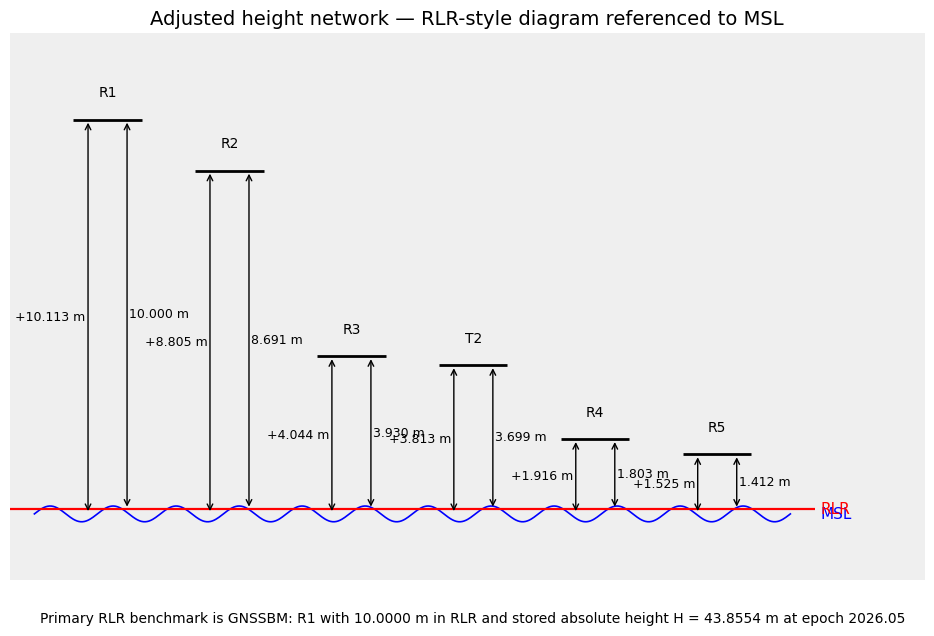

Tide-gauge reference benchmark: T2
Input height of 'T2' relative to MSL: 3.8127 m
Main GNSSBM benchmark: R1
Target local height assigned to GNSSBM 'R1': 10.0000 m
GNSS observation epoch at GNSSBM: 2026.05
Computed RLR level: 0.1135 m relative to MSL
Benchmarks plotted: R1, R2, R3, T2, R4, R5
Primary RLR benchmark is GNSSBM: R1 with 10.0000 m in RLR and stored absolute height H = 43.8554 m at epoch 2026.05


,benchmark,H_hat_m,sigma_H_m,H_above_MSL_m,H_above_RLR_m,is_fixed
0,R1,10.000000,0.000000,10.113482,10.000000,True
1,R2,8.691113,0.000786,8.804595,8.691113,False
2,R3,3.930150,0.001291,4.043633,3.930150,False
3,T2,3.699218,0.001532,3.812700,3.699218,False
4,R4,1.802682,0.000972,1.916165,1.802682,False
5,R5,1.411783,0.000895,1.525266,1.411783,False


In [14]:
# === Optional Height Step — RLR-style diagram of adjusted height network referenced to MSL ===
# Requires:
# - lsq["heights"] or heights
#
# This cell:
# - retrieves the adjusted height network
# - lists available benchmarks
# - asks which benchmark is the tide-gauge reference point
# - asks for the height of that benchmark relative to MSL
# - asks which benchmark is the main GNSSBM
# - asks for the local-system height assigned to that GNSSBM
# - asks for the epoch of GNSS observations at the GNSSBM
# - asks which benchmarks should be displayed in the diagram
# - reduces all network points to MSL
# - defines the RLR graphical level so that the selected GNSSBM has exactly the user-given local height
# - plots an RLR-style diagram for the selected points
# - if notebook runtime variables b and H exist, prints the requested informational line under the figure

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Retrieve adjusted heights dataframe
# ------------------------------------------------------------
if "lsq" in globals() and isinstance(lsq, dict) and isinstance(lsq.get("heights", None), pd.DataFrame):
    heights_df = lsq["heights"].copy()
elif "heights" in globals() and isinstance(heights, pd.DataFrame):
    heights_df = heights.copy()
else:
    raise RuntimeError("Adjusted height network was not found. Run the LS adjustment cell first.")

required_cols = ["benchmark", "H_hat_m"]
for col in required_cols:
    if col not in heights_df.columns:
        raise RuntimeError(f"Column '{col}' was not found in the adjusted heights dataframe.")

heights_df = heights_df.copy()
heights_df["benchmark"] = heights_df["benchmark"].astype(str).str.strip()
heights_df["H_hat_m"] = heights_df["H_hat_m"].astype(float)

if "sigma_H_m" in heights_df.columns:
    heights_df["sigma_H_m"] = pd.to_numeric(heights_df["sigma_H_m"], errors="coerce")

if "is_fixed" in heights_df.columns:
    heights_df["is_fixed"] = heights_df["is_fixed"].fillna(False).astype(bool)

heights_df = heights_df.drop_duplicates(subset=["benchmark"]).reset_index(drop=True)

if heights_df.empty:
    raise RuntimeError("The adjusted heights dataframe is empty.")

# ------------------------------------------------------------
# 2) Show available benchmarks
# ------------------------------------------------------------
available_benchmarks = heights_df["benchmark"].sort_values().tolist()

print("Available benchmarks:")
print(", ".join(available_benchmarks))

# ------------------------------------------------------------
# 3) Ask user for tide-gauge benchmark and its height relative to MSL
# ------------------------------------------------------------
tg_benchmark = input(
    "\nEnter the benchmark that corresponds to the tide-gauge reference point: "
).strip()

if tg_benchmark not in available_benchmarks:
    raise RuntimeError(f"Benchmark '{tg_benchmark}' was not found in the adjusted height network.")

tg_height_above_msl_str = input(
    f"Enter the height of benchmark '{tg_benchmark}' relative to MSL, in meters: "
).strip()

try:
    tg_height_above_msl_m = float(tg_height_above_msl_str.replace(",", "."))
except Exception:
    raise RuntimeError("The height relative to MSL must be a valid numeric value in meters.")

# ------------------------------------------------------------
# 4) Ask user for main GNSSBM and its local-system height
# ------------------------------------------------------------
gnssbm_benchmark = input(
    "\nEnter the main GNSSBM benchmark: "
).strip()

if gnssbm_benchmark not in available_benchmarks:
    raise RuntimeError(f"Benchmark '{gnssbm_benchmark}' was not found in the adjusted height network.")

gnssbm_local_height_str = input(
    f"Enter the local height assigned to GNSSBM '{gnssbm_benchmark}', in meters: "
).strip()

try:
    gnssbm_local_height_m = float(gnssbm_local_height_str.replace(",", "."))
except Exception:
    raise RuntimeError("The GNSSBM local height must be a valid numeric value in meters.")

# ------------------------------------------------------------
# 5) Ask user for GNSS observation epoch at GNSSBM
# ------------------------------------------------------------
epoch_gnssbm = input(
    f"Enter the GNSS observation epoch for GNSSBM '{gnssbm_benchmark}': "
).strip()

if epoch_gnssbm == "":
    raise RuntimeError("The GNSS observation epoch must not be empty.")

# ------------------------------------------------------------
# 6) Ask user which benchmarks should be displayed in the diagram
# ------------------------------------------------------------
print("\nAvailable benchmarks for plotting:")
print(", ".join(available_benchmarks))

plot_benchmarks_input = input(
    "Enter benchmark names to plot, separated by commas, or type ALL: "
).strip()

if plot_benchmarks_input == "":
    raise RuntimeError("No benchmark selection was given for plotting.")

if plot_benchmarks_input.upper() == "ALL":
    selected_plot_benchmarks = available_benchmarks.copy()
else:
    selected_plot_benchmarks = [p.strip() for p in plot_benchmarks_input.split(",") if p.strip() != ""]
    invalid_plot_benchmarks = [p for p in selected_plot_benchmarks if p not in available_benchmarks]
    if invalid_plot_benchmarks:
        raise RuntimeError(
            "The following benchmark(s) were not found in the adjusted height network: "
            + ", ".join(invalid_plot_benchmarks)
        )

if len(selected_plot_benchmarks) == 0:
    raise RuntimeError("The list of selected benchmarks for plotting is empty.")

# ------------------------------------------------------------
# 7) Reduce all points to MSL
# ------------------------------------------------------------
H_tg_local = float(
    heights_df.loc[heights_df["benchmark"] == tg_benchmark, "H_hat_m"].iloc[0]
)

# Absolute height of each benchmark above MSL:
# H_MSL(point) = H_MSL(TG point) + [H_local(point) - H_local(TG point)]
heights_df["H_above_MSL_m"] = tg_height_above_msl_m + (heights_df["H_hat_m"] - H_tg_local)

# ------------------------------------------------------------
# 8) Define RLR level from the main GNSSBM condition
# ------------------------------------------------------------
H_gnssbm_above_MSL_m = float(
    heights_df.loc[heights_df["benchmark"] == gnssbm_benchmark, "H_above_MSL_m"].iloc[0]
)

# Enforce:
# H_above_RLR(GNSSBM) = gnssbm_local_height_m
# => H_above_MSL(GNSSBM) - RLR = gnssbm_local_height_m
# => RLR = H_above_MSL(GNSSBM) - gnssbm_local_height_m
rlr_y = H_gnssbm_above_MSL_m - gnssbm_local_height_m

heights_df["H_above_RLR_m"] = heights_df["H_above_MSL_m"] - rlr_y

# ------------------------------------------------------------
# 9) Detect runtime variables b and H from notebook
# ------------------------------------------------------------
runtime_info_text = None
if "b" in globals() and "H" in globals():
    try:
        runtime_b_value = str(globals()["b"]).strip()
        runtime_H_value = float(globals()["H"])
        runtime_info_text = (
            f"Primary RLR benchmark is GNSSBM: {runtime_b_value} "
            f"with {gnssbm_local_height_m:.4f} m in RLR and stored absolute height "
            f"H = {runtime_H_value:.4f} m at epoch {epoch_gnssbm}"
        )
    except Exception:
        runtime_info_text = None

# ------------------------------------------------------------
# 10) Keep only selected benchmarks for plotting
# ------------------------------------------------------------
plot_df = (
    heights_df[heights_df["benchmark"].isin(selected_plot_benchmarks)]
    .copy()
    .sort_values(["H_above_MSL_m", "benchmark"], ascending=[False, True])
    .reset_index(drop=True)
)

if plot_df.empty:
    raise RuntimeError("No benchmarks remained after plot selection.")

n_pts = len(plot_df)
x_pos = np.arange(n_pts, dtype=float)
plot_df["x"] = x_pos

# ------------------------------------------------------------
# 11) Plot RLR-style diagram
# ------------------------------------------------------------
msl_y = 0.0
min_y = float(min(plot_df["H_above_MSL_m"].min(), rlr_y, msl_y))
max_y = float(max(plot_df["H_above_MSL_m"].max(), rlr_y, msl_y))
span_y = max(max_y - min_y, 1.0)

fig_width = max(11, 1.55 * n_pts + 2.5)
fig, ax = plt.subplots(figsize=(fig_width, 7.6))
ax.set_facecolor("#efefef")

# MSL wavy line
wave_x = np.linspace(-0.6, n_pts - 0.4, 800)
wave_amp = 0.02 * span_y
wave_y = msl_y + wave_amp * np.sin(
    2 * np.pi * 12 * (wave_x - wave_x.min()) / (wave_x.max() - wave_x.min() + 1e-12)
)
ax.plot(wave_x, wave_y, color="blue", linewidth=1.2, zorder=1)

# RLR line
ax.hlines(rlr_y, -0.8, n_pts - 0.2, colors="red", linewidth=1.6, zorder=1)

# Benchmark levels, arrows and labels
seg_half = 0.28
label_dy = 0.05 * span_y
txt_fs = 10
val_fs = 9

for _, r in plot_df.iterrows():
    x = float(r["x"])
    y = float(r["H_above_MSL_m"])
    bm = str(r["benchmark"]).strip()

    # benchmark level
    ax.hlines(y, x - seg_half, x + seg_half, colors="black", linewidth=2.0, zorder=3)

    # benchmark name
    ax.text(
        x,
        y + label_dy,
        bm,
        ha="center",
        va="bottom",
        fontsize=txt_fs,
        color="black",
        zorder=4
    )

    # arrow from MSL to benchmark
    x_left = x - 0.16
    ax.annotate(
        "",
        xy=(x_left, y),
        xytext=(x_left, msl_y),
        arrowprops=dict(arrowstyle="<->", lw=1.0, color="black"),
        zorder=2
    )
    ax.text(
        x_left - 0.02,
        0.5 * (y + msl_y),
        f"{y:+.3f} m",
        ha="right",
        va="center",
        fontsize=val_fs,
        color="black",
        zorder=4
    )

    # arrow from RLR to benchmark
    x_right = x + 0.16
    ax.annotate(
        "",
        xy=(x_right, y),
        xytext=(x_right, rlr_y),
        arrowprops=dict(arrowstyle="<->", lw=1.0, color="black"),
        zorder=2
    )
    ax.text(
        x_right + 0.02,
        0.5 * (y + rlr_y),
        f"{float(r['H_above_RLR_m']):.3f} m",
        ha="left",
        va="center",
        fontsize=val_fs,
        color="black",
        zorder=4
    )

# Labels for MSL and RLR
ax.text(
    n_pts - 0.15,
    msl_y,
    "MSL",
    ha="left",
    va="center",
    fontsize=11,
    color="blue",
    zorder=4
)

ax.text(
    n_pts - 0.15,
    rlr_y,
    "RLR",
    ha="left",
    va="center",
    fontsize=11,
    color="red",
    zorder=4
)

# Title
ax.set_title("Adjusted height network — RLR-style diagram referenced to MSL", fontsize=14)

# Clean axes
ax.set_xlim(-0.8, n_pts - 0.2 + 0.9)
ax.set_ylim(rlr_y - 0.18 * span_y, max_y + 0.22 * span_y)
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# Informational text under figure, if runtime b and H exist
if runtime_info_text is not None:
    fig.subplots_adjust(bottom=0.16)
    fig.text(
        0.15,
        0.1,
        runtime_info_text,
        ha="left",
        va="bottom",
        fontsize=10,
        color="black"
    )
else:
    fig.subplots_adjust(bottom=0.10)

plt.show()

# ------------------------------------------------------------
# 12) Output reduced heights table
# ------------------------------------------------------------
cols_out = ["benchmark", "H_hat_m", "H_above_MSL_m", "H_above_RLR_m"]
if "sigma_H_m" in plot_df.columns:
    cols_out.insert(2, "sigma_H_m")
if "is_fixed" in plot_df.columns:
    cols_out.append("is_fixed")

rlr_results = plot_df[cols_out].copy().reset_index(drop=True)

print(f"Tide-gauge reference benchmark: {tg_benchmark}")
print(f"Input height of '{tg_benchmark}' relative to MSL: {tg_height_above_msl_m:.4f} m")
print(f"Main GNSSBM benchmark: {gnssbm_benchmark}")
print(f"Target local height assigned to GNSSBM '{gnssbm_benchmark}': {gnssbm_local_height_m:.4f} m")
print(f"GNSS observation epoch at GNSSBM: {epoch_gnssbm}")
print(f"Computed RLR level: {rlr_y:.4f} m relative to MSL")
print("Benchmarks plotted:", ", ".join(plot_df["benchmark"].tolist()))

if runtime_info_text is not None:
    print(runtime_info_text)
else:
    print("Notebook runtime variables 'b' and/or 'H' were not found or could not be interpreted.")

display(rlr_results)

## Optional extension: 2D horizontal network adjustment (N, E or lat, lon)

These cells extend the notebook from the vertical-only solution to an optional **2D horizontal adjustment**.

**Important model requirement:** a horizontal solution is possible only if the input workbook contains a horizontal observation, i.e. a **local horizontal direction** (`Hz`) or a **global azimuth/bearing** column.  
The existing vertical workflow alone (`from`, `to`, `V_gon`, `slope_m`, `HI`, `HT`) is **not sufficient** for unique planimetric coordinates.

**Observation model used here**
- Horizontal distance is computed as  
  `HD = slope * sin(Z)`  
  where `Z = V_gon * π / 200`
- Optional planimetric observations:
  - `hz_local`: local horizontal directions from each occupied station, with one unknown orientation parameter per setup station
  - `azimuth_global`: global azimuth/bearing observations, with no station orientation unknowns

**Datum requirements**
- `hz_local` mode: at least **2 fixed points** with known coordinates
- `azimuth_global` mode: at least **1 fixed point** with known coordinates

**Approximate coordinates**
- Because the 2D adjustment is nonlinear, approximate coordinates are required for **all** points before the solver cell is run.
- You may provide them either as:
  - `N_m`, `E_m`, or
  - `lat_deg`, `lon_deg`  
    In that case the solver converts them internally to a local EN frame using an azimuthal equidistant projection.


## Optional 2D Step 1 — Detect horizontal observations and compute horizontal distance

This cell starts the optional 2D extension of the notebook.

**Main role**
- detect horizontal-direction information in the workbook,
- parse the relevant angular field,
- compute horizontal distance from slope distance and zenith angle,
- build the planimetric observation dataframe `obs_xy`.

In [15]:
# === Optional 2D Step 1 — Detect horizontal observations and compute horizontal distance ===
# Name: optional_xy_prepare_observations
# Revised:
# - Prevents many-to-many merge inflation between obs and df_raw
# - Uses occurrence index within identical key groups for a deterministic 1-to-1 match
# - Computes horizontal distance HD = slope * sin(Z)
# - Builds planimetric observation table obs_xy safely

import numpy as np
import pandas as pd

def _find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def _parse_float_local(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip()
    if s in ["", "-", "—", "–", "nan", "NaN", "None"]:
        return np.nan
    s = s.replace(",", ".")
    token = s.split()[0]
    try:
        return float(token)
    except Exception:
        import re
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
        return float(m.group(0)) if m else np.nan

def _angle_unit_from_name(colname):
    if colname is None:
        return None
    s = str(colname).lower()
    if ("deg" in s) or ("°" in s):
        return "deg"
    return "gon"

# ------------------------------------------------------------
# Detect candidate horizontal-angle columns
# ------------------------------------------------------------
col_hz = _find_col(df_raw, [
    "Hz [gon]", "Hz(gon)", "Hz", "Horizontal Direction [gon]", "Horizontal Direction",
    "Direction [gon]", "Direction", "Hz [deg]", "Direction [deg]"
])

col_az = _find_col(df_raw, [
    "Azimuth [gon]", "Azimuth", "Bearing [gon]", "Bearing",
    "Azimuth [deg]", "Bearing [deg]"
])

unit_hz = _angle_unit_from_name(col_hz)
unit_az = _angle_unit_from_name(col_az)

# ------------------------------------------------------------
# Build raw-side comparison table
# ------------------------------------------------------------
tmp_raw = df_raw.copy()

col_from_raw = _find_col(df_raw, ["From Station", "From", "Station", "Station Name", "Setup Station"])
col_to_raw   = _find_col(df_raw, ["To", "Target", "To Station", "Point", "Sight To"])
col_face_raw = _find_col(df_raw, ["Face", "FACE"])
col_v_raw    = _find_col(df_raw, ["V [gon]", "V(gon)", "V", "Zenith [gon]", "Zenith", "Z [gon]"])
col_sd_raw   = _find_col(df_raw, ["Slope Dist. [m]", "Slope Dist [m]", "Slope Distance [m]", "Slope [m]", "SD [m]"])
col_ht_raw   = _find_col(df_raw, ["Target Height [m]", "Target Height", "HT [m]", "Prism Height [m]", "Reflector Height [m]"])

tmp_raw["_from"]    = tmp_raw[col_from_raw].astype(str).str.strip()
tmp_raw["_to"]      = tmp_raw[col_to_raw].astype(str).str.strip()
tmp_raw["_face"]    = tmp_raw[col_face_raw].astype(str).str.strip().str.upper()
tmp_raw["_V_gon"]   = tmp_raw[col_v_raw].apply(_parse_float_local)
tmp_raw["_slope_m"] = tmp_raw[col_sd_raw].apply(_parse_float_local)
tmp_raw["_HI_m"]    = tmp_raw[config["hi_col"]].apply(_parse_float_local)
tmp_raw["_HT_m"]    = tmp_raw[col_ht_raw].apply(_parse_float_local)

raw_key_cols = ["_from", "_to", "_face", "_V_gon", "_slope_m", "_HI_m", "_HT_m"]

raw_cmp = tmp_raw[raw_key_cols].copy()
raw_cmp["raw_row_id_xy"] = np.arange(len(raw_cmp), dtype=int)

if col_hz is not None:
    raw_cmp["Hz_raw"] = tmp_raw[col_hz].apply(_parse_float_local)

if col_az is not None:
    raw_cmp["Az_raw"] = tmp_raw[col_az].apply(_parse_float_local)

# Occurrence index INSIDE each identical raw key
raw_cmp["_match_seq_xy"] = raw_cmp.groupby(raw_key_cols, dropna=False).cumcount()

# ------------------------------------------------------------
# Build obs-side table
# ------------------------------------------------------------
obs_xy = obs.copy().reset_index(drop=True)

# Drop stale columns if the cell is rerun
for c in ["Hz_raw", "Az_raw", "raw_row_id_xy", "_match_seq_xy", "obs_id_xy"]:
    if c in obs_xy.columns:
        obs_xy = obs_xy.drop(columns=c)

obs_xy["_from"]    = obs_xy["from"].astype(str).str.strip()
obs_xy["_to"]      = obs_xy["to"].astype(str).str.strip()
obs_xy["_face"]    = obs_xy["face"].astype(str).str.strip().str.upper()
obs_xy["_V_gon"]   = pd.to_numeric(obs_xy["V_gon"], errors="coerce")
obs_xy["_slope_m"] = pd.to_numeric(obs_xy["slope_m"], errors="coerce")
obs_xy["_HI_m"]    = pd.to_numeric(obs_xy["HI_m"], errors="coerce")
obs_xy["_HT_m"]    = pd.to_numeric(obs_xy["HT_m"], errors="coerce")

# Occurrence index INSIDE each identical obs key
obs_xy["_match_seq_xy"] = obs_xy.groupby(raw_key_cols, dropna=False).cumcount()

# ------------------------------------------------------------
# Safe 1-to-1 merge (prevents row multiplication)
# ------------------------------------------------------------
merge_cols = raw_key_cols + ["_match_seq_xy"]

obs_xy = obs_xy.merge(
    raw_cmp[merge_cols + ["raw_row_id_xy"] + ([ "Hz_raw" ] if "Hz_raw" in raw_cmp.columns else []) + ([ "Az_raw" ] if "Az_raw" in raw_cmp.columns else [])],
    on=merge_cols,
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Horizontal distance from zenith angle
# ------------------------------------------------------------
if "Z_rad" not in obs_xy.columns:
    obs_xy["Z_rad"] = pd.to_numeric(obs_xy["V_gon"], errors="coerce") * np.pi / 200.0

obs_xy["HD_C_m"] = pd.to_numeric(obs_xy["slope_m"], errors="coerce") * np.sin(pd.to_numeric(obs_xy["Z_rad"], errors="coerce"))

# Stable observation id for 2D processing
obs_xy = obs_xy.reset_index(drop=True).copy()
obs_xy["obs_id_xy"] = np.arange(len(obs_xy), dtype=int)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
n_obs_in = len(obs)
n_obs_out = len(obs_xy)
n_unmatched_raw = int(obs_xy["raw_row_id_xy"].isna().sum())

raw_dup_groups = int((raw_cmp.groupby(raw_key_cols, dropna=False).size() > 1).sum())
obs_dup_groups = int((obs_xy.groupby(raw_key_cols, dropna=False).size() > 1).sum())

xy_prepare = {
    "col_hz": col_hz,
    "unit_hz": unit_hz,
    "col_az": col_az,
    "unit_az": unit_az,
    "n_obs_input_from_obs": int(n_obs_in),
    "n_obs_output_obs_xy": int(n_obs_out),
    "n_unmatched_raw_rows": int(n_unmatched_raw),
    "n_duplicate_key_groups_in_raw": int(raw_dup_groups),
    "n_duplicate_key_groups_in_obs": int(obs_dup_groups),
    "n_hz_finite": int(np.isfinite(obs_xy["Hz_raw"]).sum()) if "Hz_raw" in obs_xy.columns else 0,
    "n_az_finite": int(np.isfinite(obs_xy["Az_raw"]).sum()) if "Az_raw" in obs_xy.columns else 0,
}

print("Horizontal-observation detection summary:")
print(xy_prepare)

if col_hz is None and col_az is None:
    print("\nWARNING: No horizontal direction / azimuth column was detected in df_raw.")
    print("A unique 2D coordinate adjustment is therefore not possible until such a column exists in the input workbook.")

if n_obs_out != n_obs_in:
    print("\nWARNING: obs_xy row count changed. This should normally NOT happen.")
else:
    print("\nRow count check passed: obs_xy has the same number of rows as obs.")

if n_unmatched_raw > 0:
    print(f"WARNING: {n_unmatched_raw} obs rows could not be matched back to df_raw for Hz/Az attachment.")

print("\nAdded planimetric preparation DataFrame: obs_xy")
display(obs_xy.head(20))

Horizontal-observation detection summary:
{'col_hz': None, 'unit_hz': None, 'col_az': 'Azimuth [gon]', 'unit_az': 'gon', 'n_obs_input_from_obs': 278, 'n_obs_output_obs_xy': 278, 'n_unmatched_raw_rows': 0, 'n_duplicate_key_groups_in_raw': 9, 'n_duplicate_key_groups_in_obs': 9, 'n_hz_finite': 0, 'n_az_finite': 278}

Row count check passed: obs_xy has the same number of rows as obs.

Added planimetric preparation DataFrame: obs_xy


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,...,_face,_V_gon,_slope_m,_HI_m,_HT_m,_match_seq_xy,raw_row_id_xy,Az_raw,HD_C_m,obs_id_xy
0,R1,R2,I,108.0436,21.6415,1.51896,0.1,2026-01-19,True,1.697145,...,I,108.0436,21.6415,1.51896,0.1,0,0,81.6977,21.468988,0
1,R1,R2,I,108.0442,21.6415,1.51896,0.1,2026-01-19,True,1.697154,...,I,108.0442,21.6415,1.51896,0.1,0,1,81.6982,21.468962,1
2,R1,R2,I,108.0444,21.6408,1.51896,0.1,2026-01-19,True,1.697157,...,I,108.0444,21.6408,1.51896,0.1,0,2,81.6981,21.468259,2
3,R1,R2,I,108.0454,21.6420,1.51896,0.1,2026-01-19,True,1.697173,...,I,108.0454,21.6420,1.51896,0.1,0,3,81.6973,21.469407,3
4,R1,R2,I,108.0438,21.6422,1.51896,0.1,2026-01-19,True,1.697148,...,I,108.0438,21.6422,1.51896,0.1,0,4,81.6972,21.469673,4
5,R1,R2,I,108.0437,21.6422,1.51896,0.1,2026-01-19,True,1.697146,...,I,108.0437,21.6422,1.51896,0.1,0,5,81.6973,21.469678,5
6,R1,R2,I,108.0440,21.6420,1.51896,0.1,2026-01-19,True,1.697151,...,I,108.0440,21.6420,1.51896,0.1,0,6,81.6976,21.469467,6
7,R1,R2,I,108.0447,21.6421,1.51896,0.1,2026-01-19,True,1.697162,...,I,108.0447,21.6421,1.51896,0.1,0,7,81.6976,21.469536,7
8,R1,R2,I,108.0442,21.6421,1.51896,0.1,2026-01-19,True,1.697154,...,I,108.0442,21.6421,1.51896,0.1,0,8,81.6977,21.469557,8
9,R1,R2,I,108.0440,21.6422,1.51896,0.1,2026-01-19,True,1.697151,...,I,108.0440,21.6422,1.51896,0.1,0,9,81.6974,21.469665,9


## Optional 2D Step 1A — Input a priori instrument accuracies

This cell records the a priori instrument-accuracy parameters used in the horizontal stochastic model.

**Main role**
- ask for the distance constant term,
- ask for the distance proportional term,
- ask for the direction accuracy,
- convert all quantities to the internal units used later in the 2D adjustment.

In [16]:
# --- A priori instrument accuracies for 2D adjustment ---
sigma_dist_const_mm = float(input("Enter distance accuracy constant term a [mm] (e.g. 0.3): ").strip().replace(",", "."))
sigma_dist_ppm      = float(input("Enter distance accuracy proportional term b [ppm] (e.g. 13): ").strip().replace(",", "."))
sigma_dir_arcsec    = float(input("Enter direction accuracy c [arcsec] (e.g. 0.5): ").strip().replace(",", "."))

# --- Unit conversions ---
sigma_dist_const_m = sigma_dist_const_mm / 1000.0
sigma_dir_gon = sigma_dir_arcsec * (10.0 / (9.0 * 3600.0))

print("\nA priori stochastic model parameters:")
print(f"Distance: ±({sigma_dist_const_mm:.6f} mm + {sigma_dist_ppm:.6f} ppm)")
print(f"Direction: ±{sigma_dir_arcsec:.6f} arcsec")
print("\nConverted internal units:")
print(f"sigma_dist_const_m = {sigma_dist_const_m:.12f} m")
print(f"sigma_dir_gon      = {sigma_dir_gon:.12f} gon")

Enter distance accuracy constant term a [mm] (e.g. 0.3): 0.3
Enter distance accuracy proportional term b [ppm] (e.g. 13): 13
Enter direction accuracy c [arcsec] (e.g. 0.5): 0.5

A priori stochastic model parameters:
Distance: ±(0.300000 mm + 13.000000 ppm)
Direction: ±0.500000 arcsec

Converted internal units:
sigma_dist_const_m = 0.000300000000 m
sigma_dir_gon      = 0.000154320988 gon


## Optional 2D Step 1B — Directed-edge internal precision and QC for horizontal observables

This cell evaluates repeatability and performs optional QC for the main horizontal observables.

**Main role**
- summarize precision for horizontal distance `HD_C_m`,
- summarize precision for opened direction `Hz_open_gon`,
- perform optional `k·σ` outlier flagging,
- optionally overwrite `obs_xy` with a cleaned dataset for later 2D processing.

In [19]:
# === Optional 2D Step 1B — Occupation-based internal precision + QC (horizontal), updated with non-point block assignment ===
# Name: optional_xy_occupation_based_precision_and_qc_revised_nonpoint_assignment
# Description:
# - Builds initial contiguous block IDs (block_id_xy) using:
#     * benchmark ('from')
#     * HI_m changes
#     * optional substantial backward datetime jump within same benchmark
#     * optional large same-HI direction jump to an already-seen POINT target within the current block
# - User may declare NON-POINT targets; these are:
#     * EXEMPT from REPEAT_TARGET_DIRECTION_JUMP during initial split
#     * EXCLUDED from point-based block-merge evidence
# - Compares blocks of the SAME benchmark to infer TRUE setups from POINT-target direction evidence only.
# - Non-point-only blocks are then attached to an inferred setup as follows:
#     * if exactly one candidate setup exists with same from + HI -> auto-attach
#     * if multiple candidate setups exist with same from + HI -> ask user to choose
#     * if no candidate exists -> keep as standalone unresolved setup (reported explicitly)
# - Computes setup-based internal precision for:
#     * HD_C_m
#     * Hz_open_gon
# - Optional QC per observable:
#     * mode="combined": per (setup_id_xy, from->to) using both faces together
#     * mode="per_face": per (setup_id_xy, from->to->face) using each face separately
# - Optional drops of flagged observations and overwrite of obs_xy for the next 2D cells
# - Saves results in dict: qc_edge_xy
#
# IMPORTANT:
# - This cell assumes that the field used as local direction ('Hz_open_gon') is already OPENED
#   within each local direction system. No ±200 gon face-II shift is applied here.
# - 'setup_id_xy' means: observations sharing the SAME local direction system
#   and belonging to the SAME benchmark.
# - 'block_id_xy' means: initial contiguous blocks before setup merging / non-point assignment.

import numpy as np
import pandas as pd

if "obs_xy" not in globals():
    raise RuntimeError("obs_xy was not found. Run Optional 2D Step 1 first.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _std_ddof1(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return 0.0
    return float(np.std(x, ddof=1))

def _se_from_std(std, n):
    return float(std / np.sqrt(n)) if n > 0 else np.nan

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _circular_mean_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    ang = vals * np.pi / 200.0
    s = np.mean(np.sin(ang))
    c = np.mean(np.cos(ang))
    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        ref = vals[0]
        unwrapped = ref + _wrap_gon_pm200(vals - ref)
        return float(_wrap_gon_0_400(np.mean(unwrapped)))
    return float(_wrap_gon_0_400(np.arctan2(s, c) * 200.0 / np.pi))

def _circular_std_ddof1_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) <= 1:
        return 0.0
    mu = _circular_mean_gon(vals)
    res = _wrap_gon_pm200(vals - mu)
    return float(np.std(res, ddof=1))

def _is_finite_number(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

def _safe_numeric(x):
    try:
        v = float(x)
        return v if np.isfinite(v) else np.nan
    except Exception:
        return np.nan

def _safe_col(df, col, fill=np.nan):
    if col not in df.columns:
        df[col] = fill

def _parse_datetime_safe(series):
    s = series.copy()
    try:
        dt = pd.to_datetime(s, errors="coerce", dayfirst=True)
    except Exception:
        dt = pd.to_datetime(s.astype(str), errors="coerce", dayfirst=True)
    return dt

def _hi_unique_values(series, decimals=6):
    vals = pd.to_numeric(series, errors="coerce")
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.array([], dtype=float)
    vals = np.round(vals.astype(float), decimals)
    return np.sort(np.unique(vals))

def _hi_ref_m(series, decimals=6):
    u = _hi_unique_values(series, decimals=decimals)
    return float(u[0]) if len(u) > 0 else np.nan

def _hi_n_unique(series, decimals=6):
    u = _hi_unique_values(series, decimals=decimals)
    return int(len(u))

def _hi_values_m(series, decimals=6):
    u = _hi_unique_values(series, decimals=decimals)
    return ", ".join(f"{v:.6f}" for v in u)

def _hi_is_constant(series, decimals=6):
    n = _hi_n_unique(series, decimals=decimals)
    return (n == 1) if n > 0 else np.nan

def _series_unique_str(series):
    s = pd.Series(series).dropna().astype(str).str.strip()
    s = s[s != ""]
    if len(s) == 0:
        return []
    return sorted(s.unique().tolist())

def _join_unique_str(series):
    vals = _series_unique_str(series)
    return ", ".join(vals)

def _join_unique_str_preserve_order(series):
    s = pd.Series(series).dropna().astype(str).str.strip()
    s = s[s != ""]
    if len(s) == 0:
        return ""
    vals = pd.Index(s).unique().tolist()
    return ", ".join(map(str, vals))

class _UnionFind:
    def __init__(self, items):
        self.parent = {x: x for x in items}
        self.rank = {x: 0 for x in items}

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        ra = self.find(a)
        rb = self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1

def _block_circular_target_means(block_df, value_col="Hz_open_gon"):
    rows = []
    for tgt, g in block_df.groupby("to", dropna=False):
        vals = pd.to_numeric(g[value_col], errors="coerce").dropna().values
        n = len(vals)
        if n == 0:
            continue
        mu = _circular_mean_gon(vals)
        std = _circular_std_ddof1_gon(vals)
        se = _se_from_std(std, n)
        rows.append({
            "to": str(tgt).strip(),
            "n": int(n),
            "mean_gon": mu,
            "std_gon": std,
            "se_gon": se,
        })
    return pd.DataFrame(rows)

def _infer_block_ids_from_contiguous_blocks(
    df,
    hi_tol_m=0.001,
    restart_split_gon=0.001,
    backward_time_split_sec=60.0,
    non_point_targets_exempt=None,
):
    """
    Infer initial contiguous block IDs.

    A new block starts when:
    - 'from' changes
    - HI changes by more than hi_tol_m
    - OR, within same 'from' and HI, datetime jumps substantially backwards
    - OR, within same 'from' and HI, a POINT target already seen in the current block
      appears again with a direction jump > restart_split_gon

    NON-POINT targets declared by the user are exempt from the repeat-target direction trigger.
    """
    if non_point_targets_exempt is None:
        non_point_targets_exempt = set()

    block_ids = []
    block_seq = []
    split_reason = []

    seq_by_from = {}
    current_from = None
    current_hi = np.nan
    current_dt = pd.NaT
    current_block_target_means = {}
    current_block_id = None

    for _, row in df.iterrows():
        f = str(row["from"]).strip()
        t = str(row["to"]).strip()
        hi = _safe_numeric(row["HI_m"])
        hz = _safe_numeric(row["Hz_open_gon"])
        dt = row["datetime"] if "datetime" in row.index else pd.NaT
        is_nonpoint = bool(row.get("is_nonpoint_target", False))

        start_new = False
        reason = "CONTINUE"

        if current_from is None:
            start_new = True
            reason = "FIRST_ROW"
        else:
            if f != current_from:
                start_new = True
                reason = "FROM_CHANGED"
            else:
                prev_hi_fin = _is_finite_number(current_hi)
                hi_fin = _is_finite_number(hi)

                if prev_hi_fin != hi_fin:
                    start_new = True
                    reason = "HI_FINITE_STATE_CHANGED"
                elif prev_hi_fin and hi_fin:
                    if abs(float(hi) - float(current_hi)) > hi_tol_m:
                        start_new = True
                        reason = "HI_CHANGED"

                if (
                    not start_new
                    and pd.notna(current_dt)
                    and pd.notna(dt)
                    and (dt < current_dt - pd.Timedelta(seconds=backward_time_split_sec))
                ):
                    start_new = True
                    reason = "DATETIME_BACKWARD_JUMP"

                if (
                    not start_new
                    and (not is_nonpoint)
                    and _is_finite_number(hz)
                    and t in current_block_target_means
                    and t not in non_point_targets_exempt
                ):
                    hz_mean_prev = current_block_target_means[t]
                    delta = abs(float(_wrap_gon_pm200(hz - hz_mean_prev)))
                    if delta > restart_split_gon:
                        start_new = True
                        reason = "REPEAT_TARGET_DIRECTION_JUMP"

        if start_new:
            seq_by_from[f] = seq_by_from.get(f, 0) + 1
            current_block_id = f"{f}__BLK{seq_by_from[f]:03d}"
            current_block_target_means = {}

        block_ids.append(current_block_id)
        block_seq.append(seq_by_from[f])
        split_reason.append(reason)

        if _is_finite_number(hz):
            if t not in current_block_target_means:
                current_block_target_means[t] = float(hz)
            else:
                current_block_target_means[t] = float(
                    _circular_mean_gon([current_block_target_means[t], hz])
                )

        current_from = f
        current_hi = hi
        current_dt = dt

    return block_ids, block_seq, split_reason

def _build_direct_setup_map_from_blocks(block_summary_df):
    """
    Guaranteed fallback:
    each block gets one setup_id_xy, ordered by first_row within each benchmark.
    """
    rows = []
    if len(block_summary_df) == 0:
        return pd.DataFrame(columns=["from_benchmark", "block_id_xy", "setup_id_xy"])

    for f, g_f in block_summary_df.groupby("from_benchmark", dropna=False):
        g_f2 = g_f.sort_values(["first_row", "block_id_xy"]).reset_index(drop=True)
        for iset, (_, r) in enumerate(g_f2.iterrows(), start=1):
            rows.append({
                "from_benchmark": f,
                "block_id_xy": r["block_id_xy"],
                "setup_id_xy": f"{f}__SET{iset:03d}",
            })

    return pd.DataFrame(rows, columns=["from_benchmark", "block_id_xy", "setup_id_xy"])

# ------------------------------------------------------------
# Prepare working horizontal-observation table
# ------------------------------------------------------------
obs_xy_work = obs_xy.copy().reset_index(drop=True)

obs_xy_work["from"] = obs_xy_work["from"].astype(str).str.strip()
obs_xy_work["to"] = obs_xy_work["to"].astype(str).str.strip()

_safe_col(obs_xy_work, "face", np.nan)
obs_xy_work["face"] = obs_xy_work["face"].astype("string").str.strip().str.upper()
obs_xy_work["face"] = obs_xy_work["face"].replace({"<NA>": np.nan, "NAN": np.nan, "": np.nan})

for c in ["datetime", "V_gon", "slope_m", "HI_m", "HT_m", "Az_raw", "Hz_raw"]:
    _safe_col(obs_xy_work, c, np.nan)

if "obs_id_xy" not in obs_xy_work.columns:
    obs_xy_work["obs_id_xy"] = np.arange(len(obs_xy_work), dtype=int)

obs_xy_work["__row_order_xy"] = np.arange(len(obs_xy_work), dtype=int)
obs_xy_work["datetime"] = _parse_datetime_safe(obs_xy_work["datetime"])

# Reclassify local direction field if needed
if ("Hz_raw" not in obs_xy_work.columns or obs_xy_work["Hz_raw"].isna().all()) and ("Az_raw" in obs_xy_work.columns):
    obs_xy_work["Hz_raw"] = obs_xy_work["Az_raw"]
    print("Reclassified 'Az_raw' as local direction field 'Hz_raw'.")

if "HD_C_m" not in obs_xy_work.columns:
    raise RuntimeError("HD_C_m was not found in obs_xy.")

obs_xy_work["HD_C_m"] = pd.to_numeric(obs_xy_work["HD_C_m"], errors="coerce").abs()
obs_xy_work["Hz_raw"] = pd.to_numeric(obs_xy_work["Hz_raw"], errors="coerce")
obs_xy_work["Hz_open_gon"] = obs_xy_work["Hz_raw"].copy()
obs_xy_work["HI_m"] = pd.to_numeric(obs_xy_work["HI_m"], errors="coerce")

# Keep original copy before any QC drop
obs_xy_original = obs_xy_work.copy()

# ------------------------------------------------------------
# NON-POINT target declaration
# ------------------------------------------------------------
available_targets_xy = sorted(obs_xy_work["to"].dropna().astype(str).str.strip().unique().tolist())

print("\nAvailable targets in current obs_xy:")
print(", ".join(available_targets_xy) if len(available_targets_xy) > 0 else "(none)")

print("\nDeclare NON-POINT targets to EXEMPT from REPEAT_TARGET_DIRECTION_JUMP during initial block splitting? (y/n): ", flush=True)
declare_nonpoint_targets = input().strip().lower()
if declare_nonpoint_targets not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

non_point_targets_xy = set()
if declare_nonpoint_targets == "y":
    print(
        "Enter comma-separated target names exactly as they appear in column 'to' "
        "(example: RADAR, WALL, PANEL_1). Leave blank for none:",
        flush=True
    )
    raw_nonpoint = input().strip()

    if raw_nonpoint != "":
        requested_nonpoint = [x.strip() for x in raw_nonpoint.split(",") if x.strip() != ""]
        unknown_nonpoint = sorted(set(requested_nonpoint) - set(available_targets_xy))
        if len(unknown_nonpoint) > 0:
            raise ValueError(
                "The following declared NON-POINT targets were not found in column 'to': "
                + ", ".join(unknown_nonpoint)
            )
        non_point_targets_xy = set(requested_nonpoint)

obs_xy_work["is_nonpoint_target"] = obs_xy_work["to"].isin(non_point_targets_xy)

if len(non_point_targets_xy) > 0:
    print("\nActive NON-POINT targets exempt from REPEAT_TARGET_DIRECTION_JUMP:")
    print(", ".join(sorted(non_point_targets_xy)))
else:
    print("\nNo NON-POINT targets declared. All targets participate in repeat-target split logic.")

# ------------------------------------------------------------
# Step A — Initial contiguous blocks
# ------------------------------------------------------------
HI_SPLIT_TOL_M = 0.001
RESTART_SPLIT_GON = 0.001
BACKWARD_TIME_SPLIT_SEC = 60.0

block_ids, block_seq, split_reason = _infer_block_ids_from_contiguous_blocks(
    obs_xy_work,
    hi_tol_m=HI_SPLIT_TOL_M,
    restart_split_gon=RESTART_SPLIT_GON,
    backward_time_split_sec=BACKWARD_TIME_SPLIT_SEC,
    non_point_targets_exempt=non_point_targets_xy,
)

obs_xy_work["block_id_xy"] = block_ids
obs_xy_work["block_seq_xy"] = block_seq
obs_xy_work["block_split_reason_xy"] = split_reason

block_meta_rows = []
for block_id, g in obs_xy_work.groupby("block_id_xy", dropna=False):
    targets_all = _series_unique_str(g["to"])
    targets_point = _series_unique_str(g.loc[~g["is_nonpoint_target"], "to"])
    targets_nonpoint = _series_unique_str(g.loc[g["is_nonpoint_target"], "to"])

    block_meta_rows.append({
        "block_id_xy": block_id,
        "from_benchmark": str(g["from"].iloc[0]).strip(),
        "n_obs": int(len(g)),
        "n_targets": int(g["to"].nunique()),
        "n_targets_point": int(len(targets_point)),
        "n_targets_nonpoint": int(len(targets_nonpoint)),
        "targets_all": ", ".join(targets_all),
        "targets_point": ", ".join(targets_point),
        "targets_nonpoint": ", ".join(targets_nonpoint),
        "has_point_target": bool(len(targets_point) > 0),
        "is_nonpoint_only": bool((len(targets_nonpoint) > 0) and (len(targets_point) == 0)),
        "HI_ref_m": _hi_ref_m(g["HI_m"]),
        "HI_n_unique": _hi_n_unique(g["HI_m"]),
        "HI_values_m": _hi_values_m(g["HI_m"]),
        "HI_is_constant": _hi_is_constant(g["HI_m"]),
        "first_row": int(g["__row_order_xy"].min()),
        "last_row": int(g["__row_order_xy"].max()),
        "datetime_first": g["datetime"].iloc[0] if "datetime" in g.columns else pd.NaT,
        "datetime_last": g["datetime"].iloc[-1] if "datetime" in g.columns else pd.NaT,
        "split_reason_first": str(g["block_split_reason_xy"].iloc[0]),
    })

block_summary_xy = (
    pd.DataFrame(block_meta_rows)
    .sort_values(["first_row", "block_id_xy"])
    .reset_index(drop=True)
)

block_station_status_xy = (
    block_summary_xy.groupby("from_benchmark", as_index=False)
    .agg(
        n_blocks=("block_id_xy", "nunique"),
        n_obs=("n_obs", "sum"),
        n_targets_total=("n_targets", "sum"),
        n_point_blocks=("has_point_target", "sum"),
        n_nonpoint_only_blocks=("is_nonpoint_only", "sum"),
    )
    .sort_values(["from_benchmark"])
    .reset_index(drop=True)
)
block_station_status_xy["inter_block_comparison_possible"] = block_station_status_xy["n_blocks"] >= 2

print("\nInitial contiguous blocks (block_id_xy):")
display(block_summary_xy)

print("\nInitial block status by benchmark:")
display(block_station_status_xy)

# ------------------------------------------------------------
# Step B — Block-level direction summaries
# ------------------------------------------------------------
block_target_hz_rows_all = []
block_target_hz_rows_point = []

for (block_id, f), g_block in obs_xy_work.groupby(["block_id_xy", "from"], dropna=False):
    hi_ref = _hi_ref_m(g_block["HI_m"])
    first_row = int(g_block["__row_order_xy"].min())

    tgt_df_all = _block_circular_target_means(g_block, value_col="Hz_open_gon")
    if len(tgt_df_all) > 0:
        for _, r in tgt_df_all.iterrows():
            tgt = str(r["to"]).strip()
            block_target_hz_rows_all.append({
                "block_id_xy": block_id,
                "from": str(f).strip(),
                "to": tgt,
                "is_nonpoint_target": bool(tgt in non_point_targets_xy),
                "n_hz": int(r["n"]),
                "mean_hz_gon": float(r["mean_gon"]),
                "std_hz_gon": float(r["std_gon"]),
                "se_hz_gon": float(r["se_gon"]) if np.isfinite(r["se_gon"]) else np.nan,
                "HI_ref_m": hi_ref,
                "first_row": first_row,
            })

    g_point = g_block.loc[~g_block["is_nonpoint_target"]].copy()
    tgt_df_point = _block_circular_target_means(g_point, value_col="Hz_open_gon") if len(g_point) > 0 else pd.DataFrame()

    if len(tgt_df_point) > 0:
        for _, r in tgt_df_point.iterrows():
            block_target_hz_rows_point.append({
                "block_id_xy": block_id,
                "from": str(f).strip(),
                "to": str(r["to"]).strip(),
                "n_hz": int(r["n"]),
                "mean_hz_gon": float(r["mean_gon"]),
                "std_hz_gon": float(r["std_gon"]),
                "se_hz_gon": float(r["se_gon"]) if np.isfinite(r["se_gon"]) else np.nan,
                "HI_ref_m": hi_ref,
                "first_row": first_row,
            })

block_target_hz_summary_xy = (
    pd.DataFrame(block_target_hz_rows_all).sort_values(["from", "first_row", "to"]).reset_index(drop=True)
    if len(block_target_hz_rows_all) > 0
    else pd.DataFrame(columns=[
        "block_id_xy", "from", "to", "is_nonpoint_target", "n_hz",
        "mean_hz_gon", "std_hz_gon", "se_hz_gon", "HI_ref_m", "first_row"
    ])
)

block_target_hz_point_summary_xy = (
    pd.DataFrame(block_target_hz_rows_point).sort_values(["from", "first_row", "to"]).reset_index(drop=True)
    if len(block_target_hz_rows_point) > 0
    else pd.DataFrame(columns=[
        "block_id_xy", "from", "to", "n_hz",
        "mean_hz_gon", "std_hz_gon", "se_hz_gon", "HI_ref_m", "first_row"
    ])
)

finite_std_block = (
    block_target_hz_point_summary_xy["std_hz_gon"][
        np.isfinite(block_target_hz_point_summary_xy["std_hz_gon"]) &
        (block_target_hz_point_summary_xy["std_hz_gon"] > 0)
    ]
    if len(block_target_hz_point_summary_xy) > 0
    else pd.Series(dtype=float)
)
default_std_hz_gon = float(np.median(finite_std_block)) if len(finite_std_block) > 0 else 0.001

# ------------------------------------------------------------
# Step C — Compare blocks of the same benchmark and infer POINT-based setup groups
# ------------------------------------------------------------
K_ZERO = 10.0
HI_MERGE_TOL_M = 0.0

comparison_rows = []
merge_edges = []

block_comparison_cols = [
    "from_benchmark",
    "block_1",
    "block_2",
    "HI_1_m",
    "HI_2_m",
    "HI_compatible",
    "block_1_has_point_target",
    "block_2_has_point_target",
    "n_common_targets",
    "common_targets",
    "offset_mean_gon",
    "offset_std_gon",
    "max_abs_delta_gon",
    "max_abs_delta_over_sigma",
    "K_zero",
    "comparison_basis",
    "relation",
]

block_has_point_map = dict(zip(block_summary_xy["block_id_xy"], block_summary_xy["has_point_target"]))

for f, g_f in block_summary_xy.groupby("from_benchmark", dropna=False):
    block_ids_f = g_f.sort_values("first_row")["block_id_xy"].tolist()

    if len(block_ids_f) < 2:
        continue

    point_map = {}
    for blk in block_ids_f:
        point_map[blk] = block_target_hz_point_summary_xy[
            block_target_hz_point_summary_xy["block_id_xy"] == blk
        ].copy()

    for i in range(len(block_ids_f)):
        for j in range(i + 1, len(block_ids_f)):
            b1 = block_ids_f[i]
            b2 = block_ids_f[j]

            s1 = point_map[b1]
            s2 = point_map[b2]

            hi1 = _safe_numeric(block_summary_xy.loc[block_summary_xy["block_id_xy"] == b1, "HI_ref_m"].iloc[0])
            hi2 = _safe_numeric(block_summary_xy.loc[block_summary_xy["block_id_xy"] == b2, "HI_ref_m"].iloc[0])

            hi_compatible = False
            if _is_finite_number(hi1) and _is_finite_number(hi2):
                hi_compatible = abs(float(hi1) - float(hi2)) <= HI_MERGE_TOL_M
            elif (not _is_finite_number(hi1)) and (not _is_finite_number(hi2)):
                hi_compatible = True

            relation = None
            offset_mean_gon = np.nan
            offset_std_gon = np.nan
            max_abs_delta_gon = np.nan
            max_abs_delta_over_sigma = np.nan
            comparison_basis = "POINT_TARGETS_ONLY"

            has_point_1 = bool(block_has_point_map.get(b1, False))
            has_point_2 = bool(block_has_point_map.get(b2, False))

            if not hi_compatible:
                common_targets = []
                relation = "DIFFERENT_HI"
            elif (not has_point_1) and (not has_point_2):
                common_targets = []
                relation = "NONPOINT_ONLY_NO_POINT_EVIDENCE"
            elif (not has_point_1) or (not has_point_2):
                common_targets = []
                relation = "ONE_BLOCK_NONPOINT_ONLY"
            else:
                common_targets = sorted(set(s1["to"].tolist()).intersection(set(s2["to"].tolist())))
                n_common = len(common_targets)

                if n_common == 0:
                    relation = "AMBIG_NO_COMMON_POINT_TARGET"
                else:
                    delta_list = []
                    z_list = []
                    zero_ok_each = []

                    for tgt in common_targets:
                        r1 = s1[s1["to"] == tgt].iloc[0]
                        r2 = s2[s2["to"] == tgt].iloc[0]

                        mu1 = float(r1["mean_hz_gon"])
                        mu2 = float(r2["mean_hz_gon"])

                        std1 = float(r1["std_hz_gon"]) if np.isfinite(r1["std_hz_gon"]) and r1["std_hz_gon"] > 0 else default_std_hz_gon
                        std2 = float(r2["std_hz_gon"]) if np.isfinite(r2["std_hz_gon"]) and r2["std_hz_gon"] > 0 else default_std_hz_gon

                        delta = float(_wrap_gon_pm200(mu2 - mu1))
                        sigma_delta = float(np.sqrt(std1**2 + std2**2))
                        sigma_delta = max(sigma_delta, default_std_hz_gon)
                        z = abs(delta) / sigma_delta

                        delta_list.append(delta)
                        z_list.append(z)
                        zero_ok_each.append(abs(delta) <= K_ZERO * sigma_delta)

                    offset_mean_gon = float(np.mean(delta_list)) if len(delta_list) > 0 else np.nan
                    offset_std_gon = _std_ddof1(delta_list) if len(delta_list) > 1 else 0.0
                    max_abs_delta_gon = float(np.max(np.abs(delta_list)))
                    max_abs_delta_over_sigma = float(np.max(z_list))

                    if all(zero_ok_each):
                        relation = "MERGE_ZERO_COMPATIBLE"
                        merge_edges.append((b1, b2))
                    else:
                        relation = "DIFFERENT_DIRECTION_SYSTEM"

            comparison_rows.append({
                "from_benchmark": f,
                "block_1": b1,
                "block_2": b2,
                "HI_1_m": hi1,
                "HI_2_m": hi2,
                "HI_compatible": hi_compatible,
                "block_1_has_point_target": has_point_1,
                "block_2_has_point_target": has_point_2,
                "n_common_targets": len(common_targets),
                "common_targets": ", ".join(common_targets) if len(common_targets) > 0 else "",
                "offset_mean_gon": offset_mean_gon,
                "offset_std_gon": offset_std_gon,
                "max_abs_delta_gon": max_abs_delta_gon,
                "max_abs_delta_over_sigma": max_abs_delta_over_sigma,
                "K_zero": K_ZERO,
                "comparison_basis": comparison_basis,
                "relation": relation,
            })

if len(comparison_rows) > 0:
    block_comparison_xy = pd.DataFrame(comparison_rows)[block_comparison_cols].sort_values(
        ["from_benchmark", "block_1", "block_2"]
    ).reset_index(drop=True)
else:
    block_comparison_xy = pd.DataFrame(columns=block_comparison_cols)

# ------------------------------------------------------------
# Step D — POINT-based components first, then attach NON-POINT-only blocks
# ------------------------------------------------------------
all_blocks = block_summary_xy["block_id_xy"].tolist()
uf = _UnionFind(all_blocks)
for a, b in merge_edges:
    uf.union(a, b)

block_to_root = {blk: uf.find(blk) for blk in all_blocks}

# Build point-evidence components
point_component_rows = []
temp_group_to_preview = {}
point_candidate_info_rows = []

for f, g_f in block_summary_xy.groupby("from_benchmark", dropna=False):
    blocks_f = g_f["block_id_xy"].tolist()

    comp_dict = {}
    for blk in blocks_f:
        root = block_to_root[blk]
        comp_dict.setdefault(root, []).append(blk)

    comp_items = []
    for root, members in comp_dict.items():
        g_members = block_summary_xy[block_summary_xy["block_id_xy"].isin(members)].copy()
        point_members = g_members[g_members["has_point_target"]].copy()
        has_point_evidence = len(point_members) > 0

        first_row = int(g_members["first_row"].min())
        last_row = int(g_members["last_row"].max())

        comp_items.append({
            "temp_group_id": f"TEMP::{f}::{root}",
            "from_benchmark": f,
            "block_members": sorted(members, key=lambda b: int(block_summary_xy.loc[block_summary_xy["block_id_xy"] == b, "first_row"].iloc[0])),
            "point_block_members": point_members.sort_values(["first_row", "block_id_xy"])["block_id_xy"].tolist(),
            "has_point_evidence": bool(has_point_evidence),
            "first_row": first_row,
            "last_row": last_row,
            "HI_values": _series_unique_str(g_members["HI_values_m"]),
            "HI_ref_m": _hi_ref_m(g_members["HI_ref_m"]),
            "targets_all": _join_unique_str(g_members["targets_all"].str.split(", ").explode() if len(g_members) > 0 else pd.Series(dtype=str)),
            "targets_point": _join_unique_str(g_members["targets_point"].str.split(", ").explode() if len(point_members) > 0 else pd.Series(dtype=str)),
        })

    comp_items = sorted(comp_items, key=lambda x: (x["first_row"], x["temp_group_id"]))

    pseq = 0
    for item in comp_items:
        if item["has_point_evidence"]:
            pseq += 1
            preview_id = f"{f}__PSET{pseq:03d}"
            temp_group_to_preview[item["temp_group_id"]] = preview_id

            point_candidate_info_rows.append({
                "from_benchmark": f,
                "preview_setup_id_xy": preview_id,
                "temp_group_id": item["temp_group_id"],
                "HI_ref_m": item["HI_ref_m"],
                "first_row": item["first_row"],
                "last_row": item["last_row"],
                "block_members": ", ".join(item["block_members"]),
                "point_block_members": ", ".join(item["point_block_members"]),
                "targets_point": item["targets_point"],
                "targets_all": item["targets_all"],
            })

point_candidate_info_xy = (
    pd.DataFrame(point_candidate_info_rows).sort_values(["from_benchmark", "first_row", "preview_setup_id_xy"]).reset_index(drop=True)
    if len(point_candidate_info_rows) > 0
    else pd.DataFrame(columns=[
        "from_benchmark", "preview_setup_id_xy", "temp_group_id", "HI_ref_m",
        "first_row", "last_row", "block_members", "point_block_members", "targets_point", "targets_all"
    ])
)

# Initial temp-group assignment from point evidence only
block_assignment_rows = []
assigned_block_to_temp = {}

for _, row in point_candidate_info_xy.iterrows():
    temp_group = row["temp_group_id"]
    block_members = [x.strip() for x in str(row["block_members"]).split(",") if x.strip() != ""]
    for blk in block_members:
        assigned_block_to_temp[blk] = temp_group
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": row["from_benchmark"],
            "temp_group_id": temp_group,
            "preview_setup_id_xy": row["preview_setup_id_xy"],
            "assignment_method": "POINT_EVIDENCE",
            "assignment_note": "Block belongs to a point-evidence component inferred from common point-target direction offsets.",
            "candidate_preview_setup_ids": row["preview_setup_id_xy"],
            "n_candidates": 1,
        })

# Attach NON-POINT-only blocks using from + HI against point-evidence setups
nonpoint_assignment_rows = []

for _, r_blk in block_summary_xy.sort_values(["first_row", "block_id_xy"]).iterrows():
    blk = r_blk["block_id_xy"]

    if blk in assigned_block_to_temp:
        continue

    blk_from = r_blk["from_benchmark"]
    blk_hi = _safe_numeric(r_blk["HI_ref_m"])
    blk_is_nonpoint_only = bool(r_blk["is_nonpoint_only"])

    if not blk_is_nonpoint_only:
        # Point-bearing block with no point-based merge evidence -> standalone point-resolved group
        temp_group = f"TEMP::{blk_from}::STANDALONE::{blk}"
        assigned_block_to_temp[blk] = temp_group
        nonpoint_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "HI_ref_m": blk_hi,
            "is_nonpoint_only": False,
            "targets_all": r_blk["targets_all"],
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
            "assigned_preview_setup_id_xy": "",
            "assignment_method": "POINT_BLOCK_STANDALONE",
            "assignment_note": "Point-bearing block had no merge edge to any other point-evidence block, so it remains as its own standalone setup.",
        })
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "temp_group_id": temp_group,
            "preview_setup_id_xy": "",
            "assignment_method": "POINT_BLOCK_STANDALONE",
            "assignment_note": "Point-bearing block had no merge edge to any other point-evidence block, so it remains as its own standalone setup.",
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
        })
        continue

    cand = point_candidate_info_xy[point_candidate_info_xy["from_benchmark"] == blk_from].copy()
    if _is_finite_number(blk_hi):
        cand = cand[np.abs(pd.to_numeric(cand["HI_ref_m"], errors="coerce") - blk_hi) <= HI_MERGE_TOL_M]
    else:
        cand = cand[pd.to_numeric(cand["HI_ref_m"], errors="coerce").isna()]

    cand = cand.sort_values(["first_row", "preview_setup_id_xy"]).reset_index(drop=True)
    candidate_preview_ids = cand["preview_setup_id_xy"].tolist()

    if len(cand) == 1:
        chosen_temp_group = cand.loc[0, "temp_group_id"]
        chosen_preview = cand.loc[0, "preview_setup_id_xy"]

        assigned_block_to_temp[blk] = chosen_temp_group
        nonpoint_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "HI_ref_m": blk_hi,
            "is_nonpoint_only": True,
            "targets_all": r_blk["targets_all"],
            "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
            "n_candidates": 1,
            "assigned_preview_setup_id_xy": chosen_preview,
            "assignment_method": "AUTO_FROM_HI_UNIQUE",
            "assignment_note": "Non-point-only block attached automatically because there is exactly one point-evidence setup with same from + HI.",
        })
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "temp_group_id": chosen_temp_group,
            "preview_setup_id_xy": chosen_preview,
            "assignment_method": "AUTO_FROM_HI_UNIQUE",
            "assignment_note": "Non-point-only block attached automatically because there is exactly one point-evidence setup with same from + HI.",
            "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
            "n_candidates": 1,
        })

    elif len(cand) > 1:
        print("\n" + "=" * 90)
        print(f"NON-POINT-only block requires user choice: {blk}")
        print(f"from = {blk_from} | HI_ref_m = {blk_hi:.6f}" if _is_finite_number(blk_hi) else f"from = {blk_from} | HI_ref_m = NaN")
        print(f"targets_all = {r_blk['targets_all']}")
        print("Multiple point-evidence setups with same from + HI were found.")
        print("Choose the setup to which this NON-POINT-only block belongs.")
        print("")

        for iopt, (_, rc) in enumerate(cand.iterrows(), start=1):
            print(
                f"[{iopt}] {rc['preview_setup_id_xy']} | rows {int(rc['first_row'])}-{int(rc['last_row'])} | "
                f"blocks: {rc['block_members']} | point_targets: {rc['targets_point']}"
            )

        print("")
        user_in = input(
            f"Enter option number for block {blk} (or press Enter to keep it standalone/unresolved): "
        ).strip()

        if user_in == "":
            chosen_temp_group = f"TEMP::{blk_from}::UNRES::{blk}"
            assigned_block_to_temp[blk] = chosen_temp_group

            nonpoint_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "HI_ref_m": blk_hi,
                "is_nonpoint_only": True,
                "targets_all": r_blk["targets_all"],
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
                "assigned_preview_setup_id_xy": "",
                "assignment_method": "UNRESOLVED_STANDALONE_USER_SKIPPED",
                "assignment_note": "Multiple candidate setups existed with same from + HI, but no user choice was made. Block kept as standalone unresolved setup.",
            })
            block_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "temp_group_id": chosen_temp_group,
                "preview_setup_id_xy": "",
                "assignment_method": "UNRESOLVED_STANDALONE_USER_SKIPPED",
                "assignment_note": "Multiple candidate setups existed with same from + HI, but no user choice was made. Block kept as standalone unresolved setup.",
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
            })
        else:
            try:
                i_choice = int(user_in)
            except Exception:
                raise ValueError(f"Invalid selection '{user_in}' for block {blk}. Expected an integer option number or blank.")

            if not (1 <= i_choice <= len(cand)):
                raise ValueError(f"Invalid selection '{user_in}' for block {blk}. Valid options are 1..{len(cand)}.")

            chosen_row = cand.iloc[i_choice - 1]
            chosen_temp_group = chosen_row["temp_group_id"]
            chosen_preview = chosen_row["preview_setup_id_xy"]

            assigned_block_to_temp[blk] = chosen_temp_group
            nonpoint_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "HI_ref_m": blk_hi,
                "is_nonpoint_only": True,
                "targets_all": r_blk["targets_all"],
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
                "assigned_preview_setup_id_xy": chosen_preview,
                "assignment_method": "USER_SELECTED_FROM_HI_MULTIPLE",
                "assignment_note": "Multiple candidate setups with same from + HI existed; block was attached based on explicit user choice.",
            })
            block_assignment_rows.append({
                "block_id_xy": blk,
                "from_benchmark": blk_from,
                "temp_group_id": chosen_temp_group,
                "preview_setup_id_xy": chosen_preview,
                "assignment_method": "USER_SELECTED_FROM_HI_MULTIPLE",
                "assignment_note": "Multiple candidate setups with same from + HI existed; block was attached based on explicit user choice.",
                "candidate_preview_setup_ids": ", ".join(candidate_preview_ids),
                "n_candidates": int(len(cand)),
            })

    else:
        chosen_temp_group = f"TEMP::{blk_from}::UNRES::{blk}"
        assigned_block_to_temp[blk] = chosen_temp_group

        nonpoint_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "HI_ref_m": blk_hi,
            "is_nonpoint_only": True,
            "targets_all": r_blk["targets_all"],
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
            "assigned_preview_setup_id_xy": "",
            "assignment_method": "UNRESOLVED_STANDALONE_NO_CANDIDATE",
            "assignment_note": "No point-evidence setup with same from + HI existed, so the non-point-only block was kept as standalone unresolved setup.",
        })
        block_assignment_rows.append({
            "block_id_xy": blk,
            "from_benchmark": blk_from,
            "temp_group_id": chosen_temp_group,
            "preview_setup_id_xy": "",
            "assignment_method": "UNRESOLVED_STANDALONE_NO_CANDIDATE",
            "assignment_note": "No point-evidence setup with same from + HI existed, so the non-point-only block was kept as standalone unresolved setup.",
            "candidate_preview_setup_ids": "",
            "n_candidates": 0,
        })

block_assignment_xy = (
    pd.DataFrame(block_assignment_rows)
    .sort_values(["from_benchmark", "block_id_xy"])
    .reset_index(drop=True)
)

nonpoint_assignment_report_xy = (
    pd.DataFrame(nonpoint_assignment_rows)
    .sort_values(["from_benchmark", "block_id_xy"])
    .reset_index(drop=True)
    if len(nonpoint_assignment_rows) > 0
    else pd.DataFrame(columns=[
        "block_id_xy", "from_benchmark", "HI_ref_m", "is_nonpoint_only", "targets_all",
        "candidate_preview_setup_ids", "n_candidates", "assigned_preview_setup_id_xy",
        "assignment_method", "assignment_note"
    ])
)

# ------------------------------------------------------------
# Step E — Final renumbering of temp groups to final setup_id_xy
# ------------------------------------------------------------
if len(block_assignment_xy) == 0:
    block_to_setup_xy = _build_direct_setup_map_from_blocks(block_summary_xy)
    block_assignment_xy = block_to_setup_xy.copy()
    block_assignment_xy["temp_group_id"] = block_assignment_xy["setup_id_xy"]
    block_assignment_xy["preview_setup_id_xy"] = ""
    block_assignment_xy["assignment_method"] = "FALLBACK_DIRECT_BLOCK_TO_SETUP"
    block_assignment_xy["assignment_note"] = "Fallback: each block assigned to its own setup."
    block_assignment_xy["candidate_preview_setup_ids"] = ""
    block_assignment_xy["n_candidates"] = 0
else:
    temp_group_rows = []
    for f, g_f in block_assignment_xy.groupby("from_benchmark", dropna=False):
        temp_groups = sorted(
            g_f["temp_group_id"].unique().tolist(),
            key=lambda tg: (
                int(block_summary_xy.loc[block_summary_xy["block_id_xy"].isin(g_f.loc[g_f["temp_group_id"] == tg, "block_id_xy"]), "first_row"].min()),
                str(tg),
            )
        )

        for iset, tg in enumerate(temp_groups, start=1):
            final_setup_id = f"{f}__SET{iset:03d}"
            blk_members = g_f.loc[g_f["temp_group_id"] == tg, "block_id_xy"].tolist()
            for blk in blk_members:
                temp_group_rows.append({
                    "from_benchmark": f,
                    "block_id_xy": blk,
                    "temp_group_id": tg,
                    "setup_id_xy": final_setup_id,
                })

    block_to_setup_xy = (
        pd.DataFrame(temp_group_rows)
        .drop_duplicates()
        .sort_values(["from_benchmark", "setup_id_xy", "block_id_xy"])
        .reset_index(drop=True)
    )

# Merge final setup ids
obs_xy_work = obs_xy_work.merge(
    block_to_setup_xy[["block_id_xy", "setup_id_xy"]],
    on="block_id_xy",
    how="left",
)

# Fallback if something failed
if ("setup_id_xy" not in obs_xy_work.columns) or (obs_xy_work["setup_id_xy"].isna().any()):
    fallback_map_df = _build_direct_setup_map_from_blocks(block_summary_xy)
    fallback_map = dict(zip(fallback_map_df["block_id_xy"], fallback_map_df["setup_id_xy"]))

    if "setup_id_xy" not in obs_xy_work.columns:
        obs_xy_work["setup_id_xy"] = obs_xy_work["block_id_xy"].map(fallback_map)
    else:
        obs_xy_work["setup_id_xy"] = obs_xy_work["setup_id_xy"].fillna(
            obs_xy_work["block_id_xy"].map(fallback_map)
        )

if ("setup_id_xy" not in obs_xy_work.columns) or (obs_xy_work["setup_id_xy"].isna().any()):
    missing_blocks = (
        obs_xy_work.loc[obs_xy_work["setup_id_xy"].isna(), "block_id_xy"]
        .astype(str).drop_duplicates().tolist()
        if "setup_id_xy" in obs_xy_work.columns else []
    )
    raise RuntimeError(
        "Failed to assign setup_id_xy to all observations. "
        f"Missing block_id_xy values: {missing_blocks}"
    )

# Also enrich block assignment with final setup ids
block_assignment_xy = block_assignment_xy.merge(
    block_to_setup_xy[["block_id_xy", "setup_id_xy"]],
    on="block_id_xy",
    how="left",
)

nonpoint_assignment_report_xy = nonpoint_assignment_report_xy.merge(
    block_to_setup_xy[["block_id_xy", "setup_id_xy"]],
    on="block_id_xy",
    how="left"
)

# ------------------------------------------------------------
# Step F — Setup summary and ambiguity / assignment reports
# ------------------------------------------------------------
setup_summary_xy = (
    obs_xy_work.groupby("setup_id_xy", as_index=False, dropna=False)
    .agg(
        from_benchmark=("from", "first"),
        n_blocks=("block_id_xy", "nunique"),
        n_obs=("obs_id_xy", "size"),
        n_targets=("to", "nunique"),
        n_targets_point=("is_nonpoint_target", lambda s: int((~pd.Series(s).fillna(False)).sum())),
        n_targets_nonpoint=("is_nonpoint_target", lambda s: int(pd.Series(s).fillna(False).sum())),
        HI_ref_m=("HI_m", _hi_ref_m),
        HI_n_unique=("HI_m", _hi_n_unique),
        HI_values_m=("HI_m", _hi_values_m),
        HI_is_constant=("HI_m", _hi_is_constant),
        first_row=("__row_order_xy", "min"),
        last_row=("__row_order_xy", "max"),
        datetime_first=("datetime", "first"),
        datetime_last=("datetime", "last"),
    )
    .sort_values(["first_row", "setup_id_xy"])
    .reset_index(drop=True)
)

setup_block_members_xy = (
    obs_xy_work.groupby("setup_id_xy", dropna=False)["block_id_xy"]
    .apply(_join_unique_str_preserve_order)
    .reset_index(name="block_members")
)

setup_targets_all_xy = (
    obs_xy_work.groupby("setup_id_xy", dropna=False)["to"]
    .apply(_join_unique_str)
    .reset_index(name="targets_all")
)

setup_targets_point_xy = (
    obs_xy_work.loc[~obs_xy_work["is_nonpoint_target"]]
    .groupby("setup_id_xy", dropna=False)["to"]
    .apply(_join_unique_str)
    .reset_index(name="targets_point")
    if (~obs_xy_work["is_nonpoint_target"]).any()
    else pd.DataFrame(columns=["setup_id_xy", "targets_point"])
)

setup_targets_nonpoint_xy = (
    obs_xy_work.loc[obs_xy_work["is_nonpoint_target"]]
    .groupby("setup_id_xy", dropna=False)["to"]
    .apply(_join_unique_str)
    .reset_index(name="targets_nonpoint")
    if (obs_xy_work["is_nonpoint_target"]).any()
    else pd.DataFrame(columns=["setup_id_xy", "targets_nonpoint"])
)

setup_assignment_methods_xy = (
    block_assignment_xy.groupby("setup_id_xy", dropna=False)["assignment_method"]
    .apply(_join_unique_str)
    .reset_index(name="block_assignment_methods")
)

setup_summary_xy = setup_summary_xy.merge(setup_block_members_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_targets_all_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_targets_point_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_targets_nonpoint_xy, on="setup_id_xy", how="left")
setup_summary_xy = setup_summary_xy.merge(setup_assignment_methods_xy, on="setup_id_xy", how="left")

setup_summary_xy["targets_point"] = setup_summary_xy["targets_point"].fillna("")
setup_summary_xy["targets_nonpoint"] = setup_summary_xy["targets_nonpoint"].fillna("")

if len(block_comparison_xy) > 0:
    ambiguity_report_xy = block_comparison_xy[
        block_comparison_xy["relation"] == "AMBIG_NO_COMMON_POINT_TARGET"
    ].copy().reset_index(drop=True)
else:
    ambiguity_report_xy = pd.DataFrame(columns=block_comparison_cols)

print("\nBlock-comparison table used to infer POINT-based setup evidence:")
if len(block_comparison_xy) > 0:
    display(block_comparison_xy)
else:
    print("No inter-block comparisons were possible.")

print("\nFinal block-assignment report (how each block entered a setup):")
display(
    block_assignment_xy[
        [
            "block_id_xy", "from_benchmark", "setup_id_xy", "assignment_method",
            "candidate_preview_setup_ids", "n_candidates", "assignment_note"
        ]
    ].sort_values(["from_benchmark", "setup_id_xy", "block_id_xy"]).reset_index(drop=True)
)

print("\nNON-POINT block assignment report:")
if len(nonpoint_assignment_report_xy) > 0:
    display(nonpoint_assignment_report_xy)
else:
    print("No NON-POINT-specific assignments were needed.")

print("\nInferred TRUE setup IDs (setup_id_xy):")
display(setup_summary_xy)

if len(ambiguity_report_xy) > 0:
    print("\nAmbiguous point-based block pairs with NO common POINT target (not auto-merged by point evidence):")
    display(ambiguity_report_xy)
else:
    print("\nNo ambiguous point-based block pairs without common POINT target were found.")

# ------------------------------------------------------------
# Table I equivalents for horizontal observables (SETUP-BASED)
# ------------------------------------------------------------
def _compute_table_hd(obs_df):
    out_cols = [
        "setup_id_xy", "from", "to",
        "n_all", "mean_all_m", "std_all_m", "se_all_m",
        "n_I", "mean_I_m", "std_I_m", "se_I_m",
        "n_II", "mean_II_m", "std_II_m", "se_II_m",
        "mean_I_minus_II_m",
    ]
    rows = []
    for (setup_id, f, t), g in obs_df.groupby(["setup_id_xy", "from", "to"], dropna=False):
        vals_all = pd.to_numeric(g["HD_C_m"], errors="coerce").dropna().values
        n_all = len(vals_all)
        mean_all = float(np.mean(vals_all)) if n_all > 0 else np.nan
        std_all = _std_ddof1(vals_all) if n_all > 0 else np.nan
        se_all = _se_from_std(std_all, n_all) if n_all > 0 else np.nan

        gI = pd.to_numeric(g.loc[g["face"] == "I", "HD_C_m"], errors="coerce").dropna().values
        gII = pd.to_numeric(g.loc[g["face"] == "II", "HD_C_m"], errors="coerce").dropna().values

        nI, nII = len(gI), len(gII)
        meanI = float(np.mean(gI)) if nI > 0 else np.nan
        meanII = float(np.mean(gII)) if nII > 0 else np.nan
        stdI = _std_ddof1(gI) if nI > 0 else np.nan
        stdII = _std_ddof1(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "n_all": n_all, "mean_all_m": mean_all, "std_all_m": std_all, "se_all_m": se_all,
            "n_I": nI, "mean_I_m": meanI, "std_I_m": stdI, "se_I_m": seI,
            "n_II": nII, "mean_II_m": meanII, "std_II_m": stdII, "se_II_m": seII,
            "mean_I_minus_II_m": (meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })

    if len(rows) == 0:
        return pd.DataFrame(columns=out_cols)

    return pd.DataFrame(rows)[out_cols].sort_values(["setup_id_xy", "from", "to"]).reset_index(drop=True)

def _compute_table_hz(obs_df):
    out_cols = [
        "setup_id_xy", "from", "to",
        "n_all", "mean_all_gon", "std_all_gon", "se_all_gon",
        "n_I", "mean_I_gon", "std_I_gon", "se_I_gon",
        "n_II", "mean_II_gon", "std_II_gon", "se_II_gon",
        "mean_I_minus_II_gon",
    ]
    rows = []
    for (setup_id, f, t), g in obs_df.groupby(["setup_id_xy", "from", "to"], dropna=False):
        vals_all = pd.to_numeric(g["Hz_open_gon"], errors="coerce").dropna().values
        n_all = len(vals_all)
        mean_all = _circular_mean_gon(vals_all) if n_all > 0 else np.nan
        std_all = _circular_std_ddof1_gon(vals_all) if n_all > 0 else np.nan
        se_all = _se_from_std(std_all, n_all) if n_all > 0 else np.nan

        gI = pd.to_numeric(g.loc[g["face"] == "I", "Hz_open_gon"], errors="coerce").dropna().values
        gII = pd.to_numeric(g.loc[g["face"] == "II", "Hz_open_gon"], errors="coerce").dropna().values

        nI, nII = len(gI), len(gII)
        meanI = _circular_mean_gon(gI) if nI > 0 else np.nan
        meanII = _circular_mean_gon(gII) if nII > 0 else np.nan
        stdI = _circular_std_ddof1_gon(gI) if nI > 0 else np.nan
        stdII = _circular_std_ddof1_gon(gII) if nII > 0 else np.nan
        seI = _se_from_std(stdI, nI) if nI > 0 else np.nan
        seII = _se_from_std(stdII, nII) if nII > 0 else np.nan

        rows.append({
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "n_all": n_all, "mean_all_gon": mean_all, "std_all_gon": std_all, "se_all_gon": se_all,
            "n_I": nI, "mean_I_gon": meanI, "std_I_gon": stdI, "se_I_gon": seI,
            "n_II": nII, "mean_II_gon": meanII, "std_II_gon": stdII, "se_II_gon": seII,
            "mean_I_minus_II_gon": _wrap_gon_pm200(meanI - meanII) if (np.isfinite(meanI) and np.isfinite(meanII)) else np.nan,
        })

    if len(rows) == 0:
        return pd.DataFrame(columns=out_cols)

    return pd.DataFrame(rows)[out_cols].sort_values(["setup_id_xy", "from", "to"]).reset_index(drop=True)

edge_precision_xy_hd = _compute_table_hd(obs_xy_work)
edge_precision_xy_hz = _compute_table_hz(obs_xy_work)

print("\nSetup-based internal precision (overall + per face) — HD_C_m:")
display(edge_precision_xy_hd)

print("\nSetup-based internal precision (overall + per face) — Hz_open_gon:")
display(edge_precision_xy_hz)

# ------------------------------------------------------------
# QC helpers (SETUP-BASED)
# ------------------------------------------------------------
def _flag_outliers_linear(obs_df, value_col, group_cols, k_used, observable_name):
    flag_rows = []

    for _, g in obs_df.groupby(group_cols, dropna=False):
        vals = pd.to_numeric(g[value_col], errors="coerce").values.astype(float)
        finite = np.isfinite(vals)
        if finite.sum() == 0:
            continue

        g2 = g.loc[finite].copy()
        vals2 = vals[finite]

        mu = float(np.mean(vals2))
        sig = _std_ddof1(vals2)
        if sig == 0.0:
            is_out = np.zeros(len(g2), dtype=bool)
        else:
            is_out = np.abs(vals2 - mu) > k_used * sig

        if np.any(is_out):
            tmp = g2.loc[is_out, [
                "obs_id_xy", "block_id_xy", "setup_id_xy", "from", "to", "face", "datetime",
                "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon"
            ]].copy()
            tmp["observable"] = observable_name
            tmp["sample_mean"] = mu
            tmp["sample_std"] = sig
            tmp["residual"] = tmp[value_col].astype(float) - mu
            tmp["k_used"] = k_used
            tmp["qc_mode"] = "combined" if group_cols == ["setup_id_xy", "from", "to"] else "per_face"
            tmp["sample_face"] = tmp["face"] if "face" in group_cols else np.nan
            flag_rows.append(tmp)

    return pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

def _flag_outliers_circular_gon(obs_df, value_col, group_cols, k_used, observable_name):
    flag_rows = []

    for _, g in obs_df.groupby(group_cols, dropna=False):
        vals = pd.to_numeric(g[value_col], errors="coerce").values.astype(float)
        finite = np.isfinite(vals)
        if finite.sum() == 0:
            continue

        g2 = g.loc[finite].copy()
        vals2 = vals[finite]

        mu = _circular_mean_gon(vals2)
        sig = _circular_std_ddof1_gon(vals2)
        res = _wrap_gon_pm200(vals2 - mu)

        if sig == 0.0:
            is_out = np.zeros(len(g2), dtype=bool)
        else:
            is_out = np.abs(res) > k_used * sig

        if np.any(is_out):
            tmp = g2.loc[is_out, [
                "obs_id_xy", "block_id_xy", "setup_id_xy", "from", "to", "face", "datetime",
                "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon"
            ]].copy()
            tmp["observable"] = observable_name
            tmp["sample_mean"] = mu
            tmp["sample_std"] = sig
            tmp["residual"] = _wrap_gon_pm200(tmp[value_col].astype(float) - mu)
            tmp["k_used"] = k_used
            tmp["qc_mode"] = "combined" if group_cols == ["setup_id_xy", "from", "to"] else "per_face"
            tmp["sample_face"] = tmp["face"] if "face" in group_cols else np.nan
            flag_rows.append(tmp)

    return pd.concat(flag_rows, ignore_index=True) if flag_rows else pd.DataFrame()

# ------------------------------------------------------------
# Optional QC (SETUP-BASED)
# ------------------------------------------------------------
print("\n--- Setup-based directed-edge QC (optional) ---", flush=True)

print("Apply setup-based QC (k·σ) on HD_C_m? (y/n): ", flush=True)
apply_qc_hd = input().strip().lower()
if apply_qc_hd not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

print("Apply setup-based QC (k·σ) on Hz_open_gon? (y/n): ", flush=True)
apply_qc_hz = input().strip().lower()
if apply_qc_hz not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

k_used_edge_qc_hd = None
k_used_edge_qc_hz = None
qc_mode_edge_qc_hd = None
qc_mode_edge_qc_hz = None

flagged_parts = []

if apply_qc_hd == "y":
    print(
        "QC sample for HD_C_m: 'combined' (same inferred setup, faces I+II together) or "
        "'per_face' (same inferred setup, each face separately)? ",
        flush=True
    )
    qc_mode_edge_qc_hd = input().strip().lower()
    if qc_mode_edge_qc_hd not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    print("Enter k for |HD - mean(sample)| > k*std(sample) (e.g., 3): ", flush=True)
    k_used_edge_qc_hd = float(input().strip().replace(",", "."))

    group_cols_hd = (
        ["setup_id_xy", "from", "to"]
        if qc_mode_edge_qc_hd == "combined"
        else ["setup_id_xy", "from", "to", "face"]
    )

    flagged_hd = _flag_outliers_linear(
        obs_df=obs_xy_work,
        value_col="HD_C_m",
        group_cols=group_cols_hd,
        k_used=k_used_edge_qc_hd,
        observable_name="HD_C_m"
    )
    if len(flagged_hd) > 0:
        flagged_parts.append(flagged_hd)

if apply_qc_hz == "y":
    print(
        "QC sample for Hz_open_gon: 'combined' (same inferred setup, faces I+II together) or "
        "'per_face' (same inferred setup, each face separately)? ",
        flush=True
    )
    qc_mode_edge_qc_hz = input().strip().lower()
    if qc_mode_edge_qc_hz not in ["combined", "per_face"]:
        raise ValueError("Invalid choice. Use 'combined' or 'per_face'.")

    print("Enter k for |wrap(Hz - mean(sample))| > k*std(sample) (e.g., 3): ", flush=True)
    k_used_edge_qc_hz = float(input().strip().replace(",", "."))

    group_cols_hz = (
        ["setup_id_xy", "from", "to"]
        if qc_mode_edge_qc_hz == "combined"
        else ["setup_id_xy", "from", "to", "face"]
    )

    flagged_hz = _flag_outliers_circular_gon(
        obs_df=obs_xy_work,
        value_col="Hz_open_gon",
        group_cols=group_cols_hz,
        k_used=k_used_edge_qc_hz,
        observable_name="Hz_open_gon"
    )
    if len(flagged_hz) > 0:
        flagged_parts.append(flagged_hz)

flagged_edge_xy_outliers = (
    pd.concat(flagged_parts, ignore_index=True)
    if flagged_parts else pd.DataFrame(
        columns=[
            "obs_id_xy", "block_id_xy", "setup_id_xy", "from", "to", "face", "datetime",
            "V_gon", "slope_m", "HI_m", "HT_m", "HD_C_m", "Hz_raw", "Hz_open_gon",
            "observable", "sample_mean", "sample_std", "residual", "k_used", "qc_mode", "sample_face"
        ]
    )
)

if len(flagged_edge_xy_outliers) > 0:
    flagged_edge_xy_summary = (
        flagged_edge_xy_outliers
        .groupby(["observable", "qc_mode", "setup_id_xy", "from", "to", "sample_face"], dropna=False)
        .size()
        .reset_index(name="n_flagged")
        .sort_values(["observable", "setup_id_xy", "from", "to", "sample_face"], na_position="last")
        .reset_index(drop=True)
    )
else:
    flagged_edge_xy_summary = pd.DataFrame(
        columns=["observable", "qc_mode", "setup_id_xy", "from", "to", "sample_face", "n_flagged"]
    )

print("\nFlagged outliers per sample:", flush=True)
display(flagged_edge_xy_summary)

if len(flagged_edge_xy_outliers) > 0:
    print("\nFlagged observations (first 100 rows):", flush=True)
    display(flagged_edge_xy_outliers.head(100))
else:
    print("\nNo observations flagged with the chosen settings.", flush=True)

print("Drop flagged observations and recompute setup-based Table I? (y/n): ", flush=True)
drop_flagged = input().strip().lower()
if drop_flagged not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

if drop_flagged == "y" and len(flagged_edge_xy_outliers) > 0:
    drop_ids = set(flagged_edge_xy_outliers["obs_id_xy"].astype(int).tolist())
    before = len(obs_xy_work)
    obs_xy_qc = obs_xy_work[~obs_xy_work["obs_id_xy"].isin(drop_ids)].copy()
    after = len(obs_xy_qc)
    print(f"\nDropped {before-after} rows. Remaining: {after}", flush=True)
else:
    obs_xy_qc = obs_xy_work.copy()
    print("\nNo rows dropped. Using original setup-based horizontal observations as obs_xy_qc.", flush=True)

# Recompute setup-based Table I equivalents after QC
edge_precision_xy_hd_clean = _compute_table_hd(obs_xy_qc)
edge_precision_xy_hz_clean = _compute_table_hz(obs_xy_qc)

print("\nSetup-based internal precision (overall + per face) AFTER directed-edge QC — HD_C_m:")
display(edge_precision_xy_hd_clean)

print("\nSetup-based internal precision (overall + per face) AFTER directed-edge QC — Hz_open_gon:")
display(edge_precision_xy_hz_clean)

# ------------------------------------------------------------
# Optional post-QC filter on small setup-based groups
# ------------------------------------------------------------
print("\n--- Post-QC filter on small setup-based groups (optional) ---", flush=True)

small_n_reference_xy = (
    edge_precision_xy_hz_clean[["setup_id_xy", "from", "to", "n_all"]]
    .drop_duplicates()
    .sort_values(["setup_id_xy", "from", "to"])
    .reset_index(drop=True)
)

print("Reference groups from the post-QC Hz table:")
display(small_n_reference_xy)

apply_min_n_filter_xy = input(
    "Reject setup-based groups (setup_id_xy, from, to) with n_all < Nmin after reviewing the post-QC Hz table? (y/n): "
).strip().lower()
if apply_min_n_filter_xy not in ["y", "n"]:
    raise ValueError("Please answer with 'y' or 'n'.")

min_n_threshold_xy = None
small_n_groups_to_drop_xy = pd.DataFrame(columns=["setup_id_xy", "from", "to", "n_all"])
obs_xy_final = obs_xy_qc.copy()

if apply_min_n_filter_xy == "y":
    min_n_threshold_xy = int(
        input("Enter Nmin (groups with n_all < Nmin will be dropped): ").strip()
    )

    small_n_groups_to_drop_xy = (
        small_n_reference_xy[small_n_reference_xy["n_all"] < min_n_threshold_xy]
        .copy()
        .sort_values(["setup_id_xy", "from", "to"])
        .reset_index(drop=True)
    )

    if len(small_n_groups_to_drop_xy) > 0:
        print(f"\nGroups that will be dropped because n_all < {min_n_threshold_xy}:")
        display(small_n_groups_to_drop_xy)

        drop_keys_xy = set(
            zip(
                small_n_groups_to_drop_xy["setup_id_xy"].astype(str),
                small_n_groups_to_drop_xy["from"].astype(str),
                small_n_groups_to_drop_xy["to"].astype(str),
            )
        )

        row_keys_xy = list(
            zip(
                obs_xy_qc["setup_id_xy"].astype(str),
                obs_xy_qc["from"].astype(str),
                obs_xy_qc["to"].astype(str),
            )
        )

        keep_mask_xy = [rk not in drop_keys_xy for rk in row_keys_xy]
        before_xy = len(obs_xy_qc)
        obs_xy_final = obs_xy_qc.loc[keep_mask_xy].copy()
        after_xy = len(obs_xy_final)

        print(f"\nDropped {before_xy - after_xy} observation rows by post-QC minimum-n filter. Remaining: {after_xy}", flush=True)
    else:
        obs_xy_final = obs_xy_qc.copy()
        print(f"\nNo setup-based groups found with n_all < {min_n_threshold_xy}. No rows dropped.", flush=True)

# ------------------------------------------------------------
# Final setup-based tables after optional minimum-n filtering
# ------------------------------------------------------------
edge_precision_xy_hd_final = _compute_table_hd(obs_xy_final)
edge_precision_xy_hz_final = _compute_table_hz(obs_xy_final)

print("\nFINAL setup-based internal precision (overall + per face) — HD_C_m:")
display(edge_precision_xy_hd_final)

print("\nFINAL setup-based internal precision (overall + per face) — Hz_open_gon:")
display(edge_precision_xy_hz_final)

# ------------------------------------------------------------
# Overwrite active obs_xy for next cells with FINAL dataset
# ------------------------------------------------------------
obs_xy = obs_xy_final.copy()

qc_edge_xy = {
    "obs_xy_original": obs_xy_original,
    "obs_xy_qc": obs_xy_qc,
    "obs_xy_final": obs_xy_final,
    "obs_xy_active": obs_xy,

    "non_point_targets_xy": sorted(non_point_targets_xy),
    "HI_SPLIT_TOL_M": HI_SPLIT_TOL_M,
    "RESTART_SPLIT_GON": RESTART_SPLIT_GON,
    "BACKWARD_TIME_SPLIT_SEC": BACKWARD_TIME_SPLIT_SEC,
    "HI_MERGE_TOL_M": HI_MERGE_TOL_M,
    "K_ZERO": K_ZERO,

    "block_summary_xy": block_summary_xy,
    "block_station_status_xy": block_station_status_xy,
    "block_target_hz_summary_xy": block_target_hz_summary_xy,
    "block_target_hz_point_summary_xy": block_target_hz_point_summary_xy,
    "block_comparison_xy": block_comparison_xy,
    "block_to_setup_xy": block_to_setup_xy,
    "block_assignment_xy": block_assignment_xy,
    "point_candidate_info_xy": point_candidate_info_xy,
    "nonpoint_assignment_report_xy": nonpoint_assignment_report_xy,
    "setup_summary_xy": setup_summary_xy,
    "ambiguity_report_xy": ambiguity_report_xy,

    "edge_precision_xy_hd": edge_precision_xy_hd,
    "edge_precision_xy_hz": edge_precision_xy_hz,
    "edge_precision_xy_hd_clean": edge_precision_xy_hd_clean,
    "edge_precision_xy_hz_clean": edge_precision_xy_hz_clean,
    "edge_precision_xy_hd_final": edge_precision_xy_hd_final,
    "edge_precision_xy_hz_final": edge_precision_xy_hz_final,

    "flagged_edge_xy_outliers": flagged_edge_xy_outliers,
    "flagged_edge_xy_summary": flagged_edge_xy_summary,

    "apply_qc_hd": apply_qc_hd,
    "apply_qc_hz": apply_qc_hz,
    "k_used_edge_qc_hd": k_used_edge_qc_hd,
    "k_used_edge_qc_hz": k_used_edge_qc_hz,
    "qc_mode_edge_qc_hd": qc_mode_edge_qc_hd,
    "qc_mode_edge_qc_hz": qc_mode_edge_qc_hz,

    "apply_min_n_filter_xy": apply_min_n_filter_xy,
    "min_n_threshold_xy": min_n_threshold_xy,
    "small_n_reference_xy": small_n_reference_xy,
    "small_n_groups_to_drop_xy": small_n_groups_to_drop_xy,
}

print("\nSaved revised setup-based QC results in dict: qc_edge_xy")
print("Key output for next cells: obs_xy (updated), obs_xy_qc, obs_xy_final, block_id_xy, setup_id_xy")

Reclassified 'Az_raw' as local direction field 'Hz_raw'.

Available targets in current obs_xy:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3

Declare NON-POINT targets to EXEMPT from REPEAT_TARGET_DIRECTION_JUMP during initial block splitting? (y/n): 
y
Enter comma-separated target names exactly as they appear in column 'to' (example: RADAR, WALL, PANEL_1). Leave blank for none:
F1, F2, T1, T2, T3

Active NON-POINT targets exempt from REPEAT_TARGET_DIRECTION_JUMP:
F1, F2, T1, T2, T3

Initial contiguous blocks (block_id_xy):


,block_id_xy,from_benchmark,n_obs,n_targets,n_targets_point,n_targets_nonpoint,targets_all,targets_point,targets_nonpoint,has_point_target,is_nonpoint_only,HI_ref_m,HI_n_unique,HI_values_m,HI_is_constant,first_row,last_row,datetime_first,datetime_last,split_reason_first
0,R1__BLK001,R1,13,1,1,0,R2,R2,,True,False,1.51896,1,1.518960,True,0,12,2026-01-19,2026-01-19,FIRST_ROW
1,R1__BLK002,R1,2,1,1,0,R2,R2,,True,False,1.51896,1,1.518960,True,13,14,2026-01-19,2026-01-19,REPEAT_TARGET_DIRECTION_JUMP
2,R1__BLK003,R1,1,1,1,0,R2,R2,,True,False,1.51896,1,1.518960,True,15,15,2026-01-19,2026-01-19,REPEAT_TARGET_DIRECTION_JUMP
3,R1__BLK004,R1,14,2,2,0,"R2, R5","R2, R5",,True,False,1.51896,1,1.518960,True,16,29,2026-01-19,2026-01-19,REPEAT_TARGET_DIRECTION_JUMP
4,R1__BLK005,R1,16,1,1,0,R5,R5,,True,False,1.51896,1,1.518960,True,30,45,2026-01-19,2026-01-19,REPEAT_TARGET_DIRECTION_JUMP
5,R1__BLK006,R1,4,1,1,0,R5,R5,,True,False,1.51896,1,1.518960,True,46,49,2026-01-19,2026-01-19,REPEAT_TARGET_DIRECTION_JUMP
6,R4__BLK001,R4,35,3,1,2,"F1, F2, R1",R1,"F1, F2",True,False,1.59286,1,1.592860,True,50,84,2026-01-19,2026-01-19,FROM_CHANGED
7,R4__BLK002,R4,12,2,2,0,"R1, R5","R1, R5",,True,False,1.59286,1,1.592860,True,85,96,2026-01-19,2026-01-19,REPEAT_TARGET_DIRECTION_JUMP
8,R4__BLK003,R4,90,4,1,3,"R5, T1, T2, T3",R5,"T1, T2, T3",True,False,1.59286,1,1.592860,True,97,186,2026-01-19,2026-01-19,REPEAT_TARGET_DIRECTION_JUMP
9,R5__BLK001,R5,1,1,1,0,R1,R1,,True,False,1.51896,1,1.518960,True,187,187,2026-01-19,2026-01-19,FROM_CHANGED



Initial block status by benchmark:


,from_benchmark,n_blocks,n_obs,n_targets_total,n_point_blocks,n_nonpoint_only_blocks,inter_block_comparison_possible
0,R1,6,50,7,6,0,True
1,R4,3,137,9,3,0,True
2,R5,5,91,8,5,0,True



Block-comparison table used to infer POINT-based setup evidence:


...


Dropped 1 observation rows by post-QC minimum-n filter. Remaining: 262

FINAL setup-based internal precision (overall + per face) — HD_C_m:


,setup_id_xy,from,to,n_all,mean_all_m,std_all_m,se_all_m,n_I,mean_I_m,std_I_m,se_I_m,n_II,mean_II_m,std_II_m,se_II_m,mean_I_minus_II_m
0,R1__SET001,R1,R2,23,21.469465,0.000237,0.000049,12,21.469494,0.000264,0.000076,11,21.469434,0.000212,0.000064,0.000059
1,R1__SET001,R1,R5,22,75.994324,0.000301,0.000064,12,75.994457,0.000321,0.000093,10,75.994164,0.000183,0.000058,0.000292
2,R4__SET001,R4,F1,12,17.006076,0.000357,0.000103,6,17.005983,0.000342,0.000140,6,17.006168,0.000379,0.000155,-0.000185
3,R4__SET001,R4,F2,12,17.326446,0.000190,0.000055,6,17.326377,0.000107,0.000044,6,17.326515,0.000238,0.000097,-0.000137
4,R4__SET001,R4,R1,22,92.990522,0.000156,0.000033,11,92.990526,0.000161,0.000049,11,92.990518,0.000157,0.000047,0.000008
5,R4__SET001,R4,R5,24,21.338671,0.000150,0.000031,12,21.338749,0.000136,0.000039,12,21.338593,0.000125,0.000036,0.000156
6,R4__SET001,R4,T1,21,17.261582,0.000277,0.000061,11,17.261410,0.000232,0.000070,10,17.261771,0.000188,0.000059,-0.000361
7,R4__SET001,R4,T2,21,17.266263,0.000189,0.000041,10,17.266183,0.000144,0.000046,11,17.266335,0.000201,0.000061,-0.000152
8,R4__SET001,R4,T3,21,17.276690,0.000149,0.000033,11,17.276633,0.000145,0.000044,10,17.276754,0.000132,0.000042,-0.000121
9,R5__SET001,R5,R1,27,75.992695,0.000104,0.000020,13,75.992659,0.000074,0.000021,14,75.992728,0.000119,0.000032,-0.000070



FINAL setup-based internal precision (overall + per face) — Hz_open_gon:


,setup_id_xy,from,to,n_all,mean_all_gon,std_all_gon,se_all_gon,n_I,mean_I_gon,std_I_gon,se_I_gon,n_II,mean_II_gon,std_II_gon,se_II_gon,mean_I_minus_II_gon
0,R1__SET001,R1,R2,23,81.698109,0.000624,0.000130,12,81.697583,0.000316,0.000091,11,81.698682,0.000232,0.000070,-0.001098
1,R1__SET001,R1,R5,22,223.432082,0.000630,0.000134,12,223.432267,0.000537,0.000155,10,223.431860,0.000688,0.000218,0.000407
2,R4__SET001,R4,F1,12,362.822725,0.000586,0.000169,6,362.822483,0.000708,0.000289,6,362.822967,0.000339,0.000138,-0.000483
3,R4__SET001,R4,F2,12,373.420575,0.000761,0.000220,6,373.420383,0.000850,0.000347,6,373.420767,0.000680,0.000278,-0.000383
4,R4__SET001,R4,R1,22,354.750359,0.000713,0.000152,11,354.750918,0.000483,0.000146,11,354.749800,0.000382,0.000115,0.001118
5,R4__SET001,R4,R5,24,318.060675,0.000551,0.000112,12,318.060300,0.000409,0.000118,12,318.061050,0.000401,0.000116,-0.000750
6,R4__SET001,R4,T1,21,373.463448,0.000799,0.000174,11,373.463482,0.001025,0.000309,10,373.463410,0.000498,0.000157,0.000072
7,R4__SET001,R4,T2,21,373.596900,0.000787,0.000172,10,373.596930,0.000754,0.000239,11,373.596873,0.000851,0.000257,0.000057
8,R4__SET001,R4,T3,21,373.739219,0.000893,0.000195,11,373.738909,0.000942,0.000284,10,373.739560,0.000734,0.000232,-0.000651
9,R5__SET001,R5,R1,27,79.838441,0.000855,0.000165,13,79.839115,0.000659,0.000183,14,79.837814,0.000428,0.000114,0.001301



Saved revised setup-based QC results in dict: qc_edge_xy
Key output for next cells: obs_xy (updated), obs_xy_qc, obs_xy_final, block_id_xy, setup_id_xy


In [20]:
# OPTIONAL 2D — Next diagnostic step:
# Targeted occupation/setup inspection tables
#
# Returns:
#   1) block -> setup
#   2) setup -> target(s) -> n_all
#
# Purpose:
#   To inspect whether the inferred occupation logic is geodetically plausible,
#   not only computationally consistent.

import pandas as pd
import numpy as np
from IPython.display import display

# ------------------------------------------------------------
# 0. Select the active observation table produced by Step 1B
# ------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_active = obs_xy_final.copy()
    active_name = "obs_xy_final"
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_active = obs_xy_qc.copy()
    active_name = "obs_xy_qc"
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_active = obs_xy.copy()
    active_name = "obs_xy"
else:
    raise RuntimeError("No active 2D observation table found. Run Optional 2D Step 1B first.")

print(f"Using active table: {active_name}")

required_cols = {"block_id_xy", "setup_id_xy", "from", "to"}
missing = required_cols - set(obs_xy_active.columns)
if missing:
    raise RuntimeError(f"Active table is missing required columns: {sorted(missing)}")

# helper: display-friendly sorted unique join
def _uniq_join(series):
    vals = [str(v) for v in series.dropna().astype(str).tolist() if str(v).strip() != ""]
    vals = sorted(pd.unique(vals).tolist())
    return ", ".join(vals)

# helper: count by face if available
has_face = "face" in obs_xy_active.columns

# helper: choose order column if available
order_col = None
for c in ["obs_id_xy", "obs_id", "row_id"]:
    if c in obs_xy_active.columns:
        order_col = c
        break

# ------------------------------------------------------------
# 1. BLOCK -> SETUP table
# ------------------------------------------------------------
block_group_cols = ["block_id_xy", "setup_id_xy", "from"]

agg_dict_block = {
    "to": [("n_targets", lambda s: s.dropna().astype(str).nunique()),
           ("targets", _uniq_join)],
}

if "HI_m" in obs_xy_active.columns:
    agg_dict_block["HI_m"] = [
        ("HI_mean_m", "mean"),
        ("HI_min_m", "min"),
        ("HI_max_m", "max"),
    ]

# pandas named aggregation
block_to_setup = (
    obs_xy_active
    .groupby(block_group_cols, dropna=False)
    .agg(
        n_obs=("to", "size"),
        n_targets=("to", lambda s: s.dropna().astype(str).nunique()),
        targets=("to", _uniq_join),
        **(
            {
                "HI_mean_m": ("HI_m", "mean"),
                "HI_min_m": ("HI_m", "min"),
                "HI_max_m": ("HI_m", "max"),
            } if "HI_m" in obs_xy_active.columns else {}
        ),
        **(
            {
                "n_I": ("face", lambda s: int((s.astype(str) == "I").sum())),
                "n_II": ("face", lambda s: int((s.astype(str) == "II").sum())),
                "faces_present": ("face", _uniq_join),
            } if has_face else {}
        ),
        **(
            {
                "first_obs_id": (order_col, "min"),
                "last_obs_id": (order_col, "max"),
            } if order_col is not None else {}
        ),
    )
    .reset_index()
)

# Optional ordering
sort_cols_block = ["from", "setup_id_xy", "block_id_xy"]
block_to_setup = block_to_setup.sort_values(sort_cols_block, kind="stable").reset_index(drop=True)

# ------------------------------------------------------------
# 2. SETUP -> TARGET(S) -> n_all table
# ------------------------------------------------------------
setup_target = (
    obs_xy_active
    .groupby(["setup_id_xy", "from", "to"], dropna=False)
    .agg(
        n_all=("to", "size"),
        **(
            {
                "n_I": ("face", lambda s: int((s.astype(str) == "I").sum())),
                "n_II": ("face", lambda s: int((s.astype(str) == "II").sum())),
            } if has_face else {}
        )
    )
    .reset_index()
)

# Attach setup-level context: block members and setup-wide target list
setup_context = (
    obs_xy_active
    .groupby(["setup_id_xy", "from"], dropna=False)
    .agg(
        n_blocks=("block_id_xy", lambda s: s.dropna().astype(str).nunique()),
        block_members=("block_id_xy", _uniq_join),
        n_targets_in_setup=("to", lambda s: s.dropna().astype(str).nunique()),
        targets_in_setup=("to", _uniq_join),
        **(
            {
                "HI_mean_m": ("HI_m", "mean"),
                "HI_min_m": ("HI_m", "min"),
                "HI_max_m": ("HI_m", "max"),
            } if "HI_m" in obs_xy_active.columns else {}
        ),
    )
    .reset_index()
)

setup_target = (
    setup_target
    .merge(setup_context, on=["setup_id_xy", "from"], how="left")
    .sort_values(["from", "setup_id_xy", "to"], kind="stable")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Optional compact setup summary for quick plausibility reading
# ------------------------------------------------------------
setup_compact = (
    obs_xy_active
    .groupby(["setup_id_xy", "from"], dropna=False)
    .agg(
        n_obs=("to", "size"),
        n_blocks=("block_id_xy", lambda s: s.dropna().astype(str).nunique()),
        block_members=("block_id_xy", _uniq_join),
        n_targets=("to", lambda s: s.dropna().astype(str).nunique()),
        targets=("to", _uniq_join),
        **(
            {
                "HI_mean_m": ("HI_m", "mean"),
                "HI_min_m": ("HI_m", "min"),
                "HI_max_m": ("HI_m", "max"),
            } if "HI_m" in obs_xy_active.columns else {}
        ),
    )
    .reset_index()
    .sort_values(["from", "setup_id_xy"], kind="stable")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Save outputs for next cells
# ------------------------------------------------------------
occupation_inspection_xy = {
    "source_table": active_name,
    "block_to_setup": block_to_setup.copy(),
    "setup_target_counts": setup_target.copy(),
    "setup_compact": setup_compact.copy(),
}

globals()["block_to_setup_xy_inspect"] = block_to_setup.copy()
globals()["setup_target_counts_xy_inspect"] = setup_target.copy()
globals()["setup_compact_xy_inspect"] = setup_compact.copy()
globals()["occupation_inspection_xy"] = occupation_inspection_xy

# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------
print("\nTargeted table 1 — block -> setup")
display(block_to_setup)

print("\nTargeted table 2 — setup -> target(s) -> n_all")
display(setup_target)

print("\nCompact setup summary")
display(setup_compact)

print("\nSaved in dict: occupation_inspection_xy")
print("Keys:")
print(" - source_table")
print(" - block_to_setup")
print(" - setup_target_counts")
print(" - setup_compact")
print("\nAlso saved as:")
print(" - block_to_setup_xy_inspect")
print(" - setup_target_counts_xy_inspect")
print(" - setup_compact_xy_inspect")

Using active table: obs_xy_final

Targeted table 1 — block -> setup


/tmp/ipykernel_18878/570996877.py:41: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  vals = sorted(pd.unique(vals).tolist())
/tmp/ipykernel_18878/570996877.py:41: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  vals = sorted(pd.unique(vals).tolist())
/tmp/ipykernel_18878/570996877.py:41: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  vals = sorted(pd.unique(vals).tolist())
/tmp/ipykernel_18878/570996877.py:41: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  vals = sorted(pd.unique(vals).tolist())
/tmp/ipykernel_18878/570996877.py:41: FutureWarning: unique with argument that is no

,block_id_xy,setup_id_xy,from,n_obs,n_targets,targets,HI_mean_m,HI_min_m,HI_max_m,n_I,n_II,faces_present,first_obs_id,last_obs_id
0,R1__BLK001,R1__SET001,R1,12,1,R2,1.51896,1.51896,1.51896,12,0,I,0,12
1,R1__BLK002,R1__SET001,R1,1,1,R2,1.51896,1.51896,1.51896,0,1,II,13,13
2,R1__BLK004,R1__SET001,R1,12,2,"R2, R5",1.51896,1.51896,1.51896,2,10,"I, II",16,28
3,R1__BLK005,R1__SET001,R1,16,1,R5,1.51896,1.51896,1.51896,10,6,"I, II",30,45
4,R1__BLK006,R1__SET001,R1,4,1,R5,1.51896,1.51896,1.51896,0,4,II,46,49
5,R4__BLK001,R4__SET001,R4,35,3,"F1, F2, R1",1.59286,1.59286,1.59286,23,12,"I, II",50,84
6,R4__BLK002,R4__SET001,R4,11,1,R1,1.59286,1.59286,1.59286,0,11,II,85,95
7,R4__BLK003,R4__SET001,R4,87,4,"R5, T1, T2, T3",1.59286,1.59286,1.59286,44,43,"I, II",97,186
8,R5__BLK001,R5__SET001,R5,1,1,R1,1.51896,1.51896,1.51896,1,0,I,187,187
9,R5__BLK002,R5__SET001,R5,29,2,"R1, R2",1.51896,1.51896,1.51896,15,14,"I, II",188,218



Targeted table 2 — setup -> target(s) -> n_all


,setup_id_xy,from,to,n_all,n_I,n_II,n_blocks,block_members,n_targets_in_setup,targets_in_setup,HI_mean_m,HI_min_m,HI_max_m
0,R1__SET001,R1,R2,23,12,11,5,"R1__BLK001, R1__BLK002, R1__BLK004, R1__BLK005...",2,"R2, R5",1.51896,1.51896,1.51896
1,R1__SET001,R1,R5,22,12,10,5,"R1__BLK001, R1__BLK002, R1__BLK004, R1__BLK005...",2,"R2, R5",1.51896,1.51896,1.51896
2,R4__SET001,R4,F1,12,6,6,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
3,R4__SET001,R4,F2,12,6,6,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
4,R4__SET001,R4,R1,22,11,11,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
5,R4__SET001,R4,R5,24,12,12,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
6,R4__SET001,R4,T1,21,11,10,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
7,R4__SET001,R4,T2,21,10,11,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
8,R4__SET001,R4,T3,21,11,10,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
9,R5__SET001,R5,R1,27,13,14,5,"R5__BLK001, R5__BLK002, R5__BLK003, R5__BLK004...",4,"R1, R2, R3, R4",1.51896,1.51896,1.51896



Compact setup summary


,setup_id_xy,from,n_obs,n_blocks,block_members,n_targets,targets,HI_mean_m,HI_min_m,HI_max_m
0,R1__SET001,R1,45,5,"R1__BLK001, R1__BLK002, R1__BLK004, R1__BLK005...",2,"R2, R5",1.51896,1.51896,1.51896
1,R4__SET001,R4,133,3,"R4__BLK001, R4__BLK002, R4__BLK003",7,"F1, F2, R1, R5, T1, T2, T3",1.59286,1.59286,1.59286
2,R5__SET001,R5,84,5,"R5__BLK001, R5__BLK002, R5__BLK003, R5__BLK004...",4,"R1, R2, R3, R4",1.51896,1.51896,1.51896



Saved in dict: occupation_inspection_xy
Keys:
 - source_table
 - block_to_setup
 - setup_target_counts
 - setup_compact

Also saved as:
 - block_to_setup_xy_inspect
 - setup_target_counts_xy_inspect
 - setup_compact_xy_inspect


## Optional 2D Step 2 — Approximate coordinates and datum anchoring

This cell constructs approximate 2D coordinates before the final adjustment.

**Main role**
- derive approximate coordinates from horizontal distances,
- define the horizontal datum using an anchor point and orientation information,
- refine the approximate coordinate set,
- prepare the final starting coordinates for the 2D model.

In [21]:
# === Optional 2D Step 2 — Joint preliminary approximate geometry from mean distances + mean directions ===
# Name: optional_xy_joint_preliminary_approx_coords
# Description:
# - Uses occupation-aware (setup-aware) horizontal observations
# - Builds a distance-only seed by connected component (MDS on undirected mean HD)
# - Applies user-defined datum anchoring:
#     1) anchor point
#     2) known N,E at anchor
#     3) orientation point
#     4) known azimuth anchor -> orientation point [gon]
# - Builds aggregated DIRECTED setup-aware rays:
#     * mean_HD_m from HD_C_m
#     * mean_Hz_gon from Hz_open_gon (circular mean)
# - Solves a JOINT preliminary model with unknowns:
#     * N,E of all free points in the anchor component
#     * one unknown orientation per eligible setup_id_xy
# - IMPORTANT SIGN CONVENTION USED HERE:
#     Hz = AZIMUTH - ORIENTATION
#   and NOT Hz = ORIENTATION - AZIMUTH
# - The anchor point coordinates are fixed.
# - The orientation point coordinates are NOT fixed; instead, the known azimuth
#   anchor -> orientation point is enforced as a datum pseudo-observation.
# - Produces the FINAL coords_xy_input for the next 2D steps.

import numpy as np
import pandas as pd
import heapq
from IPython.display import display

required_vars = ["network"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------------
# Choose observation source
# ------------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_step2_source_name = "obs_xy_final"
    obs_pre = obs_xy_final.copy()
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_step2_source_name = "obs_xy_qc"
    obs_pre = obs_xy_qc.copy()
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_step2_source_name = "obs_xy"
    obs_pre = obs_xy.copy()
else:
    raise RuntimeError("No suitable observation table found. Expected one of: obs_xy_final, obs_xy_qc, obs_xy.")

print(f"Step 2 uses observation source: {obs_xy_step2_source_name}")
print(f"Number of input observations in Step 2: {len(obs_pre)}")

# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _gon_to_rad(g):
    g = np.asarray(g, dtype=float)
    return g * np.pi / 200.0

def _rad_to_gon(r):
    r = np.asarray(r, dtype=float)
    return r * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _azimuth_from_dNE_rad(dN, dE):
    return float(np.arctan2(dE, dN))

def _azimuth_from_dNE_gon(dN, dE):
    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(dE, dN))))

def _rotate_dNE(dN, dE, delta_gon):
    a = float(_gon_to_rad(delta_gon))
    dN_rot = dN * np.cos(a) - dE * np.sin(a)
    dE_rot = dN * np.sin(a) + dE * np.cos(a)
    return dN_rot, dE_rot

def _connected_components(nodes, adjacency):
    seen = set()
    comps = []
    for s in nodes:
        if s in seen:
            continue
        stack = [s]
        comp = []
        seen.add(s)
        while stack:
            u = stack.pop()
            comp.append(u)
            for v in adjacency.get(u, {}):
                if v not in seen:
                    seen.add(v)
                    stack.append(v)
        comps.append(sorted(comp))
    return comps

def _dijkstra_allpairs(component_nodes, adjacency):
    comp_set = set(component_nodes)
    D = pd.DataFrame(np.inf, index=component_nodes, columns=component_nodes, dtype=float)

    for src in component_nodes:
        dist = {src: 0.0}
        pq = [(0.0, src)]
        while pq:
            du, u = heapq.heappop(pq)
            if du > dist[u]:
                continue
            for v, w in adjacency.get(u, {}).items():
                if v not in comp_set:
                    continue
                nd = du + float(w)
                if (v not in dist) or (nd < dist[v]):
                    dist[v] = nd
                    heapq.heappush(pq, (nd, v))
        for tgt, d in dist.items():
            D.loc[src, tgt] = d

    return D.values.astype(float), component_nodes

def _classical_mds(D):
    n = D.shape[0]
    if n == 1:
        return np.array([[0.0, 0.0]], dtype=float)

    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    pos = eigvals > 1e-12
    eigvals_pos = eigvals[pos]
    eigvecs_pos = eigvecs[:, pos]

    if len(eigvals_pos) == 0:
        x = np.arange(n, dtype=float)
        y = np.zeros(n, dtype=float)
        return np.column_stack([x, y])

    if len(eigvals_pos) == 1:
        X1 = eigvecs_pos[:, 0] * np.sqrt(eigvals_pos[0])
        X2 = np.zeros(n, dtype=float)
        return np.column_stack([X1, X2])

    X = eigvecs_pos[:, :2] @ np.diag(np.sqrt(eigvals_pos[:2]))
    return X.astype(float)

def _circular_mean_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    ang = _gon_to_rad(vals)
    s = np.mean(np.sin(ang))
    c = np.mean(np.cos(ang))
    if np.isclose(s, 0.0) and np.isclose(c, 0.0):
        ref = vals[0]
        unwrapped = ref + _wrap_gon_pm200(vals - ref)
        return float(_wrap_gon_0_400(np.mean(unwrapped)))
    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(s, c))))

def _circular_std_ddof1_gon(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) <= 1:
        return np.nan
    mu = _circular_mean_gon(vals)
    res = _wrap_gon_pm200(vals - mu)
    return float(np.std(res, ddof=1))

def _se_from_std(std, n):
    if not np.isfinite(std) or n <= 1:
        return np.nan
    return float(std / np.sqrt(n))

def _safe_positive_sigma(x, fallback):
    x = float(x) if np.isfinite(x) else np.nan
    if np.isfinite(x) and x > 0:
        return float(x)
    return float(fallback)

def _solve_normal(A, l, w):
    Aw = A * np.sqrt(w)[:, None]
    lw = l * np.sqrt(w)
    N = Aw.T @ Aw
    u = Aw.T @ lw
    try:
        dx = np.linalg.solve(N, u)
    except np.linalg.LinAlgError:
        dx = np.linalg.pinv(N) @ u
    return dx, N, u

# ------------------------------------------------------------------
# Prepare observations
# ------------------------------------------------------------------
obs_pre = obs_pre.copy()

required_cols = ["from", "to", "HD_C_m"]
for c in required_cols:
    if c not in obs_pre.columns:
        raise RuntimeError(f"Column '{c}' is missing from {obs_xy_step2_source_name}.")

if "setup_id_xy" not in obs_pre.columns:
    obs_pre["setup_id_xy"] = (
        obs_pre["from"].astype(str).str.strip() + "__SET001"
    )

obs_pre["from"] = obs_pre["from"].astype(str).str.strip()
obs_pre["to"]   = obs_pre["to"].astype(str).str.strip()

obs_pre["HD_C_m"] = pd.to_numeric(obs_pre["HD_C_m"], errors="coerce").abs()

if "Hz_open_gon" in obs_pre.columns:
    obs_pre["Hz_open_gon"] = pd.to_numeric(obs_pre["Hz_open_gon"], errors="coerce")
elif "Hz_raw" in obs_pre.columns:
    obs_pre["Hz_open_gon"] = pd.to_numeric(obs_pre["Hz_raw"], errors="coerce")
elif "Az_raw" in obs_pre.columns:
    obs_pre["Hz_open_gon"] = pd.to_numeric(obs_pre["Az_raw"], errors="coerce")
else:
    obs_pre["Hz_open_gon"] = np.nan

nodes = [str(x).strip() for x in network["nodes"]]

print("\nAvailable points in the network:")
print(", ".join(nodes))

# ------------------------------------------------------------------
# User-defined datum anchoring
# ------------------------------------------------------------------
while True:
    xy_anchor_point = input("\n1) Enter anchor point name: ").strip()
    if xy_anchor_point in nodes:
        break
    print("Invalid point name. Choose one of the listed network points.")

while True:
    try:
        xy_anchor_N = float(input(f"2) Enter known N of anchor point '{xy_anchor_point}' [m]: ").strip().replace(",", "."))
        break
    except Exception:
        print("Invalid numeric value for N.")

while True:
    try:
        xy_anchor_E = float(input(f"   Enter known E of anchor point '{xy_anchor_point}' [m]: ").strip().replace(",", "."))
        break
    except Exception:
        print("Invalid numeric value for E.")

while True:
    xy_orient_point = input(f"3) Enter orientation point name (different from '{xy_anchor_point}'): ").strip()
    if xy_orient_point not in nodes:
        print("Invalid point name. Choose one of the listed network points.")
        continue
    if xy_orient_point == xy_anchor_point:
        print("Orientation point must be different from the anchor point.")
        continue
    break

while True:
    try:
        xy_known_az_gon = float(input(
            f"4) Enter known azimuth from '{xy_anchor_point}' to '{xy_orient_point}' [gon]: "
        ).strip().replace(",", "."))
        xy_known_az_gon = float(_wrap_gon_0_400(xy_known_az_gon))
        break
    except Exception:
        print("Invalid numeric value for azimuth.")

# ------------------------------------------------------------------
# Build occupation-aware directed rays
# ------------------------------------------------------------------
ray_rows = []
for (setup_id, f, t), g in obs_pre.groupby(["setup_id_xy", "from", "to"]):
    hd_vals = pd.to_numeric(g["HD_C_m"], errors="coerce").dropna().values.astype(float)
    hz_vals = pd.to_numeric(g["Hz_open_gon"], errors="coerce").dropna().values.astype(float)

    n_hd = len(hd_vals)
    n_hz = len(hz_vals)

    mean_hd = float(np.mean(hd_vals)) if n_hd > 0 else np.nan
    std_hd = float(np.std(hd_vals, ddof=1)) if n_hd > 1 else np.nan
    se_hd = _se_from_std(std_hd, n_hd)

    mean_hz = _circular_mean_gon(hz_vals) if n_hz > 0 else np.nan
    std_hz = _circular_std_ddof1_gon(hz_vals) if n_hz > 1 else np.nan
    se_hz = _se_from_std(std_hz, n_hz)

    ray_rows.append({
        "setup_id_xy": str(setup_id).strip(),
        "from": str(f).strip(),
        "to": str(t).strip(),
        "n_HD": int(n_hd),
        "mean_HD_m": mean_hd,
        "std_HD_m": std_hd,
        "se_HD_m": se_hd,
        "n_Hz": int(n_hz),
        "mean_Hz_gon": mean_hz,
        "std_Hz_gon": std_hz,
        "se_Hz_gon": se_hz,
    })

ray_obs_xy_mean = pd.DataFrame(ray_rows).sort_values(["setup_id_xy", "from", "to"]).reset_index(drop=True)

if ray_obs_xy_mean.empty:
    raise RuntimeError("No aggregated directed setup-aware rays could be formed from the available observations.")

# ------------------------------------------------------------------
# Setup-orientation eligibility
# ------------------------------------------------------------------
setup_status_rows = []

for setup_id, g in ray_obs_xy_mean.groupby("setup_id_xy"):
    from_station_vals = g["from"].dropna().astype(str).unique().tolist()
    if len(from_station_vals) == 0:
        from_station = ""
    else:
        from_station = from_station_vals[0]

    hz_targets = sorted(
        g.loc[np.isfinite(g["mean_Hz_gon"]), "to"].astype(str).unique().tolist()
    )
    n_targets_with_Hz = len(hz_targets)

    use_orientation = False
    reason = ""

    if n_targets_with_Hz >= 2:
        use_orientation = True
        reason = ">=2 distinct targets with Hz in this setup"
    elif n_targets_with_Hz == 1:
        only_target = hz_targets[0]
        if only_target in {xy_anchor_point, xy_orient_point}:
            use_orientation = True
            reason = "single Hz target but target is anchor/orientation point"
        else:
            use_orientation = False
            reason = "insufficient geometry for independent setup orientation"
    else:
        use_orientation = False
        reason = "no finite Hz observations in this setup"

    setup_status_rows.append({
        "setup_id_xy": str(setup_id).strip(),
        "from_station": from_station,
        "n_targets_with_Hz": int(n_targets_with_Hz),
        "targets_with_Hz": ", ".join(hz_targets),
        "use_orientation_in_joint": bool(use_orientation),
        "reason": reason,
    })

direction_setup_status_xy = pd.DataFrame(setup_status_rows).sort_values(["from_station", "setup_id_xy"]).reset_index(drop=True)

setup_use_map = dict(zip(direction_setup_status_xy["setup_id_xy"], direction_setup_status_xy["use_orientation_in_joint"]))

ray_obs_xy_mean["use_orientation_in_joint"] = ray_obs_xy_mean["setup_id_xy"].map(setup_use_map).fillna(False)
ray_obs_xy_mean["use_Hz_in_joint"] = ray_obs_xy_mean["use_orientation_in_joint"] & np.isfinite(ray_obs_xy_mean["mean_Hz_gon"])

# ------------------------------------------------------------------
# Build undirected mean-distance graph for the initial seed
# ------------------------------------------------------------------
obs_d = obs_pre[np.isfinite(obs_pre["HD_C_m"]) & (obs_pre["HD_C_m"] > 0)].copy()
if obs_d.empty:
    raise RuntimeError("No usable HD_C_m observations were found.")

obs_d["p_min"] = obs_d[["from", "to"]].min(axis=1)
obs_d["p_max"] = obs_d[["from", "to"]].max(axis=1)

edge_mean = (
    obs_d.groupby(["p_min", "p_max"], as_index=False)
    .agg(
        n_obs=("HD_C_m", "size"),
        mean_HD_m=("HD_C_m", "mean"),
        std_HD_m=("HD_C_m", "std"),
    )
    .sort_values(["p_min", "p_max"])
    .reset_index(drop=True)
)

adj = {p: {} for p in nodes}
for _, r in edge_mean.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    d = float(r["mean_HD_m"])
    adj[a][b] = d
    adj[b][a] = d

components = _connected_components(nodes, adj)
coords0 = {}
point_component = {}
component_summaries = []

for icomp, comp_nodes in enumerate(components, start=1):
    for p in comp_nodes:
        point_component[p] = icomp

    if len(comp_nodes) == 1:
        p = comp_nodes[0]
        coords0[p] = (float((icomp - 1) * 1000.0), 0.0)
        component_summaries.append({
            "component_id": icomp,
            "n_points": 1,
            "status": "isolated point",
        })
        continue

    D, labels = _dijkstra_allpairs(comp_nodes, adj)
    if not np.isfinite(D).all():
        raise RuntimeError(f"Component {icomp} is not fully connected in shortest-path computation.")

    X = _classical_mds(D)
    offset_N = float((icomp - 1) * 1000.0)
    offset_E = 0.0

    for j, p in enumerate(labels):
        coords0[p] = (float(X[j, 0] + offset_N), float(X[j, 1] + offset_E))

    component_summaries.append({
        "component_id": icomp,
        "n_points": len(comp_nodes),
        "status": "distance-MDS seed",
    })

component_summary_df = pd.DataFrame(component_summaries)

anchor_comp_id = point_component.get(xy_anchor_point, None)
orient_comp_id = point_component.get(xy_orient_point, None)
if anchor_comp_id is None or orient_comp_id is None:
    raise RuntimeError("Anchor/orientation point not found in connected components.")
if anchor_comp_id != orient_comp_id:
    raise RuntimeError("Orientation point must be in the same connected component as the anchor point.")

# ------------------------------------------------------------------
# Rigid transform of the seed to the user-defined datum
# ------------------------------------------------------------------
NA0, EA0 = coords0[xy_anchor_point]
NB0, EB0 = coords0[xy_orient_point]

dN0 = NB0 - NA0
dE0 = EB0 - EA0
dist0 = float(np.hypot(dN0, dE0))
if dist0 <= 1e-12:
    raise RuntimeError(
        f"The distance-only seed placed '{xy_anchor_point}' and '{xy_orient_point}' at the same coordinates. "
        "Choose another orientation point."
    )

az0_gon = _azimuth_from_dNE_gon(dN0, dE0)
delta_gon = float(_wrap_gon_0_400(xy_known_az_gon - az0_gon))

coord_dict = {}
for p in nodes:
    N0, E0 = coords0[p]
    dN = N0 - NA0
    dE = E0 - EA0
    dN_rot, dE_rot = _rotate_dNE(dN, dE, delta_gon)
    coord_dict[p] = [float(xy_anchor_N + dN_rot), float(xy_anchor_E + dE_rot)]

# ------------------------------------------------------------------
# Build the JOINT preliminary model on the anchor component
# ------------------------------------------------------------------
comp_points = sorted([p for p in nodes if point_component.get(p) == anchor_comp_id])

ray_use = ray_obs_xy_mean[
    ray_obs_xy_mean["from"].isin(comp_points) &
    ray_obs_xy_mean["to"].isin(comp_points)
].copy()

if ray_use.empty:
    raise RuntimeError("No directed setup-aware rays were found inside the anchor component.")

fixed_points = {xy_anchor_point}
free_points = [p for p in comp_points if p not in fixed_points]

setup_orientations = sorted(
    ray_use.loc[ray_use["use_orientation_in_joint"], "setup_id_xy"].astype(str).unique().tolist()
)

idx = {}
k = 0
for p in free_points:
    idx[(p, "N")] = k
    idx[(p, "E")] = k + 1
    k += 2
for sid in setup_orientations:
    idx[(sid, "ORI")] = k
    k += 1

n_unknowns = k
if n_unknowns == 0:
    raise RuntimeError("No unknowns were assembled for the preliminary joint model.")

finite_se_hd = ray_use["se_HD_m"][np.isfinite(ray_use["se_HD_m"]) & (ray_use["se_HD_m"] > 0)]
finite_se_hz = ray_use.loc[ray_use["use_Hz_in_joint"], "se_Hz_gon"]
finite_se_hz = finite_se_hz[np.isfinite(finite_se_hz) & (finite_se_hz > 0)]

default_sigma_HD_m = float(np.median(finite_se_hd)) if len(finite_se_hd) > 0 else 0.005
default_sigma_Hz_gon = float(np.median(finite_se_hz)) if len(finite_se_hz) > 0 else 0.005
default_sigma_Hz_rad = float(_gon_to_rad(default_sigma_Hz_gon))
default_sigma_datum_gon = 0.001
default_sigma_datum_rad = float(_gon_to_rad(default_sigma_datum_gon))

# ------------------------------------------------------------------
# Initial setup orientations from the seed geometry
# IMPORTANT SIGN CONVENTION:
#   Hz = AZ - ORI
#   => ORI = AZ - Hz
# ------------------------------------------------------------------
ori_dict = {}
setup_station_map = {}

for sid in setup_orientations:
    g = ray_use[(ray_use["setup_id_xy"] == sid) & (ray_use["use_Hz_in_joint"])].copy()

    from_vals = g["from"].dropna().astype(str).unique().tolist()
    if len(from_vals) == 0:
        setup_station_map[sid] = ""
    else:
        setup_station_map[sid] = from_vals[0]

    samples = []
    for _, r in g.iterrows():
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        Nf, Ef = coord_dict[f]
        Nt, Et = coord_dict[t]
        az_rad = _azimuth_from_dNE_rad(Nt - Nf, Et - Ef)
        hz_rad = float(_gon_to_rad(r["mean_Hz_gon"]))

        ori_sample = _wrap_rad_pm_pi(az_rad - hz_rad)
        samples.append(ori_sample)

    if len(samples) == 0:
        ori_dict[sid] = 0.0
    else:
        s = np.mean(np.sin(samples))
        c = np.mean(np.cos(samples))
        ori_dict[sid] = float(np.arctan2(s, c))

# ------------------------------------------------------------------
# Iterative joint preliminary refinement
# IMPORTANT SIGN CONVENTION:
#   calc_Hz = AZ - ORI
# ------------------------------------------------------------------
max_iter = 20
coord_tol_m = 1e-6
ori_tol_gon = 1e-6

iter_history = []

for it in range(1, max_iter + 1):
    A_rows = []
    l_rows = []
    w_rows = []

    # ----------------------------
    # Distance + direction equations
    # ----------------------------
    for _, r in ray_use.iterrows():
        setup_id = str(r["setup_id_xy"]).strip()
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()

        Nf, Ef = coord_dict[f]
        Nt, Et = coord_dict[t]
        dN = Nt - Nf
        dE = Et - Ef
        sdist = float(np.hypot(dN, dE))
        if sdist <= 1e-12:
            continue

        q = float(dN**2 + dE**2)
        az_rad = _azimuth_from_dNE_rad(dN, dE)

        # Distance equation: HD = s
        if np.isfinite(r["mean_HD_m"]):
            row = np.zeros(n_unknowns, dtype=float)

            if f in free_points:
                row[idx[(f, "N")]] = -dN / sdist
                row[idx[(f, "E")]] = -dE / sdist
            if t in free_points:
                row[idx[(t, "N")]] =  dN / sdist
                row[idx[(t, "E")]] =  dE / sdist

            obs_val = float(r["mean_HD_m"])
            calc_val = sdist
            l_val = obs_val - calc_val
            sigma = _safe_positive_sigma(r["se_HD_m"], default_sigma_HD_m)
            w_val = 1.0 / (sigma ** 2)

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

        # Direction equation: Hz = AZ - ORI
        if bool(r["use_Hz_in_joint"]) and (setup_id in setup_orientations) and np.isfinite(r["mean_Hz_gon"]) and (q > 1e-12):
            row = np.zeros(n_unknowns, dtype=float)

            # calc = AZ - ORI
            # row = d(calc)/dx = d(AZ)/dx - d(ORI)/dx
            if f in free_points:
                row[idx[(f, "N")]] =  (dE / q)
                row[idx[(f, "E")]] = -(dN / q)
            if t in free_points:
                row[idx[(t, "N")]] = -(dE / q)
                row[idx[(t, "E")]] =  (dN / q)

            row[idx[(setup_id, "ORI")]] = -1.0

            obs_val = float(_gon_to_rad(r["mean_Hz_gon"]))
            calc_val = float(_wrap_rad_pm_pi(az_rad - ori_dict[setup_id]))
            l_val = float(_wrap_rad_pm_pi(obs_val - calc_val))
            sigma = _safe_positive_sigma(
                float(_gon_to_rad(r["se_Hz_gon"])) if np.isfinite(r["se_Hz_gon"]) else np.nan,
                default_sigma_Hz_rad
            )
            w_val = 1.0 / (sigma ** 2)

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

    # ----------------------------
    # Datum azimuth equation:
    # known az(anchor -> orientation point)
    # ----------------------------
    Na, Ea = coord_dict[xy_anchor_point]
    Nb, Eb = coord_dict[xy_orient_point]
    dN_ab = Nb - Na
    dE_ab = Eb - Ea
    q_ab = float(dN_ab**2 + dE_ab**2)
    if q_ab <= 1e-12:
        raise RuntimeError("Anchor and orientation point collapsed during Step 2.")

    az_ab_rad = _azimuth_from_dNE_rad(dN_ab, dE_ab)

    row = np.zeros(n_unknowns, dtype=float)

    # anchor fixed, orientation point usually free
    if xy_orient_point in free_points:
        row[idx[(xy_orient_point, "N")]] = -dE_ab / q_ab
        row[idx[(xy_orient_point, "E")]] =  dN_ab / q_ab

    obs_val = float(_gon_to_rad(xy_known_az_gon))
    calc_val = float(az_ab_rad)
    l_val = float(_wrap_rad_pm_pi(obs_val - calc_val))
    w_val = 1.0 / (default_sigma_datum_rad ** 2)

    A_rows.append(row)
    l_rows.append(l_val)
    w_rows.append(w_val)

    if len(A_rows) == 0:
        raise RuntimeError("No valid equations were assembled for the preliminary joint model.")

    A = np.vstack(A_rows)
    l = np.asarray(l_rows, dtype=float)
    w = np.asarray(w_rows, dtype=float)

    dx, Nmat, umat = _solve_normal(A, l, w)

    for p in free_points:
        coord_dict[p][0] += dx[idx[(p, "N")]]
        coord_dict[p][1] += dx[idx[(p, "E")]]

    for sid in setup_orientations:
        ori_dict[sid] = float(_wrap_rad_pm_pi(ori_dict[sid] + dx[idx[(sid, "ORI")]]))

    max_coord_corr = 0.0
    max_ori_corr_gon = 0.0

    if len(free_points) > 0:
        coord_corr = []
        for p in free_points:
            dNp = dx[idx[(p, "N")]]
            dEp = dx[idx[(p, "E")]]
            coord_corr.append(float(np.hypot(dNp, dEp)))
        max_coord_corr = float(np.max(coord_corr)) if len(coord_corr) > 0 else 0.0

    if len(setup_orientations) > 0:
        ori_corr = [abs(float(_rad_to_gon(dx[idx[(sid, "ORI")]]))) for sid in setup_orientations]
        max_ori_corr_gon = float(np.max(ori_corr)) if len(ori_corr) > 0 else 0.0

    iter_history.append({
        "iteration": it,
        "n_equations": int(len(A_rows)),
        "n_unknowns": int(n_unknowns),
        "max_coord_correction_m": max_coord_corr,
        "max_orientation_correction_gon": max_ori_corr_gon,
    })

    if (max_coord_corr < coord_tol_m) and (max_ori_corr_gon < ori_tol_gon):
        break

approx_iter_history_xy = pd.DataFrame(iter_history)

# ------------------------------------------------------------------
# Final coords_xy_input
# ------------------------------------------------------------------
coords_xy_input_rows = []
for p in nodes:
    coords_xy_input_rows.append({
        "benchmark": p,
        "N_m": float(coord_dict[p][0]),
        "E_m": float(coord_dict[p][1]),
        "lat_deg": np.nan,
        "lon_deg": np.nan,
        "is_fixed_xy": bool(p == xy_anchor_point),
        "component_id": point_component[p],
    })
coords_xy_input = pd.DataFrame(coords_xy_input_rows)

# ------------------------------------------------------------------
# Residual diagnostics
# ------------------------------------------------------------------
res_rows = []

for _, r in ray_use.iterrows():
    setup_id = str(r["setup_id_xy"]).strip()
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()

    Nf, Ef = coord_dict[f]
    Nt, Et = coord_dict[t]
    dN = Nt - Nf
    dE = Et - Ef
    sdist = float(np.hypot(dN, dE))
    az_rad = _azimuth_from_dNE_rad(dN, dE)

    if np.isfinite(r["mean_HD_m"]):
        obs_val = float(r["mean_HD_m"])
        calc_val = sdist
        res_val = obs_val - calc_val
        sigma = _safe_positive_sigma(r["se_HD_m"], default_sigma_HD_m)
        res_rows.append({
            "obs_type": "HD",
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "obs_value": obs_val,
            "calc_value": calc_val,
            "residual": res_val,
            "sigma_used": sigma,
            "residual_over_sigma": res_val / sigma if sigma > 0 else np.nan,
            "used_in_joint": True,
        })

    if np.isfinite(r["mean_Hz_gon"]):
        if bool(r["use_Hz_in_joint"]) and (setup_id in ori_dict):
            obs_val_rad = float(_gon_to_rad(r["mean_Hz_gon"]))
            calc_val_rad = float(_wrap_rad_pm_pi(az_rad - ori_dict[setup_id]))  # Hz = AZ - ORI
            res_val_rad = float(_wrap_rad_pm_pi(obs_val_rad - calc_val_rad))
            sigma_rad = _safe_positive_sigma(
                float(_gon_to_rad(r["se_Hz_gon"])) if np.isfinite(r["se_Hz_gon"]) else np.nan,
                default_sigma_Hz_rad
            )
            res_rows.append({
                "obs_type": "Hz",
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "obs_value": float(r["mean_Hz_gon"]),
                "calc_value": float(_wrap_gon_0_400(_rad_to_gon(calc_val_rad))),
                "residual": float(_rad_to_gon(res_val_rad)),
                "sigma_used": float(_rad_to_gon(sigma_rad)),
                "residual_over_sigma": float(res_val_rad / sigma_rad) if sigma_rad > 0 else np.nan,
                "used_in_joint": True,
            })
        else:
            res_rows.append({
                "obs_type": "Hz",
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "obs_value": float(r["mean_Hz_gon"]),
                "calc_value": np.nan,
                "residual": np.nan,
                "sigma_used": float(r["se_Hz_gon"]) if np.isfinite(r["se_Hz_gon"]) else np.nan,
                "residual_over_sigma": np.nan,
                "used_in_joint": False,
            })

# Datum az pseudo-observation residual
Na, Ea = coord_dict[xy_anchor_point]
Nb, Eb = coord_dict[xy_orient_point]
az_ab_rad = _azimuth_from_dNE_rad(Nb - Na, Eb - Ea)
datum_res_rad = float(_wrap_rad_pm_pi(_gon_to_rad(xy_known_az_gon) - az_ab_rad))
res_rows.append({
    "obs_type": "DATUM_AZ",
    "setup_id_xy": "DATUM",
    "from": xy_anchor_point,
    "to": xy_orient_point,
    "obs_value": float(xy_known_az_gon),
    "calc_value": float(_wrap_gon_0_400(_rad_to_gon(az_ab_rad))),
    "residual": float(_rad_to_gon(datum_res_rad)),
    "sigma_used": float(default_sigma_datum_gon),
    "residual_over_sigma": float(_rad_to_gon(datum_res_rad) / default_sigma_datum_gon),
    "used_in_joint": True,
})

approx_joint_residuals_xy = pd.DataFrame(res_rows)

# ------------------------------------------------------------------
# Distance and direction consistency checks
# ------------------------------------------------------------------
dist_check_rows = []
dir_check_rows = []

for _, r in ray_use.iterrows():
    setup_id = str(r["setup_id_xy"]).strip()
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()

    Nf, Ef = coord_dict[f]
    Nt, Et = coord_dict[t]
    dN = Nt - Nf
    dE = Et - Ef
    sdist = float(np.hypot(dN, dE))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(_azimuth_from_dNE_rad(dN, dE))))

    if np.isfinite(r["mean_HD_m"]):
        dist_check_rows.append({
            "setup_id_xy": setup_id,
            "from": f,
            "to": t,
            "n_HD": int(r["n_HD"]),
            "mean_HD_m": float(r["mean_HD_m"]),
            "calc_HD_m": sdist,
            "residual_m": sdist - float(r["mean_HD_m"]),
        })

    if np.isfinite(r["mean_Hz_gon"]):
        if bool(r["use_Hz_in_joint"]) and (setup_id in ori_dict):
            calc_hz_gon = float(_wrap_gon_0_400(az_gon - _rad_to_gon(ori_dict[setup_id])))
            dir_check_rows.append({
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "n_Hz": int(r["n_Hz"]),
                "mean_Hz_gon": float(r["mean_Hz_gon"]),
                "calc_Hz_gon": calc_hz_gon,
                "residual_gon": float(_wrap_gon_pm200(calc_hz_gon - float(r["mean_Hz_gon"]))),
                "residual_cc": float(_wrap_gon_pm200(calc_hz_gon - float(r["mean_Hz_gon"])) * 10000.0),
                "setup_orientation_gon": float(_wrap_gon_0_400(_rad_to_gon(ori_dict[setup_id]))),
                "use_Hz_in_joint": True,
            })
        else:
            dir_check_rows.append({
                "setup_id_xy": setup_id,
                "from": f,
                "to": t,
                "n_Hz": int(r["n_Hz"]),
                "mean_Hz_gon": float(r["mean_Hz_gon"]),
                "calc_Hz_gon": np.nan,
                "residual_gon": np.nan,
                "residual_cc": np.nan,
                "setup_orientation_gon": np.nan,
                "use_Hz_in_joint": False,
            })

approx_distance_check = pd.DataFrame(dist_check_rows).sort_values(["setup_id_xy", "from", "to"]).reset_index(drop=True)
approx_direction_check = pd.DataFrame(dir_check_rows).sort_values(["setup_id_xy", "from", "to"]).reset_index(drop=True)

# ------------------------------------------------------------------
# Preliminary setup orientations
# ------------------------------------------------------------------
approx_orientations_xy = pd.DataFrame({
    "setup_id_xy": setup_orientations,
    "station": [setup_station_map.get(sid, "") for sid in setup_orientations],
    "orientation_rad": [float(ori_dict[sid]) for sid in setup_orientations],
    "orientation_gon": [float(_wrap_gon_0_400(_rad_to_gon(ori_dict[sid]))) for sid in setup_orientations],
}).sort_values(["station", "setup_id_xy"]).reset_index(drop=True)

# ------------------------------------------------------------------
# Datum metadata
# ------------------------------------------------------------------
xy_datum_definition = {
    "mode": "joint_preliminary_mean_HD_plus_mean_Hz_with_setup_orientations",
    "anchor_point": xy_anchor_point,
    "anchor_N_m": xy_anchor_N,
    "anchor_E_m": xy_anchor_E,
    "orientation_point": xy_orient_point,
    "known_azimuth_gon": xy_known_az_gon,
    "initial_component_azimuth_gon": az0_gon,
    "applied_rotation_gon": delta_gon,
    "anchor_component_id": anchor_comp_id,
    "observation_source": obs_xy_step2_source_name,
    "n_input_observations": int(len(obs_pre)),
}

# ------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------
if len(approx_distance_check) > 0:
    mad_res_dist = float(np.median(np.abs(approx_distance_check["residual_m"].values)))
    max_res_dist = float(np.max(np.abs(approx_distance_check["residual_m"].values)))
else:
    mad_res_dist = np.nan
    max_res_dist = np.nan

dir_res_finite = approx_direction_check["residual_cc"][np.isfinite(approx_direction_check["residual_cc"])]
if len(dir_res_finite) > 0:
    mad_res_dir_cc = float(np.median(np.abs(dir_res_finite.values)))
    max_res_dir_cc = float(np.max(np.abs(dir_res_finite.values)))
else:
    mad_res_dir_cc = np.nan
    max_res_dir_cc = np.nan

# ------------------------------------------------------------------
# Output
# ------------------------------------------------------------------
print("\nComponent summary:")
display(component_summary_df)

print("\nDatum definition summary:")
print(xy_datum_definition)

print("\nSetup-orientation eligibility summary:")
display(direction_setup_status_xy)

print("\nAggregated directed rays used in the preliminary model (occupation-aware):")
display(ray_use)

print("\nIteration history of the preliminary joint model:")
display(approx_iter_history_xy)

print("\nGenerated preliminary approximate coordinates:")
display(coords_xy_input[["benchmark", "N_m", "E_m", "lat_deg", "lon_deg", "is_fixed_xy", "component_id"]])

print("\nEstimated preliminary setup orientations:")
display(approx_orientations_xy)

print("\nApproximate-coordinate distance check (occupation-aware rays):")
display(approx_distance_check)

print("\nApproximate-coordinate direction check (occupation-aware rays):")
display(approx_direction_check)

print("\nDetailed residual table of the preliminary model:")
display(approx_joint_residuals_xy)

print(f"\nMedian |distance residual| = {mad_res_dist:.6f} m")
print(f"Maximum |distance residual| = {max_res_dist:.6f} m")
print(f"Median |direction residual| = {mad_res_dir_cc:.3f} cc")
print(f"Maximum |direction residual| = {max_res_dir_cc:.3f} cc")

other_components = sorted([c for c in set(point_component.values()) if c != anchor_comp_id])
if other_components:
    print("\nWARNING: The network contains disconnected components not tied to the anchor component.")
    print("These components were kept from the rigidly transformed distance seed and were NOT jointly refined.")

Step 2 uses observation source: obs_xy_final
Number of input observations in Step 2: 262

Available points in the network:
F1, F2, R1, R2, R3, R4, R5, T1, T2, T3

1) Enter anchor point name: R1
2) Enter known N of anchor point 'R1' [m]: 1000
   Enter known E of anchor point 'R1' [m]: 1000
3) Enter orientation point name (different from 'R1'): R5
4) Enter known azimuth from 'R1' to 'R5' [gon]: 100

Component summary:


,component_id,n_points,status
0,1,10,distance-MDS seed



Datum definition summary:
{'mode': 'joint_preliminary_mean_HD_plus_mean_Hz_with_setup_orientations', 'anchor_point': 'R1', 'anchor_N_m': 1000.0, 'anchor_E_m': 1000.0, 'orientation_point': 'R5', 'known_azimuth_gon': 100.0, 'initial_component_azimuth_gon': 216.66631282500333, 'applied_rotation_gon': 283.33368717499667, 'anchor_component_id': 1, 'observation_source': 'obs_xy_final', 'n_input_observations': 262}

Setup-orientation eligibility summary:


,setup_id_xy,from_station,n_targets_with_Hz,targets_with_Hz,use_orientation_in_joint,reason
0,R1__SET001,R1,2,"R2, R5",True,>=2 distinct targets with Hz in this setup
1,R4__SET001,R4,7,"F1, F2, R1, R5, T1, T2, T3",True,>=2 distinct targets with Hz in this setup
2,R5__SET001,R5,4,"R1, R2, R3, R4",True,>=2 distinct targets with Hz in this setup



Aggregated directed rays used in the preliminary model (occupation-aware):


...


Approximate-coordinate direction check (occupation-aware rays):


,setup_id_xy,from,to,n_Hz,mean_Hz_gon,calc_Hz_gon,residual_gon,residual_cc,setup_orientation_gon,use_Hz_in_joint
0,R1__SET001,R1,R2,23,81.698109,81.697034,-1.074471e-03,-1.074471e+01,276.566772,True
1,R1__SET001,R1,R5,22,223.432082,223.433228,1.145789e-03,1.145789e+01,276.566772,True
2,R4__SET001,R4,F1,12,362.822725,362.822725,3.410605e-13,3.410605e-09,335.469092,True
3,R4__SET001,R4,F2,12,373.420575,373.420575,-5.684342e-14,-5.684342e-10,335.469092,True
4,R4__SET001,R4,R1,22,354.750359,354.750487,1.282949e-04,1.282949e+00,335.469092,True
5,R4__SET001,R4,R5,24,318.060675,318.060605,-7.027238e-05,-7.027238e-01,335.469092,True
6,R4__SET001,R4,T1,21,373.463448,373.463448,0.000000e+00,0.000000e+00,335.469092,True
7,R4__SET001,R4,T2,21,373.596900,373.596900,1.705303e-13,1.705303e-09,335.469092,True
8,R4__SET001,R4,T3,21,373.739219,373.739219,-5.684342e-14,-5.684342e-10,335.469092,True
9,R5__SET001,R5,R1,27,79.838441,79.838052,-3.886468e-04,-3.886468e+00,220.161948,True



Detailed residual table of the preliminary model:


,obs_type,setup_id_xy,from,to,obs_value,calc_value,residual,sigma_used,residual_over_sigma,used_in_joint
0,HD,R1__SET001,R1,R2,21.469465,21.469923,-4.581110e-04,0.000049,-9.271470e+00,True
1,Hz,R1__SET001,R1,R2,81.698109,81.697034,1.074471e-03,0.000130,8.261845e+00,True
2,HD,R1__SET001,R1,R5,75.994324,75.992910,1.413877e-03,0.000064,2.203535e+01,True
3,Hz,R1__SET001,R1,R5,223.432082,223.433228,-1.145789e-03,0.000134,-8.531633e+00,True
4,HD,R4__SET001,R4,F1,17.006076,17.006076,3.552714e-15,0.000103,3.443647e-11,True
5,Hz,R4__SET001,R4,F1,362.822725,362.822725,-2.261728e-13,0.000169,-1.336097e-09,True
6,HD,R4__SET001,R4,F2,17.326446,17.326446,1.065814e-13,0.000055,1.945153e-09,True
7,Hz,R4__SET001,R4,F2,373.420575,373.420575,0.000000e+00,0.000220,0.000000e+00,True
8,HD,R4__SET001,R4,R1,92.990522,92.990601,-7.933133e-05,0.000033,-2.392823e+00,True
9,Hz,R4__SET001,R4,R1,354.750359,354.750487,-1.282949e-04,0.000152,-8.440794e-01,True



Median |distance residual| = 0.000079 m
Maximum |distance residual| = 0.001414 m
Median |direction residual| = 0.703 cc
Maximum |direction residual| = 11.458 cc


## Optional 2D Step 2A — Build stochastic model for horizontal observations

This cell assigns uncertainties and weights to the horizontal observations.

**Main role**
- combine internal precision estimates with instrument specifications,
- compute stochastic-model quantities for distance and direction observations,
- build the weighted observation dataset `obs_xy_sto` for the later linearized model.

In [22]:
# === Optional 2D Step 2A — Build stochastic model per observation (HD / Hz) ===
# Compatible with the UPDATED Optional 2D Step 1B workflow
#
# Uses:
# - active observation table priority:
#     obs_xy_final -> obs_xy_qc -> obs_xy
# - setup-based precision table priority:
#     edge_precision_xy_hd_final -> edge_precision_xy_hd_clean -> edge_precision_xy_hd
#     edge_precision_xy_hz_final -> edge_precision_xy_hz_clean -> edge_precision_xy_hz
#
# Requires:
# - sigma_dist_const_m
# - sigma_dist_ppm
# - sigma_dir_gon
#
# Returns:
# - obs_xy_sto
# - stochastic_model_xy

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# 0. Required scalar inputs
# ------------------------------------------------------------
required_scalars = [
    "sigma_dist_const_m",
    "sigma_dist_ppm",
    "sigma_dir_gon",
]
missing = [v for v in required_scalars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required scalar variables: {missing}")

# ------------------------------------------------------------
# 1. Select active observation source
# ------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_source_name = "obs_xy_final"
    obs_xy_sto = obs_xy_final.copy()
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_source_name = "obs_xy_qc"
    obs_xy_sto = obs_xy_qc.copy()
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_source_name = "obs_xy"
    obs_xy_sto = obs_xy.copy()
else:
    raise RuntimeError("No active 2D observation table found. Expected one of: obs_xy_final, obs_xy_qc, obs_xy.")

# ------------------------------------------------------------
# 2. Select setup-based clean/final precision tables
# ------------------------------------------------------------
if "edge_precision_xy_hd_final" in globals() and isinstance(edge_precision_xy_hd_final, pd.DataFrame) and len(edge_precision_xy_hd_final) > 0:
    hd_precision_source_name = "edge_precision_xy_hd_final"
    hd_precision_df = edge_precision_xy_hd_final.copy()
elif "edge_precision_xy_hd_clean" in globals() and isinstance(edge_precision_xy_hd_clean, pd.DataFrame) and len(edge_precision_xy_hd_clean) > 0:
    hd_precision_source_name = "edge_precision_xy_hd_clean"
    hd_precision_df = edge_precision_xy_hd_clean.copy()
elif "edge_precision_xy_hd" in globals() and isinstance(edge_precision_xy_hd, pd.DataFrame) and len(edge_precision_xy_hd) > 0:
    hd_precision_source_name = "edge_precision_xy_hd"
    hd_precision_df = edge_precision_xy_hd.copy()
else:
    raise RuntimeError(
        "No setup-based HD precision table found. Expected one of: "
        "edge_precision_xy_hd_final, edge_precision_xy_hd_clean, edge_precision_xy_hd."
    )

if "edge_precision_xy_hz_final" in globals() and isinstance(edge_precision_xy_hz_final, pd.DataFrame) and len(edge_precision_xy_hz_final) > 0:
    hz_precision_source_name = "edge_precision_xy_hz_final"
    hz_precision_df = edge_precision_xy_hz_final.copy()
elif "edge_precision_xy_hz_clean" in globals() and isinstance(edge_precision_xy_hz_clean, pd.DataFrame) and len(edge_precision_xy_hz_clean) > 0:
    hz_precision_source_name = "edge_precision_xy_hz_clean"
    hz_precision_df = edge_precision_xy_hz_clean.copy()
elif "edge_precision_xy_hz" in globals() and isinstance(edge_precision_xy_hz, pd.DataFrame) and len(edge_precision_xy_hz) > 0:
    hz_precision_source_name = "edge_precision_xy_hz"
    hz_precision_df = edge_precision_xy_hz.copy()
else:
    raise RuntimeError(
        "No setup-based Hz precision table found. Expected one of: "
        "edge_precision_xy_hz_final, edge_precision_xy_hz_clean, edge_precision_xy_hz."
    )

print(f"Active observation source: {obs_xy_source_name}")
print(f"HD precision source     : {hd_precision_source_name}")
print(f"Hz precision source     : {hz_precision_source_name}")

# ------------------------------------------------------------
# 3. Basic checks / normalization
# ------------------------------------------------------------
required_obs_cols = {"from", "to", "HD_C_m"}
missing_obs = required_obs_cols - set(obs_xy_sto.columns)
if missing_obs:
    raise RuntimeError(f"Active observation table is missing required columns: {sorted(missing_obs)}")

# setup_id_xy is required for correct setup-aware joins
if "setup_id_xy" not in obs_xy_sto.columns:
    if "from" in obs_xy_sto.columns:
        obs_xy_sto["setup_id_xy"] = obs_xy_sto["from"].astype(str).str.strip() + "__SET001"
        print("WARNING: 'setup_id_xy' was missing in the active observation table. A fallback setup_id_xy was created.")
    else:
        raise RuntimeError("Active observation table has no 'setup_id_xy' column and no fallback can be created.")

for df_name, df in [("HD precision table", hd_precision_df), ("Hz precision table", hz_precision_df)]:
    needed = {"setup_id_xy", "from", "to"}
    missing_here = needed - set(df.columns)
    if missing_here:
        raise RuntimeError(f"{df_name} is missing required columns: {sorted(missing_here)}")

obs_xy_sto["setup_id_xy"] = obs_xy_sto["setup_id_xy"].astype(str).str.strip()
obs_xy_sto["from"] = obs_xy_sto["from"].astype(str).str.strip()
obs_xy_sto["to"]   = obs_xy_sto["to"].astype(str).str.strip()

if "face" not in obs_xy_sto.columns:
    raise RuntimeError("Active observation table is missing required column: 'face'")

obs_xy_sto["face"] = obs_xy_sto["face"].astype(str).str.strip().str.upper()

# Ensure usable observables
obs_xy_sto["HD_C_m"] = pd.to_numeric(obs_xy_sto["HD_C_m"], errors="coerce").abs()

if "Hz_open_gon" not in obs_xy_sto.columns:
    if "Hz_raw" in obs_xy_sto.columns:
        obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Hz_raw"], errors="coerce")
    elif "Az_raw" in obs_xy_sto.columns:
        obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Az_raw"], errors="coerce")
    else:
        obs_xy_sto["Hz_open_gon"] = np.nan
else:
    obs_xy_sto["Hz_open_gon"] = pd.to_numeric(obs_xy_sto["Hz_open_gon"], errors="coerce")

n_obs_before_merge = len(obs_xy_sto)

# ------------------------------------------------------------
# 4. Empirical weight model, setup-aware and face-aware
#    Same logic as in the height adjustment, but keyed by:
#    (setup_id_xy, from, to, face)
# ------------------------------------------------------------
def _build_empirical_face_weights(df_clean, family="HD"):
    df = df_clean.copy()

    df["setup_id_xy"] = df["setup_id_xy"].astype(str).str.strip()
    df["from"] = df["from"].astype(str).str.strip()
    df["to"]   = df["to"].astype(str).str.strip()

    if family == "HD":
        diff_col = "mean_I_minus_II_m"
        stdI_col = "std_I_m"
        stdII_col = "std_II_m"
    elif family == "Hz":
        diff_col = "mean_I_minus_II_gon"
        stdI_col = "std_I_gon"
        stdII_col = "std_II_gon"
    else:
        raise ValueError("family must be 'HD' or 'Hz'")

    for c in [diff_col, stdI_col, stdII_col]:
        if c not in df.columns:
            raise RuntimeError(f"Precision table for family '{family}' is missing required column '{c}'.")

    df["abs_face_diff"] = pd.to_numeric(df[diff_col], errors="coerce").abs()

    finite_diffs = df["abs_face_diff"][np.isfinite(df["abs_face_diff"])]
    if len(finite_diffs) == 0:
        delta_min = 1.0
    else:
        delta_min = float(finite_diffs.min())
        if delta_min < 1e-12:
            delta_min = 1e-12

    # A per directed edge inside setup
    df["A_edge"] = np.sqrt(df["abs_face_diff"] / delta_min)
    df.loc[~np.isfinite(df["A_edge"]) | (df["A_edge"] <= 0), "A_edge"] = 1.0

    rows = []
    for _, r in df.iterrows():
        sid = str(r["setup_id_xy"]).strip()
        f = str(r["from"]).strip()
        t = str(r["to"]).strip()
        A = float(r["A_edge"])

        for face_label, std_col in [("I", stdI_col), ("II", stdII_col)]:
            std_face = pd.to_numeric(pd.Series([r[std_col]]), errors="coerce").iloc[0]

            if not np.isfinite(std_face) or std_face <= 0:
                B_face = 1e-6
            else:
                B_face = np.sqrt(float(std_face))
                if B_face < 1e-6:
                    B_face = 1e-6

            W_face = np.sqrt(1.0 / (A * B_face))

            rows.append({
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face_label,
                "A_edge": A,
                "std_face": std_face,
                "B_face": B_face,
                "W_raw": W_face,
            })

    wdf = pd.DataFrame(rows)

    if len(wdf) == 0:
        raise RuntimeError(f"No empirical weights could be built for family '{family}'.")

    max_w = float(wdf["W_raw"].max()) if len(wdf) > 0 else 1.0
    if not np.isfinite(max_w) or max_w <= 0:
        max_w = 1.0

    wdf["W_norm"] = wdf["W_raw"] / max_w
    wdf["P_norm"] = wdf["W_norm"] ** 2

    key_cols = ["setup_id_xy", "from", "to", "face"]
    dup_mask = wdf.duplicated(subset=key_cols, keep=False)
    if dup_mask.any():
        dup_df = wdf.loc[dup_mask, key_cols].sort_values(key_cols).reset_index(drop=True)
        raise RuntimeError(
            "Duplicate empirical weight keys were created. "
            "The following setup-aware keys are not unique:\n"
            f"{dup_df.head(20)}"
        )

    return wdf, delta_min

# Build family-specific empirical weights
w_hd_df, delta_min_hd = _build_empirical_face_weights(hd_precision_df, family="HD")
w_hz_df, delta_min_hz = _build_empirical_face_weights(hz_precision_df, family="Hz")

# ------------------------------------------------------------
# 5. Join setup-aware face-aware empirical weights to observations
# ------------------------------------------------------------
merge_keys = ["setup_id_xy", "from", "to", "face"]

obs_xy_sto = obs_xy_sto.merge(
    w_hd_df[merge_keys + ["W_norm", "P_norm"]].rename(
        columns={"W_norm": "W_HD_int", "P_norm": "P_HD_int"}
    ),
    on=merge_keys,
    how="left",
    validate="m:1"
)

obs_xy_sto = obs_xy_sto.merge(
    w_hz_df[merge_keys + ["W_norm", "P_norm"]].rename(
        columns={"W_norm": "W_Hz_int", "P_norm": "P_Hz_int"}
    ),
    on=merge_keys,
    how="left",
    validate="m:1"
)

if len(obs_xy_sto) != n_obs_before_merge:
    raise RuntimeError(
        f"Observation count changed after setup-aware merges: "
        f"before={n_obs_before_merge}, after={len(obs_xy_sto)}. "
        "This indicates a non-unique merge key problem."
    )

# Fallback where a face-specific empirical weight is missing
obs_xy_sto["W_HD_int"] = pd.to_numeric(obs_xy_sto["W_HD_int"], errors="coerce").fillna(1.0)
obs_xy_sto["P_HD_int"] = pd.to_numeric(obs_xy_sto["P_HD_int"], errors="coerce").fillna(1.0)

obs_xy_sto["W_Hz_int"] = pd.to_numeric(obs_xy_sto["W_Hz_int"], errors="coerce").fillna(1.0)
obs_xy_sto["P_Hz_int"] = pd.to_numeric(obs_xy_sto["P_Hz_int"], errors="coerce").fillna(1.0)

# ------------------------------------------------------------
# 6. A priori sigmas from instrument specs
# ------------------------------------------------------------
# Distance: sigma_HD_i = sqrt( a^2 + (b*1e-6*HD_i)^2 )
obs_xy_sto["sigma_HD_apr_m"] = np.sqrt(
    float(sigma_dist_const_m)**2 +
    (float(sigma_dist_ppm) * 1e-6 * obs_xy_sto["HD_C_m"].astype(float))**2
)

# Direction: constant angular sigma
obs_xy_sto["sigma_Hz_apr_gon"] = float(sigma_dir_gon)

# ------------------------------------------------------------
# 7. Final sigmas / variances / weights per observation
#    Option 2:
#      sigma_final = sigma_apr / W_int
#      P = 1 / sigma_final^2
# ------------------------------------------------------------
obs_xy_sto["sigma_HD_final_m"] = obs_xy_sto["sigma_HD_apr_m"] / obs_xy_sto["W_HD_int"]
obs_xy_sto["sigma_Hz_final_gon"] = obs_xy_sto["sigma_Hz_apr_gon"] / obs_xy_sto["W_Hz_int"]

# Keep NaN if the corresponding observable is missing
obs_xy_sto.loc[~np.isfinite(obs_xy_sto["HD_C_m"]), ["sigma_HD_apr_m", "sigma_HD_final_m"]] = np.nan
obs_xy_sto.loc[~np.isfinite(obs_xy_sto["Hz_open_gon"]), ["sigma_Hz_apr_gon", "sigma_Hz_final_gon"]] = np.nan

obs_xy_sto["var_HD_final_m2"] = obs_xy_sto["sigma_HD_final_m"]**2
obs_xy_sto["var_Hz_final_gon2"] = obs_xy_sto["sigma_Hz_final_gon"]**2

obs_xy_sto["P_HD_final"] = np.where(
    np.isfinite(obs_xy_sto["var_HD_final_m2"]) & (obs_xy_sto["var_HD_final_m2"] > 0),
    1.0 / obs_xy_sto["var_HD_final_m2"],
    np.nan
)

obs_xy_sto["P_Hz_final"] = np.where(
    np.isfinite(obs_xy_sto["var_Hz_final_gon2"]) & (obs_xy_sto["var_Hz_final_gon2"] > 0),
    1.0 / obs_xy_sto["var_Hz_final_gon2"],
    np.nan
)

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
stochastic_model_xy = {
    "observation_source": obs_xy_source_name,
    "hd_precision_source": hd_precision_source_name,
    "hz_precision_source": hz_precision_source_name,
    "delta_min_hd": delta_min_hd,
    "delta_min_hz": delta_min_hz,
    "w_hd_df": w_hd_df.copy(),
    "w_hz_df": w_hz_df.copy(),
    "obs_xy_sto": obs_xy_sto.copy(),
    "sigma_dist_const_m": float(sigma_dist_const_m),
    "sigma_dist_ppm": float(sigma_dist_ppm),
    "sigma_dir_gon": float(sigma_dir_gon),
}

globals()["obs_xy_sto"] = obs_xy_sto.copy()
globals()["stochastic_model_xy"] = stochastic_model_xy

# ------------------------------------------------------------
# 9. Display
# ------------------------------------------------------------
print("\nStochastic model for 2D adjustment built successfully.")

print("\nEmpirical weights per directed edge / face — HD:")
display(w_hd_df)

print("\nEmpirical weights per directed edge / face — Hz:")
display(w_hz_df)

print("\nObservation-level stochastic model (first 20 rows):")
display(
    obs_xy_sto[
        [
            "setup_id_xy", "from", "to", "face",
            "HD_C_m", "Hz_open_gon",
            "W_HD_int", "W_Hz_int",
            "sigma_HD_apr_m", "sigma_Hz_apr_gon",
            "sigma_HD_final_m", "sigma_Hz_final_gon",
            "P_HD_final", "P_Hz_final"
        ]
    ].head(20)
)

print("\nSaved outputs:")
print(" - obs_xy_sto")
print(" - stochastic_model_xy")

Active observation source: obs_xy_final
HD precision source     : edge_precision_xy_hd_final
Hz precision source     : edge_precision_xy_hz_final

Stochastic model for 2D adjustment built successfully.

Empirical weights per directed edge / face — HD:


,setup_id_xy,from,to,face,A_edge,std_face,B_face,W_raw,W_norm,P_norm
0,R1__SET001,R1,R2,I,2.744330,0.000264,0.016236,4.737391,0.530392,0.281315
1,R1__SET001,R1,R2,II,2.744330,0.000212,0.014571,5.000814,0.559884,0.313470
2,R1__SET001,R1,R5,I,6.091787,0.000321,0.017917,3.026880,0.338885,0.114843
3,R1__SET001,R1,R5,II,6.091787,0.000183,0.013539,3.482046,0.389845,0.151979
4,R4__SET001,R4,F1,I,4.847834,0.000342,0.018496,3.339578,0.373894,0.139797
5,R4__SET001,R4,F1,II,4.847834,0.000379,0.019460,3.255795,0.364514,0.132871
6,R4__SET001,R4,F2,I,4.172970,0.000107,0.010350,4.811757,0.538717,0.290216
7,R4__SET001,R4,F2,II,4.172970,0.000238,0.015417,3.942532,0.441400,0.194834
8,R4__SET001,R4,R1,I,1.000000,0.000161,0.012706,8.871563,0.993247,0.986541
9,R4__SET001,R4,R1,II,1.000000,0.000157,0.012535,8.931875,1.000000,1.000000



Empirical weights per directed edge / face — Hz:


,setup_id_xy,from,to,face,A_edge,std_face,B_face,W_raw,W_norm,P_norm
0,R1__SET001,R1,R2,I,4.379486,0.000316,0.017769,3.584703,0.566576,0.321009
1,R1__SET001,R1,R2,II,4.379486,0.000232,0.015218,3.873522,0.612225,0.374820
2,R1__SET001,R1,R5,I,2.664682,0.000537,0.023163,4.025095,0.636182,0.404727
3,R1__SET001,R1,R5,II,2.664682,0.000688,0.026236,3.782078,0.597772,0.357331
4,R4__SET001,R4,F1,I,2.905022,0.000708,0.026614,3.596445,0.568432,0.323115
5,R4__SET001,R4,F1,II,2.905022,0.000339,0.018402,4.325095,0.683598,0.467306
6,R4__SET001,R4,F2,I,2.587107,0.000850,0.029146,3.641671,0.575580,0.331293
7,R4__SET001,R4,F2,II,2.587107,0.000680,0.026081,3.849766,0.608470,0.370236
8,R4__SET001,R4,R1,I,4.418576,0.000483,0.021985,3.208421,0.507103,0.257154
9,R4__SET001,R4,R1,II,4.418576,0.000382,0.019547,3.402630,0.537799,0.289228



Observation-level stochastic model (first 20 rows):


,setup_id_xy,from,to,face,HD_C_m,Hz_open_gon,W_HD_int,W_Hz_int,sigma_HD_apr_m,sigma_Hz_apr_gon,sigma_HD_final_m,sigma_Hz_final_gon,P_HD_final,P_Hz_final
0,R1__SET001,R1,R2,I,21.468988,81.6977,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675542e+06,1.347928e+07
1,R1__SET001,R1,R2,I,21.468962,81.6982,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675544e+06,1.347928e+07
2,R1__SET001,R1,R2,I,21.469407,81.6973,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675512e+06,1.347928e+07
3,R1__SET001,R1,R2,I,21.469673,81.6972,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675492e+06,1.347928e+07
4,R1__SET001,R1,R2,I,21.469678,81.6973,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675492e+06,1.347928e+07
5,R1__SET001,R1,R2,I,21.469467,81.6976,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675507e+06,1.347928e+07
6,R1__SET001,R1,R2,I,21.469536,81.6976,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675502e+06,1.347928e+07
7,R1__SET001,R1,R2,I,21.469557,81.6977,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675501e+06,1.347928e+07
8,R1__SET001,R1,R2,I,21.469665,81.6974,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675493e+06,1.347928e+07
9,R1__SET001,R1,R2,I,21.469777,81.6973,0.530392,0.566576,0.00041,0.000154,0.000773,0.000272,1.675485e+06,1.347928e+07



Saved outputs:
 - obs_xy_sto
 - stochastic_model_xy


## Optional 2D Step 2B-pre — Joint refinement of approximate coordinates and station orientations

This cell performs a preliminary refinement to reduce large initial direction misclosures.

**Main role**
- keep the user-defined datum fixed,
- jointly refine non-fixed point coordinates,
- jointly refine one orientation parameter per occupied station,
- improve the initial state before building the final linearized observation model.

In [23]:
# === Optional 2D Step 2B-pre — Deprecated compatibility cell ===
# Purpose:
# - This cell is intentionally kept as a safe compatibility placeholder.
# - The previous version performed an additional joint refinement using an inconsistent
#   direction convention in some code paths.
# - The 2D adjustment is now handled consistently by:
#     Optional 2D Step 2  -> preliminary geometry
#     Optional 2D Step 2B -> model assembly
#     Optional 2D Step 3  -> iterative constrained 2D adjustment
#
# Direction convention used by the updated 2D workflow:
#     Hz = AZ - ORI
#
# Outputs kept for backward compatibility:
# - coords_xy_input_refined2
# - approx_orientations_xy_refined2
# - refinement_pre_status_xy

import pandas as pd

required_vars = ["coords_xy_input", "approx_orientations_xy"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

coords_xy_input_refined2 = coords_xy_input.copy()
approx_orientations_xy_refined2 = approx_orientations_xy.copy()

refinement_pre_status_xy = pd.DataFrame([{
    "step": "Optional 2D Step 2B-pre",
    "status": "skipped",
    "reason": (
        "Deprecated compatibility cell. The nonlinear refinement is now performed "
        "inside Optional 2D Step 3 with the single convention Hz = AZ - ORI."
    ),
}])

print("Optional 2D Step 2B-pre skipped by design.")
print("coords_xy_input and approx_orientations_xy were left unchanged.")
display(refinement_pre_status_xy)


Optional 2D Step 2B-pre skipped by design.
coords_xy_input and approx_orientations_xy were left unchanged.


,step,status,reason
0,Optional 2D Step 2B-pre,skipped,Deprecated compatibility cell. The nonlinear r...


## Optional 2D Step 2B — Build linearized 2D observation model

This cell forms the matrices and vectors of the 2D least-squares problem.

**Main role**
- construct the design matrix,
- construct the misclosure vector,
- construct the weight matrix,
- assemble model metadata required by the final constrained adjustment.

In [24]:
# === Optional 2D Step 2B — Build linearized 2D observation model (POINT-ONLY joint model, EXACT datum constraint) ===
# Compatible with:
# - Optional 2D Step 2 — Joint preliminary approximate geometry from mean distances + mean directions
#
# Purpose:
# - Builds the POINT-ONLY joint 2D adjustment model
# - EXCLUDES all observations to NON-POINT targets from the joint adjustment
# - Saves NON-POINT observations separately for post-adjustment coordinate propagation
# - Uses one orientation unknown per eligible setup_id_xy
# - Uses the exact direction convention:
#       Hz = AZ - ORI
# - Uses an EXACT datum constraint:
#       anchor point fixed at known N,E
#       orientation point constrained EXACTLY on the ray:
#           anchor + s * u(known_azimuth)
#   i.e. the anchor -> orientation direction is exact, not a weighted pseudo-observation
#
# Main outputs:
# - A_xy
# - l_xy
# - P_xy
# - x0_xy
# - xy_model
#
# Important:
# - After this exact-datum Step 2B, the old Step 3 must also be updated before execution,
#   because the orientation point is no longer modeled with independent N,E unknowns.

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["network", "coords_xy_input", "xy_datum_definition", "approx_orientations_xy"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Observation source
# ------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_xy_step2b_source_name = "obs_xy_final"
    obs_src = obs_xy_final.copy()
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_xy_step2b_source_name = "obs_xy_qc"
    obs_src = obs_xy_qc.copy()
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_xy_step2b_source_name = "obs_xy"
    obs_src = obs_xy.copy()
else:
    raise RuntimeError("No suitable observation table found. Expected one of: obs_xy_final, obs_xy_qc, obs_xy.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _safe_positive(x, fallback):
    x = float(x) if pd.notna(x) else np.nan
    if np.isfinite(x) and x > 0:
        return float(x)
    return float(fallback)

def _col_or_nan(df, col):
    return pd.to_numeric(df[col], errors="coerce") if col in df.columns else pd.Series(np.nan, index=df.index)

# ------------------------------------------------------------
# Normalize observations
# ------------------------------------------------------------
obs = obs_src.copy()

if "obs_row" not in obs.columns:
    obs["obs_row"] = np.arange(len(obs), dtype=int)

required_cols = ["from", "to", "HD_C_m"]
for c in required_cols:
    if c not in obs.columns:
        raise RuntimeError(f"Column '{c}' is missing from {obs_xy_step2b_source_name}.")

obs["from"] = obs["from"].astype(str).str.strip()
obs["to"]   = obs["to"].astype(str).str.strip()

if "setup_id_xy" not in obs.columns:
    obs["setup_id_xy"] = obs["from"] + "__SET001"
obs["setup_id_xy"] = obs["setup_id_xy"].astype(str).str.strip()

if "face" in obs.columns:
    obs["face"] = obs["face"].astype(str).str.strip().str.upper()
else:
    obs["face"] = ""

obs["HD_C_m"] = pd.to_numeric(obs["HD_C_m"], errors="coerce").abs()

if "Hz_open_gon" in obs.columns:
    obs["Hz_open_gon"] = pd.to_numeric(obs["Hz_open_gon"], errors="coerce")
elif "Hz_raw" in obs.columns:
    obs["Hz_open_gon"] = pd.to_numeric(obs["Hz_raw"], errors="coerce")
elif "Az_raw" in obs.columns:
    obs["Hz_open_gon"] = pd.to_numeric(obs["Az_raw"], errors="coerce")
else:
    obs["Hz_open_gon"] = np.nan

obs["sigma_HD_final_m"]   = _col_or_nan(obs, "sigma_HD_final_m")
obs["sigma_Hz_final_rad"] = _col_or_nan(obs, "sigma_Hz_final_rad")
obs["sigma_Hz_final_gon"] = _col_or_nan(obs, "sigma_Hz_final_gon")
obs["var_HD_final_m2"]    = _col_or_nan(obs, "var_HD_final_m2")
obs["var_Hz_final_gon2"]  = _col_or_nan(obs, "var_Hz_final_gon2")
obs["P_HD_final"]         = _col_or_nan(obs, "P_HD_final")
obs["P_Hz_final"]         = _col_or_nan(obs, "P_Hz_final")
obs["P_Hz_final_rad"]     = _col_or_nan(obs, "P_Hz_final_rad")

if obs["sigma_Hz_final_rad"].isna().all() and not obs["sigma_Hz_final_gon"].isna().all():
    obs["sigma_Hz_final_rad"] = _gon_to_rad(obs["sigma_Hz_final_gon"].values)

# ------------------------------------------------------------
# Datum + component information from Step 2
# ------------------------------------------------------------
anchor_point = str(xy_datum_definition["anchor_point"]).strip()
orientation_point = str(xy_datum_definition["orientation_point"]).strip()
known_azimuth_gon = float(xy_datum_definition["known_azimuth_gon"])
known_azimuth_rad = float(_gon_to_rad(known_azimuth_gon))

coords0_df = coords_xy_input.copy()
coords0_df["benchmark"] = coords0_df["benchmark"].astype(str).str.strip()

if anchor_point not in coords0_df["benchmark"].values:
    raise RuntimeError(f"Anchor point '{anchor_point}' not found in coords_xy_input.")
if orientation_point not in coords0_df["benchmark"].values:
    raise RuntimeError(f"Orientation point '{orientation_point}' not found in coords_xy_input.")

comp_lookup = coords0_df.set_index("benchmark")["component_id"].to_dict()
anchor_component_id = comp_lookup[anchor_point]
if comp_lookup[orientation_point] != anchor_component_id:
    raise RuntimeError("Orientation point must belong to the same connected component as the anchor point.")

active_component_points_all = sorted(
    coords0_df.loc[coords0_df["component_id"] == anchor_component_id, "benchmark"].astype(str).tolist()
)

# ------------------------------------------------------------
# Target classification (POINT / NONPOINT)
# ------------------------------------------------------------
def _row_target_role(r):
    if "target_role_xy" in r.index and pd.notna(r["target_role_xy"]):
        val = str(r["target_role_xy"]).strip().upper()
        if val in {"POINT", "NONPOINT"}:
            return val
    if "is_nonpoint_target" in r.index and pd.notna(r["is_nonpoint_target"]):
        try:
            return "NONPOINT" if bool(r["is_nonpoint_target"]) else "POINT"
        except Exception:
            pass
    return "POINT"

obs["target_role_xy"] = obs.apply(_row_target_role, axis=1)

obs_active_targets = obs[obs["to"].isin(active_component_points_all)].copy()

target_class_rows = []
for p in active_component_points_all:
    g = obs_active_targets.loc[obs_active_targets["to"] == p].copy()
    n_total = int(len(g))
    n_point = int((g["target_role_xy"] == "POINT").sum())
    n_nonpoint = int((g["target_role_xy"] == "NONPOINT").sum())

    if n_point > 0 and n_nonpoint == 0:
        role = "POINT"
    elif n_nonpoint > 0 and n_point == 0:
        role = "NONPOINT"
    elif n_point > 0 and n_nonpoint > 0:
        raise RuntimeError(f"Mixed POINT/NONPOINT classification found for target '{p}'.")
    else:
        # No incoming observations to this target inside active component
        # Keep it as POINT if it is anchor/orientation, else default POINT
        role = "POINT"

    target_class_rows.append({
        "benchmark": p,
        "n_obs_total": n_total,
        "n_obs_point_flag": n_point,
        "n_obs_nonpoint_flag": n_nonpoint,
        "target_role_xy": role,
    })

target_classification_xy = pd.DataFrame(target_class_rows).sort_values("benchmark").reset_index(drop=True)

point_names = sorted(
    target_classification_xy.loc[target_classification_xy["target_role_xy"] == "POINT", "benchmark"].astype(str).tolist()
)
nonpoint_target_names = sorted(
    target_classification_xy.loc[target_classification_xy["target_role_xy"] == "NONPOINT", "benchmark"].astype(str).tolist()
)

if anchor_point not in point_names:
    raise RuntimeError(f"Anchor point '{anchor_point}' must be classified as POINT.")
if orientation_point not in point_names:
    raise RuntimeError(f"Orientation point '{orientation_point}' must be classified as POINT.")

# ------------------------------------------------------------
# Exact datum geometry: project orientation point exactly on the known ray
# ------------------------------------------------------------
coords0_df = coords0_df.loc[coords0_df["benchmark"].isin(point_names)].copy().reset_index(drop=True)
coord0_lookup = coords0_df.set_index("benchmark")[["N_m", "E_m"]].copy()

Na = float(coord0_lookup.loc[anchor_point, "N_m"])
Ea = float(coord0_lookup.loc[anchor_point, "E_m"])
No0 = float(coord0_lookup.loc[orientation_point, "N_m"])
Eo0 = float(coord0_lookup.loc[orientation_point, "E_m"])

uN = float(np.cos(known_azimuth_rad))
uE = float(np.sin(known_azimuth_rad))

s0_orientation = float(uN * (No0 - Na) + uE * (Eo0 - Ea))
if not np.isfinite(s0_orientation) or s0_orientation <= 0:
    raise RuntimeError(
        f"Projected initial distance of orientation point '{orientation_point}' along the known datum ray "
        f"is non-positive ({s0_orientation})."
    )

No_exact0 = float(Na + s0_orientation * uN)
Eo_exact0 = float(Ea + s0_orientation * uE)

coord0_lookup.loc[orientation_point, "N_m"] = No_exact0
coord0_lookup.loc[orientation_point, "E_m"] = Eo_exact0

coords0_df["N_m"] = coords0_df["benchmark"].map(coord0_lookup["N_m"])
coords0_df["E_m"] = coords0_df["benchmark"].map(coord0_lookup["E_m"])
coords0_df["is_fixed_xy"] = coords0_df["benchmark"].eq(anchor_point)

# ------------------------------------------------------------
# Setup-orientation eligibility (POINT targets only)
# Rule:
# - eligible if >=2 distinct POINT targets with finite Hz
# - eligible if exactly 1 POINT target with finite Hz and that target is anchor/orientation point
# ------------------------------------------------------------
obs_point_active = obs[
    obs["from"].isin(point_names) &
    obs["to"].isin(point_names)
].copy()

setup_status_rows = []
for sid, g in obs_point_active.groupby("setup_id_xy"):
    station_vals = g["from"].dropna().astype(str).unique().tolist()
    station = station_vals[0] if len(station_vals) > 0 else ""

    hz_targets = sorted(
        g.loc[np.isfinite(g["Hz_open_gon"]), "to"].astype(str).unique().tolist()
    )
    n_hz_targets = len(hz_targets)

    use_orientation = False
    reason = ""

    if n_hz_targets >= 2:
        use_orientation = True
        reason = ">=2 distinct POINT targets with finite Hz"
    elif n_hz_targets == 1:
        only_target = hz_targets[0]
        if only_target in {anchor_point, orientation_point}:
            use_orientation = True
            reason = "single POINT target with finite Hz and target is anchor/orientation point"
        else:
            use_orientation = False
            reason = "insufficient POINT geometry for setup orientation"
    else:
        use_orientation = False
        reason = "no finite Hz toward POINT targets"

    setup_status_rows.append({
        "setup_id_xy": str(sid).strip(),
        "from_station": station,
        "n_targets_with_Hz": int(n_hz_targets),
        "targets_with_Hz": ", ".join(hz_targets),
        "use_orientation_in_joint": bool(use_orientation),
        "reason": reason,
    })

direction_setup_status_xy = (
    pd.DataFrame(setup_status_rows)
    .sort_values(["from_station", "setup_id_xy"])
    .reset_index(drop=True)
)

setup_use_map = dict(
    zip(direction_setup_status_xy["setup_id_xy"], direction_setup_status_xy["use_orientation_in_joint"])
)

eligible_setups = sorted(
    direction_setup_status_xy.loc[
        direction_setup_status_xy["use_orientation_in_joint"], "setup_id_xy"
    ].astype(str).tolist()
)

# ------------------------------------------------------------
# Initial setup orientations from Step 2
# ------------------------------------------------------------
ori_seed_df = approx_orientations_xy.copy()
ori_seed_df["setup_id_xy"] = ori_seed_df["setup_id_xy"].astype(str).str.strip()

ori_seed_lookup = ori_seed_df.set_index("setup_id_xy")["orientation_rad"].to_dict()

ori_init_rows = []
for sid in eligible_setups:
    if sid not in ori_seed_lookup:
        raise RuntimeError(f"Eligible setup '{sid}' is missing from approx_orientations_xy.")
    ori0 = float(ori_seed_lookup[sid])
    station_vals = obs_point_active.loc[obs_point_active["setup_id_xy"] == sid, "from"].astype(str).unique().tolist()
    station = station_vals[0] if len(station_vals) > 0 else ""
    ori_init_rows.append({
        "setup_id_xy": sid,
        "station": station,
        "orientation_0_rad": ori0,
        "orientation_0_gon": float(_wrap_gon_0_400(_rad_to_gon(ori0))),
    })

ori_init_df = pd.DataFrame(ori_init_rows).sort_values(["station", "setup_id_xy"]).reset_index(drop=True)

# ------------------------------------------------------------
# Unknown vector with EXACT datum constraint
# Parameterization:
# - anchor point: fixed N,E
# - orientation point: single scalar S along exact datum ray
# - all other free POINT targets: standard N,E
# - one orientation unknown per eligible setup
# ------------------------------------------------------------
fixed_points = {anchor_point}
free_points_ne = [p for p in point_names if p not in fixed_points and p != orientation_point]
free_points_all = [p for p in point_names if p not in fixed_points]

coord_idx = {}
line_idx = {}
ori_idx = {}

k = 0
for p in free_points_ne:
    coord_idx[(p, "N")] = k
    coord_idx[(p, "E")] = k + 1
    k += 2

if orientation_point not in fixed_points:
    line_idx[orientation_point] = k
    k += 1

for sid in eligible_setups:
    ori_idx[sid] = k
    k += 1

n_unknowns = k
if n_unknowns == 0:
    raise RuntimeError("No unknowns assembled in Step 2B.")

unknown_labels = [""] * n_unknowns
for p in free_points_ne:
    unknown_labels[coord_idx[(p, "N")]] = f"N_{p}"
    unknown_labels[coord_idx[(p, "E")]] = f"E_{p}"

if orientation_point in line_idx:
    unknown_labels[line_idx[orientation_point]] = f"S_{orientation_point}"

for sid in eligible_setups:
    unknown_labels[ori_idx[sid]] = f"ORI_{sid}"

# ------------------------------------------------------------
# Initial state vector x0
# ------------------------------------------------------------
x0_xy = np.zeros(n_unknowns, dtype=float)

for p in free_points_ne:
    x0_xy[coord_idx[(p, "N")]] = float(coord0_lookup.loc[p, "N_m"])
    x0_xy[coord_idx[(p, "E")]] = float(coord0_lookup.loc[p, "E_m"])

if orientation_point in line_idx:
    x0_xy[line_idx[orientation_point]] = float(s0_orientation)

for sid in eligible_setups:
    x0_xy[ori_idx[sid]] = float(ori_seed_lookup[sid])

# ------------------------------------------------------------
# Weight fallbacks
# ------------------------------------------------------------
finite_sigma_hd = obs["sigma_HD_final_m"][np.isfinite(obs["sigma_HD_final_m"]) & (obs["sigma_HD_final_m"] > 0)]
finite_sigma_hz_rad = obs["sigma_Hz_final_rad"][np.isfinite(obs["sigma_Hz_final_rad"]) & (obs["sigma_Hz_final_rad"] > 0)]

default_sigma_HD_m = float(np.median(finite_sigma_hd)) if len(finite_sigma_hd) > 0 else 0.005
default_sigma_Hz_rad = float(np.median(finite_sigma_hz_rad)) if len(finite_sigma_hz_rad) > 0 else float(_gon_to_rad(0.005))

# ------------------------------------------------------------
# Helpers for exact-datum point parameterization
# ------------------------------------------------------------
def _point_NE_from_initial(point_name):
    point_name = str(point_name).strip()
    if point_name == orientation_point:
        s = float(s0_orientation)
        return float(Na + s * uN), float(Ea + s * uE)
    return float(coord0_lookup.loc[point_name, "N_m"]), float(coord0_lookup.loc[point_name, "E_m"])

def _add_point_coeff(row, point_name, cN, cE):
    point_name = str(point_name).strip()

    if point_name in fixed_points:
        return

    if point_name == orientation_point:
        # dN = uN * dS , dE = uE * dS
        row[line_idx[orientation_point]] += float(cN * uN + cE * uE)
        return

    row[coord_idx[(point_name, "N")]] += float(cN)
    row[coord_idx[(point_name, "E")]] += float(cE)

# ------------------------------------------------------------
# Assemble linearized model
# ------------------------------------------------------------
A_rows = []
l_rows = []
w_rows = []
meta_rows = []
skipped_rows = []

# Save NON-POINT observations for later propagation
obs_nonpoint_xy = obs[
    obs["from"].isin(point_names) &
    obs["to"].isin(nonpoint_target_names)
].copy().reset_index(drop=True)

# Joint model uses POINT-only observations inside the active POINT network
obs_joint = obs[
    obs["from"].isin(point_names) &
    obs["to"].isin(point_names)
].copy().reset_index(drop=True)

for _, r in obs_joint.iterrows():
    obs_row = int(r["obs_row"])
    sid = str(r["setup_id_xy"]).strip()
    f = str(r["from"]).strip()
    t = str(r["to"]).strip()
    face = str(r["face"]).strip().upper()

    Nf, Ef = _point_NE_from_initial(f)
    Nt, Et = _point_NE_from_initial(t)
    dN = Nt - Nf
    dE = Et - Ef
    q = float(dN * dN + dE * dE)
    s = float(np.sqrt(q)) if q > 0 else 0.0

    # ----------------------------------
    # HD equation
    # ----------------------------------
    if np.isfinite(r["HD_C_m"]):
        if s <= 1e-12:
            skipped_rows.append({
                "obs_row": obs_row,
                "reason": "Degenerate geometry in HD linearization",
                "from": f,
                "to": t,
                "setup_id_xy": sid,
            })
        else:
            row = np.zeros(n_unknowns, dtype=float)

            _add_point_coeff(row, f, -dN / s, -dE / s)
            _add_point_coeff(row, t,  dN / s,  dE / s)

            obs_val = float(r["HD_C_m"])
            calc_val = float(s)
            misclosure = float(obs_val - calc_val)

            if np.isfinite(r["P_HD_final"]) and float(r["P_HD_final"]) > 0:
                w_val = float(r["P_HD_final"])
            elif np.isfinite(r["var_HD_final_m2"]) and float(r["var_HD_final_m2"]) > 0:
                w_val = 1.0 / float(r["var_HD_final_m2"])
            else:
                sig = _safe_positive(r["sigma_HD_final_m"], default_sigma_HD_m)
                w_val = 1.0 / (sig * sig)

            A_rows.append(row)
            l_rows.append(misclosure)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "HD",
                "unit": "m",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value": obs_val,
                "calc_value": calc_val,
                "misclosure": misclosure,
                "weight": w_val,
                "misclosure_gon": np.nan,
                "participates_in_solution": True,
            })

    # ----------------------------------
    # Hz equation
    # ----------------------------------
    if np.isfinite(r["Hz_open_gon"]):
        if sid not in eligible_setups:
            skipped_rows.append({
                "obs_row": obs_row,
                "reason": "Hz not used in joint model for this setup",
                "from": f,
                "to": t,
                "setup_id_xy": sid,
            })
        elif q <= 1e-12:
            skipped_rows.append({
                "obs_row": obs_row,
                "reason": "Degenerate geometry in Hz linearization",
                "from": f,
                "to": t,
                "setup_id_xy": sid,
            })
        else:
            row = np.zeros(n_unknowns, dtype=float)

            # Hz = AZ - ORI
            # d(AZ)/dNf =  dE / q
            # d(AZ)/dEf = -dN / q
            # d(AZ)/dNt = -dE / q
            # d(AZ)/dEt =  dN / q
            # d(Hz)/dx = d(AZ)/dx - d(ORI)/dx

            _add_point_coeff(row, f,  (dE / q), -(dN / q))
            _add_point_coeff(row, t, -(dE / q),  (dN / q))
            row[ori_idx[sid]] += -1.0

            az_rad = float(np.arctan2(dE, dN))
            obs_val_rad = float(_gon_to_rad(r["Hz_open_gon"]))
            calc_val_rad = float(_wrap_rad_pm_pi(az_rad - float(ori_seed_lookup[sid])))
            misclosure_rad = float(_wrap_rad_pm_pi(obs_val_rad - calc_val_rad))

            if np.isfinite(r["P_Hz_final_rad"]) and float(r["P_Hz_final_rad"]) > 0:
                w_val = float(r["P_Hz_final_rad"])
            else:
                sig = _safe_positive(r["sigma_Hz_final_rad"], default_sigma_Hz_rad)
                w_val = 1.0 / (sig * sig)

            A_rows.append(row)
            l_rows.append(misclosure_rad)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "Hz",
                "unit": "rad",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value": obs_val_rad,
                "calc_value": calc_val_rad,
                "misclosure": misclosure_rad,
                "weight": w_val,
                "misclosure_gon": float(_rad_to_gon(misclosure_rad)),
                "participates_in_solution": True,
            })

# ------------------------------------------------------------
# Final matrices
# ------------------------------------------------------------
if len(A_rows) == 0:
    raise RuntimeError("No equations assembled in Step 2B.")

A_xy = np.vstack(A_rows).astype(float)
l_xy = np.asarray(l_rows, dtype=float).reshape(-1, 1)
P_xy = np.diag(np.asarray(w_rows, dtype=float))

meta_xy = pd.DataFrame(meta_rows)
skipped_rows_xy = pd.DataFrame(skipped_rows)

# ------------------------------------------------------------
# Rich model dictionary for the exact-datum Step 3
# ------------------------------------------------------------
xy_model = {
    "model_source": "Optional 2D Step 2B",
    "observation_source": obs_xy_step2b_source_name,

    "coord_idx": coord_idx,                 # standard N/E unknowns only
    "line_idx": line_idx,                   # exact-datum scalar coordinate(s), here only orientation point
    "ori_idx": ori_idx,

    "point_names": point_names,             # POINT targets in active component
    "nonpoint_target_names": nonpoint_target_names,
    "active_component_points_all": active_component_points_all,

    "fixed_points": list(sorted(fixed_points)),
    "free_points": free_points_all,         # all non-fixed POINT targets
    "free_points_ne": free_points_ne,       # standard N/E unknowns
    "eligible_setups": eligible_setups,

    "coords0_df": coords0_df.copy(),        # projected onto exact datum ray for orientation point
    "obs_lin": obs_joint.copy(),            # POINT-only source obs table used for model assembly context
    "meta_xy": meta_xy.copy(),
    "obs_nonpoint_xy": obs_nonpoint_xy.copy(),

    "target_classification_xy": target_classification_xy.copy(),
    "direction_setup_status_xy": direction_setup_status_xy.copy(),
    "ori_init_df": ori_init_df.copy(),
    "skipped_rows_xy": skipped_rows_xy.copy(),

    "datum_definition": {
        "mode": "exact_direction_constraint",
        "anchor_point": anchor_point,
        "orientation_point": orientation_point,
        "known_azimuth_gon": known_azimuth_gon,
        "known_azimuth_rad": known_azimuth_rad,
        "anchor_N_m": Na,
        "anchor_E_m": Ea,
        "direction_unit_N": uN,
        "direction_unit_E": uE,
        "orientation_s0_m": float(s0_orientation),
        "orientation_point_projected_N0_m": float(No_exact0),
        "orientation_point_projected_E0_m": float(Eo_exact0),
        "anchor_component_id": anchor_component_id,
    },

    "exact_datum_constraint": True,
    "orientation_point_line_constraint": {
        "point": orientation_point,
        "anchor_point": anchor_point,
        "known_azimuth_gon": known_azimuth_gon,
        "uN": uN,
        "uE": uE,
        "s0_m": float(s0_orientation),
    },

    "unknown_labels": unknown_labels,
}

# ------------------------------------------------------------
# Reporting
# ------------------------------------------------------------
n_point_targets = len(point_names)
n_nonpoint_targets = len(nonpoint_target_names)
n_active_all = len(active_component_points_all)
n_eq = int(A_xy.shape[0])

print("Linearized 2D observation model built successfully (POINT-ONLY joint model, EXACT datum constraint).\n")
print(f"Active component points (all): {n_active_all}")
print(f"Network points used in joint adjustment: {n_point_targets}")
print(f"Non-point targets excluded from joint adjustment: {n_nonpoint_targets}")
print(f"Free point-coordinate unknowns (standard N,E): {2 * len(free_points_ne)}")
print(f"Exact-datum line-coordinate unknowns: {len(line_idx)}")
print(f"Eligible setup-orientation unknowns: {len(eligible_setups)}")
print(f"Total unknowns: {n_unknowns}")
print(f"Observation equations (POINT-ONLY, no datum pseudo-observation): {n_eq}")
print(f"A_xy shape: {A_xy.shape}")
print(f"l_xy shape: {l_xy.shape}")
print(f"P_xy shape: {P_xy.shape}")

n_dropped_nonpoint = int(
    ((obs["from"].isin(point_names)) & (obs["to"].isin(nonpoint_target_names))).sum()
)
print(f"Internal observations excluded because target is NON-POINT: {n_dropped_nonpoint}")

print("\nTarget classification:")
display(target_classification_xy)

print("\nInitial setup orientation estimates:")
display(ori_init_df)

print("\nObservation-equation metadata (first 20 rows):")
display(meta_xy.head(20))

print("\nNon-point targets excluded from the joint model:")
display(pd.DataFrame({"nonpoint_target": nonpoint_target_names}))

print("\nSaved non-point observations for post-adjustment propagation (first 20 rows):")
display(obs_nonpoint_xy.head(20))

if len(skipped_rows_xy) > 0:
    print("\nSkipped rows (first 20):")
    display(skipped_rows_xy.head(20))
else:
    print("\nSkipped rows: none")

Linearized 2D observation model built successfully (POINT-ONLY joint model, EXACT datum constraint).

Active component points (all): 10
Network points used in joint adjustment: 5
Non-point targets excluded from joint adjustment: 5
Free point-coordinate unknowns (standard N,E): 6
Exact-datum line-coordinate unknowns: 1
Eligible setup-orientation unknowns: 3
Total unknowns: 10
Observation equations (POINT-ONLY, no datum pseudo-observation): 350
A_xy shape: (350, 10)
l_xy shape: (350, 1)
P_xy shape: (350, 350)
Internal observations excluded because target is NON-POINT: 87

Target classification:


,benchmark,n_obs_total,n_obs_point_flag,n_obs_nonpoint_flag,target_role_xy
0,F1,12,0,12,NONPOINT
1,F2,12,0,12,NONPOINT
2,R1,49,49,0,POINT
3,R2,33,33,0,POINT
4,R3,22,22,0,POINT
5,R4,25,25,0,POINT
6,R5,46,46,0,POINT
7,T1,21,0,21,NONPOINT
8,T2,21,0,21,NONPOINT
9,T3,21,0,21,NONPOINT



Initial setup orientation estimates:


,setup_id_xy,station,orientation_0_rad,orientation_0_gon
0,R1__SET001,R1,-1.938885,276.566772
1,R4__SET001,R4,-1.013649,335.469092
2,R5__SET001,R5,-2.824890,220.161948



Observation-equation metadata (first 20 rows):


...


Non-point targets excluded from the joint model:


,nonpoint_target
0,F1
1,F2
2,T1
3,T2
4,T3



Saved non-point observations for post-adjustment propagation (first 20 rows):


,from,to,face,V_gon,slope_m,HI_m,HT_m,datetime,is_valid,Z_rad,...,obs_row,sigma_HD_final_m,sigma_Hz_final_rad,sigma_Hz_final_gon,var_HD_final_m2,var_Hz_final_gon2,P_HD_final,P_Hz_final,P_Hz_final_rad,target_role_xy
0,R4,F1,I,97.8946,17.0151,1.59286,0.0,2026-01-19,True,1.537725,...,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
1,R4,F1,I,97.8951,17.0156,1.59286,0.0,2026-01-19,True,1.537733,...,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
2,R4,F1,I,97.8963,17.0151,1.59286,0.0,2026-01-19,True,1.537751,...,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
3,R4,F1,I,97.8934,17.0154,1.59286,0.0,2026-01-19,True,1.537706,...,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
4,R4,F1,I,97.8952,17.0148,1.59286,0.0,2026-01-19,True,1.537734,...,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
5,R4,F1,I,97.8956,17.0157,1.59286,0.0,2026-01-19,True,1.537740,...,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
6,R4,F1,II,302.1031,17.0152,1.59286,0.0,2026-01-19,True,4.745424,...,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
7,R4,F1,II,302.1043,17.0159,1.59286,0.0,2026-01-19,True,4.745443,...,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
8,R4,F1,II,302.1020,17.0152,1.59286,0.0,2026-01-19,True,4.745407,...,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT
9,R4,F1,II,302.1021,17.0155,1.59286,0.0,2026-01-19,True,4.745409,...,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NONPOINT



Skipped rows: none


## Optional 2D Step 3 — Constrained 2D adjustment

This is the main 2D adjustment cell.

**Main role**
- impose the horizontal datum,
- solve for adjusted coordinates and station orientations,
- compute residuals and posterior statistics,
- generate the final adjusted 2D network products.

In [25]:
# === Optional 2D Step 3 — Iterative constrained 2D adjustment ===
# Compatible with:
# - Optional 2D Step 2B — Build linearized 2D observation model
#   (POINT-ONLY joint model, EXACT datum constraint)
#
# Solves the 2D model iteratively using:
# - POINT targets only in the joint adjustment
# - one orientation unknown per eligible setup_id_xy
# - exact direction convention:
#       Hz = AZ - ORI
# - EXACT datum constraint:
#       anchor point fixed
#       orientation point constrained on the exact datum ray
#
# Weight model:
# - Uses exactly the observation weights assembled in Optional 2D Step 2B
#   through xy_model["meta_xy"]["weight"].
#
# Outputs:
# - adjustment_results_xy
# - coords_xy_final
# - orientations_xy_final
# - residuals_xy
# - residual_summary_xy
# - variance_summary_xy
# - datum_summary_xy
# - Cxx_df, Qxx_df
# - adjustment_iteration_history_xy

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["A_xy", "l_xy", "P_xy", "x0_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# User-adjustable numerical controls
# ------------------------------------------------------------
max_iterations_xy = 30
coord_tol_m_xy = 1e-8
line_tol_m_xy = 1e-8
ori_tol_gon_xy = 1e-8

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _wrap_gon_pm200(g):
    g = np.asarray(g, dtype=float)
    return (g + 200.0) % 400.0 - 200.0

def _as_float(x, name):
    try:
        val = float(x)
    except Exception:
        raise RuntimeError(f"Cannot convert '{name}' to float.")
    if not np.isfinite(val):
        raise RuntimeError(f"'{name}' is not finite.")
    return val

# ------------------------------------------------------------
# 0. Read Step 2B model
# ------------------------------------------------------------
A0 = np.asarray(A_xy, dtype=float)
x0 = np.asarray(x0_xy, dtype=float).reshape(-1)

coord_idx = dict(xy_model["coord_idx"])
line_idx = dict(xy_model.get("line_idx", {}))
ori_idx = dict(xy_model["ori_idx"])

point_names = [str(p).strip() for p in xy_model["point_names"]]
nonpoint_target_names = [str(p).strip() for p in xy_model.get("nonpoint_target_names", [])]

fixed_points = [str(p).strip() for p in xy_model["fixed_points"]]
fixed_points_set = set(fixed_points)

free_points = [str(p).strip() for p in xy_model["free_points"]]
free_points_ne = [str(p).strip() for p in xy_model.get("free_points_ne", free_points)]

eligible_setups = [str(s).strip() for s in xy_model["eligible_setups"]]

meta_xy = xy_model["meta_xy"].copy()
coords0_df = xy_model["coords0_df"].copy()
obs_lin = xy_model["obs_lin"].copy()
datum_definition = dict(xy_model["datum_definition"])

unknown_labels = list(xy_model.get("unknown_labels", [""] * A0.shape[1]))
if len(unknown_labels) != A0.shape[1]:
    raise RuntimeError("xy_model['unknown_labels'] is inconsistent with A_xy.")

coords0_df["benchmark"] = coords0_df["benchmark"].astype(str).str.strip()
obs_lin["from"] = obs_lin["from"].astype(str).str.strip()
obs_lin["to"]   = obs_lin["to"].astype(str).str.strip()
obs_lin["setup_id_xy"] = obs_lin["setup_id_xy"].astype(str).str.strip()

if "face" in obs_lin.columns:
    obs_lin["face"] = obs_lin["face"].astype(str).str.strip().str.upper()
else:
    obs_lin["face"] = ""

meta_xy["obs_family"] = meta_xy["obs_family"].astype(str).str.strip()
meta_xy["from"] = meta_xy["from"].astype(str).str.strip()
meta_xy["to"] = meta_xy["to"].astype(str).str.strip()
meta_xy["setup_id_xy"] = meta_xy["setup_id_xy"].astype(str).str.strip()
if "face" in meta_xy.columns:
    meta_xy["face"] = meta_xy["face"].astype(str).str.strip().str.upper()
else:
    meta_xy["face"] = ""

required_meta_cols = {"obs_family", "obs_value", "weight", "from", "to", "setup_id_xy"}
missing_meta = required_meta_cols - set(meta_xy.columns)
if missing_meta:
    raise RuntimeError(f"xy_model['meta_xy'] is missing required columns: {sorted(missing_meta)}")

anchor = str(datum_definition["anchor_point"]).strip()
orient_pt = str(datum_definition["orientation_point"]).strip()
known_az_gon = _as_float(datum_definition["known_azimuth_gon"], "known_azimuth_gon")
known_az_rad = _as_float(datum_definition["known_azimuth_rad"], "known_azimuth_rad")

anchor_N = _as_float(datum_definition["anchor_N_m"], "anchor_N_m")
anchor_E = _as_float(datum_definition["anchor_E_m"], "anchor_E_m")
uN = _as_float(datum_definition["direction_unit_N"], "direction_unit_N")
uE = _as_float(datum_definition["direction_unit_E"], "direction_unit_E")

if anchor not in point_names:
    raise RuntimeError(f"Anchor point '{anchor}' is not in point_names.")
if orient_pt not in point_names:
    raise RuntimeError(f"Orientation point '{orient_pt}' is not in point_names.")
if orient_pt not in line_idx:
    raise RuntimeError(f"Orientation point '{orient_pt}' must be represented by a line coordinate S.")

n_unknowns = len(x0)
if A0.shape[1] != n_unknowns:
    raise RuntimeError("A_xy and x0_xy have inconsistent numbers of unknowns.")

# ------------------------------------------------------------
# 1. Parameterized point-coordinate helpers
# ------------------------------------------------------------
def _point_NE_from_x(point_name, x):
    point_name = str(point_name).strip()

    if point_name == anchor:
        return float(anchor_N), float(anchor_E)

    if point_name == orient_pt:
        s = float(x[line_idx[orient_pt]])
        return float(anchor_N + s * uN), float(anchor_E + s * uE)

    if point_name in free_points_ne:
        return (
            float(x[coord_idx[(point_name, "N")]]),
            float(x[coord_idx[(point_name, "E")]]),
        )

    # Fallback for non-estimated points retained in coords0_df
    coords0_lookup = coords0_df.set_index("benchmark")[["N_m", "E_m"]]
    if point_name not in coords0_lookup.index:
        raise RuntimeError(f"Point '{point_name}' is not available in the coordinate model.")
    return (
        float(coords0_lookup.loc[point_name, "N_m"]),
        float(coords0_lookup.loc[point_name, "E_m"]),
    )

def _add_point_coeff(row, point_name, cN, cE):
    point_name = str(point_name).strip()

    if point_name in fixed_points_set:
        return

    if point_name == orient_pt:
        row[line_idx[orient_pt]] += float(cN * uN + cE * uE)
        return

    if point_name in free_points_ne:
        row[coord_idx[(point_name, "N")]] += float(cN)
        row[coord_idx[(point_name, "E")]] += float(cE)
        return

    raise RuntimeError(f"Point '{point_name}' has no available parameterization.")

def _build_model_at_x(x):
    A_rows = []
    l_rows = []
    w_rows = []
    meta_rows = []
    skipped_rows = []

    for _, m in meta_xy.iterrows():
        fam = str(m["obs_family"]).strip()
        f = str(m["from"]).strip()
        t = str(m["to"]).strip()
        sid = str(m["setup_id_xy"]).strip()
        face = str(m.get("face", "")).strip().upper()
        obs_row = int(m["obs_row"]) if "obs_row" in m.index and pd.notna(m["obs_row"]) else -1
        w_val = float(m["weight"])

        if not np.isfinite(w_val) or w_val <= 0:
            skipped_rows.append({
                "obs_family": fam,
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "reason": "Non-positive or non-finite weight",
            })
            continue

        Nf, Ef = _point_NE_from_x(f, x)
        Nt, Et = _point_NE_from_x(t, x)

        dN = Nt - Nf
        dE = Et - Ef
        q = float(dN * dN + dE * dE)
        s = float(np.sqrt(q)) if q > 0 else 0.0

        if fam == "HD":
            if s <= 1e-12:
                skipped_rows.append({
                    "obs_family": fam,
                    "obs_row": obs_row,
                    "setup_id_xy": sid,
                    "from": f,
                    "to": t,
                    "reason": "Degenerate geometry in HD linearization",
                })
                continue

            row = np.zeros(n_unknowns, dtype=float)

            # calc_HD = sqrt(dN^2 + dE^2)
            _add_point_coeff(row, f, -dN / s, -dE / s)
            _add_point_coeff(row, t,  dN / s,  dE / s)

            obs_val = float(m["obs_value"])
            calc_val = float(s)
            l_val = float(obs_val - calc_val)

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "HD",
                "unit": "m",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value_internal": obs_val,
                "obs_value_report": obs_val,
                "calc_value_internal": calc_val,
                "calc_value_report": calc_val,
                "misclosure": l_val,
                "weight": w_val,
                "participates_in_solution": True,
            })

        elif fam == "Hz":
            if sid not in ori_idx:
                skipped_rows.append({
                    "obs_family": fam,
                    "obs_row": obs_row,
                    "setup_id_xy": sid,
                    "from": f,
                    "to": t,
                    "reason": "Missing setup orientation parameter",
                })
                continue
            if q <= 1e-12:
                skipped_rows.append({
                    "obs_family": fam,
                    "obs_row": obs_row,
                    "setup_id_xy": sid,
                    "from": f,
                    "to": t,
                    "reason": "Degenerate geometry in Hz linearization",
                })
                continue

            row = np.zeros(n_unknowns, dtype=float)

            # Direction convention:
            #   Hz = AZ - ORI
            #
            # d(AZ)/dNf =  dE / q
            # d(AZ)/dEf = -dN / q
            # d(AZ)/dNt = -dE / q
            # d(AZ)/dEt =  dN / q
            # d(Hz)/dx = d(AZ)/dx - d(ORI)/dx

            _add_point_coeff(row, f,  (dE / q), -(dN / q))
            _add_point_coeff(row, t, -(dE / q),  (dN / q))
            row[ori_idx[sid]] += -1.0

            az_rad = float(np.arctan2(dE, dN))
            ori_rad = float(x[ori_idx[sid]])
            obs_val_rad = float(m["obs_value"])
            calc_val_rad = float(_wrap_rad_pm_pi(az_rad - ori_rad))
            l_val = float(_wrap_rad_pm_pi(obs_val_rad - calc_val_rad))

            A_rows.append(row)
            l_rows.append(l_val)
            w_rows.append(w_val)

            meta_rows.append({
                "obs_family": "Hz",
                "unit": "rad",
                "obs_row": obs_row,
                "setup_id_xy": sid,
                "from": f,
                "to": t,
                "face": face,
                "obs_value_internal": obs_val_rad,
                "obs_value_report": float(_wrap_gon_0_400(_rad_to_gon(obs_val_rad))),
                "calc_value_internal": calc_val_rad,
                "calc_value_report": float(_wrap_gon_0_400(_rad_to_gon(calc_val_rad))),
                "misclosure": l_val,
                "misclosure_gon": float(_rad_to_gon(l_val)),
                "weight": w_val,
                "participates_in_solution": True,
            })

        else:
            raise RuntimeError(f"Unknown observation family in meta_xy: '{fam}'")

    if len(A_rows) == 0:
        raise RuntimeError("No equations assembled in iterative Step 3.")

    A = np.vstack(A_rows).astype(float)
    l = np.asarray(l_rows, dtype=float).reshape(-1, 1)
    P = np.diag(np.asarray(w_rows, dtype=float))

    meta_current = pd.DataFrame(meta_rows)
    skipped_current = pd.DataFrame(skipped_rows)

    return A, l, P, meta_current, skipped_current

def _solve_dx(A, l, P):
    N = A.T @ P @ A
    u = A.T @ P @ l
    try:
        dx = np.linalg.solve(N, u).reshape(-1)
    except np.linalg.LinAlgError:
        dx = (np.linalg.pinv(N) @ u).reshape(-1)
    return dx, N, u

def _wrap_orientation_unknowns(x):
    x = x.copy()
    for sid, j in ori_idx.items():
        x[j] = float(_wrap_rad_pm_pi(x[j]))
    return x

# ------------------------------------------------------------
# 2. Iterative least-squares solution
# ------------------------------------------------------------
x = _wrap_orientation_unknowns(x0.copy())
iteration_rows = []

for it in range(max_iterations_xy):
    A_it, l_it, P_it, meta_it, skipped_it = _build_model_at_x(x)
    dx, N_it, u_it = _solve_dx(A_it, l_it, P_it)

    x_new = x + dx
    x_new = _wrap_orientation_unknowns(x_new)

    coord_corrs = []
    for p in free_points_ne:
        if (p, "N") in coord_idx and (p, "E") in coord_idx:
            coord_corrs.append(
                float(np.hypot(dx[coord_idx[(p, "N")]], dx[coord_idx[(p, "E")]]))
            )

    line_corrs = [abs(float(dx[j])) for j in line_idx.values()]

    ori_corrs_gon = []
    for sid, j in ori_idx.items():
        ori_corrs_gon.append(abs(float(_rad_to_gon(dx[j]))))

    max_coord_corr_m = float(np.max(coord_corrs)) if len(coord_corrs) else 0.0
    max_line_corr_m = float(np.max(line_corrs)) if len(line_corrs) else 0.0
    max_ori_corr_gon = float(np.max(ori_corrs_gon)) if len(ori_corrs_gon) else 0.0

    iteration_rows.append({
        "iteration": it + 1,
        "n_equations": int(A_it.shape[0]),
        "n_unknowns": int(A_it.shape[1]),
        "max_coord_correction_m": max_coord_corr_m,
        "max_line_correction_m": max_line_corr_m,
        "max_orientation_correction_gon": max_ori_corr_gon,
    })

    x = x_new

    if (
        (max_coord_corr_m < coord_tol_m_xy) and
        (max_line_corr_m < line_tol_m_xy) and
        (max_ori_corr_gon < ori_tol_gon_xy)
    ):
        break

adjustment_iteration_history_xy = pd.DataFrame(iteration_rows)

# Final model at converged parameters
A_final, l_final, P_final, meta_final, skipped_final = _build_model_at_x(x)
v_final = -l_final

N_final = A_final.T @ P_final @ A_final

n_eq = int(A_final.shape[0])
n_unk = int(A_final.shape[1])
dof = int(n_eq - n_unk)

if dof > 0:
    sigma0_sq_post = float((v_final.T @ (P_final @ v_final))[0, 0] / dof)
    sigma0_post = float(np.sqrt(sigma0_sq_post))
else:
    sigma0_sq_post = np.nan
    sigma0_post = np.nan

try:
    Qxx = np.linalg.inv(N_final)
except np.linalg.LinAlgError:
    Qxx = np.linalg.pinv(N_final)

Cxx = sigma0_sq_post * Qxx if np.isfinite(sigma0_sq_post) else np.full_like(Qxx, np.nan)

Qxx_df = pd.DataFrame(Qxx, index=unknown_labels, columns=unknown_labels)
Cxx_df = pd.DataFrame(Cxx, index=unknown_labels, columns=unknown_labels)

# ------------------------------------------------------------
# 3. Build final coordinates
# ------------------------------------------------------------
coord_final_lookup = {}

for p in point_names:
    p = str(p).strip()
    coord_final_lookup[p] = list(_point_NE_from_x(p, x))

coords_xy_final = coords0_df.copy()
coords_xy_final = coords_xy_final[coords_xy_final["benchmark"].isin(point_names)].copy()
coords_xy_final["N_m"] = coords_xy_final["benchmark"].map(lambda p: coord_final_lookup[str(p).strip()][0])
coords_xy_final["E_m"] = coords_xy_final["benchmark"].map(lambda p: coord_final_lookup[str(p).strip()][1])
coords_xy_final["is_fixed_xy"] = coords_xy_final["benchmark"].map(lambda p: str(p).strip() in fixed_points_set)
coords_xy_final = coords_xy_final.sort_values("benchmark").reset_index(drop=True)

# ------------------------------------------------------------
# 4. Build final setup orientations
# ------------------------------------------------------------
setup_station_map = (
    obs_lin.groupby("setup_id_xy")["from"]
    .agg(lambda s: str(pd.Series(s).dropna().astype(str).iloc[0]).strip() if len(pd.Series(s).dropna()) else "")
    .to_dict()
)

orient_rows = []
for sid in eligible_setups:
    sid = str(sid).strip()
    ori_rad = float(_wrap_rad_pm_pi(x[ori_idx[sid]]))
    orient_rows.append({
        "setup_id_xy": sid,
        "station": setup_station_map.get(sid, ""),
        "orientation_rad": ori_rad,
        "orientation_gon": float(_wrap_gon_0_400(_rad_to_gon(ori_rad))),
        "used_in_joint": True,
    })

orientations_xy_final = (
    pd.DataFrame(orient_rows)
    .sort_values(["station", "setup_id_xy"])
    .reset_index(drop=True)
)

ori_final_map = {
    str(r["setup_id_xy"]).strip(): float(r["orientation_rad"])
    for _, r in orientations_xy_final.iterrows()
}

# ------------------------------------------------------------
# 5. Residual recomputation and reporting
# ------------------------------------------------------------
res_rows = []

for _, m in meta_final.iterrows():
    fam = str(m["obs_family"]).strip()
    f = str(m["from"]).strip()
    t = str(m["to"]).strip()
    sid = str(m["setup_id_xy"]).strip()
    obs_row = int(m["obs_row"])
    wt = float(m["weight"])
    face = str(m.get("face", "")).strip().upper()

    if fam == "HD":
        obs_hd = float(m["obs_value_internal"])
        calc_hd = float(m["calc_value_internal"])
        resid_m = float(calc_hd - obs_hd)

        res_rows.append({
            "obs_family": "HD",
            "obs_row": obs_row,
            "setup_id_xy": sid,
            "from": f,
            "to": t,
            "face": face,
            "obs_value": obs_hd,
            "calc_value": calc_hd,
            "residual_native": resid_m,
            "residual_internal": resid_m,
            "unit": "m",
            "weight": wt,
            "participates_in_solution": True,
        })

    elif fam == "Hz":
        obs_rad = float(m["obs_value_internal"])
        calc_rad = float(m["calc_value_internal"])
        resid_rad = float(_wrap_rad_pm_pi(calc_rad - obs_rad))
        resid_gon = float(_rad_to_gon(resid_rad))

        res_rows.append({
            "obs_family": "Hz",
            "obs_row": obs_row,
            "setup_id_xy": sid,
            "from": f,
            "to": t,
            "face": face,
            "obs_value": float(_wrap_gon_0_400(_rad_to_gon(obs_rad))),
            "calc_value": float(_wrap_gon_0_400(_rad_to_gon(calc_rad))),
            "residual_native": resid_gon,
            "residual_internal": resid_rad,
            "unit": "gon",
            "weight": wt,
            "participates_in_solution": True,
        })

    else:
        raise RuntimeError(f"Unknown observation family in final metadata: '{fam}'")

residuals_xy = pd.DataFrame(res_rows)

# ------------------------------------------------------------
# 6. Residual summary
# ------------------------------------------------------------
summary_rows = []
for fam in ["HD", "Hz"]:
    g = residuals_xy[residuals_xy["obs_family"] == fam].copy()
    if len(g) == 0:
        continue

    vals = pd.to_numeric(g["residual_native"], errors="coerce").astype(float).values
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        continue

    summary_rows.append({
        "obs_family": fam,
        "unit": "m" if fam == "HD" else "gon",
        "n": int(len(vals)),
        "mean_residual": float(np.mean(vals)),
        "std_residual": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "median_abs_residual": float(np.median(np.abs(vals))),
        "max_abs_residual": float(np.max(np.abs(vals))),
    })

residual_summary_xy = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# 7. Exact datum summary
# ------------------------------------------------------------
Na_fin, Ea_fin = coord_final_lookup[anchor]
Nb_fin, Eb_fin = coord_final_lookup[orient_pt]
final_az_rad = float(np.arctan2(Eb_fin - Ea_fin, Nb_fin - Na_fin))
final_az_gon = float(_wrap_gon_0_400(_rad_to_gon(final_az_rad)))
datum_residual_gon = float(_wrap_gon_pm200(final_az_gon - known_az_gon))

datum_summary_xy = pd.DataFrame([{
    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "known_azimuth_gon": known_az_gon,
    "final_azimuth_gon": final_az_gon,
    "datum_residual_gon": datum_residual_gon,
    "datum_mode": "exact_direction_constraint_iterative_step_3",
}])

# ------------------------------------------------------------
# 8. Unknown estimates
# ------------------------------------------------------------
dx_total = x - x0
for sid, j in ori_idx.items():
    dx_total[j] = float(_wrap_rad_pm_pi(x[j] - x0[j]))

unknown_estimates_xy = pd.DataFrame({
    "unknown_label": unknown_labels,
    "x0": x0.reshape(-1),
    "dx_total": dx_total.reshape(-1),
    "x_hat": x.reshape(-1),
})

# ------------------------------------------------------------
# 9. Variance summary
# ------------------------------------------------------------
variance_summary_xy = pd.DataFrame([{
    "n_equations": n_eq,
    "n_unknowns": n_unk,
    "degrees_of_freedom": dof,
    "sigma0_sq_post": sigma0_sq_post,
    "sigma0_post": sigma0_post,
    "n_iterations": int(len(adjustment_iteration_history_xy)),
    "converged": bool(
        len(adjustment_iteration_history_xy) > 0
        and adjustment_iteration_history_xy.iloc[-1]["max_coord_correction_m"] < coord_tol_m_xy
        and adjustment_iteration_history_xy.iloc[-1]["max_line_correction_m"] < line_tol_m_xy
        and adjustment_iteration_history_xy.iloc[-1]["max_orientation_correction_gon"] < ori_tol_gon_xy
    ),
}])

# ------------------------------------------------------------
# 10. Save results
# ------------------------------------------------------------
adjustment_results_xy = {
    "coords_xy_final": coords_xy_final,
    "orientations_xy_final": orientations_xy_final,
    "residuals_xy": residuals_xy,
    "residual_summary_xy": residual_summary_xy,
    "variance_summary_xy": variance_summary_xy,
    "datum_summary_xy": datum_summary_xy,
    "constraint_summary_xy": datum_summary_xy.copy(),   # backward compatibility
    "unknown_estimates_xy": unknown_estimates_xy,
    "adjustment_iteration_history_xy": adjustment_iteration_history_xy,
    "Qxx_df": Qxx_df,
    "Cxx_df": Cxx_df,

    "meta_xy": meta_final.copy(),
    "obs_lin": obs_lin.copy(),
    "coords0_df": coords0_df.copy(),
    "skipped_rows_xy_step3": skipped_final.copy(),

    "coord_idx": coord_idx,
    "line_idx": line_idx,
    "ori_idx": ori_idx,
    "unknown_labels": unknown_labels,

    "point_names": point_names,
    "nonpoint_target_names": nonpoint_target_names,
    "fixed_points": fixed_points,
    "free_points": free_points,
    "free_points_ne": free_points_ne,
    "eligible_setups": eligible_setups,

    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "known_azimuth_gon": known_az_gon,
    "known_azimuth_rad": known_az_rad,
    "datum_mode": "exact_direction_constraint_iterative_step_3",
    "exact_datum_constraint": True,
    "direction_convention": "Hz = AZ - ORI",
    "model_source": "Optional 2D Step 2B + iterative Optional 2D Step 3",

    "A_final": A_final,
    "l_final": l_final,
    "P_final": P_final,
    "v_final": v_final,
}

# Backward-compatible globals
coords_xy_final = adjustment_results_xy["coords_xy_final"]
orientations_xy_final = adjustment_results_xy["orientations_xy_final"]
residuals_xy = adjustment_results_xy["residuals_xy"]
residual_summary_xy = adjustment_results_xy["residual_summary_xy"]
variance_summary_xy = adjustment_results_xy["variance_summary_xy"]
datum_summary_xy = adjustment_results_xy["datum_summary_xy"]

print("2D adjustment solved successfully with iterative constrained model.\n")
print("Direction convention: Hz = AZ - ORI")
print(f"Unknowns solved: {n_unk}")
print(f"Equations used: {n_eq}")
print(f"Eligible setup orientations: {len(eligible_setups)}")

print("\nIteration history:")
display(adjustment_iteration_history_xy)

print("\nVariance-factor summary:")
display(variance_summary_xy)

print("\nDatum summary:")
display(datum_summary_xy)

print("\nFinal coordinates (POINT network only):")
display(coords_xy_final)

print("\nFinal setup orientations:")
display(orientations_xy_final)

print("\nResidual summary (POINT-only):")
display(residual_summary_xy)

print("\nResiduals (first 30 rows):")
display(residuals_xy.head(30))

print("\nUnknown estimates:")
display(unknown_estimates_xy.head(30))

if len(skipped_final) > 0:
    print("\nRows skipped in final model assembly (first 20):")
    display(skipped_final.head(20))
else:
    print("\nRows skipped in final model assembly: none")

print("\nCovariance matrix of unknowns saved in: adjustment_results_xy['Cxx_df']")
print("Normal-equation cofactor matrix saved in: adjustment_results_xy['Qxx_df']")


2D adjustment solved successfully with iterative constrained model.

Direction convention: Hz = AZ - ORI
Unknowns solved: 10
Equations used: 350
Eligible setup orientations: 3

Iteration history:


,iteration,n_equations,n_unknowns,max_coord_correction_m,max_line_correction_m,max_orientation_correction_gon
0,1,350,10,6.781843e-04,5.878108e-04,9.336628e-04
1,2,350,10,2.132411e-08,1.319606e-09,2.755213e-09
2,3,350,10,1.320354e-13,7.570392e-14,1.723856e-13



Variance-factor summary:


,n_equations,n_unknowns,degrees_of_freedom,sigma0_sq_post,sigma0_post,n_iterations,converged
0,350,10,340,0.021526,0.146716,3,True



Datum summary:


...


Residuals (first 30 rows):


,obs_family,obs_row,setup_id_xy,from,to,face,obs_value,calc_value,residual_native,residual_internal,unit,weight,participates_in_solution
0,HD,0,R1__SET001,R1,R2,I,21.468988,21.469624,0.000637,0.000637,m,4.000000e+04,True
1,Hz,0,R1__SET001,R1,R2,I,81.697700,81.697906,0.000206,0.000003,gon,1.621139e+08,True
2,HD,1,R1__SET001,R1,R2,I,21.468962,21.469624,0.000663,0.000663,m,4.000000e+04,True
3,Hz,1,R1__SET001,R1,R2,I,81.698200,81.697906,-0.000294,-0.000005,gon,1.621139e+08,True
4,HD,2,R1__SET001,R1,R2,I,21.469407,21.469624,0.000218,0.000218,m,4.000000e+04,True
5,Hz,2,R1__SET001,R1,R2,I,81.697300,81.697906,0.000606,0.000010,gon,1.621139e+08,True
6,HD,3,R1__SET001,R1,R2,I,21.469673,21.469624,-0.000049,-0.000049,m,4.000000e+04,True
7,Hz,3,R1__SET001,R1,R2,I,81.697200,81.697906,0.000706,0.000011,gon,1.621139e+08,True
8,HD,4,R1__SET001,R1,R2,I,21.469678,21.469624,-0.000053,-0.000053,m,4.000000e+04,True
9,Hz,4,R1__SET001,R1,R2,I,81.697300,81.697906,0.000606,0.000010,gon,1.621139e+08,True



Unknown estimates:


,unknown_label,x0,dx_total,x_hat
0,N_R2,1017.018951,1.342713e-04,1017.019085
1,E_R2,986.911344,6.647616e-04,986.912009
2,N_R3,1014.009304,5.330290e-06,1014.009309
3,E_R3,1067.845264,5.969772e-04,1067.845861
4,N_R4,1014.230059,-2.538058e-04,1014.229805
5,E_R4,1091.895361,3.978559e-04,1091.895759
6,S_R5,75.992910,5.878121e-04,75.993498
7,ORI_R1__SET001,-1.938885,1.466596e-05,-1.938870
8,ORI_R4__SET001,-1.013649,3.518312e-06,-1.013646
9,ORI_R5__SET001,-2.824890,6.542127e-07,-2.824889



Rows skipped in final model assembly: none

Covariance matrix of unknowns saved in: adjustment_results_xy['Cxx_df']
Normal-equation cofactor matrix saved in: adjustment_results_xy['Qxx_df']


In [26]:
# === Optional 2D Step 3A — Final coordinates and uncertainties for NETWORK points ===
# Compatible with:
# - Optional 2D Step 2B — Build linearized 2D observation model
#   (POINT-ONLY joint model, EXACT datum constraint)
# - Optional 2D Step 3 — Constrained 2D adjustment
#
# Purpose:
# - Builds a compact report table for the ADJUSTED NETWORK POINTS ONLY
# - Correctly supports the EXACT datum parameterization:
#     * anchor point fixed
#     * orientation point represented by a 1D scalar S on the known datum ray
#     * all other free network points represented by N,E
#
# Requires:
# - adjustment_results_xy
# - xy_model
#
# Outputs:
# - network_points_xy
# - network_point_covariances_xy

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["adjustment_results_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _ellipse_from_cov(C2):
    C2 = np.asarray(C2, dtype=float)
    C2 = 0.5 * (C2 + C2.T)

    vals, vecs = np.linalg.eigh(C2)
    vals = np.maximum(vals, 0.0)

    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    smaj = float(np.sqrt(vals[0]))
    smin = float(np.sqrt(vals[1]))

    v = vecs[:, 0]   # eigenvector in [N, E]
    az_rad = float(np.arctan2(v[1], v[0]))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(az_rad)))

    return smaj, smin, az_gon

# ------------------------------------------------------------
# 0. Read results
# ------------------------------------------------------------
coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
Cxx_df = adjustment_results_xy["Cxx_df"].copy()
meta_xy = adjustment_results_xy["meta_xy"].copy()

point_names = list(adjustment_results_xy["point_names"])
fixed_points = set(adjustment_results_xy["fixed_points"])

coord_idx = dict(adjustment_results_xy["coord_idx"])
line_idx = dict(adjustment_results_xy.get("line_idx", {}))

anchor_point = str(adjustment_results_xy["anchor_point"]).strip()
orientation_point = str(adjustment_results_xy["orientation_point"]).strip()
known_az_rad = float(adjustment_results_xy["known_azimuth_rad"])

uN = float(np.cos(known_az_rad))
uE = float(np.sin(known_az_rad))

coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()
meta_xy["from"] = meta_xy["from"].astype(str).str.strip()
meta_xy["to"]   = meta_xy["to"].astype(str).str.strip()
meta_xy["setup_id_xy"] = meta_xy["setup_id_xy"].astype(str).str.strip()

coord_lookup = coords_xy_final.set_index("benchmark")[["N_m", "E_m"]].copy()

label_to_idx = {str(lbl): i for i, lbl in enumerate(Cxx_df.index.astype(str).tolist())}
Cxx = Cxx_df.to_numpy(dtype=float)

# ------------------------------------------------------------
# 1. Build per-point covariance + report rows
# ------------------------------------------------------------
rows = []
network_point_covariances_xy = {}

meta_use = meta_xy[meta_xy["obs_family"].isin(["HD", "Hz"])].copy()

for p in point_names:
    p = str(p).strip()

    Np = float(coord_lookup.loc[p, "N_m"])
    Ep = float(coord_lookup.loc[p, "E_m"])

    # --------------------------------------------------------
    # Covariance extraction according to parameterization
    # --------------------------------------------------------
    if p == anchor_point:
        # anchor fixed exactly
        C2 = np.zeros((2, 2), dtype=float)

    elif p == orientation_point:
        # orientation point is parameterized as:
        #   X = X_anchor + S * u
        # so:
        #   Cov([N,E]) = Cov(S) * [[uN^2, uN*uE],[uN*uE, uE^2]]
        lbl_S = f"S_{p}"
        if lbl_S not in label_to_idx:
            raise RuntimeError(
                f"Orientation point '{p}' should be parameterized by '{lbl_S}', but this label is missing from Cxx_df."
            )
        iS = label_to_idx[lbl_S]
        varS = float(Cxx[iS, iS])
        C2 = varS * np.array([
            [uN * uN, uN * uE],
            [uN * uE, uE * uE],
        ], dtype=float)

    else:
        lbl_N = f"N_{p}"
        lbl_E = f"E_{p}"

        if (lbl_N not in label_to_idx) or (lbl_E not in label_to_idx):
            raise RuntimeError(
                f"Point '{p}' is neither fixed nor exact-datum orientation point, "
                f"but labels '{lbl_N}', '{lbl_E}' were not found in Cxx_df."
            )

        iN = label_to_idx[lbl_N]
        iE = label_to_idx[lbl_E]
        C2 = Cxx[np.ix_([iN, iE], [iN, iE])].copy()
        C2 = 0.5 * (C2 + C2.T)

    sigma_N = float(np.sqrt(max(C2[0, 0], 0.0)))
    sigma_E = float(np.sqrt(max(C2[1, 1], 0.0)))
    cov_NE  = float(C2[0, 1])

    smaj, smin, azmaj_gon = _ellipse_from_cov(C2)

    g = meta_use[(meta_use["from"] == p) | (meta_use["to"] == p)].copy()

    rows.append({
        "target": p,
        "n_observations": int(len(g)),
        "n_setups": int(g["setup_id_xy"].nunique()) if len(g) else 0,
        "n_stations": int(g["from"].nunique()) if len(g) else 0,
        "N_m": Np,
        "E_m": Ep,
        "sigma_N_m": sigma_N,
        "sigma_E_m": sigma_E,
        "cov_NE_m2": cov_NE,
        "sigma_major_m": smaj,
        "sigma_minor_m": smin,
        "az_major_gon": azmaj_gon,
        "is_fixed_xy": bool(p in fixed_points),
    })

    network_point_covariances_xy[p] = pd.DataFrame(
        C2,
        index=[f"N_{p}", f"E_{p}"],
        columns=[f"N_{p}", f"E_{p}"],
    )

network_points_xy = (
    pd.DataFrame(rows)
    .sort_values("target")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Save
# ------------------------------------------------------------
adjustment_results_xy["network_points_xy"] = network_points_xy
adjustment_results_xy["network_point_covariances_xy"] = network_point_covariances_xy

print("Network-point final coordinates and uncertainties computed successfully.\n")
print(f"Network points reported: {len(network_points_xy)}")

print("\nFinal coordinates and uncertainties (NETWORK points):")
display(network_points_xy)

print("\nIndividual 2x2 covariance matrices are saved in:")
print("adjustment_results_xy['network_point_covariances_xy']")

Network-point final coordinates and uncertainties computed successfully.

Network points reported: 5

Final coordinates and uncertainties (NETWORK points):


,target,n_observations,n_setups,n_stations,N_m,E_m,sigma_N_m,sigma_E_m,cov_NE_m2,sigma_major_m,sigma_minor_m,az_major_gon,is_fixed_xy
0,R1,188,3,3,1000.000000,1000.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,100.000000,True
1,R2,66,2,2,1017.019085,986.912009,1.173321e-04,0.000098,-6.202689e-09,0.000135,0.000072,160.338067,False
2,R3,44,1,1,1014.009309,1067.845861,1.374434e-04,0.000123,-9.642304e-09,0.000164,0.000085,156.192583,False
3,R4,142,2,2,1014.229805,1091.895759,7.902068e-05,0.000098,2.048999e-09,0.000103,0.000073,71.699174,False
4,R5,260,3,3,1000.000000,1075.993498,5.238889e-21,0.000086,4.482265e-25,0.000086,0.000000,100.000000,False



Individual 2x2 covariance matrices are saved in:
adjustment_results_xy['network_point_covariances_xy']


In [27]:
# === DIAGNOSTIC — Why Step 4 finds zero usable non-point observations ===

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["adjustment_results_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
orientations_xy_final = adjustment_results_xy["orientations_xy_final"].copy()
obs_nonpoint_xy = xy_model["obs_nonpoint_xy"].copy()
nonpoint_target_names = list(xy_model["nonpoint_target_names"])

coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()
orientations_xy_final["setup_id_xy"] = orientations_xy_final["setup_id_xy"].astype(str).str.strip()

obs_nonpoint_xy["from"] = obs_nonpoint_xy["from"].astype(str).str.strip()
obs_nonpoint_xy["to"] = obs_nonpoint_xy["to"].astype(str).str.strip()
obs_nonpoint_xy["setup_id_xy"] = obs_nonpoint_xy["setup_id_xy"].astype(str).str.strip()

# numeric cleanup
for col in ["HD_C_m", "Hz_open_gon", "sigma_HD_final_m", "sigma_Hz_final_rad", "sigma_Hz_final_gon"]:
    if col in obs_nonpoint_xy.columns:
        obs_nonpoint_xy[col] = pd.to_numeric(obs_nonpoint_xy[col], errors="coerce")

# if sigma_Hz_final_rad missing/NaN but sigma_Hz_final_gon exists, derive it
if "sigma_Hz_final_rad" not in obs_nonpoint_xy.columns:
    obs_nonpoint_xy["sigma_Hz_final_rad"] = np.nan

if "sigma_Hz_final_gon" in obs_nonpoint_xy.columns:
    fill_mask = (~np.isfinite(obs_nonpoint_xy["sigma_Hz_final_rad"])) & np.isfinite(obs_nonpoint_xy["sigma_Hz_final_gon"])
    obs_nonpoint_xy.loc[fill_mask, "sigma_Hz_final_rad"] = (
        obs_nonpoint_xy.loc[fill_mask, "sigma_Hz_final_gon"] * np.pi / 200.0
    )

coord_index = set(coords_xy_final["benchmark"].astype(str))
ori_index = set(orientations_xy_final["setup_id_xy"].astype(str))

obs_np = obs_nonpoint_xy.loc[
    obs_nonpoint_xy["to"].isin(nonpoint_target_names)
].copy().reset_index(drop=True)

print(f"Rows in xy_model['obs_nonpoint_xy']                    : {len(obs_nonpoint_xy)}")
print(f"Rows after filtering to declared NON-POINT targets     : {len(obs_np)}")

mask_station = obs_np["from"].isin(coord_index)
mask_setup   = obs_np["setup_id_xy"].isin(ori_index)
mask_hd      = np.isfinite(obs_np["HD_C_m"])
mask_hz      = np.isfinite(obs_np["Hz_open_gon"])
mask_sig_hd  = np.isfinite(obs_np["sigma_HD_final_m"])
mask_sig_hz  = np.isfinite(obs_np["sigma_Hz_final_rad"])

diag = pd.DataFrame({
    "from": obs_np["from"],
    "to": obs_np["to"],
    "setup_id_xy": obs_np["setup_id_xy"],
    "HD_C_m": obs_np["HD_C_m"],
    "Hz_open_gon": obs_np["Hz_open_gon"],
    "sigma_HD_final_m": obs_np["sigma_HD_final_m"],
    "sigma_Hz_final_rad": obs_np["sigma_Hz_final_rad"],
    "ok_station": mask_station,
    "ok_setup": mask_setup,
    "ok_HD": mask_hd,
    "ok_Hz": mask_hz,
    "ok_sigma_HD": mask_sig_hd,
    "ok_sigma_Hz": mask_sig_hz,
})

usable_mask = mask_station & mask_setup & mask_hd & mask_hz & mask_sig_hd & mask_sig_hz

print("\nCounts passing each criterion:")
summary = pd.DataFrame([{
    "total_rows_after_nonpoint_filter": int(len(obs_np)),
    "ok_station": int(mask_station.sum()),
    "ok_setup": int(mask_setup.sum()),
    "ok_HD": int(mask_hd.sum()),
    "ok_Hz": int(mask_hz.sum()),
    "ok_sigma_HD": int(mask_sig_hd.sum()),
    "ok_sigma_Hz": int(mask_sig_hz.sum()),
    "usable_rows_final": int(usable_mask.sum()),
}])
display(summary)

print("\nDistinct setup_id_xy in obs_nonpoint_xy:")
display(pd.DataFrame({"setup_id_xy": sorted(obs_np["setup_id_xy"].dropna().astype(str).unique())}))

print("\nDistinct setup_id_xy in orientations_xy_final:")
display(pd.DataFrame({"setup_id_xy": sorted(orientations_xy_final["setup_id_xy"].dropna().astype(str).unique())}))

print("\nFirst 30 failing rows:")
display(diag.loc[~usable_mask].head(30))

print("\nColumn availability in obs_nonpoint_xy:")
display(pd.DataFrame({
    "column": obs_nonpoint_xy.columns,
    "dtype": [str(obs_nonpoint_xy[c].dtype) for c in obs_nonpoint_xy.columns]
}))

Rows in xy_model['obs_nonpoint_xy']                    : 87
Rows after filtering to declared NON-POINT targets     : 87

Counts passing each criterion:


,total_rows_after_nonpoint_filter,ok_station,ok_setup,ok_HD,ok_Hz,ok_sigma_HD,ok_sigma_Hz,usable_rows_final
0,87,87,87,87,87,0,0,0



Distinct setup_id_xy in obs_nonpoint_xy:


,setup_id_xy
0,R4__SET001



Distinct setup_id_xy in orientations_xy_final:


,setup_id_xy
0,R1__SET001
1,R4__SET001
2,R5__SET001



First 30 failing rows:


,from,to,setup_id_xy,HD_C_m,Hz_open_gon,sigma_HD_final_m,sigma_Hz_final_rad,ok_station,ok_setup,ok_HD,ok_Hz,ok_sigma_HD,ok_sigma_Hz
0,R4,F1,R4__SET001,17.005796,362.8216,NaN,NaN,True,True,True,True,False,False
1,R4,F1,R4__SET001,17.006300,362.8220,NaN,NaN,True,True,True,True,False,False
2,R4,F1,R4__SET001,17.005811,362.8225,NaN,NaN,True,True,True,True,False,False
3,R4,F1,R4__SET001,17.006085,362.8231,NaN,NaN,True,True,True,True,False,False
4,R4,F1,R4__SET001,17.005501,362.8235,NaN,NaN,True,True,True,True,False,False
5,R4,F1,R4__SET001,17.006404,362.8222,NaN,NaN,True,True,True,True,False,False
6,R4,F1,R4__SET001,17.005916,362.8233,NaN,NaN,True,True,True,True,False,False
7,R4,F1,R4__SET001,17.006605,362.8234,NaN,NaN,True,True,True,True,False,False
8,R4,F1,R4__SET001,17.005926,362.8226,NaN,NaN,True,True,True,True,False,False
9,R4,F1,R4__SET001,17.006225,362.8229,NaN,NaN,True,True,True,True,False,False



Column availability in obs_nonpoint_xy:


,column,dtype
0,from,object
1,to,object
2,face,object
3,V_gon,float64
4,slope_m,float64
5,HI_m,float64
6,HT_m,float64
7,datetime,datetime64[ns]
8,is_valid,bool
9,Z_rad,float64


In [28]:
# === Optional 2D Step 4 — Compute NON-POINT target coordinates and propagated / empirical accuracy after adjustment ===
# Uses:
# - adjusted network coordinates
# - adjusted setup orientations
# - posterior covariance of adjusted unknowns
# - non-point observations saved from Step 2B
#
# Model per observation:
#   Hz = AZ - ORI   =>   AZ = ORI + Hz
#   N_t = N_s + d * cos(AZ)
#   E_t = E_s + d * sin(AZ)
#
# Important interpretation:
# - This cell DOES NOT estimate a single "ideal common point" for each non-point target.
# - For each observation, it computes a propagated coordinate and its propagated covariance.
# - For each physical non-point target, it reports:
#     A) representative coordinates = arithmetic mean of propagated coordinates
#     B) propagated accuracy = mean propagated covariance of the observation-level coordinates
#     C) empirical scatter = sample covariance / std / empirical ellipse of the propagated coordinates
#
# Outputs:
# - nonpoint_obs_xy
# - nonpoint_targets_xy
# - nonpoint_target_propagated_covariances_xy
# - nonpoint_target_empirical_covariances_xy

import numpy as np
import pandas as pd
from IPython.display import display

required_vars = ["adjustment_results_xy", "xy_model"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_rad_pm_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2.0 * np.pi) - np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _ellipse_from_cov(C2):
    C2 = np.asarray(C2, dtype=float)
    C2 = 0.5 * (C2 + C2.T)

    vals, vecs = np.linalg.eigh(C2)
    vals = np.maximum(vals, 0.0)

    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    smaj = float(np.sqrt(vals[0]))
    smin = float(np.sqrt(vals[1]))

    v = vecs[:, 0]   # eigenvector in [N, E]
    az_rad = float(np.arctan2(v[1], v[0]))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(az_rad)))

    return smaj, smin, az_gon

def _safe_positive_sigma(x, fallback):
    try:
        x = float(x)
    except Exception:
        x = np.nan
    if np.isfinite(x) and x > 0:
        return float(x), False
    return float(fallback), True

# ------------------------------------------------------------
# 0. Read adjustment outputs
# ------------------------------------------------------------
coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
orientations_xy_final = adjustment_results_xy["orientations_xy_final"].copy()
Cxx_df = adjustment_results_xy["Cxx_df"].copy()
unknown_labels = list(adjustment_results_xy["unknown_labels"])

obs_nonpoint_xy = xy_model["obs_nonpoint_xy"].copy()
nonpoint_target_names = list(xy_model["nonpoint_target_names"])

coord_idx = dict(adjustment_results_xy.get("coord_idx", xy_model.get("coord_idx", {})))
line_idx  = dict(adjustment_results_xy.get("line_idx",  xy_model.get("line_idx",  {})))
ori_idx   = dict(adjustment_results_xy.get("ori_idx",   xy_model.get("ori_idx",   {})))

fixed_points = set(adjustment_results_xy.get("fixed_points", xy_model.get("fixed_points", [])))
anchor_point = str(adjustment_results_xy.get("anchor_point", xy_model["datum_definition"]["anchor_point"])).strip()
orientation_point = str(adjustment_results_xy.get("orientation_point", xy_model["datum_definition"]["orientation_point"])).strip()

datum_definition = dict(xy_model["datum_definition"])
known_azimuth_rad = float(datum_definition["known_azimuth_rad"])
uN = float(datum_definition["direction_unit_N"])
uE = float(datum_definition["direction_unit_E"])

if len(obs_nonpoint_xy) == 0:
    raise RuntimeError("No non-point observations are available in xy_model['obs_nonpoint_xy'].")

coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()
orientations_xy_final["setup_id_xy"] = orientations_xy_final["setup_id_xy"].astype(str).str.strip()

obs_nonpoint_xy["from"] = obs_nonpoint_xy["from"].astype(str).str.strip()
obs_nonpoint_xy["to"] = obs_nonpoint_xy["to"].astype(str).str.strip()
obs_nonpoint_xy["face"] = obs_nonpoint_xy["face"].astype(str).str.strip().str.upper()
obs_nonpoint_xy["setup_id_xy"] = obs_nonpoint_xy["setup_id_xy"].astype(str).str.strip()

coord_lookup = coords_xy_final.set_index("benchmark")[["N_m", "E_m"]].copy()
ori_lookup = orientations_xy_final.set_index("setup_id_xy")[["orientation_rad", "orientation_gon", "station"]].copy()

Cxx = Cxx_df.to_numpy(dtype=float)
label_to_idx = {str(lbl): i for i, lbl in enumerate(Cxx_df.index.astype(str).tolist())}

# ------------------------------------------------------------
# 1. Numeric cleanup
# ------------------------------------------------------------
for col in ["HD_C_m", "Hz_open_gon", "sigma_HD_final_m", "sigma_Hz_final_rad", "sigma_Hz_final_gon"]:
    if col in obs_nonpoint_xy.columns:
        obs_nonpoint_xy[col] = pd.to_numeric(obs_nonpoint_xy[col], errors="coerce")

if "sigma_Hz_final_rad" not in obs_nonpoint_xy.columns:
    obs_nonpoint_xy["sigma_Hz_final_rad"] = np.nan

if obs_nonpoint_xy["sigma_Hz_final_rad"].isna().all() and "sigma_Hz_final_gon" in obs_nonpoint_xy.columns:
    obs_nonpoint_xy["sigma_Hz_final_rad"] = _gon_to_rad(obs_nonpoint_xy["sigma_Hz_final_gon"].values)

# keep only declared non-point targets
obs_nonpoint_xy = obs_nonpoint_xy.loc[
    obs_nonpoint_xy["to"].isin(nonpoint_target_names)
].copy().reset_index(drop=True)

# ------------------------------------------------------------
# 2. Fallback sigmas only if needed
# ------------------------------------------------------------
finite_sigma_hd = obs_nonpoint_xy["sigma_HD_final_m"][
    np.isfinite(obs_nonpoint_xy["sigma_HD_final_m"]) & (obs_nonpoint_xy["sigma_HD_final_m"] > 0)
]
finite_sigma_hz_rad = obs_nonpoint_xy["sigma_Hz_final_rad"][
    np.isfinite(obs_nonpoint_xy["sigma_Hz_final_rad"]) & (obs_nonpoint_xy["sigma_Hz_final_rad"] > 0)
]

default_sigma_HD_m = float(np.median(finite_sigma_hd)) if len(finite_sigma_hd) > 0 else 0.005
default_sigma_Hz_rad = float(np.median(finite_sigma_hz_rad)) if len(finite_sigma_hz_rad) > 0 else float(_gon_to_rad(0.005))
default_sigma_Hz_gon = float(_rad_to_gon(default_sigma_Hz_rad))

# usable rows by geometry / linkage only
usable_mask = (
    obs_nonpoint_xy["from"].isin(coord_lookup.index) &
    obs_nonpoint_xy["setup_id_xy"].isin(ori_lookup.index) &
    np.isfinite(obs_nonpoint_xy["HD_C_m"]) &
    np.isfinite(obs_nonpoint_xy["Hz_open_gon"])
)

obs_np = obs_nonpoint_xy.loc[usable_mask].copy().reset_index(drop=True)

if len(obs_np) == 0:
    raise RuntimeError("No usable non-point observations remain after filtering.")

# ------------------------------------------------------------
# 3. Helper: station-coordinate Jacobian wrt full unknown vector
#    Handles exact datum parameterization of the orientation point
# ------------------------------------------------------------
def _station_coord_jacobian(station_name):
    station_name = str(station_name).strip()
    J = np.zeros((2, len(unknown_labels)), dtype=float)

    lbl_N = f"N_{station_name}"
    lbl_E = f"E_{station_name}"

    if station_name in fixed_points:
        return J

    if station_name == orientation_point and station_name in line_idx:
        jS = int(line_idx[station_name])
        J[0, jS] = uN
        J[1, jS] = uE
        return J

    if lbl_N in label_to_idx:
        J[0, label_to_idx[lbl_N]] = 1.0
    if lbl_E in label_to_idx:
        J[1, label_to_idx[lbl_E]] = 1.0

    return J

# ------------------------------------------------------------
# 4. Per-observation coordinate propagation
# ------------------------------------------------------------
obs_rows = []
obs_cov_blocks = {}

n_fallback_hd = 0
n_fallback_hz = 0

for i, r in obs_np.iterrows():
    station = str(r["from"]).strip()
    target = str(r["to"]).strip()
    sid = str(r["setup_id_xy"]).strip()
    face = str(r["face"]).strip().upper()

    Ns = float(coord_lookup.loc[station, "N_m"])
    Es = float(coord_lookup.loc[station, "E_m"])
    ori = float(ori_lookup.loc[sid, "orientation_rad"])

    d = float(r["HD_C_m"])
    hz = float(_gon_to_rad(r["Hz_open_gon"]))

    sig_d, used_fb_hd = _safe_positive_sigma(r.get("sigma_HD_final_m", np.nan), default_sigma_HD_m)
    sig_hz, used_fb_hz = _safe_positive_sigma(r.get("sigma_Hz_final_rad", np.nan), default_sigma_Hz_rad)

    if used_fb_hd:
        n_fallback_hd += 1
    if used_fb_hz:
        n_fallback_hz += 1

    az = float(_wrap_rad_pm_pi(ori + hz))

    Nt = float(Ns + d * np.cos(az))
    Et = float(Es + d * np.sin(az))

    # Jacobian wrt adjusted-state unknowns
    Jx = np.zeros((2, len(unknown_labels)), dtype=float)

    # station coordinate contribution
    J_station = _station_coord_jacobian(station)
    Jx += J_station

    # setup orientation contribution
    lbl_Ori = f"ORI_{sid}"
    if lbl_Ori in label_to_idx:
        j_ori = label_to_idx[lbl_Ori]
        Jx[0, j_ori] = -d * np.sin(az)
        Jx[1, j_ori] =  d * np.cos(az)

    # Jacobian wrt observation errors [d, hz]
    # Nt = Ns + d cos(az), Et = Es + d sin(az), az = ori + hz
    Je = np.array([
        [np.cos(az), -d * np.sin(az)],
        [np.sin(az),  d * np.cos(az)],
    ], dtype=float)

    Ce = np.diag([sig_d**2, sig_hz**2])

    Cxy_obs = Jx @ Cxx @ Jx.T + Je @ Ce @ Je.T
    Cxy_obs = 0.5 * (Cxy_obs + Cxy_obs.T)

    sigma_N = float(np.sqrt(max(Cxy_obs[0, 0], 0.0)))
    sigma_E = float(np.sqrt(max(Cxy_obs[1, 1], 0.0)))
    cov_NE = float(Cxy_obs[0, 1])

    smaj, smin, azmaj_gon = _ellipse_from_cov(Cxy_obs)

    obs_rows.append({
        "obs_idx_np": i,
        "setup_id_xy": sid,
        "station": station,
        "target": target,
        "face": face,
        "HD_m": d,
        "Hz_gon": float(r["Hz_open_gon"]),
        "azimuth_gon": float(_wrap_gon_0_400(_rad_to_gon(az))),
        "N_m": Nt,
        "E_m": Et,
        "sigma_N_m": sigma_N,
        "sigma_E_m": sigma_E,
        "cov_NE_m2": cov_NE,
        "sigma_major_m": smaj,
        "sigma_minor_m": smin,
        "az_major_gon": azmaj_gon,
        "sigma_HD_m": sig_d,
        "sigma_Hz_gon": float(_rad_to_gon(sig_hz)),
        "used_fallback_sigma_HD": bool(used_fb_hd),
        "used_fallback_sigma_Hz": bool(used_fb_hz),
    })

    obs_cov_blocks[i] = {
        "Cxy_obs": Cxy_obs.copy(),
        "N_m": Nt,
        "E_m": Et,
        "station": station,
        "target": target,
        "setup_id_xy": sid,
        "face": face,
    }

nonpoint_obs_xy = pd.DataFrame(obs_rows)

# ------------------------------------------------------------
# 5. Target-level summary WITHOUT common-point adjustment
#    Representative coordinates = arithmetic mean of propagated coordinates
#    Propagated covariance      = mean of per-observation propagated covariances
#    Empirical covariance       = sample covariance of propagated coordinates
# ------------------------------------------------------------
target_rows = []
nonpoint_target_propagated_covariances_xy = {}
nonpoint_target_empirical_covariances_xy = {}

for target, g in nonpoint_obs_xy.groupby("target", dropna=False):
    target = str(target).strip()
    g = g.copy().reset_index(drop=True)

    n_obs = int(len(g))
    if n_obs == 0:
        continue

    # representative coordinates for reporting only
    N_mean = float(g["N_m"].mean())
    E_mean = float(g["E_m"].mean())

    # A) target-level propagated covariance = arithmetic mean of observation-level propagated covariances
    C_prop = np.zeros((2, 2), dtype=float)
    for obs_idx in g["obs_idx_np"].astype(int).tolist():
        C_prop += obs_cov_blocks[obs_idx]["Cxy_obs"]
    C_prop /= float(n_obs)
    C_prop = 0.5 * (C_prop + C_prop.T)

    prop_sigma_N = float(np.sqrt(max(C_prop[0, 0], 0.0)))
    prop_sigma_E = float(np.sqrt(max(C_prop[1, 1], 0.0)))
    prop_cov_NE  = float(C_prop[0, 1])
    prop_smaj, prop_smin, prop_azmaj_gon = _ellipse_from_cov(C_prop)

    # B) empirical scatter of the propagated coordinates
    XY = g[["N_m", "E_m"]].to_numpy(dtype=float)

    if n_obs >= 2:
        C_emp = np.cov(XY.T, ddof=1)
        C_emp = np.asarray(C_emp, dtype=float)
    else:
        C_emp = np.zeros((2, 2), dtype=float)

    C_emp = 0.5 * (C_emp + C_emp.T)

    std_N = float(np.sqrt(max(C_emp[0, 0], 0.0)))
    std_E = float(np.sqrt(max(C_emp[1, 1], 0.0)))
    emp_cov_NE = float(C_emp[0, 1])
    emp_smaj, emp_smin, emp_azmaj_gon = _ellipse_from_cov(C_emp)

    dN = XY[:, 0] - N_mean
    dE = XY[:, 1] - E_mean
    rms_radial = float(np.sqrt(np.mean(dN**2 + dE**2)))

    target_rows.append({
        "target": target,
        "n_observations": n_obs,
        "n_setups": int(g["setup_id_xy"].nunique()),
        "n_stations": int(g["station"].nunique()),

        # representative coordinates for reporting only
        "N_m": N_mean,
        "E_m": E_mean,

        # target-level propagated error (typical observation-level propagated uncertainty)
        "prop_sigma_N_m": prop_sigma_N,
        "prop_sigma_E_m": prop_sigma_E,
        "prop_cov_NE_m2": prop_cov_NE,
        "prop_sigma_major_m": prop_smaj,
        "prop_sigma_minor_m": prop_smin,
        "prop_az_major_gon": prop_azmaj_gon,

        # empirical scatter of the propagated coordinates
        "std_N_m": std_N,
        "std_E_m": std_E,
        "emp_cov_NE_m2": emp_cov_NE,
        "emp_sigma_major_m": emp_smaj,
        "emp_sigma_minor_m": emp_smin,
        "emp_az_major_gon": emp_azmaj_gon,
        "rms_radial_scatter_m": rms_radial,
    })

    nonpoint_target_propagated_covariances_xy[target] = pd.DataFrame(
        C_prop,
        index=[f"N_{target}", f"E_{target}"],
        columns=[f"N_{target}", f"E_{target}"],
    )

    nonpoint_target_empirical_covariances_xy[target] = pd.DataFrame(
        C_emp,
        index=[f"N_{target}", f"E_{target}"],
        columns=[f"N_{target}", f"E_{target}"],
    )

nonpoint_targets_xy = (
    pd.DataFrame(target_rows)
    .sort_values("target")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Save to results dict
# ------------------------------------------------------------
adjustment_results_xy["nonpoint_obs_xy"] = nonpoint_obs_xy
adjustment_results_xy["nonpoint_targets_xy"] = nonpoint_targets_xy
adjustment_results_xy["nonpoint_target_propagated_covariances_xy"] = nonpoint_target_propagated_covariances_xy
adjustment_results_xy["nonpoint_target_empirical_covariances_xy"] = nonpoint_target_empirical_covariances_xy

# backward-compatible alias
adjustment_results_xy["nonpoint_target_covariances_xy"] = nonpoint_target_propagated_covariances_xy

# ------------------------------------------------------------
# 7. Reporting
# ------------------------------------------------------------
print("Non-point target coordinates and propagated / empirical accuracy computed successfully.\n")
print(f"Usable non-point observations: {len(nonpoint_obs_xy)}")
print(f"Non-point targets reported: {len(nonpoint_targets_xy)}")

print("\nNOTE:")
print(
    "The table below does NOT model each non-point target as a single ideal common point.\n"
    "For each observation, a propagated coordinate is computed from:\n"
    "  (a) the adjusted error/covariance of the FROM station,\n"
    "  (b) the adjusted error/covariance of the setup orientation,\n"
    "  (c) the sigma_HD_m used for that observation,\n"
    "  (d) the sigma_Hz_gon used for that observation.\n"
    "Then, for each physical non-point target, the report shows separately:\n"
    "  - propagated error  : typical propagated uncertainty of the observation-level coordinates\n"
    "  - empirical scatter : actual spread of the propagated coordinates (std_N, std_E, empirical ellipse)\n"
    "The reported N_m, E_m are arithmetic means of the propagated coordinates and are provided for reporting only."
)

print(f"\nRows using fallback sigma_HD_m: {n_fallback_hd}")
print(f"Rows using fallback sigma_Hz_gon: {n_fallback_hz}")
print(f"Fallback sigma_HD_m value: {default_sigma_HD_m:.6f} m")
print(f"Fallback sigma_Hz_gon value: {default_sigma_Hz_gon:.6f} gon")

print("\nNon-point target report:")
display(nonpoint_targets_xy)

#print("\nPer-observation propagated non-point coordinates (first 30 rows):")
#display(nonpoint_obs_xy.head(30))

print("\nSaved covariance dictionaries:")
print("adjustment_results_xy['nonpoint_target_propagated_covariances_xy']")
print("adjustment_results_xy['nonpoint_target_empirical_covariances_xy']")

Non-point target coordinates and propagated / empirical accuracy computed successfully.

Usable non-point observations: 87
Non-point targets reported: 5

NOTE:
The table below does NOT model each non-point target as a single ideal common point.
For each observation, a propagated coordinate is computed from:
  (a) the adjusted error/covariance of the FROM station,
  (b) the adjusted error/covariance of the setup orientation,
  (c) the sigma_HD_m used for that observation,
  (d) the sigma_Hz_gon used for that observation.
Then, for each physical non-point target, the report shows separately:
  - propagated error  : typical propagated uncertainty of the observation-level coordinates
  - empirical scatter : actual spread of the propagated coordinates (std_N, std_E, empirical ellipse)
The reported N_m, E_m are arithmetic means of the propagated coordinates and are provided for reporting only.

Rows using fallback sigma_HD_m: 87
Rows using fallback sigma_Hz_gon: 87
Fallback sigma_HD_m value:

,target,n_observations,n_setups,n_stations,N_m,E_m,prop_sigma_N_m,prop_sigma_E_m,prop_cov_NE_m2,prop_sigma_major_m,prop_sigma_minor_m,prop_az_major_gon,std_N_m,std_E_m,emp_cov_NE_m2,emp_sigma_major_m,emp_sigma_minor_m,emp_az_major_gon,rms_radial_scatter_m
0,F1,12,1,1,1013.773612,1074.895803,0.001344,0.004999,6.249765e-07,0.005001,0.001337,98.285769,0.000158,0.000357,9.000965e-09,0.000358,0.000155,94.458917,0.000374
1,F2,12,1,1,1016.641451,1074.737970,0.001518,0.004956,-3.188178e-06,0.005001,0.001363,108.881566,0.000218,0.000177,-1.619658e-08,0.000240,0.000146,164.903126,0.000269
2,T1,21,1,1,1016.643933,1074.803825,0.001515,0.004955,-3.205079e-06,0.005001,0.001358,108.924444,0.000205,0.000286,1.562070e-08,0.000296,0.000191,78.966084,0.000343
3,T2,21,1,1,1016.680422,1074.804289,0.001520,0.004954,-3.251565e-06,0.005001,0.001358,109.057875,0.000217,0.000185,-4.705358e-09,0.000221,0.000180,180.100453,0.000278
4,T3,21,1,1,1016.720127,1074.799492,0.001525,0.004953,-3.300907e-06,0.005001,0.001359,109.200170,0.000251,0.000133,-1.254445e-08,0.000258,0.000120,183.959974,0.000278



Saved covariance dictionaries:
adjustment_results_xy['nonpoint_target_propagated_covariances_xy']
adjustment_results_xy['nonpoint_target_empirical_covariances_xy']


## Optional 2D Step 5 — Plot adjusted 2D network with error ellipses

This cell visualizes the full adjusted 2D network.

**Main role**
- plot all adjusted points,
- plot network edges,
- label the benchmarks,
- draw scaled 1-sigma error ellipses for visual interpretation.

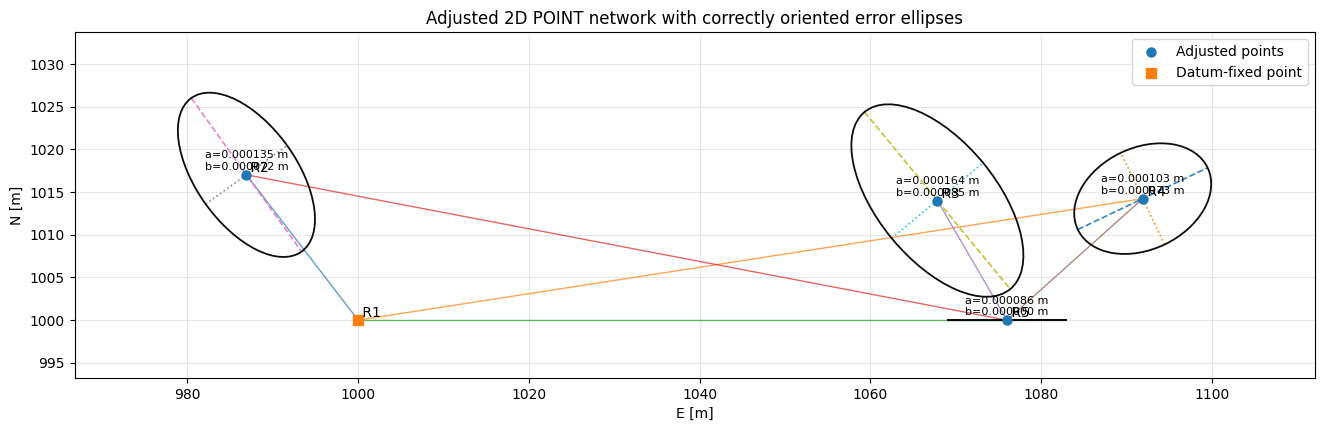

Precision source used: adjustment_results_xy['network_points_xy']
Observation source used for edges: obs_xy_final
Ellipse sigma level: 1.000
Visual ellipse scale factor: 82010.056x
Ellipse orientation fix applied: width=major axis, height=minor axis, angle=major-axis direction.


In [29]:
# === Optional 2D Step 5 — Plot adjusted 2D POINT network with correctly oriented error ellipses ===
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - adjustment_results_xy["network_points_xy"]   OR point_precision_xy
# - obs_xy / obs_xy_final / obs_xy_qc (for network edges)
#
# Plots:
# - adjusted 2D POINT network
# - point labels
# - correctly oriented 1-sigma error ellipses
# - major/minor axes of each ellipse
# - text above each free point with a,b values

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------
if "adjustment_results_xy" not in globals():
    raise RuntimeError("adjustment_results_xy was not found. Run Optional 2D Step 3 first.")

if "coords_xy_final" in adjustment_results_xy:
    coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
else:
    raise RuntimeError("adjustment_results_xy['coords_xy_final'] was not found.")

# Preferred precision source: network_points_xy from Step 3A
if "network_points_xy" in adjustment_results_xy:
    pp = adjustment_results_xy["network_points_xy"].copy()
    precision_source_name = "adjustment_results_xy['network_points_xy']"
elif "point_precision_xy" in globals():
    pp = point_precision_xy.copy()
    precision_source_name = "point_precision_xy"
else:
    raise RuntimeError(
        "No point-precision table found. Expected adjustment_results_xy['network_points_xy'] "
        "or point_precision_xy."
    )

# Observation source for edges
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_plot = obs_xy_final.copy()
    obs_source_name = "obs_xy_final"
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_plot = obs_xy_qc.copy()
    obs_source_name = "obs_xy_qc"
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_plot = obs_xy.copy()
    obs_source_name = "obs_xy"
else:
    raise RuntimeError("No observation table found for plotting edges. Expected obs_xy_final / obs_xy_qc / obs_xy.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_deg(g):
    return np.asarray(g, dtype=float) * 0.9

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _az_gon_to_theta_plot_deg(az_gon):
    # azimuth: clockwise from North
    # matplotlib angle: counterclockwise from +x (East)
    return float(90.0 - _gon_to_deg(float(az_gon)))

# ------------------------------------------------------------
# Normalize data
# ------------------------------------------------------------
coords_xy_final = coords_xy_final.copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

pp = pp.copy()
if "target" in pp.columns and "benchmark" not in pp.columns:
    pp = pp.rename(columns={"target": "benchmark"})
pp["benchmark"] = pp["benchmark"].astype(str).str.strip()

obs_plot["from"] = obs_plot["from"].astype(str).str.strip()
obs_plot["to"]   = obs_plot["to"].astype(str).str.strip()

coord_lookup = (
    coords_xy_final[["benchmark", "N_m", "E_m", "is_fixed_xy"]]
    .drop_duplicates(subset=["benchmark"])
    .set_index("benchmark")
)

# Keep only plotted points in precision table
pp = pp[pp["benchmark"].isin(coord_lookup.index)].copy().reset_index(drop=True)

# ------------------------------------------------------------
# Identify ellipse columns robustly
# ------------------------------------------------------------
if {"sigma_major_m", "sigma_minor_m", "az_major_gon"}.issubset(pp.columns):
    col_a = "sigma_major_m"
    col_b = "sigma_minor_m"
    col_az = "az_major_gon"
    az_unit = "gon"
elif {"ellipse_a_1sigma_m", "ellipse_b_1sigma_m", "ellipse_azimuth_deg"}.issubset(pp.columns):
    col_a = "ellipse_a_1sigma_m"
    col_b = "ellipse_b_1sigma_m"
    col_az = "ellipse_azimuth_deg"
    az_unit = "deg"
else:
    raise RuntimeError(
        "Could not identify ellipse columns. Expected either:\n"
        "1) sigma_major_m, sigma_minor_m, az_major_gon\n"
        "or\n"
        "2) ellipse_a_1sigma_m, ellipse_b_1sigma_m, ellipse_azimuth_deg"
    )

# ------------------------------------------------------------
# Build unique undirected POINT-network edges
# ------------------------------------------------------------
obs_plot = obs_plot.copy()
obs_plot["p_min"] = obs_plot[["from", "to"]].min(axis=1)
obs_plot["p_max"] = obs_plot[["from", "to"]].max(axis=1)

edges_df = (
    obs_plot.groupby(["p_min", "p_max"], as_index=False)
    .size()
    .rename(columns={"size": "n_obs"})
    .sort_values(["p_min", "p_max"])
    .reset_index(drop=True)
)

edges_df = edges_df[
    edges_df["p_min"].isin(coord_lookup.index) &
    edges_df["p_max"].isin(coord_lookup.index)
].copy()

# ------------------------------------------------------------
# User plot settings
# ------------------------------------------------------------
ellipse_sigma_level = 1.0       # 1-sigma ellipse
ellipse_target_fraction = 0.20  # target median visible major axis as fraction of median edge length
label_fontsize = 10
point_size_fixed = 60
point_size_free = 42
show_edge_labels = False

show_axes = True
axis_linewidth = 1.2
axis_alpha = 0.9

show_ab_text = True
ab_fontsize = 8
ab_offset_fraction = 0.020      # vertical offset relative to network N-span

ellipse_linewidth = 1.3
ellipse_alpha = 0.95

# ------------------------------------------------------------
# Auto-scale ellipses for readability
# ------------------------------------------------------------
edge_lengths = []
for _, r in edges_df.iterrows():
    a = str(r["p_min"]).strip()
    b = str(r["p_max"]).strip()
    Na, Ea = float(coord_lookup.loc[a, "N_m"]), float(coord_lookup.loc[a, "E_m"])
    Nb, Eb = float(coord_lookup.loc[b, "N_m"]), float(coord_lookup.loc[b, "E_m"])
    edge_lengths.append(float(np.hypot(Nb - Na, Eb - Ea)))

edge_lengths = np.asarray(edge_lengths, dtype=float)
edge_lengths = edge_lengths[np.isfinite(edge_lengths) & (edge_lengths > 0)]

median_edge_length = float(np.median(edge_lengths)) if len(edge_lengths) else 1.0

a_vals = pd.to_numeric(pp[col_a], errors="coerce").values.astype(float)
a_vals = a_vals[np.isfinite(a_vals) & (a_vals > 0)]

if len(a_vals) == 0:
    ellipse_plot_scale = 1.0
else:
    median_a = float(np.median(a_vals))
    ellipse_plot_scale = (ellipse_target_fraction * median_edge_length) / (ellipse_sigma_level * median_a)
    ellipse_plot_scale = float(np.clip(ellipse_plot_scale, 1.0, 1e6))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 12))

# Draw edges
for _, r in edges_df.iterrows():
    p1 = str(r["p_min"]).strip()
    p2 = str(r["p_max"]).strip()

    N1, E1 = float(coord_lookup.loc[p1, "N_m"]), float(coord_lookup.loc[p1, "E_m"])
    N2, E2 = float(coord_lookup.loc[p2, "N_m"]), float(coord_lookup.loc[p2, "E_m"])

    ax.plot([E1, E2], [N1, N2], linewidth=1.0, alpha=0.70)

    if show_edge_labels:
        Em = 0.5 * (E1 + E2)
        Nm = 0.5 * (N1 + N2)
        ax.text(Em, Nm, f"{p1}-{p2}", fontsize=7, ha="center", va="center")

# Draw points
fixed_mask = coords_xy_final["is_fixed_xy"].fillna(False).astype(bool)
free_mask = ~fixed_mask

ax.scatter(
    coords_xy_final.loc[free_mask, "E_m"],
    coords_xy_final.loc[free_mask, "N_m"],
    s=point_size_free,
    label="Adjusted points",
    zorder=4
)

ax.scatter(
    coords_xy_final.loc[fixed_mask, "E_m"],
    coords_xy_final.loc[fixed_mask, "N_m"],
    s=point_size_fixed,
    marker="s",
    label="Datum-fixed point",
    zorder=5
)

# Compute span for text offsets
all_E = coords_xy_final["E_m"].astype(float).values
all_N = coords_xy_final["N_m"].astype(float).values
span_E = max(float(np.max(all_E) - np.min(all_E)), 1.0)
span_N = max(float(np.max(all_N) - np.min(all_N)), 1.0)

ab_offset_N = ab_offset_fraction * span_N

# Point labels
for _, r in coords_xy_final.iterrows():
    p = str(r["benchmark"]).strip()
    Np = float(r["N_m"])
    Ep = float(r["E_m"])
    ax.text(Ep, Np, f" {p}", fontsize=label_fontsize, ha="left", va="bottom", zorder=6)

# Draw ellipses and their axes
for _, r in pp.iterrows():
    p = str(r["benchmark"]).strip()

    if p not in coord_lookup.index:
        continue
    if bool(coord_lookup.loc[p, "is_fixed_xy"]):
        continue

    a = pd.to_numeric(pd.Series([r[col_a]]), errors="coerce").iloc[0]
    b = pd.to_numeric(pd.Series([r[col_b]]), errors="coerce").iloc[0]
    az_raw = pd.to_numeric(pd.Series([r[col_az]]), errors="coerce").iloc[0]

    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_raw):
        continue
    if a <= 0 or b < 0:
        continue

    if az_unit == "gon":
        az_major_gon = float(_wrap_gon_0_400(az_raw))
        theta_plot_deg = _az_gon_to_theta_plot_deg(az_major_gon)
        az_major_rad = np.deg2rad(theta_plot_deg)
    else:
        theta_plot_deg = float(az_raw)
        az_major_rad = np.deg2rad(theta_plot_deg)

    Np = float(coord_lookup.loc[p, "N_m"])
    Ep = float(coord_lookup.loc[p, "E_m"])

    a_plot = float(ellipse_sigma_level * a * ellipse_plot_scale)
    b_plot = float(ellipse_sigma_level * b * ellipse_plot_scale)

    # Correct orientation:
    # width must correspond to the MAJOR axis,
    # height must correspond to the MINOR axis,
    # angle must be the direction of the MAJOR axis.
    ell = Ellipse(
        xy=(Ep, Np),
        width=2.0 * a_plot,
        height=2.0 * b_plot,
        angle=theta_plot_deg,
        fill=False,
        linewidth=ellipse_linewidth,
        alpha=ellipse_alpha,
        zorder=3
    )
    ax.add_patch(ell)

    if show_axes:
        # Major axis unit vector in plot coordinates (E,N)
        ux = np.cos(az_major_rad)
        uy = np.sin(az_major_rad)

        # Minor axis is +90 deg from major
        vx = -np.sin(az_major_rad)
        vy =  np.cos(az_major_rad)

        # Major axis
        ax.plot(
            [Ep - a_plot * ux, Ep + a_plot * ux],
            [Np - a_plot * uy, Np + a_plot * uy],
            linestyle="--",
            linewidth=axis_linewidth,
            alpha=axis_alpha,
            zorder=2
        )

        # Minor axis
        ax.plot(
            [Ep - b_plot * vx, Ep + b_plot * vx],
            [Np - b_plot * vy, Np + b_plot * vy],
            linestyle=":",
            linewidth=axis_linewidth,
            alpha=axis_alpha,
            zorder=2
        )

    if show_ab_text:
        txt = f"a={a:.6f} m\nb={b:.6f} m"
        ax.text(
            Ep,
            Np + ab_offset_N,
            txt,
            fontsize=ab_fontsize,
            ha="center",
            va="bottom",
            zorder=7
        )

# Cosmetics
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")
ax.set_title("Adjusted 2D POINT network with correctly oriented error ellipses")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# ------------------------------------------------------------
# Expand limits including scaled error ellipses and labels
# ------------------------------------------------------------
if len(all_E) and len(all_N):

    plot_E_min = float(np.min(all_E))
    plot_E_max = float(np.max(all_E))
    plot_N_min = float(np.min(all_N))
    plot_N_max = float(np.max(all_N))

    for _, r in pp.iterrows():
        p = str(r["benchmark"]).strip()

        if p not in coord_lookup.index:
            continue
        if bool(coord_lookup.loc[p, "is_fixed_xy"]):
            continue

        a = pd.to_numeric(pd.Series([r[col_a]]), errors="coerce").iloc[0]
        b = pd.to_numeric(pd.Series([r[col_b]]), errors="coerce").iloc[0]
        az_raw = pd.to_numeric(pd.Series([r[col_az]]), errors="coerce").iloc[0]

        if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_raw):
            continue
        if a <= 0 or b < 0:
            continue

        if az_unit == "gon":
            az_major_gon = float(_wrap_gon_0_400(az_raw))
            theta_plot_deg = _az_gon_to_theta_plot_deg(az_major_gon)
        else:
            theta_plot_deg = float(az_raw)

        theta = np.deg2rad(theta_plot_deg)

        Ep = float(coord_lookup.loc[p, "E_m"])
        Np = float(coord_lookup.loc[p, "N_m"])

        a_plot = float(ellipse_sigma_level * a * ellipse_plot_scale)
        b_plot = float(ellipse_sigma_level * b * ellipse_plot_scale)

        # Bounding half-widths of a rotated ellipse in plot coordinates
        dx = float(np.sqrt((a_plot * np.cos(theta))**2 + (b_plot * np.sin(theta))**2))
        dy = float(np.sqrt((a_plot * np.sin(theta))**2 + (b_plot * np.cos(theta))**2))

        plot_E_min = min(plot_E_min, Ep - dx)
        plot_E_max = max(plot_E_max, Ep + dx)
        plot_N_min = min(plot_N_min, Np - dy)
        plot_N_max = max(plot_N_max, Np + dy + ab_offset_N)

    plot_span_E = max(plot_E_max - plot_E_min, 1.0)
    plot_span_N = max(plot_N_max - plot_N_min, 1.0)

    pad_E = 0.10 * plot_span_E
    pad_N = 0.25 * plot_span_N

    ax.set_xlim(plot_E_min - pad_E, plot_E_max + pad_E)
    ax.set_ylim(plot_N_min - pad_N, plot_N_max + pad_N)

plt.show()

print(f"Precision source used: {precision_source_name}")
print(f"Observation source used for edges: {obs_source_name}")
print(f"Ellipse sigma level: {ellipse_sigma_level:.3f}")
print(f"Visual ellipse scale factor: {ellipse_plot_scale:.3f}x")
print("Ellipse orientation fix applied: width=major axis, height=minor axis, angle=major-axis direction.")

## Optional 2D Step 6 — Georeference the local adjusted network

This cell links the adjusted local 2D network to a real projected coordinate reference system.

**Main role**
- accept control points in projected or geographic form,
- define a working metric CRS,
- estimate the transformation from the local system to the working CRS,
- compute georeferenced coordinates for the adjusted points.

In [32]:
# === Optional 2D Step 6 — Georeference adjusted 2D network AND NON-POINT targets to a real metric CRS ===
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - adjustment_results_xy["nonpoint_targets_xy"]
# - xy_datum_definition
#
# What this cell does:
# - source = local independent system (POINT network + NON-POINT target report coordinates)
# - controls can be given either as:
#     1) projected coordinates in a metric working CRS
#     2) lon/lat in EPSG:4326
# - internal working CRS = user-selected METRIC projected CRS
# - transform type:
#     * rigid_2d      = shift + rotation
#     * similarity_2d = shift + rotation + scale
#
# Control points used:
# - anchor point       = xy_datum_definition["anchor_point"]
# - orientation point  = xy_datum_definition["orientation_point"]
#
# Outputs:
# - coords_xy_georef              : georeferenced POINT network coordinates
# - network_points_georef_xy      : POINT network report table in working CRS
# - nonpoint_targets_georef_xy    : NON-POINT target report table in working CRS
# - lon/lat in EPSG:4326
# - georeferencing summary and control-point check
#
# Notes:
# - Covariances / ellipses are transformed consistently with the chosen 2D transform:
#       C_geo = (s R) C_local (s R)^T
# - For NON-POINT targets, both propagated and empirical covariance descriptions are transformed
#   when available.

import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

required_vars = ["adjustment_results_xy", "xy_datum_definition"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

if "coords_xy_final" not in adjustment_results_xy:
    raise RuntimeError("adjustment_results_xy does not contain 'coords_xy_final'.")
if "nonpoint_targets_xy" not in adjustment_results_xy:
    raise RuntimeError("adjustment_results_xy does not contain 'nonpoint_targets_xy'. Run Optional 2D Step 4 first.")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

network_points_xy = adjustment_results_xy["network_points_xy"].copy() if "network_points_xy" in adjustment_results_xy else None
nonpoint_targets_xy = adjustment_results_xy["nonpoint_targets_xy"].copy()

anchor = str(xy_datum_definition["anchor_point"]).strip()
orient_pt = str(xy_datum_definition["orientation_point"]).strip()

if anchor not in coords_xy_final["benchmark"].values:
    raise RuntimeError(f"Anchor point '{anchor}' not found in coords_xy_final.")
if orient_pt not in coords_xy_final["benchmark"].values:
    raise RuntimeError(f"Orientation point '{orient_pt}' not found in coords_xy_final.")
if anchor == orient_pt:
    raise RuntimeError("Anchor point and orientation point must be different.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def _gon_to_rad(g):
    return np.asarray(g, dtype=float) * np.pi / 200.0

def _rad_to_gon(r):
    return np.asarray(r, dtype=float) * 200.0 / np.pi

def _wrap_gon_0_400(g):
    g = np.asarray(g, dtype=float)
    return np.mod(g, 400.0)

def _azimuth_from_dNE(dN, dE):
    # 0 gon = North, 100 gon = East
    return float(_wrap_gon_0_400(_rad_to_gon(np.arctan2(dE, dN))))

def _rotation_matrix_NE(delta_gon):
    a = float(_gon_to_rad(delta_gon))
    c = np.cos(a)
    s = np.sin(a)
    # [dN'; dE'] = R * [dN; dE]
    return np.array([[c, -s],
                     [s,  c]], dtype=float)

def _rotate_dNE(dN, dE, delta_gon):
    R = _rotation_matrix_NE(delta_gon)
    out = R @ np.array([dN, dE], dtype=float)
    return float(out[0]), float(out[1])

def _ellipse_from_cov(C2):
    C2 = np.asarray(C2, dtype=float)
    C2 = 0.5 * (C2 + C2.T)

    vals, vecs = np.linalg.eigh(C2)
    vals = np.maximum(vals, 0.0)

    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    smaj = float(np.sqrt(vals[0]))
    smin = float(np.sqrt(vals[1]))

    # eigenvector expressed in [N, E]
    v = vecs[:, 0]
    az_rad = float(np.arctan2(v[1], v[0]))
    az_gon = float(_wrap_gon_0_400(_rad_to_gon(az_rad)))

    return smaj, smin, az_gon

def _transform_covariance_NE(C_local, scale_factor, delta_gon):
    C_local = np.asarray(C_local, dtype=float)
    C_local = 0.5 * (C_local + C_local.T)
    R = _rotation_matrix_NE(delta_gon)
    A = float(scale_factor) * R
    C_geo = A @ C_local @ A.T
    return 0.5 * (C_geo + C_geo.T)

def _build_cov_from_row(row, sigmaN_col, sigmaE_col, cov_col):
    if sigmaN_col not in row.index or sigmaE_col not in row.index or cov_col not in row.index:
        return None
    sN = pd.to_numeric(pd.Series([row[sigmaN_col]]), errors="coerce").iloc[0]
    sE = pd.to_numeric(pd.Series([row[sigmaE_col]]), errors="coerce").iloc[0]
    cNE = pd.to_numeric(pd.Series([row[cov_col]]), errors="coerce").iloc[0]
    if not np.isfinite(sN) or not np.isfinite(sE) or not np.isfinite(cNE):
        return None
    return np.array([[float(sN)**2, float(cNE)],
                     [float(cNE),    float(sE)**2]], dtype=float)

# ------------------------------------------------------------
# Input section
# ------------------------------------------------------------
print("Working CRS for georeferencing (must be a METRIC projected CRS).")
print("Examples: 2100 for EGSA87, 32634 for UTM zone 34N, 32635 for UTM zone 35N")
working_epsg = int(input("Enter working projected EPSG: ").strip())

working_crs = CRS.from_epsg(working_epsg)
if not working_crs.is_projected:
    raise ValueError(f"EPSG:{working_epsg} is not projected. Use a metric projected CRS.")

print("\nControl-coordinate input mode:")
print("  1 -> coordinates already given in the working projected CRS")
print("  2 -> lon/lat given in EPSG:4326, transformed internally to the working projected CRS")
input_mode = input("Choose input mode [1/2]: ").strip()
if input_mode not in ["1", "2"]:
    raise ValueError("Input mode must be '1' or '2'.")

print("\nTransform type:")
print("  1 -> rigid_2d      (shift + rotation)")
print("  2 -> similarity_2d (shift + rotation + scale)")
transform_mode = input("Choose transform type [1/2]: ").strip()
if transform_mode not in ["1", "2"]:
    raise ValueError("Transform type must be '1' or '2'.")

transform_type = "rigid_2d" if transform_mode == "1" else "similarity_2d"

print(f"\nAnchor point: {anchor}")
print(f"Orientation point: {orient_pt}")

if input_mode == "1":
    anchor_E_proj = float(input(f"Enter real/projected E/X of '{anchor}' in EPSG:{working_epsg}: ").strip().replace(",", "."))
    anchor_N_proj = float(input(f"Enter real/projected N/Y of '{anchor}' in EPSG:{working_epsg}: ").strip().replace(",", "."))
    orient_E_proj = float(input(f"Enter real or approximate E/X of '{orient_pt}' in EPSG:{working_epsg}: ").strip().replace(",", "."))
    orient_N_proj = float(input(f"Enter real or approximate N/Y of '{orient_pt}' in EPSG:{working_epsg}: ").strip().replace(",", "."))

else:
    anchor_lon = float(input(f"Enter longitude of '{anchor}' [deg, EPSG:4326]: ").strip().replace(",", "."))
    anchor_lat = float(input(f"Enter latitude  of '{anchor}' [deg, EPSG:4326]: ").strip().replace(",", "."))
    orient_lon = float(input(f"Enter longitude of '{orient_pt}' [deg, EPSG:4326]: ").strip().replace(",", "."))
    orient_lat = float(input(f"Enter latitude  of '{orient_pt}' [deg, EPSG:4326]: ").strip().replace(",", "."))

    tr_4326_to_work = Transformer.from_crs(CRS.from_epsg(4326), working_crs, always_xy=True)
    anchor_E_proj, anchor_N_proj = tr_4326_to_work.transform(anchor_lon, anchor_lat)
    orient_E_proj, orient_N_proj = tr_4326_to_work.transform(orient_lon, orient_lat)

# ------------------------------------------------------------
# Local control geometry
# ------------------------------------------------------------
coord_lookup = coords_xy_final.set_index("benchmark")[["N_m", "E_m"]]

anchor_N_local = float(coord_lookup.loc[anchor, "N_m"])
anchor_E_local = float(coord_lookup.loc[anchor, "E_m"])
orient_N_local = float(coord_lookup.loc[orient_pt, "N_m"])
orient_E_local = float(coord_lookup.loc[orient_pt, "E_m"])

dN_local = orient_N_local - anchor_N_local
dE_local = orient_E_local - anchor_E_local
len_local = float(np.hypot(dN_local, dE_local))

dN_proj = float(orient_N_proj - anchor_N_proj)
dE_proj = float(orient_E_proj - anchor_E_proj)
len_proj = float(np.hypot(dN_proj, dE_proj))

if len_local <= 1e-12:
    raise RuntimeError("Local anchor-orientation geometry is degenerate.")
if len_proj <= 1e-12:
    raise RuntimeError("Projected anchor-orientation geometry is degenerate.")

az_local_gon = _azimuth_from_dNE(dN_local, dE_local)
az_proj_gon = _azimuth_from_dNE(dN_proj, dE_proj)
delta_gon = float(_wrap_gon_0_400(az_proj_gon - az_local_gon))

if transform_type == "rigid_2d":
    scale_factor = 1.0
else:
    scale_factor = float(len_proj / len_local)

# ------------------------------------------------------------
# Transform all POINT network coordinates: local -> working projected CRS
# ------------------------------------------------------------
rows = []
for _, r in coords_xy_final.iterrows():
    p = str(r["benchmark"]).strip()

    Nloc = float(r["N_m"])
    Eloc = float(r["E_m"])

    dN = Nloc - anchor_N_local
    dE = Eloc - anchor_E_local

    dN_rot, dE_rot = _rotate_dNE(dN, dE, delta_gon)

    dN_fin = scale_factor * dN_rot
    dE_fin = scale_factor * dE_rot

    N_proj = float(anchor_N_proj + dN_fin)
    E_proj = float(anchor_E_proj + dE_fin)

    rows.append({
        "benchmark": p,
        "N_local_m": Nloc,
        "E_local_m": Eloc,
        "N_geo": N_proj,
        "E_geo": E_proj,
        "is_fixed_xy": bool(r.get("is_fixed_xy", False)),
        "component_id": r.get("component_id", np.nan),
    })

coords_xy_georef = pd.DataFrame(rows)

# ------------------------------------------------------------
# lon/lat output in EPSG:4326 for POINT network
# ------------------------------------------------------------
tr_work_to_4326 = Transformer.from_crs(working_crs, CRS.from_epsg(4326), always_xy=True)
lon_vals, lat_vals = tr_work_to_4326.transform(
    coords_xy_georef["E_geo"].astype(float).values,
    coords_xy_georef["N_geo"].astype(float).values
)
coords_xy_georef["lon_deg"] = lon_vals
coords_xy_georef["lat_deg"] = lat_vals

# ------------------------------------------------------------
# Control-point check
# ------------------------------------------------------------
geo_lookup = coords_xy_georef.set_index("benchmark")[["N_geo", "E_geo"]]

anchor_N_chk = float(geo_lookup.loc[anchor, "N_geo"])
anchor_E_chk = float(geo_lookup.loc[anchor, "E_geo"])
orient_N_chk = float(geo_lookup.loc[orient_pt, "N_geo"])
orient_E_chk = float(geo_lookup.loc[orient_pt, "E_geo"])

anchor_offset_m = float(np.hypot(anchor_N_chk - anchor_N_proj, anchor_E_chk - anchor_E_proj))
orient_offset_m = float(np.hypot(orient_N_chk - orient_N_proj, orient_E_chk - orient_E_proj))

check_df = pd.DataFrame([
    {
        "point": anchor,
        "given_E_proj": float(anchor_E_proj),
        "given_N_proj": float(anchor_N_proj),
        "transformed_E_proj": float(anchor_E_chk),
        "transformed_N_proj": float(anchor_N_chk),
        "offset_m": anchor_offset_m,
    },
    {
        "point": orient_pt,
        "given_E_proj": float(orient_E_proj),
        "given_N_proj": float(orient_N_proj),
        "transformed_E_proj": float(orient_E_chk),
        "transformed_N_proj": float(orient_N_chk),
        "offset_m": orient_offset_m,
    },
])

# ------------------------------------------------------------
# Transform POINT-network uncertainty report if available
# ------------------------------------------------------------
network_points_georef_xy = None
network_point_covariances_georef_xy = {}

if network_points_xy is not None and len(network_points_xy) > 0:
    network_points_xy = network_points_xy.copy()
    network_points_xy["target"] = network_points_xy["target"].astype(str).str.strip()

    network_cov_dict_local = adjustment_results_xy.get("network_point_covariances_xy", {})

    net_rows = []
    for _, r in network_points_xy.iterrows():
        p = str(r["target"]).strip()

        if p not in geo_lookup.index:
            continue

        N_geo = float(geo_lookup.loc[p, "N_geo"])
        E_geo = float(geo_lookup.loc[p, "E_geo"])

        C_local = None
        if isinstance(network_cov_dict_local, dict) and p in network_cov_dict_local:
            C_local = network_cov_dict_local[p].to_numpy(dtype=float)
        else:
            C_local = _build_cov_from_row(r, "sigma_N_m", "sigma_E_m", "cov_NE_m2")

        if C_local is None:
            C_geo = np.full((2, 2), np.nan)
            sigma_N_geo = np.nan
            sigma_E_geo = np.nan
            cov_NE_geo = np.nan
            smaj_geo = np.nan
            smin_geo = np.nan
            azmaj_geo = np.nan
        else:
            C_geo = _transform_covariance_NE(C_local, scale_factor, delta_gon)
            sigma_N_geo = float(np.sqrt(max(C_geo[0, 0], 0.0)))
            sigma_E_geo = float(np.sqrt(max(C_geo[1, 1], 0.0)))
            cov_NE_geo = float(C_geo[0, 1])
            smaj_geo, smin_geo, azmaj_geo = _ellipse_from_cov(C_geo)

            network_point_covariances_georef_xy[p] = pd.DataFrame(
                C_geo,
                index=[f"N_{p}", f"E_{p}"],
                columns=[f"N_{p}", f"E_{p}"],
            )

        row_out = r.to_dict()
        row_out["N_geo"] = N_geo
        row_out["E_geo"] = E_geo
        lon_p, lat_p = tr_work_to_4326.transform(E_geo, N_geo)
        row_out["lon_deg"] = float(lon_p)
        row_out["lat_deg"] = float(lat_p)

        row_out["sigma_N_geo_m"] = sigma_N_geo
        row_out["sigma_E_geo_m"] = sigma_E_geo
        row_out["cov_NE_geo_m2"] = cov_NE_geo
        row_out["sigma_major_geo_m"] = smaj_geo
        row_out["sigma_minor_geo_m"] = smin_geo
        row_out["az_major_geo_gon"] = azmaj_geo

        net_rows.append(row_out)

    network_points_georef_xy = pd.DataFrame(net_rows).sort_values("target").reset_index(drop=True)

# ------------------------------------------------------------
# Transform NON-POINT target report
# ------------------------------------------------------------
nonpoint_targets_xy = nonpoint_targets_xy.copy()
nonpoint_targets_xy["target"] = nonpoint_targets_xy["target"].astype(str).str.strip()

prop_cov_dict_local = adjustment_results_xy.get("nonpoint_target_propagated_covariances_xy", {})
emp_cov_dict_local  = adjustment_results_xy.get("nonpoint_target_empirical_covariances_xy", {})

nonpoint_target_propagated_covariances_georef_xy = {}
nonpoint_target_empirical_covariances_georef_xy = {}

np_rows = []
for _, r in nonpoint_targets_xy.iterrows():
    p = str(r["target"]).strip()

    Nloc = float(r["N_m"])
    Eloc = float(r["E_m"])

    dN = Nloc - anchor_N_local
    dE = Eloc - anchor_E_local
    dN_rot, dE_rot = _rotate_dNE(dN, dE, delta_gon)
    N_geo = float(anchor_N_proj + scale_factor * dN_rot)
    E_geo = float(anchor_E_proj + scale_factor * dE_rot)
    lon_p, lat_p = tr_work_to_4326.transform(E_geo, N_geo)

    row_out = r.to_dict()
    row_out["N_geo"] = N_geo
    row_out["E_geo"] = E_geo
    row_out["lon_deg"] = float(lon_p)
    row_out["lat_deg"] = float(lat_p)

    # ---------- propagated covariance ----------
    C_prop_local = None
    if isinstance(prop_cov_dict_local, dict) and p in prop_cov_dict_local:
        C_prop_local = prop_cov_dict_local[p].to_numpy(dtype=float)
    else:
        C_prop_local = _build_cov_from_row(r, "prop_sigma_N_m", "prop_sigma_E_m", "prop_cov_NE_m2")

    if C_prop_local is not None:
        C_prop_geo = _transform_covariance_NE(C_prop_local, scale_factor, delta_gon)
        prop_sigma_N_geo = float(np.sqrt(max(C_prop_geo[0, 0], 0.0)))
        prop_sigma_E_geo = float(np.sqrt(max(C_prop_geo[1, 1], 0.0)))
        prop_cov_NE_geo = float(C_prop_geo[0, 1])
        prop_smaj_geo, prop_smin_geo, prop_azmaj_geo = _ellipse_from_cov(C_prop_geo)

        nonpoint_target_propagated_covariances_georef_xy[p] = pd.DataFrame(
            C_prop_geo,
            index=[f"N_{p}", f"E_{p}"],
            columns=[f"N_{p}", f"E_{p}"],
        )
    else:
        prop_sigma_N_geo = np.nan
        prop_sigma_E_geo = np.nan
        prop_cov_NE_geo = np.nan
        prop_smaj_geo = np.nan
        prop_smin_geo = np.nan
        prop_azmaj_geo = np.nan

    row_out["prop_sigma_N_geo_m"] = prop_sigma_N_geo
    row_out["prop_sigma_E_geo_m"] = prop_sigma_E_geo
    row_out["prop_cov_NE_geo_m2"] = prop_cov_NE_geo
    row_out["prop_sigma_major_geo_m"] = prop_smaj_geo
    row_out["prop_sigma_minor_geo_m"] = prop_smin_geo
    row_out["prop_az_major_geo_gon"] = prop_azmaj_geo

    # ---------- empirical covariance ----------
    C_emp_local = None
    if isinstance(emp_cov_dict_local, dict) and p in emp_cov_dict_local:
        C_emp_local = emp_cov_dict_local[p].to_numpy(dtype=float)
    else:
        # Prefer empirical covariance columns if present, else build from std_N/std_E + emp_cov
        if {"std_N_m", "std_E_m", "emp_cov_NE_m2"}.issubset(set(r.index)):
            C_emp_local = _build_cov_from_row(r, "std_N_m", "std_E_m", "emp_cov_NE_m2")

    if C_emp_local is not None:
        C_emp_geo = _transform_covariance_NE(C_emp_local, scale_factor, delta_gon)
        emp_std_N_geo = float(np.sqrt(max(C_emp_geo[0, 0], 0.0)))
        emp_std_E_geo = float(np.sqrt(max(C_emp_geo[1, 1], 0.0)))
        emp_cov_NE_geo = float(C_emp_geo[0, 1])
        emp_smaj_geo, emp_smin_geo, emp_azmaj_geo = _ellipse_from_cov(C_emp_geo)

        nonpoint_target_empirical_covariances_georef_xy[p] = pd.DataFrame(
            C_emp_geo,
            index=[f"N_{p}", f"E_{p}"],
            columns=[f"N_{p}", f"E_{p}"],
        )
    else:
        emp_std_N_geo = np.nan
        emp_std_E_geo = np.nan
        emp_cov_NE_geo = np.nan
        emp_smaj_geo = np.nan
        emp_smin_geo = np.nan
        emp_azmaj_geo = np.nan

    row_out["std_N_geo_m"] = emp_std_N_geo
    row_out["std_E_geo_m"] = emp_std_E_geo
    row_out["emp_cov_NE_geo_m2"] = emp_cov_NE_geo
    row_out["emp_sigma_major_geo_m"] = emp_smaj_geo
    row_out["emp_sigma_minor_geo_m"] = emp_smin_geo
    row_out["emp_az_major_geo_gon"] = emp_azmaj_geo

    if "rms_radial_scatter_m" in row_out and pd.notna(row_out["rms_radial_scatter_m"]):
        row_out["rms_radial_scatter_geo_m"] = float(abs(scale_factor) * float(row_out["rms_radial_scatter_m"]))
    else:
        row_out["rms_radial_scatter_geo_m"] = np.nan

    np_rows.append(row_out)

nonpoint_targets_georef_xy = pd.DataFrame(np_rows).sort_values("target").reset_index(drop=True)

# ------------------------------------------------------------
# Build one concise georeferenced coordinate table for plotting/export
# POINT network coordinates + NON-POINT target coordinates
# ------------------------------------------------------------
point_plot_cols = []
point_plot_df = coords_xy_georef.copy()
point_plot_df["point_type"] = "POINT"
point_plot_df["source_table"] = "coords_xy_georef"
point_plot_df["source_name"] = point_plot_df["benchmark"].astype(str).str.strip()
point_plot_df["N_m"] = point_plot_df["N_local_m"]
point_plot_df["E_m"] = point_plot_df["E_local_m"]

point_keep_cols = [
    "benchmark", "point_type", "source_table", "source_name",
    "N_m", "E_m", "N_geo", "E_geo", "lon_deg", "lat_deg",
    "is_fixed_xy", "component_id",
]
point_plot_df = point_plot_df[[c for c in point_keep_cols if c in point_plot_df.columns]].copy()

if nonpoint_targets_georef_xy is not None and len(nonpoint_targets_georef_xy) > 0:
    nonpoint_plot_df = nonpoint_targets_georef_xy.copy()
    nonpoint_plot_df["benchmark"] = nonpoint_plot_df["target"].astype(str).str.strip()
    nonpoint_plot_df["point_type"] = "NON_POINT_TARGET"
    nonpoint_plot_df["source_table"] = "nonpoint_targets_georef_xy"
    nonpoint_plot_df["source_name"] = nonpoint_plot_df["target"].astype(str).str.strip()
    nonpoint_plot_df["is_fixed_xy"] = False
    if "component_id" not in nonpoint_plot_df.columns:
        nonpoint_plot_df["component_id"] = np.nan

    nonpoint_keep_cols = [
        "benchmark", "point_type", "source_table", "source_name",
        "N_m", "E_m", "N_geo", "E_geo", "lon_deg", "lat_deg",
        "is_fixed_xy", "component_id",
    ]
    nonpoint_plot_df = nonpoint_plot_df[[c for c in nonpoint_keep_cols if c in nonpoint_plot_df.columns]].copy()
else:
    nonpoint_plot_df = pd.DataFrame(columns=point_plot_df.columns)

georef_all_points_xy = pd.concat(
    [point_plot_df, nonpoint_plot_df],
    ignore_index=True,
    sort=False,
)

sort_cols = [c for c in ["point_type", "benchmark"] if c in georef_all_points_xy.columns]
if sort_cols:
    georef_all_points_xy = georef_all_points_xy.sort_values(sort_cols).reset_index(drop=True)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
georef_definition_xy = {
    "working_epsg": int(working_epsg),
    "input_mode": input_mode,
    "transform_type": transform_type,
    "anchor_point": anchor,
    "orientation_point": orient_pt,
    "anchor_proj_E": float(anchor_E_proj),
    "anchor_proj_N": float(anchor_N_proj),
    "orientation_proj_E": float(orient_E_proj),
    "orientation_proj_N": float(orient_N_proj),
    "local_azimuth_gon": float(az_local_gon),
    "projected_azimuth_gon": float(az_proj_gon),
    "applied_rotation_gon": float(delta_gon),
    "scale_factor": float(scale_factor),
    "anchor_offset_m": float(anchor_offset_m),
    "orientation_offset_m": float(orient_offset_m),
}

georef_results_xy = {
    "coords_xy_georef": coords_xy_georef,
    "georef_all_points_xy": georef_all_points_xy,
    "network_points_georef_xy": network_points_georef_xy,
    "nonpoint_targets_georef_xy": nonpoint_targets_georef_xy,
    "georef_definition_xy": georef_definition_xy,
    "control_check_xy": check_df,
    "network_point_covariances_georef_xy": network_point_covariances_georef_xy,
    "nonpoint_target_propagated_covariances_georef_xy": nonpoint_target_propagated_covariances_georef_xy,
    "nonpoint_target_empirical_covariances_georef_xy": nonpoint_target_empirical_covariances_georef_xy,
}

# Also save into adjustment_results_xy for convenience
adjustment_results_xy["coords_xy_georef"] = coords_xy_georef
adjustment_results_xy["georef_all_points_xy"] = georef_all_points_xy
adjustment_results_xy["network_points_georef_xy"] = network_points_georef_xy
adjustment_results_xy["nonpoint_targets_georef_xy"] = nonpoint_targets_georef_xy
adjustment_results_xy["georef_definition_xy"] = georef_definition_xy
adjustment_results_xy["control_check_xy"] = check_df
adjustment_results_xy["network_point_covariances_georef_xy"] = network_point_covariances_georef_xy
adjustment_results_xy["nonpoint_target_propagated_covariances_georef_xy"] = nonpoint_target_propagated_covariances_georef_xy
adjustment_results_xy["nonpoint_target_empirical_covariances_georef_xy"] = nonpoint_target_empirical_covariances_georef_xy

print("\nGeoreference definition summary:")
print(georef_definition_xy)

print("\nControl-point check:")
display(check_df)

print("\nGeoreferenced POINT network coordinates:")
coords_xy_georef_display = coords_xy_georef.sort_values("benchmark").reset_index(drop=True).copy()
display(
    coords_xy_georef_display.style.format({
        "N_local_m": "{:.6f}",
        "E_local_m": "{:.6f}",
        "N_geo": "{:.6f}",
        "E_geo": "{:.6f}",
        "lon_deg": "{:.8f}",
        "lat_deg": "{:.8f}",
    })
)

print("\nGeoreferenced ALL coordinate table for plotting/export (POINT + NON-POINT targets):")
georef_all_points_display = georef_all_points_xy.copy()
display(
    georef_all_points_display.style.format({
        "N_m": "{:.6f}",
        "E_m": "{:.6f}",
        "N_geo": "{:.6f}",
        "E_geo": "{:.6f}",
        "lon_deg": "{:.8f}",
        "lat_deg": "{:.8f}",
    })
)

if network_points_georef_xy is not None and len(network_points_georef_xy) > 0:
    print("\nGeoreferenced POINT network report:")
    display(network_points_georef_xy)

print("\nGeoreferenced NON-POINT target report:")
display(nonpoint_targets_georef_xy)

print("\nSaved georeferenced results in dict: georef_results_xy")

Working CRS for georeferencing (must be a METRIC projected CRS).
Examples: 2100 for EGSA87, 32634 for UTM zone 34N, 32635 for UTM zone 35N
Enter working projected EPSG: 32635

Control-coordinate input mode:
  1 -> coordinates already given in the working projected CRS
  2 -> lon/lat given in EPSG:4326, transformed internally to the working projected CRS
Choose input mode [1/2]: 2

Transform type:
  1 -> rigid_2d      (shift + rotation)
  2 -> similarity_2d (shift + rotation + scale)
Choose transform type [1/2]: 2

Anchor point: R1
Orientation point: R5
Enter longitude of 'R1' [deg, EPSG:4326]: 26.3401853317
Enter latitude  of 'R1' [deg, EPSG:4326]: 36.5737697945
Enter longitude of 'R5' [deg, EPSG:4326]: 26.3407952208
Enter latitude  of 'R5' [deg, EPSG:4326]: 36.5732933906

Georeference definition summary:
{'working_epsg': 32635, 'input_mode': '2', 'transform_type': 'similarity_2d', 'anchor_point': 'R1', 'orientation_point': 'R5', 'anchor_proj_E': 440965.84225385264, 'anchor_proj_N': 40

,point,given_E_proj,given_N_proj,transformed_E_proj,transformed_N_proj,offset_m
0,R1,440965.842254,4.047794e+06,440965.842254,4.047794e+06,0.0
1,R5,441020.047933,4.047740e+06,441020.047933,4.047740e+06,0.0



Georeferenced POINT network coordinates:


,benchmark,N_local_m,E_local_m,N_geo,E_geo,is_fixed_xy,component_id,lon_deg,lat_deg
0,R1,1000.000000,1000.000000,4047793.514343,440965.842254,True,1,26.34018533,36.57376979
1,R2,1017.019085,986.912009,4047814.819864,440968.425652,False,1,26.34021257,36.57396201
2,R3,1014.009309,1067.845861,4047755.992590,441024.047418,False,1,26.34083872,36.57343515
3,R4,1014.229805,1091.895759,4047739.306999,441041.356477,False,1,26.34103344,36.57328581
4,R5,1000.000000,1075.993498,4047740.293803,441020.047933,False,1,26.34079522,36.57329339



Georeferenced ALL coordinate table for plotting/export (POINT + NON-POINT targets):


...


Georeferenced POINT network report:


,target,n_observations,n_setups,n_stations,N_m,E_m,sigma_N_m,sigma_E_m,cov_NE_m2,sigma_major_m,...,N_geo,E_geo,lon_deg,lat_deg,sigma_N_geo_m,sigma_E_geo_m,cov_NE_geo_m2,sigma_major_geo_m,sigma_minor_geo_m,az_major_geo_gon
0,R1,188,3,3,1000.000000,1000.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,...,4.047794e+06,440965.842254,26.340185,36.573770,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,100.000000
1,R2,66,2,2,1017.019085,986.912009,1.173321e-04,0.000098,-6.202689e-09,0.000135,...,4.047815e+06,440968.425652,26.340213,36.573962,0.000134,0.000074,1.972878e-09,0.000135,7.162166e-05,209.754280
2,R3,44,1,1,1014.009309,1067.845861,1.374434e-04,0.000123,-9.642304e-09,0.000164,...,4.047756e+06,441024.047418,26.340839,36.573435,0.000163,0.000085,1.721455e-09,0.000164,8.460331e-05,205.608795
3,R4,142,2,2,1014.229805,1091.895759,7.902068e-05,0.000098,2.048999e-09,0.000103,...,4.047739e+06,441041.356477,26.341033,36.573286,0.000076,0.000100,-1.623639e-09,0.000103,7.255535e-05,121.115387
4,R5,260,3,3,1000.000000,1075.993498,5.238889e-21,0.000086,4.482265e-25,0.000086,...,4.047740e+06,441020.047933,26.340795,36.573293,0.000060,0.000061,-3.656688e-09,0.000086,4.547474e-13,149.416212



Georeferenced NON-POINT target report:


,target,n_observations,n_setups,n_stations,N_m,E_m,prop_sigma_N_m,prop_sigma_E_m,prop_cov_NE_m2,prop_sigma_major_m,...,prop_sigma_major_geo_m,prop_sigma_minor_geo_m,prop_az_major_geo_gon,std_N_geo_m,std_E_geo_m,emp_cov_NE_geo_m2,emp_sigma_major_geo_m,emp_sigma_minor_geo_m,emp_az_major_geo_gon,rms_radial_scatter_geo_m
0,F1,12,1,1,1013.773612,1074.895803,0.001344,0.004999,6.249765e-07,0.005001,...,0.004999,0.001337,147.701982,0.000257,0.000293,-5.097116e-08,0.000358,0.000155,143.875130,0.000373
1,F2,12,1,1,1016.641451,1074.737970,0.001518,0.004956,-3.188178e-06,0.005001,...,0.004999,0.001362,158.297779,0.000236,0.000152,7.886250e-09,0.000240,0.000146,214.319339,0.000269
2,T1,21,1,1,1016.643933,1074.803825,0.001515,0.004955,-3.205079e-06,0.005001,...,0.004999,0.001357,158.340656,0.000214,0.000279,-1.978914e-08,0.000295,0.000191,128.382297,0.000343
3,T2,21,1,1,1016.680422,1074.804289,0.001520,0.004954,-3.251565e-06,0.005001,...,0.004999,0.001358,158.474087,0.000213,0.000189,6.427326e-09,0.000220,0.000180,229.516665,0.000278
4,T3,21,1,1,1016.720127,1074.799492,0.001525,0.004953,-3.300907e-06,0.005001,...,0.004999,0.001358,158.616382,0.000231,0.000166,2.249970e-08,0.000258,0.000120,233.376186,0.000277



Saved georeferenced results in dict: georef_results_xy


## Optional 2D Step 7 — Plot selected georeferenced points on satellite imagery

This final cell produces a map of selected georeferenced points over high-resolution satellite imagery.

**Main role**
- read the georeferenced point dataframe,
- ask the user to upload a text file containing the Google Map Tiles API key,
- request a valid Google tiles session,
- ask which benchmarks should be plotted,
- display only the selected points over satellite tiles.

In [33]:
# === Optional 2D Step 7 — Plot selected georeferenced points on Google satellite tiles ===
# Requires:
# - georef_results_xy["georef_all_points_xy"] if available
#   otherwise georef_results_xy["coords_xy_georef"]
# - georef_results_xy["georef_definition_xy"]
#
# This cell:
# - asks the user to upload a .txt file containing the Google Map Tiles API key
# - requests a Google Map Tiles API session token
# - asks which benchmark points to plot
# - plots ONLY the selected points
# - uses Google satellite imagery as background

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer
import requests

try:
    import contextily as ctx
except ImportError:
    raise ImportError(
        "The package 'contextily' is not installed.\n"
        "Run in a previous cell:\n"
        "!pip install contextily"
    )

try:
    from google.colab import files
except ImportError:
    raise ImportError("This cell is intended for Google Colab.")

if "georef_results_xy" not in globals():
    raise RuntimeError("georef_results_xy was not found. Run Optional 2D Step 6 first.")

if "georef_definition_xy" not in georef_results_xy:
    raise RuntimeError("georef_results_xy does not contain 'georef_definition_xy'.")

if "georef_all_points_xy" in georef_results_xy:
    coords_xy_georef = georef_results_xy["georef_all_points_xy"].copy()
    georef_source_table = "georef_all_points_xy"
elif "coords_xy_georef" in georef_results_xy:
    coords_xy_georef = georef_results_xy["coords_xy_georef"].copy()
    georef_source_table = "coords_xy_georef"
else:
    raise RuntimeError("georef_results_xy contains neither 'georef_all_points_xy' nor 'coords_xy_georef'.")

georef_definition_xy = georef_results_xy["georef_definition_xy"]

coords_xy_georef["benchmark"] = coords_xy_georef["benchmark"].astype(str).str.strip()

required_cols = ["benchmark", "E_geo", "N_geo"]
for col in required_cols:
    if col not in coords_xy_georef.columns:
        raise RuntimeError(f"Column '{col}' not found in coords_xy_georef.")

working_epsg = int(georef_definition_xy["working_epsg"])

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
margin_frac = 0.10
min_window_m = 300.0

point_size = 70
label_fontsize = 9
draw_labels = True

google_zoom = 20   # fixed zoom level for local high-resolution view

# ------------------------------------------------------------
# Ask user to upload .txt file containing the API key
# ------------------------------------------------------------
print("Upload ONE .txt file that contains only the Google Map Tiles API key.")
uploaded = files.upload()

if len(uploaded) != 1:
    raise RuntimeError("You must upload exactly one .txt file.")

uploaded_name = next(iter(uploaded.keys()))
if not uploaded_name.lower().endswith(".txt"):
    raise RuntimeError("The uploaded file must be a .txt file.")

api_key = uploaded[uploaded_name].decode("utf-8").strip()

if api_key == "":
    raise RuntimeError("The uploaded .txt file is empty.")

# ------------------------------------------------------------
# Request Google Map Tiles session token
# ------------------------------------------------------------
session_url = "https://tile.googleapis.com/v1/createSession"
session_params = {"key": api_key}
session_body = {
    "mapType": "satellite",
    "language": "en-US",
    "region": "GR"
}

resp = requests.post(
    session_url,
    params=session_params,
    json=session_body,
    headers={"Content-Type": "application/json"},
    timeout=30
)

if resp.status_code != 200:
    raise RuntimeError(
        f"Google createSession failed.\n"
        f"HTTP {resp.status_code}\n"
        f"Response: {resp.text}"
    )

session_data = resp.json()

if "session" not in session_data:
    raise RuntimeError(f"Session token not found in response: {session_data}")

google_session_token = session_data["session"]

# ------------------------------------------------------------
# Transform georeferenced projected coordinates:
# working CRS -> lon/lat -> Web Mercator (EPSG:3857)
# ------------------------------------------------------------
tr_work_to_4326 = Transformer.from_crs(
    CRS.from_epsg(working_epsg),
    CRS.from_epsg(4326),
    always_xy=True
)

lon_vals, lat_vals = tr_work_to_4326.transform(
    coords_xy_georef["E_geo"].astype(float).values,
    coords_xy_georef["N_geo"].astype(float).values
)

coords_plot = coords_xy_georef.copy()
coords_plot["lon_deg"] = lon_vals
coords_plot["lat_deg"] = lat_vals

tr_4326_to_3857 = Transformer.from_crs(
    CRS.from_epsg(4326),
    CRS.from_epsg(3857),
    always_xy=True
)

x_3857, y_3857 = tr_4326_to_3857.transform(
    coords_plot["lon_deg"].astype(float).values,
    coords_plot["lat_deg"].astype(float).values
)

coords_plot["x_3857"] = x_3857
coords_plot["y_3857"] = y_3857

# ------------------------------------------------------------
# Ask user which points to plot
# ------------------------------------------------------------
available_points = coords_plot["benchmark"].drop_duplicates().sort_values().tolist()

print(f"\nAvailable points from {georef_source_table}:")
if "point_type" in coords_plot.columns:
    available_table = (
        coords_plot[["benchmark", "point_type"]]
        .drop_duplicates()
        .sort_values(["point_type", "benchmark"])
        .reset_index(drop=True)
    )
    display(available_table)
else:
    print(", ".join(available_points))

user_input = input(
    "\nEnter point names separated by commas, or type ALL: "
).strip()

if user_input == "":
    raise RuntimeError("No input was given.")

if user_input.upper() == "ALL":
    selected_points = available_points
else:
    selected_points = [p.strip() for p in user_input.split(",") if p.strip() != ""]
    invalid_points = [p for p in selected_points if p not in available_points]
    if invalid_points:
        raise RuntimeError(
            "The following point name(s) were not found: " + ", ".join(invalid_points)
        )

coords_sel = (
    coords_plot[coords_plot["benchmark"].isin(selected_points)]
    .drop_duplicates(subset=["benchmark"])
    .copy()
)

if coords_sel.empty:
    raise RuntimeError("No valid points selected for plotting.")

# ------------------------------------------------------------
# Map extent from selected points only
# ------------------------------------------------------------
x_min = float(coords_sel["x_3857"].min())
x_max = float(coords_sel["x_3857"].max())
y_min = float(coords_sel["y_3857"].min())
y_max = float(coords_sel["y_3857"].max())

span_x = max(x_max - x_min, 1e-6)
span_y = max(y_max - y_min, 1e-6)

pad_x = margin_frac * span_x
pad_y = margin_frac * span_y

xmin = x_min - pad_x
xmax = x_max + pad_x
ymin = y_min - pad_y
ymax = y_max + pad_y

if (xmax - xmin) < min_window_m:
    cx = 0.5 * (xmin + xmax)
    xmin = cx - 0.25 * min_window_m
    xmax = cx + 0.25 * min_window_m

if (ymax - ymin) < min_window_m:
    cy = 0.5 * (ymin + ymax)
    ymin = cy - 0.25 * min_window_m
    ymax = cy + 0.25 * min_window_m

# ------------------------------------------------------------
# Google tile URL template
# ------------------------------------------------------------
google_tile_url = (
    f"https://tile.googleapis.com/v1/2dtiles/{{z}}/{{x}}/{{y}}"
    f"?session={google_session_token}&key={api_key}"
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords_sel["x_3857"],
    coords_sel["y_3857"],
    s=point_size,
    c="red",
    edgecolors="black",
    linewidths=0.8,
    zorder=5
)

if draw_labels:
    for _, r in coords_sel.iterrows():
        ax.text(
            float(r["x_3857"]),
            float(r["y_3857"]),
            f" {str(r['benchmark']).strip()}",
            fontsize=label_fontsize,
            ha="left",
            va="bottom",
            color="white",
            zorder=6
        )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ctx.add_basemap(
    ax,
    source=google_tile_url,
    crs="EPSG:3857",
    attribution="© Google",
    zoom=google_zoom
)

ax.set_title("Selected georeferenced points on Google satellite imagery")
ax.set_xticks([])
ax.set_yticks([])

plt.show()

print(f"Working projected CRS EPSG: {working_epsg}")
print("Selected points:", ", ".join(coords_sel["benchmark"].tolist()))
print("Google session token acquired successfully.")

Upload ONE .txt file that contains only the Google Map Tiles API key.


Saving Google_Maps_API_key.txt to Google_Maps_API_key (1).txt


RuntimeError: Google createSession failed.
HTTP 403
Response: {
  "error": {
    "code": 403,
    "message": "Your request cannot be served because satellite tiles and 3D tiles are not available for your account and region. Learn more here: https://developers.google.com/maps/comms/eea/map-tiles.",
    "errors": [
      {
        "message": "Your request cannot be served because satellite tiles and 3D tiles are not available for your account and region. Learn more here: https://developers.google.com/maps/comms/eea/map-tiles.",
        "domain": "global",
        "reason": "forbidden"
      }
    ],
    "status": "PERMISSION_DENIED"
  }
}


**NOTEBOOK ENDS HERE**

## Optional 2D Step 5A — Focused local plot with error ellipses

This cell creates a focused 2D plot for a selected local cluster of points.

**Main role**
- isolate the selected benchmarks,
- plot only the local subgroup,
- display their error ellipses with a scale suitable for the local extent.

In [ ]:
# === Optional 2D Step 5A — Focused plot on F1, F2, T1, T2, T3 with error ellipses ===
# Requires:
# - adjustment_results_xy["coords_xy_final"]
# - point_precision_xy
#
# Plots:
# - focused 2D view for selected points
# - 1-sigma error ellipses with independent visual scaling for this local cluster

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

if "adjustment_results_xy" not in globals():
    raise RuntimeError("adjustment_results_xy was not found. Run Optional 2D Step 3 first.")

if "point_precision_xy" not in globals():
    raise RuntimeError("point_precision_xy was not found. Run Optional 2D Step 4 first.")

coords_xy_final = adjustment_results_xy["coords_xy_final"].copy()
coords_xy_final["benchmark"] = coords_xy_final["benchmark"].astype(str).str.strip()

pp = point_precision_xy.copy()
pp["benchmark"] = pp["benchmark"].astype(str).str.strip()

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
focus_points = ["F1", "F2", "T1", "T2", "T3"]
ellipse_sigma_level = 1.0
ellipse_target_fraction = 0.18   # larger local visibility than the full-network plot
label_fontsize = 10
point_size = 55

# ------------------------------------------------------------
# Filter to focus points
# ------------------------------------------------------------
focus_df = coords_xy_final[coords_xy_final["benchmark"].isin(focus_points)].copy()
if focus_df.empty:
    raise RuntimeError("None of the requested focus points were found in coords_xy_final.")

pp_focus = pp[pp["benchmark"].isin(focus_points)].copy()

coord_lookup = (
    focus_df[["benchmark", "N_m", "E_m", "is_fixed_xy"]]
    .drop_duplicates(subset=["benchmark"])
    .set_index("benchmark")
)

# ------------------------------------------------------------
# Local ellipse scaling
# ------------------------------------------------------------
# use local spread of focused points as the scale reference
all_E = focus_df["E_m"].astype(float).values
all_N = focus_df["N_m"].astype(float).values

span_E = max(float(np.max(all_E) - np.min(all_E)), 1e-6)
span_N = max(float(np.max(all_N) - np.min(all_N)), 1e-6)
local_span = max(span_E, span_N)

ellipse_a_vals = pd.to_numeric(pp_focus["ellipse_a_1sigma_m"], errors="coerce").values.astype(float)
ellipse_a_vals = ellipse_a_vals[np.isfinite(ellipse_a_vals) & (ellipse_a_vals > 0)]

if len(ellipse_a_vals) == 0:
    ellipse_plot_scale = 1.0
else:
    median_a = float(np.median(ellipse_a_vals))
    if median_a <= 0:
        ellipse_plot_scale = 1.0
    else:
        ellipse_plot_scale = (ellipse_target_fraction * local_span) / (ellipse_sigma_level * median_a)

ellipse_plot_scale = float(np.clip(ellipse_plot_scale, 1.0, 1e7))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    focus_df["E_m"].astype(float),
    focus_df["N_m"].astype(float),
    s=point_size,
)

for _, r in focus_df.iterrows():
    p = str(r["benchmark"]).strip()
    Np = float(r["N_m"])
    Ep = float(r["E_m"])
    ax.text(Ep, Np, f" {p}", fontsize=label_fontsize, ha="left", va="bottom")

# Draw ellipses
for _, r in pp_focus.iterrows():
    p = str(r["benchmark"]).strip()
    if p not in coord_lookup.index:
        continue

    a = pd.to_numeric(pd.Series([r["ellipse_a_1sigma_m"]]), errors="coerce").iloc[0]
    b = pd.to_numeric(pd.Series([r["ellipse_b_1sigma_m"]]), errors="coerce").iloc[0]
    az_deg = pd.to_numeric(pd.Series([r["ellipse_azimuth_deg"]]), errors="coerce").iloc[0]

    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(az_deg):
        continue
    if a <= 0 or b < 0:
        continue

    Np = float(coord_lookup.loc[p, "N_m"])
    Ep = float(coord_lookup.loc[p, "E_m"])

    theta_plot_deg = 90.0 - float(az_deg)

    ell = Ellipse(
        xy=(Ep, Np),
        width=2.0 * ellipse_sigma_level * b * ellipse_plot_scale,
        height=2.0 * ellipse_sigma_level * a * ellipse_plot_scale,
        angle=theta_plot_deg,
        fill=False,
        linewidth=1.4,
        alpha=0.95
    )
    ax.add_patch(ell)

ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")
ax.set_title("Focused 2D plot: F1, F2, T1, T2, T3")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)

# tight local limits with small padding
Emin, Emax = float(np.min(all_E)), float(np.max(all_E))
Nmin, Nmax = float(np.min(all_N)), float(np.max(all_N))

pad_E = max(2.5 * (Emax - Emin), 0.02)
pad_N = max(0.25 * (Nmax - Nmin), 0.02)

ax.set_xlim(Emin - pad_E, Emax + pad_E)
ax.set_ylim(Nmin - pad_N, Nmax + pad_N)

plt.show()

print(f"Focused ellipse sigma level: {ellipse_sigma_level:.3f}")
print(f"Focused visual ellipse scale factor: {ellipse_plot_scale:.3f}x")

βλεεπ

In [ ]:
# === Optional 2D Step 3A — Diagnose largest residuals ===

import numpy as np
import pandas as pd
from IPython.display import display

if "residuals_xy" not in globals():
    raise RuntimeError("residuals_xy not found. Run Optional 2D Step 3 first.")

res_diag_xy = residuals_xy.copy()

res_diag_xy["abs_residual_native"] = pd.to_numeric(
    res_diag_xy["residual_native"], errors="coerce"
).abs()

print("Top 30 residuals overall:")
display(
    res_diag_xy.sort_values("abs_residual_native", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

print("\nTop 30 Hz residuals:")
display(
    res_diag_xy[res_diag_xy["obs_family"] == "Hz"]
    .sort_values("abs_residual_native", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

print("\nResidual summary by setup and observation family:")
setup_summary_xy = (
    res_diag_xy
    .groupby(["setup_id_xy", "obs_family"], dropna=False)
    .agg(
        n=("residual_native", "size"),
        mean_residual=("residual_native", "mean"),
        std_residual=("residual_native", "std"),
        median_abs_residual=("abs_residual_native", "median"),
        max_abs_residual=("abs_residual_native", "max"),
    )
    .reset_index()
    .sort_values(["obs_family", "max_abs_residual"], ascending=[True, False])
    .reset_index(drop=True)
)

display(setup_summary_xy)

print("\nTop setups by maximum |Hz residual|:")
display(
    setup_summary_xy[setup_summary_xy["obs_family"] == "Hz"]
    .sort_values("max_abs_residual", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

In [ ]:
# === Optional 2D Step 3B — Inspect suspect Hz groups in detail ===

import numpy as np
import pandas as pd
from IPython.display import display

if "residuals_xy" not in globals():
    raise RuntimeError("residuals_xy not found. Run Optional 2D Step 3 first.")

suspect_setups = ["R4__SET001", "R4__SET002"]

df_sus = residuals_xy.copy()
df_sus = df_sus[df_sus["obs_family"] == "Hz"].copy()
df_sus = df_sus[df_sus["setup_id_xy"].isin(suspect_setups)].copy()

if df_sus.empty:
    raise RuntimeError("No suspect Hz observations found for the requested setups.")

for col in ["obs_value", "calc_value", "residual_native", "weight"]:
    df_sus[col] = pd.to_numeric(df_sus[col], errors="coerce")

df_sus["abs_residual_native"] = df_sus["residual_native"].abs()
df_sus["obs_value_round4"] = df_sus["obs_value"].round(4)

print("Detailed suspect observations (sorted by setup / target / face / obs_value):")
display(
    df_sus.sort_values(["setup_id_xy", "to", "face", "obs_value"])
          .reset_index(drop=True)
)

print("\nGrouped summary by setup / target / face:")
grp = (
    df_sus.groupby(["setup_id_xy", "from", "to", "face"], dropna=False)
    .agg(
        n=("obs_value", "size"),
        obs_min_gon=("obs_value", "min"),
        obs_max_gon=("obs_value", "max"),
        obs_range_gon=("obs_value", lambda s: float(np.max(s) - np.min(s))),
        obs_mean_gon=("obs_value", "mean"),
        calc_value_gon=("calc_value", "mean"),
        mean_residual_gon=("residual_native", "mean"),
        std_residual_gon=("residual_native", "std"),
        median_abs_residual_gon=("abs_residual_native", "median"),
        max_abs_residual_gon=("abs_residual_native", "max"),
    )
    .reset_index()
    .sort_values(["setup_id_xy", "to", "face"])
    .reset_index(drop=True)
)
display(grp)

print("\nFrequency table of repeated observed Hz values (rounded to 0.0001 gon):")
for sid in suspect_setups:
    sub_sid = df_sus[df_sus["setup_id_xy"] == sid].copy()
    if sub_sid.empty:
        continue

    print(f"\n=== {sid} ===")
    keys = (
        sub_sid[["to", "face"]]
        .drop_duplicates()
        .sort_values(["to", "face"])
        .itertuples(index=False, name=None)
    )

    for to_pt, face in keys:
        ss = sub_sid[(sub_sid["to"] == to_pt) & (sub_sid["face"] == face)].copy()
        print(f"\nTarget={to_pt}, Face={face}, n={len(ss)}")

        freq = (
            ss["obs_value_round4"]
            .value_counts(dropna=False)
            .rename_axis("obs_value_round4_gon")
            .reset_index(name="count")
            .sort_values(["count", "obs_value_round4_gon"], ascending=[False, True])
            .reset_index(drop=True)
        )
        display(freq)

print("\nWorst suspect groups only:")
display(
    grp.sort_values("max_abs_residual_gon", ascending=False)
       .reset_index(drop=True)
)

In [ ]:
# === Optional 2D Step 3C — Inspect suspect setups in observation order ===

import pandas as pd
from IPython.display import display

required_vars = ["residuals_xy"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

suspect_setups = ["R4__SET001", "R4__SET002"]

df_seq = residuals_xy.copy()
df_seq = df_seq[df_seq["obs_family"] == "Hz"].copy()
df_seq = df_seq[df_seq["setup_id_xy"].isin(suspect_setups)].copy()

for col in ["obs_value", "calc_value", "residual_native"]:
    df_seq[col] = pd.to_numeric(df_seq[col], errors="coerce")

df_seq = df_seq.sort_values(["setup_id_xy", "obs_row"]).reset_index(drop=True)

# previous-row diagnostics within each setup
df_seq["prev_to"] = df_seq.groupby("setup_id_xy")["to"].shift(1)
df_seq["prev_face"] = df_seq.groupby("setup_id_xy")["face"].shift(1)
df_seq["prev_obs_value"] = df_seq.groupby("setup_id_xy")["obs_value"].shift(1)
df_seq["delta_obs_from_prev_gon"] = df_seq["obs_value"] - df_seq["prev_obs_value"]

# mark block changes
df_seq["new_target_block"] = (
    (df_seq["to"] != df_seq["prev_to"]) |
    (df_seq["face"] != df_seq["prev_face"])
).fillna(True)

for sid in suspect_setups:
    sub = df_seq[df_seq["setup_id_xy"] == sid].copy()
    if sub.empty:
        continue

    print(f"\n=== Observation order for {sid} ===")
    display(
        sub[[
            "obs_row",
            "from",
            "to",
            "face",
            "obs_value",
            "calc_value",
            "residual_native",
            "prev_to",
            "prev_face",
            "delta_obs_from_prev_gon",
            "new_target_block",
        ]].reset_index(drop=True)
    )

    print(f"\nTarget/face blocks for {sid}:")
    blocks = (
        sub.groupby(["to", "face"], dropna=False)
        .agg(
            first_obs_row=("obs_row", "min"),
            last_obs_row=("obs_row", "max"),
            n=("obs_row", "size"),
            obs_mean_gon=("obs_value", "mean"),
            calc_value_gon=("calc_value", "mean"),
            mean_residual_gon=("residual_native", "mean"),
        )
        .reset_index()
        .sort_values("first_obs_row")
        .reset_index(drop=True)
    )
    display(blocks)

In [ ]:
# === Optional 2D Step 3D — Inspect block_id_xy -> setup_id_xy mapping for R4 ===

import pandas as pd
from IPython.display import display

required_vars = ["block_summary_xy", "block_assignment_xy", "block_comparison_xy"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")

# ------------------------------------------------------------
# 0. Select active observation table that still carries block/setup IDs
# ------------------------------------------------------------
if "obs_xy_final" in globals() and isinstance(obs_xy_final, pd.DataFrame) and len(obs_xy_final) > 0:
    obs_active = obs_xy_final.copy()
    active_name = "obs_xy_final"
elif "obs_xy_qc" in globals() and isinstance(obs_xy_qc, pd.DataFrame) and len(obs_xy_qc) > 0:
    obs_active = obs_xy_qc.copy()
    active_name = "obs_xy_qc"
elif "obs_xy" in globals() and isinstance(obs_xy, pd.DataFrame) and len(obs_xy) > 0:
    obs_active = obs_xy.copy()
    active_name = "obs_xy"
else:
    raise RuntimeError("No active observation table found.")

print(f"Using active table: {active_name}")

required_cols_obs = ["from", "to", "face", "setup_id_xy", "block_id_xy"]
missing_obs = [c for c in required_cols_obs if c not in obs_active.columns]
if missing_obs:
    raise RuntimeError(f"Active observation table is missing columns: {missing_obs}")

if "__row_order_xy" not in obs_active.columns:
    obs_active["__row_order_xy"] = range(len(obs_active))

if "Hz_open_gon" not in obs_active.columns:
    obs_active["Hz_open_gon"] = pd.NA

if "is_nonpoint_target" not in obs_active.columns:
    obs_active["is_nonpoint_target"] = pd.NA

obs_active["from"] = obs_active["from"].astype(str).str.strip()
obs_active["to"] = obs_active["to"].astype(str).str.strip()
obs_active["face"] = obs_active["face"].astype(str).str.strip().str.upper()
obs_active["setup_id_xy"] = obs_active["setup_id_xy"].astype(str).str.strip()
obs_active["block_id_xy"] = obs_active["block_id_xy"].astype(str).str.strip()

# ------------------------------------------------------------
# 1. Observation rows for R4 with block/setup IDs
# ------------------------------------------------------------
obs_r4 = obs_active[obs_active["from"] == "R4"].copy()

print("\nR4 observations with block_id_xy and setup_id_xy:")
display(
    obs_r4[[
        "__row_order_xy",
        "block_id_xy",
        "setup_id_xy",
        "from",
        "to",
        "face",
        "Hz_open_gon",
        "is_nonpoint_target",
    ]]
    .sort_values(["__row_order_xy", "to", "face"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Block summary for R4
# ------------------------------------------------------------
bs_r4 = block_summary_xy[block_summary_xy["from_benchmark"].astype(str).str.strip() == "R4"].copy()

print("\nblock_summary_xy for R4:")
display(
    bs_r4.sort_values(["first_row", "block_id_xy"]).reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. block_assignment_xy for R4
# ------------------------------------------------------------
ba_r4 = block_assignment_xy[block_assignment_xy["from_benchmark"].astype(str).str.strip() == "R4"].copy()

print("\nblock_assignment_xy for R4:")
display(
    ba_r4.sort_values(["block_id_xy"]).reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. nonpoint assignment report for R4, if available
# ------------------------------------------------------------
if "nonpoint_assignment_report_xy" in globals():
    npr_r4 = nonpoint_assignment_report_xy[
        nonpoint_assignment_report_xy["from_benchmark"].astype(str).str.strip() == "R4"
    ].copy()

    print("\nnonpoint_assignment_report_xy for R4:")
    display(
        npr_r4.sort_values(["block_id_xy"]).reset_index(drop=True)
    )

# ------------------------------------------------------------
# 5. Block comparisons for R4
# ------------------------------------------------------------
bc_r4 = block_comparison_xy[block_comparison_xy["from_benchmark"].astype(str).str.strip() == "R4"].copy()

print("\nAll block comparisons for R4:")
display(
    bc_r4.sort_values(["block_1", "block_2"]).reset_index(drop=True)
)

print("\nOnly merge-accepted comparisons for R4:")
display(
    bc_r4[bc_r4["relation"] == "MERGE_ZERO_COMPATIBLE"]
    .sort_values(["block_1", "block_2"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Setup membership tables for R4, if available
# ------------------------------------------------------------
if "setup_block_members_xy" in globals():
    sbm_r4 = setup_block_members_xy[
        setup_block_members_xy["from_benchmark"].astype(str).str.strip() == "R4"
    ].copy()

    print("\nsetup_block_members_xy for R4:")
    display(
        sbm_r4.sort_values(["setup_id_xy", "block_first_row", "block_id_xy"]).reset_index(drop=True)
    )

if "setup_summary_xy" in globals():
    ss_r4 = setup_summary_xy[
        setup_summary_xy["from_benchmark"].astype(str).str.strip() == "R4"
    ].copy()

    print("\nsetup_summary_xy for R4:")
    display(
        ss_r4.sort_values(["setup_id_xy"]).reset_index(drop=True)
    )

In [ ]:
ΤΕΣΤ ΒΕΕΠΕΡ

R1,R2,R3,R4,R5,T2